# Train–test selectivity and architectural fragility under quantization of grokked transformers

### Canonical Architecture, a Confirmed Localization Finding, and Full Statistical Rigor

**This notebook runs E6 (width sweep) and E7 (train-fraction sweep) directly, and loads E1
(addition, both primes) and E5 (multiplication, subtraction) from their own standalone,
crash-resilient notebooks' exported datasets** (Sec. 6) -- both are long-running experiments now
split out so they can be run, checkpointed, and resumed independently of everything else here.
Set `E1_DATASET_DIR` / `E5_DATASET_DIR` in the global config (Sec. 6) to wherever those notebooks'
`outputs/logs/` files ended up before running this one.

**Key design points, and why:**

| Issue identified | Fix / addition |
|---|---|
| Architecture used a 2-token `[a, b]` input, no separator | **Canonical 3-token `[a, b, =]` format**, vocab p+1, 3 learned positions, causal masking -- matches Nanda et al. (2023) Sec. 3 exactly |
| MLP was a plain 2-matrix ReLU block | **Parameter-matched SwiGLU** (`d_ff=341`, 99.90% of baseline params, bias-free) -- the near-universal 2024-2026 deployment standard |
| H3's mechanism claim was untested against a confound | Init-checkpoint control via partial correlation, with a bootstrap-CI equivalence test |
| H4 (layer localization) had no mechanistic explanation | Width-accumulation theory tested at bits=2, 4, and 5 (bits=2 alone is floor-saturated and unstable across runs) |
| Train fraction (40%) never checked against the canonical 30% Nanda uses | Train-fraction robustness sweep (20% / 30% / 40%), with results filtered to grokked runs only |
| "Cleaned up" was asserted, never verified to be post-plateau | Weight-norm plateau check; training now extends adaptively past `max_steps` when grokked-but-not-converged, up to a safety cap |
| A fixed eval interval could step over the narrow pre-grok window | Adaptive fine-grained evaluation (every step, not every 50) within a generous horizon covering the observed grok-step range |
| H6's found/not-found verdict flipped between two full runs on an arbitrary 3x cutoff | Reported as a bootstrap CI on the fine/coarse ratio, with an honest "inconclusive" outcome available |
| Panel letters floated bold and uppercase above each plot | Lowercase, inset inside each panel's own corner (Nature/Science convention) |

**Contents**
1. Setup
2. Problem Definition -- H1-H8 in full, and what each tests
3. Method -- canonical architecture, SwiGLU, quantization schemes, TOST/bootstrap/overlap-check helpers
4. Baselines / Experiment Design
5. Dataset -- addition (trained here for E6/E7); multiplication and subtraction are loaded, not generated
6. Training / Inference -- checkpointing; E1/E5 loaded from external datasets; E6/E7 run directly
7. Evaluation -- every hypothesis test, with TOST and bootstrap CIs
8. Figures
9. Tables
10. Output Packaging

# Md Muntaqim Meherab¹,* and Mahathir Muhammad¹

**Corresponding author:**  
Md Muntaqim Meherab (M.M. Meherab)  
Email: meherab2305101354@diu.edu.bd

**ORCID:**
- Md Muntaqim Meherab: [0009-0008-3383-6740](https://orcid.org/0009-0008-3383-6740)
- Mahathir Muhammad: [0009-0003-6903-6474](https://orcid.org/0009-0003-6903-6474)

¹ Affiliation: Daffodil International University


## 1. Setup

In [ ]:
import subprocess, sys

def pip_install(pkgs):
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
        print('Installed/verified:', ' '.join(pkgs))
    except Exception as e:
        print('pip install warning (continuing, likely already satisfied):', e)

pip_install(['scipy'])


Installed/verified: scipy


In [ ]:
import os, sys, json, time, random, math, copy, zipfile
from datetime import datetime
from dataclasses import dataclass, field, asdict

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches
from scipy import stats

BASE_SEED = 0

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(BASE_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception as e:
    print('Could not enable full deterministic-algorithms mode (continuing):', e)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type != 'cuda':
    print('WARNING: no CUDA GPU detected. Runtime > Change runtime type > T4 GPU is recommended.')
    print('The notebook will still run on CPU (much slower); consider QUICK_TEST = True below.')
else:
    print('GPU detected:', torch.cuda.get_device_name(0))

print('Environment info:')
print('  Python  :', sys.version.split()[0])
print('  PyTorch :', torch.__version__)
print('  NumPy   :', np.__version__)
print('  Pandas  :', pd.__version__)
print('  SciPy   :', __import__('scipy').__version__)
print('  CUDA available:', torch.cuda.is_available())
print('  Device  :', DEVICE)
print('  Run started:', datetime.now().isoformat())

# ---------------- ICLR-format figure defaults ----------------
# Slightly more conservative than v4 throughout (larger margins, smaller max legend/label density
# per panel) specifically in response to text-overlap issues in the v4 run -- see Sec. 8's
# automated overlap checker, which every figure below is validated against before being trusted.
ICLR_WIDTH = 5.5
COLORS = {
    'init': '#95a5a6', 'pre_grok': '#a93226', 'just_grokked': '#e67e22', 'post_grok_500': '#d4ac0d',
    'post_grok_1500': '#27ae60', 'cleaned_up': '#154360',
    'train': '#7d3c98', 'test': '#154360',
    'int': '#1b4f72', 'mantissa': '#c0392b', 'nf': '#117864',
    'p_primary': '#1b4f72', 'p_secondary': '#e67e22',
    'addition': '#1b4f72', 'multiplication': '#117864', 'subtraction': '#8e44ad',
    'embedding': '#1b4f72', 'attention': '#c0392b', 'mlp': '#117864', 'unembed': '#8e44ad',
    'mlp_gate': '#117864', 'mlp_up': '#52be80', 'mlp_down': '#0b5345',
    'cleanup': '#1b4f72', 'fulltrain': '#c0392b',
    'frac_020': '#c0392b', 'frac_030': '#e67e22', 'frac_040': '#1b4f72',
}
MARKERS = {
    'pre_grok': 'v', 'just_grokked': 'D', 'post_grok_500': '^', 'post_grok_1500': 's', 'cleaned_up': 'o',
    'train': 's', 'test': 'o', 'int': 'o', 'mantissa': 's', 'nf': '^',
    'p_primary': 'o', 'p_secondary': 's', 'addition': 'o', 'multiplication': '^', 'subtraction': 's',
    'frac_020': 'v', 'frac_030': 'D', 'frac_040': 'o',
}
PHASE_ORDER = ['pre_grok', 'just_grokked', 'post_grok_500', 'post_grok_1500', 'cleaned_up']
PHASE_LABELS = {'pre_grok': 'pre-\ngrok', 'just_grokked': 'just\ngrokked', 'post_grok_500': '+500\nsteps',
                'post_grok_1500': '+1500\nsteps', 'cleaned_up': 'cleaned\nup'}
mpl.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300, 'pdf.fonttype': 42, 'ps.fonttype': 42,
    'font.size': 9, 'font.family': 'sans-serif', 'axes.titlesize': 8.8, 'axes.labelsize': 8.3,
    'xtick.labelsize': 7.3, 'ytick.labelsize': 7.3, 'legend.fontsize': 6.6,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#333333', 'axes.labelcolor': '#111111', 'text.color': '#111111',
    'xtick.color': '#333333', 'ytick.color': '#333333',
    'axes.grid': True, 'grid.alpha': 0.14, 'grid.linewidth': 0.5, 'grid.color': '#999999',
    'legend.frameon': False, 'lines.linewidth': 1.4, 'axes.linewidth': 0.8,
    'xtick.major.width': 0.8, 'ytick.major.width': 0.8, 'xtick.major.size': 2.5, 'ytick.major.size': 2.5,
    'axes.facecolor': 'white', 'figure.facecolor': 'white', 'savefig.facecolor': 'white', 'axes.axisbelow': True,
})

def add_panel_label(ax, label, caption=None, x=0.0, y=1.0):
    '''Panel identifier as a plain "a) short caption" title -- no separate bold inset letter (a
    boxed letter plus a caption above it read as cluttered; the letter is folded into the caption
    itself instead). Guaranteed to fit within its own panel width: tries the requested font size,
    shrinks it if needed, and truncates as an absolute last resort so a long caption can never
    visually run into a neighboring panel regardless of data or font-rendering differences.'''
    if not caption:
        ax.set_title(label.lower(), loc='left', fontsize=7.5, fontweight='bold', pad=3)
        return
    text = '{}) {}'.format(label.lower(), caption)
    fig = ax.figure
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    ax_bbox = ax.get_window_extent(renderer=renderer)
    budget_px = ax_bbox.width * 0.94

    fontsize = 7.0
    min_fontsize = 6.0
    while fontsize >= min_fontsize:
        t = ax.set_title(text, loc='left', fontsize=fontsize, fontweight='normal', pad=3)
        fig.canvas.draw()
        if t.get_window_extent(renderer=renderer).width <= budget_px:
            return
        fontsize -= 0.5

    truncated = text
    while len(truncated) > 8:
        truncated = truncated[:-1]
        t = ax.set_title(truncated.rstrip() + '...', loc='left', fontsize=min_fontsize, fontweight='normal', pad=3)
        fig.canvas.draw()
        if t.get_window_extent(renderer=renderer).width <= budget_px:
            return


def tighten_ticks(ax, y=True, x=True, nbins=4):
    """Reduce tick density -- lowers the chance of a tick landing exactly where its label
    collides with a panel letter, axis label, or neighboring content. x=True by default now:
    several remaining collisions were x-tick-vs-y-tick corner overlaps near the plot origin that
    y-only tightening never addressed."""
    # Skip axes that were intentionally emptied by no_data_placeholder (0 ticks currently set)
    # -- otherwise MaxNLocator re-populates ticks on a default [0,1] empty axes, producing a
    # crowded 0.00/0.25/0.50/0.75/1.00 pattern regardless of call order.
    if len(ax.get_yticks()) == 0 and len(ax.get_xticks()) == 0:
        return
    if y:
        ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=nbins))
    if x:
        ax.xaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=nbins))


def check_text_overlaps(fig):
    """Render the figure and pairwise-check EVERY text element's bounding box (titles, axis
    labels, tick labels, legend entries, annotations, suptitle) for overlap. Returns a list of
    colliding (text_a, text_b) pairs -- empty means no collisions. This is an objective,
    tool-independent substitute for visual inspection, validated against known-bad and known-good
    synthetic cases before being trusted (see build notes)."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    all_texts = []
    for ax in fig.get_axes():
        all_texts.extend(ax.texts)
        all_texts.append(ax.title)
        all_texts.append(ax.xaxis.label)
        all_texts.append(ax.yaxis.label)
        # Fixed: only include tick labels whose data position actually falls within the axes'
        # current view limits. MaxNLocator can generate a "nice" candidate tick outside the set
        # xlim/ylim (e.g. 30, when the visible range is 1-24); matplotlib creates a real Text
        # object for it anyway, but clips it from the final render -- without this filter, the
        # checker flags overlaps involving labels that never actually appear on the figure
        # (confirmed: this was the exact cause of a "D overlaps 30" false positive with nothing
        # visibly wrong in the rendered figure).
        xlim, ylim = ax.get_xlim(), ax.get_ylim()
        for tick_val, label in zip(ax.get_xticks(), ax.get_xticklabels()):
            if min(xlim) <= tick_val <= max(xlim):
                all_texts.append(label)
        for tick_val, label in zip(ax.get_yticks(), ax.get_yticklabels()):
            if min(ylim) <= tick_val <= max(ylim):
                all_texts.append(label)
        leg = ax.get_legend()
        if leg:
            all_texts.extend(leg.get_texts())
    all_texts.extend(fig.texts)
    boxes = []
    for t in all_texts:
        if not t.get_text().strip():
            continue
        bbox = t.get_window_extent(renderer=renderer)
        boxes.append((t.get_text()[:30], bbox))
    overlaps = []
    for i in range(len(boxes)):
        for j in range(i + 1, len(boxes)):
            (txt_i, box_i), (txt_j, box_j) = boxes[i], boxes[j]
            if box_i.overlaps(box_j):
                overlaps.append((txt_i, txt_j))
    return overlaps


def save_figure_validated(fig, save_path):
    """Save a figure only after confirming no text overlaps; prints a clear warning (not a
    silent failure) if any are found, so a bad figure is never mistaken for a validated one."""
    overlaps = check_text_overlaps(fig)
    if overlaps:
        print('  [WARNING] {} text overlap(s) detected in {}:'.format(len(overlaps), save_path))
        for a, b in overlaps:
            print('    "{}"  overlaps  "{}"'.format(a, b))
    else:
        print('  Text-overlap check passed (0 collisions): {}'.format(save_path))
    os.makedirs(os.path.dirname(save_path), exist_ok=True)  # guarantee this regardless of cell order
    fig.savefig(save_path)
    return overlaps

def scatter_and_line(ax, df, x_col, y_col, group_col, groups, colors, labels, markers=None,
                      jitter=0.10, show_scatter=True):
    """Moved here (was previously defined in the Figures section) so it can never be out of
    scope when a figure cell runs, regardless of cell execution order -- this is the structural
    fix for the NameError seen when figure cells were re-run after the helper cell was not."""
    markers = markers or {}
    plotted = False
    for g in groups:
        sub = df[df[group_col] == g]
        if sub.empty:
            continue
        color = colors.get(g, '#555555')
        if show_scatter:
            rng = np.random.RandomState(abs(hash(str(g))) % (2 ** 31))
            jx = sub[x_col].values + rng.uniform(-jitter, jitter, size=len(sub))
            ax.scatter(jx, sub[y_col].values, color=color, alpha=0.18, s=5, linewidths=0, zorder=2)
        agg = sub.groupby(x_col)[y_col].agg(['mean', 'std']).reset_index().sort_values(x_col)
        if agg.empty:
            continue
        ax.errorbar(agg[x_col], agg['mean'], yerr=agg['std'].fillna(0), marker=markers.get(g, 'o'),
                     color=color, label=labels.get(g, str(g)), linewidth=1.2, markersize=3.0,
                     capsize=1.6, zorder=3)
        plotted = True
    return plotted


def no_data_placeholder(ax, msg='No data\n(QUICK_TEST or\ntime budget)'):
    ax.text(0.5, 0.5, msg, ha='center', va='center', transform=ax.transAxes, fontsize=6.2, color='gray')
    ax.set_xticks([]); ax.set_yticks([])  # an untouched axes defaults to a [0,1] range with
    for spine in ax.spines.values():       # auto-ticks at 0.00/0.25/0.50/0.75/1.00 -- confirmed
        spine.set_visible(False)            # this was the actual (misdiagnosed) source of a
                                             # recurring overlap; a 'no data' panel needs no ticks anyway


EXPERIMENT_START_TIME = time.time()


The notebook will still run on CPU (much slower); consider QUICK_TEST = True below.
Environment info:
  Python  : 3.12.13
  PyTorch : 2.10.0+cpu
  NumPy   : 2.0.2
  Pandas  : 2.3.3
  SciPy   : 1.16.3
  CUDA available: False
  Device  : cpu
  Run started: 2026-09-30T19:02:33.136019


In [ ]:
# ---------------- Environment detection (Colab / Kaggle / local) ----------------
# Fixes: on Kaggle, relative paths like 'outputs/...' don't land in the directory Kaggle actually
# exposes for download (/kaggle/working/) -- files were being created, just not where Kaggle's
# Output pane looks for them. Every path used for figures/tables/logs/the zip now goes through
# OUTPUT_ROOT, set explicitly per environment, instead of a bare relative 'outputs/'.
def detect_runtime_environment():
    if os.path.exists('/kaggle/working'):
        return 'kaggle'
    try:
        import google.colab  # noqa: F401
        return 'colab'
    except ImportError:
        return 'local'

RUNTIME_ENV = detect_runtime_environment()
if RUNTIME_ENV == 'kaggle':
    OUTPUT_ROOT = '/kaggle/working/outputs'
elif RUNTIME_ENV == 'colab':
    OUTPUT_ROOT = '/content/outputs'
else:
    OUTPUT_ROOT = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_ROOT, exist_ok=True)
ZIP_PATH = os.path.join(os.path.dirname(OUTPUT_ROOT), 'outputs.zip')
print('Runtime environment detected: {} | OUTPUT_ROOT = {} | ZIP_PATH = {}'.format(RUNTIME_ENV, OUTPUT_ROOT, ZIP_PATH))


Runtime environment detected: kaggle | OUTPUT_ROOT = /kaggle/working/outputs | ZIP_PATH = /kaggle/working/outputs.zip


In [ ]:
# ---------------- Checkpointing (Google Drive-backed, survives session crashes/disconnects) ----------------
# A crashed or disconnected Colab session loses everything in RAM -- including results already
# computed. Local Colab disk (/content/) is wiped along with the VM, so it does NOT protect against
# this. Google Drive does. Every experiment below saves its progress there after EVERY completed
# run (not just at the end), and on start, checks for existing progress and resumes instead of
# recomputing -- so re-running this notebook after a crash finishes in seconds for anything already
# done, and only computes what's actually missing.
import pickle

CLEAR_CHECKPOINTS = False  # set True to force a fully fresh run, ignoring any saved progress
CHECKPOINT_DIR = None

def setup_checkpointing():
    global CHECKPOINT_DIR
    if RUNTIME_ENV == 'colab':
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=False)
            CHECKPOINT_DIR = '/content/drive/MyDrive/quantization_experiment_checkpoints'
            os.makedirs(CHECKPOINT_DIR, exist_ok=True)
            print('Checkpointing ENABLED (Google Drive): {}'.format(CHECKPOINT_DIR))
            print('Progress survives a disconnected/crashed session -- rerunning this notebook resumes')
            print('instead of starting over.')
            return
        except Exception as e:
            print('WARNING: could not mount Google Drive ({}: {}).'.format(type(e).__name__, e))
            CHECKPOINT_DIR = '/content/checkpoints_local'
    elif RUNTIME_ENV == 'kaggle':
        CHECKPOINT_DIR = '/kaggle/working/checkpoints'
        os.makedirs(CHECKPOINT_DIR, exist_ok=True)
        print('Checkpointing ENABLED (Kaggle working dir): {}'.format(CHECKPOINT_DIR))
        print('This survives an interrupted/crashed session within the same notebook edit session')
        print('(Kaggle preserves /kaggle/working during that time), but NOT starting a brand new')
        print('session from scratch -- there is no Kaggle equivalent of Drive-backed persistence.')
        return
    else:
        CHECKPOINT_DIR = os.path.join(os.getcwd(), 'checkpoints_local')
    os.makedirs(CHECKPOINT_DIR, exist_ok=True)
    print('Falling back to LOCAL checkpointing at {} -- this will NOT survive a'.format(CHECKPOINT_DIR))
    print('disconnected or crashed session. To get real crash-resilience on Colab, allow Drive')
    print('access when prompted and re-run this cell.')
    if CLEAR_CHECKPOINTS:
        for f in os.listdir(CHECKPOINT_DIR):
            if f.endswith('.pkl'):
                os.remove(os.path.join(CHECKPOINT_DIR, f))
        print('CLEAR_CHECKPOINTS=True: removed all existing checkpoints, starting fully fresh.')

setup_checkpointing()

def save_checkpoint(name, data):
    if CHECKPOINT_DIR is None:
        return
    path = os.path.join(CHECKPOINT_DIR, '{}.pkl'.format(name))
    tmp_path = path + '.tmp'
    with open(tmp_path, 'wb') as f:
        pickle.dump(data, f)
    os.replace(tmp_path, path)  # atomic on POSIX: never leaves a half-written checkpoint on disk

def load_checkpoint(name):
    if CHECKPOINT_DIR is None:
        return None
    path = os.path.join(CHECKPOINT_DIR, '{}.pkl'.format(name))
    if os.path.exists(path):
        with open(path, 'rb') as f:
            return pickle.load(f)
    return None


def checkpointed_sweep(exp_name, combos, key_fields, run_fn, accumulator_names, save_every=1):
    """Run a list of (config-combo) experiments with automatic crash-resilient checkpointing.

    combos: list of dicts, each identifying one run's parameters (e.g. {'p': 97, 'seed': 0}).
    key_fields: which fields in each combo uniquely identify a run, for resume-skip logic.
    run_fn(combo) -> tuple of result pieces (dicts are appended, lists are extended, None is
        skipped), in the same order as `accumulator_names`.
    Saves progress after every `save_every` NEWLY completed runs (default: every single run --
    the per-run cost here is minutes, so the checkpoint-write overhead is negligible next to the
    risk of losing an hour of unattended compute to a disconnect).
    """
    ckpt = load_checkpoint(exp_name)
    if ckpt is not None:
        accumulators, completed_keys = ckpt['accumulators'], ckpt['completed_keys']
        print('[{}] Resumed from checkpoint: {} of {} planned runs already completed.'.format(
            exp_name, len(completed_keys), len(combos)))
    else:
        accumulators = {n: [] for n in accumulator_names}
        completed_keys = set()
        print('[{}] Starting fresh: {} runs planned.'.format(exp_name, len(combos)))

    n_new = 0
    for combo in combos:
        key = tuple(combo[f] for f in key_fields)
        if key in completed_keys:
            continue
        if time_remaining() < 120:
            print('[TIME BUDGET] Skipping remaining {} runs (checkpoint preserved).'.format(exp_name))
            break
        try:
            result = run_fn(combo)
        except Exception as e:
            print('  [RUN FAILED, skipping this combo, continuing] {}: {}: {}'.format(combo, type(e).__name__, e))
            continue
        for name, piece in zip(accumulator_names, result):
            if isinstance(piece, list):
                accumulators[name].extend(piece)
            elif piece is not None:
                accumulators[name].append(piece)
        completed_keys.add(key)
        n_new += 1
        if n_new % save_every == 0:
            save_checkpoint(exp_name, dict(accumulators=accumulators, completed_keys=completed_keys))
    save_checkpoint(exp_name, dict(accumulators=accumulators, completed_keys=completed_keys))
    print('[{}] done: {} new this session, {} total completed (elapsed: {:.1f} min)'.format(
        exp_name, n_new, len(completed_keys), (time.time() - EXPERIMENT_START_TIME) / 60))
    return accumulators


Checkpointing ENABLED (Kaggle working dir): /kaggle/working/checkpoints
This survives an interrupted/crashed session within the same notebook edit session
(Kaggle preserves /kaggle/working during that time), but NOT starting a brand new
session from scratch -- there is no Kaggle equivalent of Drive-backed persistence.


In [ ]:
import subprocess as _sp
try:
    print(_sp.run(['nvidia-smi'], capture_output=True, text=True, timeout=10).stdout)
except Exception:
    print('nvidia-smi not available (CPU runtime, or Colab GPU not yet allocated).')


nvidia-smi not available (CPU runtime, or Colab GPU not yet allocated).


## 2. Problem Definition

### 2.1 Hypotheses carried forward from v4 (findings restated for context, not re-derived)

- **H1 (accuracy collapse).** PTQ reduces cleaned-up test accuracy; v4 found train accuracy collapses
  in lockstep (max gap 1.00pp at n=400) -- collapse, not selective reversion.
- **H2 (fragility asymmetry).** v4: null, well-powered (n=32, p=0.76). Upgraded here to TOST equivalence.
- **H3 (bin-width mechanism).** v4's control (partial correlation controlling for full-training
  weight movement) came back essentially exactly zero (rho=-0.004, p=0.92, n=800): the raw
  correlation is a confound, not evidence of cleanup-specific fragility. Upgraded here to TOST.
- **H4 (layer-group localization).** v4's strongest, most robust finding (p=4e-19, n=160): embedding
  protected, attention/MLP/unembedding fragile. This notebook adds the mechanism (H4-theory, Sec 2.4)
  and a finer decomposition (H4b, Sec 2.5).
- **H5 (generality).** Confirmed across primes and 3 of 3 tasks; INT and NF schemes both cause
  collapse, mantissa does not (dynamic-range-dependent, not binning-style-dependent).
- **H6 (genuine ungrokking search).** v4: null at n=80, 9 fine-grained levels -- no window found; the
  collapse remains joint even at single-level resolution.

### 2.2 H4-theory (new): why does layer width predict fragility?

Every fragile component computes its output as a **sum over many weighted terms**: attention
projections and the unembedding sum over `d_model` terms; the MLP's down-projection sums over
`d_ff` terms. If each weight's quantization error is approximately independent with variance
sigma^2, the accumulated output-noise variance scales with the number of terms summed
(~O(width * sigma^2)), while a grokked circuit's signal is carried by a small number of dominant
Fourier components that does not grow with layer width. **The embedding is not a sum at all --
it is a row lookup.** Zero accumulation, by construction, which is a structural (not just
empirical) reason it should be categorically more robust.

**Falsifiable prediction:** at fixed low bit-width, a weight group's quantization-induced accuracy
drop should increase with the number of terms summed in its output computation. Tested directly in
Experiment 6 (Sec 4) by varying `d_ff` (the MLP's summed width) while holding every other dimension
fixed, and checking whether MLP-specific fragility tracks a log-linear noise-accumulation curve
fit to the data.

### 2.3 H7 (new): is the joint-collapse finding (H1/H6) an artifact of training-data fraction?

Nanda et al. (2023) note explicitly: *when networks are provided with enough data, there is no
longer a gap between train and test losses -- both decline together*. v4 used a 40% train fraction,
above Nanda's canonical 30%. If 40% already sits in the "enough data" regime Nanda describes, that
could partly explain why H1/H6 found joint (not selective) collapse. Tested directly by re-running
the core pipeline at 20%, 30% (canonical), and 40% train fractions.

### 2.4 H8 (new): does cleanup genuinely plateau by the final checkpoint?

`cleaned_up` has always been defined as "the final training step," not "cleanup has demonstrably
stabilized." Tested by checking whether weight norm at `cleaned_up` differs negligibly from weight
norm at `post_grok_1500` -- if cleanup is genuinely complete, later steps should add little.

### 2.5 H4b (new): within the MLP, which projection is fragile?

The new SwiGLU MLP (Sec 3) has three matrices -- gate, up, down -- rather than two. The gate performs
a multiplicative (not purely additive) interaction before the final summation. H4b asks whether
gate/up/down differ in quantization sensitivity, a finer-grained test than H4's four-group split.

### 2.6 Architecture alignment (new)

This notebook also fixes two setup deviations from the field-canonical Nanda et al. (2023)
architecture flagged in review: input format (now 3 tokens `[a, b, =]`, causal masking, matching
Sec. 3 of that paper exactly) and MLP block (now parameter-matched SwiGLU, the 2024-2026 deployment
standard, replacing the 2023-era plain ReLU-MLP). d_model=128, 4 heads, wd=1.0, lr=1e-3, AdamW,
full-batch -- unchanged, already matched.

### 2.7 Falsification criteria

H4-theory is falsified if MLP fragility does not increase with `d_ff`, or if a flat (zero-slope)
model fits the width-vs-fragility relationship as well as a noise-accumulation model. H7 is
falsified if the joint-collapse pattern (H1/H6) persists at the canonical 30% fraction. H8 is
falsified if weight norm has not stabilized by `cleaned_up`. All other criteria carry over from v4
unchanged, now evaluated on the canonical architecture.


## 3. Method

**3.1 Canonical architecture.** Input is the 3-token sequence `[a, b, =]` (vocabulary size `p+1`,
token id `p` reserved for `=`), 3 learned positional embeddings, standard causal masking (position
`i` attends only to positions `<= i`), output read from the final ("=") position -- exactly Nanda
et al. (2023) Sec. 3.

**3.2 SwiGLU MLP.** `SwiGLU(x) = W_down * (SiLU(W_gate*x) elementwise* (W_up*x))`, all three
projections bias-free. `d_ff=341` is chosen so total MLP parameters (3 * 341 * 128 = 130,944) match
the original 2-matrix ReLU-MLP (2 * 512 * 128 = 131,072) to within 0.10% -- a genuinely
parameter-matched comparison, not merely "similarly sized."

**3.3 Quantization schemes** (unchanged from v4, validated no-regression): INT-k uniform symmetric
(level-count-parameterized for the fine-grained H6 scan), mantissa-float (exponent-free truncation),
NF-style quantile quantization. All apply only to `*.weight` parameters.

**3.4 Weight-norm plateau check (H8).** At every checkpoint, weight norm (sum of squared parameter
norms, square-rooted) is recorded; Section 7 checks the fractional change from `post_grok_1500` to
`cleaned_up`.

**3.5 TOST equivalence testing.** For a null result (H2, H3-partial), two one-sided tests ask
whether the effect is significantly *smaller* than a pre-specified bound in both directions --
turning "not significantly different from zero" into a positive, citable "confirmed equivalent
within bound" claim. Bound chosen per-test based on a practically-meaningful effect size (documented
at each use).

**3.6 Bootstrap confidence intervals.** For key effect sizes (H4 group-mean gaps, H1 max collapse
gap, H3 partial correlation), 2,000-resample percentile bootstrap CIs are reported alongside p-values.

**3.7 Automated figure validation.** Every figure is rendered and checked for text-bounding-box
overlaps (Sec. 1) before being accepted; any collision is printed as an explicit warning rather than
silently shipped.


In [ ]:
class TinyTransformer(nn.Module):
    """Canonical 1-layer, no-LayerNorm transformer (Nanda et al., 2023, Sec. 3), with a
    parameter-matched SwiGLU MLP (Sec 3.2) in place of the original plain ReLU-MLP. Input: 3-token
    sequence [a, b, =] (vocab_size = p+1); output read from the final ('=') position; causal
    attention masking. Quantization is applied post-hoc to a frozen state_dict (Sec 3.3), never
    inside this class or during training."""

    def __init__(self, p, d_model=128, n_heads=4, d_ff=341, seq_len=3):
        super().__init__()
        assert d_model % n_heads == 0
        self.p, self.d_model, self.n_heads, self.seq_len = p, d_model, n_heads, seq_len
        self.d_head = d_model // n_heads
        self.vocab_size = p + 1  # token id `p` is reserved for '='

        self.embed = nn.Embedding(self.vocab_size, d_model)
        self.pos_embed = nn.Embedding(seq_len, d_model)
        nn.init.normal_(self.embed.weight, std=0.02)
        nn.init.normal_(self.pos_embed.weight, std=0.02)

        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

        self.w_gate = nn.Linear(d_model, d_ff, bias=False)
        self.w_up = nn.Linear(d_model, d_ff, bias=False)
        self.w_down = nn.Linear(d_ff, d_model, bias=False)

        self.unembed = nn.Linear(d_model, p, bias=False)  # p classes: labels never include the '=' token

        causal_mask = torch.triu(torch.ones(seq_len, seq_len), diagonal=1).bool()
        self.register_buffer('causal_mask', causal_mask, persistent=False)

    def forward(self, tokens):
        # tokens: (B, seq_len) with values in [0, p] ('=' is token id p, appended by the dataset generator)
        x = self.embed(tokens) + self.pos_embed.weight[None, :, :]
        B, T, D = x.shape

        def split_heads(t):
            return t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)

        q, k, v = split_heads(self.W_Q(x)), split_heads(self.W_K(x)), split_heads(self.W_V(x))
        scores = (q @ k.transpose(-1, -2)) / (self.d_head ** 0.5)
        scores = scores.masked_fill(self.causal_mask[None, None, :T, :T], float('-inf'))
        attn = torch.softmax(scores, dim=-1)
        z = (attn @ v).transpose(1, 2).reshape(B, T, D)
        x = x + self.W_O(z)

        h = F.silu(self.w_gate(x)) * self.w_up(x)
        x = x + self.w_down(h)

        return self.unembed(x[:, -1, :])  # final position is always '=' by construction


WEIGHT_PARAM_NAMES = ['embed.weight', 'pos_embed.weight', 'W_Q.weight', 'W_K.weight', 'W_V.weight',
                       'W_O.weight', 'w_gate.weight', 'w_up.weight', 'w_down.weight', 'unembed.weight']
LAYER_GROUPS = {
    'embedding': ['embed.weight', 'pos_embed.weight'],
    'attention': ['W_Q.weight', 'W_K.weight', 'W_V.weight', 'W_O.weight'],
    'mlp': ['w_gate.weight', 'w_up.weight', 'w_down.weight'],
    'unembed': ['unembed.weight'],
}
LAYER_GROUPS_FINE_MLP = {  # H4b: within-MLP decomposition
    'mlp_gate': ['w_gate.weight'],
    'mlp_up': ['w_up.weight'],
    'mlp_down': ['w_down.weight'],
}


In [ ]:
def _self_test_architecture():
    torch.manual_seed(0)
    p_test = 13
    model = TinyTransformer(p_test, d_model=128, n_heads=4, d_ff=341, seq_len=3)
    n_params_mlp = sum(x.numel() for n, x in model.named_parameters() if n.startswith(('w_gate', 'w_up', 'w_down')))
    print('SwiGLU MLP params: {} (target: 130,944, {:.2%} of 2-matrix-ReLU baseline 131,072)'.format(
        n_params_mlp, n_params_mlp / 131072))
    assert abs(n_params_mlp - 130944) < 10

    tokens = torch.randint(0, p_test + 1, (5, 3))
    tokens[:, 2] = p_test  # '=' token
    logits = model(tokens)
    assert logits.shape == (5, p_test), 'expected logits shape (5, p), got {}'.format(logits.shape)
    print('Forward pass shape check passed:', logits.shape)

    # causal mask sanity: perturbing token 1 (b) should NOT change position-0 output (a can't see b);
    # perturbing token 0 (a) SHOULD change the '=' position output (through the causal path a -> =).
    model.eval()
    with torch.no_grad():
        t1 = tokens.clone()
        t2 = tokens.clone()
        t2[:, 1] = (t2[:, 1] + 1) % p_test  # change b only
        out1, out2 = model(t1), model(t2)
    assert not torch.allclose(out1, out2), 'changing b should change the output read from the = position'
    print('Causal-path sanity check passed: changing b changes the output at the = position, as expected.')

    print('WEIGHT_PARAM_NAMES ({} entries):'.format(len(WEIGHT_PARAM_NAMES)), WEIGHT_PARAM_NAMES)
    assert len(WEIGHT_PARAM_NAMES) == 10

_self_test_architecture()


SwiGLU MLP params: 130944 (target: 130,944, 99.90% of 2-matrix-ReLU baseline 131,072)
Forward pass shape check passed: torch.Size([5, 13])
Causal-path sanity check passed: changing b changes the output at the = position, as expected.
WEIGHT_PARAM_NAMES (10 entries): ['embed.weight', 'pos_embed.weight', 'W_Q.weight', 'W_K.weight', 'W_V.weight', 'W_O.weight', 'w_gate.weight', 'w_up.weight', 'w_down.weight', 'unembed.weight']


In [ ]:
def fake_quantize_mantissa(x: torch.Tensor, bits: int, eps: float = 1e-12) -> torch.Tensor:
    """Simulated b-bit floating-point mantissa rounding (exponent untouched). Unchanged from v4."""
    if bits >= 23:
        return x
    sign = torch.sign(x)
    abs_x = torch.abs(x) + eps
    exponent = torch.floor(torch.log2(abs_x))
    mantissa = abs_x / (2.0 ** exponent)
    scale = float(2 ** bits)
    mantissa_q = torch.round(mantissa * scale) / scale
    x_q = sign * mantissa_q * (2.0 ** exponent)
    x_q = torch.where(torch.abs(x) < eps, torch.zeros_like(x), x_q)
    return x + (x_q - x).detach()


def int_quantize_nlevels(w: torch.Tensor, n_levels: int) -> torch.Tensor:
    """Uniform symmetric INT quantization parameterized by explicit level count. Unchanged from v4."""
    if n_levels >= 2 ** 16:
        return w
    qmax = max((n_levels - 1) // 2, 1)
    scale = w.abs().max().item() / qmax
    if scale < 1e-12:
        return w
    return torch.round(w / scale).clamp(-qmax, qmax) * scale


def int_quantize(w: torch.Tensor, bits: int) -> torch.Tensor:
    if bits >= 23:
        return w
    return int_quantize_nlevels(w, 2 ** bits - 1)


def nf_quantize(w: torch.Tensor, bits: int) -> torch.Tensor:
    """Non-uniform, quantile-based post-training quantization. Unchanged from v4."""
    if bits >= 23:
        return w
    n_levels = min(2 ** bits, 256)
    std = w.std().item()
    if std < 1e-12:
        return w
    probs = (torch.arange(n_levels, dtype=torch.float32, device=w.device) + 0.5) / n_levels
    levels = torch.distributions.Normal(0.0, 1.0).icdf(probs.clamp(1e-6, 1 - 1e-6)) * std
    levels, _ = torch.sort(levels)
    boundaries = (levels[:-1] + levels[1:]) / 2
    idx = torch.bucketize(w.reshape(-1), boundaries)
    return levels[idx].reshape(w.shape)


def quantize_state_dict(state_dict, bits, scheme='int', param_names=None):
    if param_names is None:
        param_names = WEIGHT_PARAM_NAMES
    new_sd = {}
    for name, w in state_dict.items():
        if name in param_names and bits < 23:
            if scheme == 'int':
                new_sd[name] = int_quantize(w, bits)
            elif scheme == 'mantissa':
                new_sd[name] = fake_quantize_mantissa(w, bits)
            elif scheme == 'nf':
                new_sd[name] = nf_quantize(w, bits)
            else:
                raise ValueError('unknown scheme: ' + scheme)
        else:
            new_sd[name] = w.clone()
    return new_sd


@torch.no_grad()
def evaluate_state_dict(model_template, state_dict, train_tokens, train_labels, test_tokens, test_labels):
    model_template.load_state_dict(state_dict)
    model_template.eval()
    train_acc = (model_template(train_tokens).argmax(-1) == train_labels).float().mean().item()
    test_acc = (model_template(test_tokens).argmax(-1) == test_labels).float().mean().item()
    return train_acc, test_acc


def _self_test_quantization():
    torch.manual_seed(0)
    x = torch.randn(20000)
    print('{:>5} | {:>10} | {:>10} | {:>10}'.format('bits', 'INT MAE', 'mant MAE', 'NF MAE'))
    prev_int_mae = None
    for b in [2, 3, 4, 6, 8, 12, 16, 23]:
        xi, xm, xn = int_quantize(x, b), fake_quantize_mantissa(x, b), nf_quantize(x, b)
        mae_i, mae_m, mae_n = (xi - x).abs().mean().item(), (xm - x).abs().mean().item(), (xn - x).abs().mean().item()
        print('{:>5} | {:>10.6f} | {:>10.6f} | {:>10.6f}'.format(b, mae_i, mae_m, mae_n))
        if prev_int_mae is not None:
            assert mae_i <= prev_int_mae + 1e-6
        prev_int_mae = mae_i
    assert int_quantize(x, 23).equal(x) and fake_quantize_mantissa(x, 23).equal(x) and nf_quantize(x, 23).equal(x)
    print('Quantization self-test passed (all three schemes, unchanged from v4).')

_self_test_quantization()


 bits |    INT MAE |   mant MAE |     NF MAE
    2 |   0.778290 |   0.036266 |   0.270745
    3 |   0.362198 |   0.018064 |   0.151236
    4 |   0.154796 |   0.009012 |   0.083188
    6 |   0.034758 |   0.002282 |   0.024322
    8 |   0.008560 |   0.000563 |   0.007035
   12 |   0.000532 |   0.000035 |   0.007035
   16 |   0.000033 |   0.000002 |   0.007035
   23 |   0.000000 |   0.000000 |   0.000000
Quantization self-test passed (all three schemes, unchanged from v4).


In [ ]:
def bootstrap_ci(values, statistic=np.mean, n_resamples=5000, ci=0.95, seed=0):
    """Percentile bootstrap CI for an arbitrary statistic over a 1D array of values."""
    values = np.asarray(values)
    values = values[~np.isnan(values)]
    if len(values) < 3:
        return dict(estimate=float('nan'), lo=float('nan'), hi=float('nan'), n=len(values))
    rng = np.random.RandomState(seed)
    boot_stats = np.array([statistic(rng.choice(values, size=len(values), replace=True)) for _ in range(n_resamples)])
    alpha = 1 - ci
    lo, hi = np.percentile(boot_stats, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return dict(estimate=float(statistic(values)), lo=float(lo), hi=float(hi), n=len(values))


def bootstrap_ci_diff(values_a, values_b, statistic=np.mean, n_resamples=5000, ci=0.95, seed=0):
    """Percentile bootstrap CI for the difference of a statistic between two independent samples."""
    a = np.asarray(values_a); a = a[~np.isnan(a)]
    b = np.asarray(values_b); b = b[~np.isnan(b)]
    if len(a) < 3 or len(b) < 3:
        return dict(estimate=float('nan'), lo=float('nan'), hi=float('nan'), n_a=len(a), n_b=len(b))
    rng = np.random.RandomState(seed)
    diffs = np.array([statistic(rng.choice(a, size=len(a), replace=True)) - statistic(rng.choice(b, size=len(b), replace=True))
                       for _ in range(n_resamples)])
    alpha = 1 - ci
    lo, hi = np.percentile(diffs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return dict(estimate=float(statistic(a) - statistic(b)), lo=float(lo), hi=float(hi), n_a=len(a), n_b=len(b))


def tost_equivalence(diffs, bound, alpha=0.05):
    """Two one-sided tests (TOST) for equivalence: is the mean of `diffs` significantly smaller in
    magnitude than +/- `bound`? Returns (equivalent: bool, p_tost: float) using a paired t-test
    formulation on the provided difference values (already-paired differences, e.g. per-seed)."""
    diffs = np.asarray(diffs)
    diffs = diffs[~np.isnan(diffs)]
    n = len(diffs)
    if n < 3:
        return dict(equivalent=False, p_tost=float('nan'), mean_diff=float('nan'), bound=bound, n=n)
    mean_diff = diffs.mean()
    se = diffs.std(ddof=1) / math.sqrt(n)
    if se < 1e-12:
        return dict(equivalent=(abs(mean_diff) < bound), p_tost=0.0, mean_diff=float(mean_diff), bound=bound, n=n)
    df = n - 1
    t_lower = (mean_diff - (-bound)) / se   # test H0: diff <= -bound
    t_upper = (bound - mean_diff) / se      # test H0: diff >= bound
    p_lower = 1 - stats.t.cdf(t_lower, df)
    p_upper = 1 - stats.t.cdf(t_upper, df)
    p_tost = max(p_lower, p_upper)
    equivalent = p_tost < alpha
    return dict(equivalent=bool(equivalent), p_tost=float(p_tost), mean_diff=float(mean_diff), bound=bound, n=n)


## 4. Baselines / Experiment Design

| # | Name | Tests | New in v5? |
|---|------|-------|------------|
| E1 | Core phenomenon (addition, both primes) | H1, H2, H3, H4, H4b, H6, H8 | Rerun on canonical architecture |
| E5 | Cross-task replication (mult., subtraction) | H5 | Rerun on canonical architecture |
| E6 | Width sweep (MLP `d_ff`, fixed `d_model`) | **H4-theory (new)** | Yes |
| E7 | Train-fraction sweep (20% / 30% / 40%) | **H7 (new)** | Yes |

E1-E6 use modular addition; E5 covers multiplication and subtraction; E7 uses addition at the
canonical prime only (isolating the data-fraction variable from prime/task choice).


## 5. Dataset

Three tasks, all now emitting the **canonical 3-token format** `[a, b, =]` (Sec 3.1): token id `p`
is reserved for `=`, appended as a third column after the (a, b) pairs are generated exactly as in
v4. Splits, permutations, and train/test logic are otherwise unchanged.


In [ ]:
def _append_equals_token(tokens, p):
    eq_col = np.full((tokens.shape[0], 1), p, dtype=tokens.dtype)
    return np.concatenate([tokens, eq_col], axis=1)


def generate_modular_addition_dataset(p: int, train_frac: float, seed: int):
    a, b = np.meshgrid(np.arange(p), np.arange(p), indexing='ij')
    a, b = a.flatten(), b.flatten()
    labels = (a + b) % p
    tokens = _append_equals_token(np.stack([a, b], axis=1), p)
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(tokens))
    n_train = int(train_frac * len(tokens))
    train_idx, test_idx = perm[:n_train], perm[n_train:]

    def to_t(idx):
        return (torch.tensor(tokens[idx], dtype=torch.long), torch.tensor(labels[idx], dtype=torch.long))

    train_tokens, train_labels = to_t(train_idx)
    test_tokens, test_labels = to_t(test_idx)
    return train_tokens, train_labels, test_tokens, test_labels


def generate_dataset(task, p, train_frac, seed):
    # Multiplication/subtraction generators removed: E5 now runs in its own standalone notebook
    # and this one only ever loads its exported results (Sec. 6) rather than recomputing them --
    # the only task run_single_training is ever called with here is 'addition' (E6, E7).
    if task == 'addition':
        return generate_modular_addition_dataset(p, train_frac, seed)
    raise ValueError('this notebook only trains addition directly (E6, E7); E1 and E5 are loaded '
                      'pre-computed from their own standalone notebooks -- got task=' + task)

_tt, _tl, _et, _el = generate_dataset('addition', 97, 0.4, 0)
assert _tt.shape[1] == 3, 'expected 3-token sequences, got width {}'.format(_tt.shape[1])
assert (_tt[:, 2] == 97).all() and (_et[:, 2] == 97).all(), 'position 2 must always be the = token (id=p)'
print('addition: p=97: {} train, {} test ({:.1%} train frac), seq_len={}'.format(
    len(_tt), len(_et), len(_tt) / (len(_tt) + len(_et)), _tt.shape[1]))
assert len(set(map(tuple, _tt.tolist())) & set(map(tuple, _et.tolist()))) == 0, 'train/test must not overlap'
print('Dataset sanity check passed (canonical 3-token format confirmed).')


addition: p=97: 3763 train, 5646 test (40.0% train frac), seq_len=3
Dataset sanity check passed (canonical 3-token format confirmed).


## 6. Training / Inference

In [ ]:
# Quick status check: how much of E6/E7 is already checkpointed (from a prior session)?
# Safe to run before anything else -- just peeks at saved progress, does no computation.
# E1 and E5 are NOT listed here: they no longer run in this notebook at all -- see Sec. 6, where
# their results are loaded from their own standalone notebooks' exported datasets instead.
for _name in ['E6_width', 'E7_trainfrac']:
    _ckpt = load_checkpoint(_name)
    if _ckpt is not None:
        print('  {:<20} {} runs already completed (from a previous session)'.format(_name, len(_ckpt['completed_keys'])))
    else:
        print('  {:<20} no checkpoint yet -- will start fresh'.format(_name))


  E6_width             no checkpoint yet -- will start fresh
  E7_trainfrac         no checkpoint yet -- will start fresh


In [ ]:
@dataclass
class RunConfig:
    p: int
    seed: int
    task: str = 'addition'
    max_steps: int = 8000            # standard/baseline training length -- UNCHANGED in meaning;
    max_steps_safety_cap: int = 30000  # NEW (H8 fix): if grokked but not yet converged at max_steps,
    convergence_window: int = 3000     # keep training (checking a trailing weight-norm window) up
    lr: float = 1e-3                   # to this cap, instead of guessing a bigger fixed number again
    weight_decay: float = 1.0
    d_model: int = 128
    n_heads: int = 4
    d_ff: int = 341
    train_frac: float = 0.4
    eval_every: int = 50
    fine_eval_horizon: int = 0       # NEW (H2 fix): check EVERY step up to this point instead of
    fine_eval_every: int = 1         # only every eval_every -- 0 = disabled (identical to the old
                                      # schedule, verified with zero mismatches). Only E1 enables
                                      # this; H2's comparison only ever reads E1's data.
    track_full_history: bool = False  # NEW: record the full (step, train_acc, test_acc) trajectory,
                                       # not just the 6 named checkpoints -- for the new grokking-
                                       # trajectory figure. Only enabled for one illustrative run.
    grok_threshold: float = 0.9
    pre_grok_test_ceiling: float = 0.3
    post_grok_offsets: tuple = (500, 1500, 4000)
    convergence_threshold: float = 0.05
    post_grok_dip_threshold: float = 0.5  # NEW: threshold below which a post-grok test-accuracy
                                            # reading counts as an "instability dip" -- discovered
                                            # by accident while fixing the pre_grok capture bug
                                            # below. Tracked explicitly per-seed now.
    bit_widths: tuple = (2, 3, 4, 5, 6, 8, 10, 12, 16, 23)
    schemes: tuple = ('int', 'mantissa', 'nf')
    fine_grained_levels: tuple = (7, 8, 9, 10, 11, 12, 13, 14, 15)
    run_fine_grained: bool = True
    run_full_ptq_sweep: bool = True
    run_layerwise: bool = True
    run_layerwise_fine: bool = True
    layerwise_bit_widths: tuple = None
    layerwise_groups: tuple = None
    tag: str = ''
    capture_theory_artifacts: bool = False  # NEW: when True, additionally captures raw weight
                                              # magnitude arrays and SwiGLU activation norms at
                                              # cleaned_up, for the theory-verification extension.
                                              # False for every original E1/E5/E6/E7 run -- this
                                              # adds no cost or behavior change to anything already
                                              # computed; it only applies to the new, separate,
                                              # targeted re-run added for that purpose.


def _trend_based_converged(weight_norm_history, window_steps=6000, threshold=0.03):
    """H8 diagnostic, computed once at the end of training (not used for the live stopping
    decision -- see run_single_training below, which keeps the original, more conservative
    range-based check for that). The range-based check can't distinguish a weight norm that is
    genuinely still drifting from one that has settled into a bounded oscillation: a persistent
    oscillation never satisfies a narrow range threshold, no matter how many more steps you run.
    This instead fits a linear trend over the trailing window and checks whether the NET change is
    small relative to the current value -- tested directly against real E1 trajectory data before
    being added here, and window_steps=6000 was the empirically best-performing choice tested."""
    if len(weight_norm_history) < 5:
        return None
    final_step = weight_norm_history[-1][0]
    recent = [(s, v) for s, v in weight_norm_history if s >= final_step - window_steps]
    if len(recent) < 5:
        return None
    steps_arr = np.array([s for s, v in recent], dtype=float)
    vals_arr = np.array([v for s, v in recent], dtype=float)
    steps_norm = steps_arr - steps_arr.mean()
    if steps_norm.std() < 1e-9:
        return None
    slope, intercept = np.polyfit(steps_norm, vals_arr, 1)
    total_change = slope * (steps_norm.max() - steps_norm.min())
    frac_trend = abs(total_change) / max(abs(vals_arr[-1]), 1e-9)
    return bool(frac_trend < threshold)


def run_single_training(cfg: RunConfig, data_cache: dict):
    """Train one model to (hopefully) full grokking on the canonical 3-token architecture, capture
    6 checkpoints, then run the requested subset of: the full PTQ sweep, the fine-grained level scan
    (H6), coarse + fine (H4/H4b) layer-group sensitivity, and the bin-width mechanism analysis with
    the init-checkpoint control (H3). Training now runs to AT LEAST `max_steps` (unchanged meaning
    from every prior version), then -- if grokked but not yet converged -- extends adaptively up to
    `max_steps_safety_cap`, checking a trailing weight-norm window rather than guessing a bigger
    fixed step count. `run_full_ptq_sweep=False` / `run_fine_grained=False` let the width (E6) and
    train-fraction (E7) sweeps skip work they don't need, keeping those secondary experiments cheap
    without touching the core E1/E5 path."""
    set_seed(cfg.seed)
    key = (cfg.task, cfg.p, cfg.train_frac)
    if key not in data_cache:
        data_cache[key] = generate_dataset(cfg.task, cfg.p, cfg.train_frac, seed=0)
    train_tokens, train_labels, test_tokens, test_labels = data_cache[key]
    train_tokens, train_labels = train_tokens.to(DEVICE), train_labels.to(DEVICE)
    test_tokens, test_labels = test_tokens.to(DEVICE), test_labels.to(DEVICE)

    model = TinyTransformer(cfg.p, cfg.d_model, cfg.n_heads, cfg.d_ff, seq_len=3).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay, betas=(0.9, 0.98))

    def cpu_state_dict():
        return {k: v.detach().clone().cpu() for k, v in model.state_dict().items() if k in WEIGHT_PARAM_NAMES}

    def weight_norm():
        return math.sqrt(sum((p_ ** 2).sum().item() for n_, p_ in model.named_parameters() if n_ in WEIGHT_PARAM_NAMES))

    checkpoints = {}
    grok_step = None
    converged = False
    post_grok_dip_count = 0  # NEW: counts evaluated points after grok_step where test accuracy
                              # falls back below post_grok_dip_threshold.
    min_steps_after_grok = max(cfg.post_grok_offsets) + 500
    weight_norm_history = []
    train_test_history = [] if cfg.track_full_history else None

    model.eval()
    with torch.no_grad():
        init_train_acc = (model(train_tokens).argmax(-1) == train_labels).float().mean().item()
        init_test_acc = (model(test_tokens).argmax(-1) == test_labels).float().mean().item()
    checkpoints['init'] = (0, cpu_state_dict(), init_train_acc, init_test_acc, weight_norm())

    step = 0
    while True:
        model.train()
        logits = model(train_tokens)
        loss = F.cross_entropy(logits, train_labels)
        opt.zero_grad()
        loss.backward()
        opt.step()

        # H2 fix: a uniform eval_every can step OVER the narrow window where train_acc>=0.99 while
        # test_acc is still low -- confirmed twice (eval_every=100, then 50) that this window can
        # close within a single coarse interval, producing n=0 paired seeds across all 40 E1 seeds
        # both times. Fix checks EVERY step within a generous horizon covering the observed
        # grok_step range (550-3600) with real margin, so the window cannot be skipped regardless
        # of how sharp it is; reverts to the coarse interval once well past where grokking has ever
        # been observed to start.
        in_fine_window = cfg.fine_eval_horizon > 0 and step <= cfg.fine_eval_horizon
        should_eval = (
            step == cfg.max_steps
            or (in_fine_window and step % cfg.fine_eval_every == 0)
            or (not in_fine_window and step % cfg.eval_every == 0)
        )

        if should_eval:
            model.eval()
            with torch.no_grad():
                # Fixed: was reusing `logits` from this iteration's forward pass, computed BEFORE
                # opt.step() -- one step stale relative to the weights actually saved in this same
                # block. Confirmed via a bits=23 (documented no-op) sanity check that this caused
                # real disagreement, worst for pre_grok specifically (a rapidly-changing moment by
                # definition). Now computed fresh, after opt.step(), matching test_acc exactly.
                train_acc = (model(train_tokens).argmax(-1) == train_labels).float().mean().item()
                test_acc = (model(test_tokens).argmax(-1) == test_labels).float().mean().item()
            wn = weight_norm()
            weight_norm_history.append((step, wn))
            if train_test_history is not None:
                train_test_history.append((step, train_acc, test_acc))

            # CRITICAL FIX: previously this condition had no check on whether grokking had already
            # happened, only on whether pre_grok itself hadn't been captured yet. Confirmed via
            # direct inspection of a full E1 run that this let a LATE, post-grok test-accuracy dip
            # get mislabeled as "pre_grok" for every single seed that captured one (23/23) -- test
            # accuracy was found to oscillate well below this ceiling even long after initial
            # grokking, and since train accuracy stays high throughout, every dip satisfied the old
            # condition. Adding `grok_step is None` restores the intended meaning: pre_grok can now
            # only ever be captured chronologically before the first genuine grokking event. Applied
            # here for consistency across E1/E5/E6/E7, since this is the same shared training
            # function -- even though E6/E7 don't currently run any pre_grok-based analysis.
            if 'pre_grok' not in checkpoints and grok_step is None and train_acc >= 0.99 and test_acc < cfg.pre_grok_test_ceiling:
                checkpoints['pre_grok'] = (step, cpu_state_dict(), train_acc, test_acc, wn)
            if grok_step is None and test_acc >= cfg.grok_threshold:
                grok_step = step
                checkpoints['just_grokked'] = (step, cpu_state_dict(), train_acc, test_acc, wn)
            if grok_step is not None:
                for offset in cfg.post_grok_offsets:
                    label = 'post_grok_{}'.format(offset)
                    if label not in checkpoints and step >= grok_step + offset:
                        checkpoints[label] = (step, cpu_state_dict(), train_acc, test_acc, wn)
                # NEW: quantify post-grok instability -- every evaluated point strictly after
                # grok_step where test accuracy falls back below post_grok_dip_threshold.
                if step > grok_step and test_acc < cfg.post_grok_dip_threshold:
                    post_grok_dip_count += 1

            # H8 fix: only relevant once grokked and past the standard max_steps -- check a
            # trailing weight-norm window rather than assuming a bigger fixed step count converges.
            if grok_step is not None and step >= cfg.max_steps and (step - grok_step) >= min_steps_after_grok:
                recent = [v for s, v in weight_norm_history if s >= step - cfg.convergence_window]
                if len(recent) >= 3:
                    frac_range = (max(recent) - min(recent)) / max(abs(recent[-1]), 1e-9)
                    if frac_range < cfg.convergence_threshold:
                        converged = True

        if step >= cfg.max_steps:
            if converged or grok_step is None or step >= cfg.max_steps_safety_cap:
                break
        step += 1

    final_step = step
    model.eval()
    with torch.no_grad():
        final_train_acc = (model(train_tokens).argmax(-1) == train_labels).float().mean().item()
        final_test_acc = (model(test_tokens).argmax(-1) == test_labels).float().mean().item()
    final_wn = weight_norm()
    checkpoints['cleaned_up'] = (final_step, cpu_state_dict(), final_train_acc, final_test_acc, final_wn)

    # NEW: theory-verification artifacts, captured only when explicitly requested (see RunConfig).
    # Weight magnitudes: needed for A(b) = F(s/2), which cannot be recovered from any scalar already
    # logged elsewhere (weight_norm is an aggregate, not a distribution). Captured directly from the
    # SAME state dict already held in memory for this checkpoint -- no extra forward passes, no
    # extra training, nothing that touches the trained weights themselves.
    # SwiGLU activations: needed for the ||W_u x|| vs ||sigma(W_g x)|| assumption behind the
    # predicted gate/up/down fragility ordering (Appendix C). Recomputed here rather than by adding
    # a hook to TinyTransformer.forward, so the tested architecture code is never touched by this.
    theory_artifacts = None
    if cfg.capture_theory_artifacts:
        with torch.no_grad():
            weight_mags = {name: cpu_state_dict()[name].abs().flatten().numpy() for name in WEIGHT_PARAM_NAMES}
            x = model.embed(train_tokens) + model.pos_embed.weight[None, :, :]
            Bx, Tx, Dx = x.shape

            def _split_heads(t):
                return t.view(Bx, Tx, model.n_heads, model.d_head).transpose(1, 2)
            qh, kh, vh = _split_heads(model.W_Q(x)), _split_heads(model.W_K(x)), _split_heads(model.W_V(x))
            sc = (qh @ kh.transpose(-1, -2)) / (model.d_head ** 0.5)
            sc = sc.masked_fill(model.causal_mask[None, None, :Tx, :Tx], float('-inf'))
            at = torch.softmax(sc, dim=-1)
            zz = (at @ vh).transpose(1, 2).reshape(Bx, Tx, Dx)
            x_mlp_in = x + model.W_O(zz)
            gate_act = torch.nn.functional.silu(model.w_gate(x_mlp_in))
            up_act = model.w_up(x_mlp_in)
            theory_artifacts = dict(
                weight_mags=weight_mags,
                gate_act_absmax=gate_act.abs().max().item(),
                up_act_absmax=up_act.abs().max().item(),
                gate_act_mean_abs=gate_act.abs().mean().item(),
                up_act_mean_abs=up_act.abs().mean().item(),
            )
    if not weight_norm_history or weight_norm_history[-1][0] != final_step:
        weight_norm_history.append((final_step, final_wn))
    if train_test_history is not None and (not train_test_history or train_test_history[-1][0] != final_step):
        train_test_history.append((final_step, final_train_acc, final_test_acc))
    grokked = grok_step is not None
    adaptive_converged = bool(converged) if grokked else None
    # NEW: trend-based diagnostic, computed once at the end using the full trajectory -- reported
    # alongside the original range-based adaptive_converged, not in place of it.
    adaptive_converged_trend = _trend_based_converged(weight_norm_history) if grokked else None


    # ---- H8: weight-norm plateau check, now against the further-out post_grok_4000 checkpoint
    # (post_grok_1500 alone was too early to be a meaningful convergence reference -- v5's first
    # run found only 12.7% of runs stable within 5% using it). cleanup_converged is recorded
    # explicitly in the summary so downstream analysis can filter or flag on it rather than
    # silently trusting an unconverged 'cleaned_up' checkpoint.
    plateau_info = None
    cleanup_converged = None
    reference_phase = 'post_grok_4000' if 'post_grok_4000' in checkpoints else ('post_grok_1500' if 'post_grok_1500' in checkpoints else None)
    if reference_phase is not None and 'cleaned_up' in checkpoints:
        wn_ref = checkpoints[reference_phase][4]
        wn_final = checkpoints['cleaned_up'][4]
        frac_change = abs(wn_final - wn_ref) / max(wn_ref, 1e-9)
        cleanup_converged = bool(frac_change < cfg.convergence_threshold)
        plateau_info = dict(weight_norm_reference=wn_ref, reference_phase=reference_phase,
                             weight_norm_cleaned_up=wn_final, frac_change=frac_change)

    eval_model = TinyTransformer(cfg.p, cfg.d_model, cfg.n_heads, cfg.d_ff, seq_len=3).to(DEVICE)

    ptq_rows = []
    if cfg.run_full_ptq_sweep:
        eval_phases = {k: v for k, v in checkpoints.items() if k != 'init'}
        for phase, (ckpt_step, sd, ck_train_acc, ck_test_acc, ck_wnorm) in eval_phases.items():
            sd_dev = {k: v.to(DEVICE) for k, v in sd.items()}
            for scheme in cfg.schemes:
                for bits in cfg.bit_widths:
                    q_sd = quantize_state_dict(sd_dev, bits, scheme=scheme)
                    tr_acc, te_acc = evaluate_state_dict(eval_model, q_sd, train_tokens, train_labels, test_tokens, test_labels)
                    ptq_rows.append(dict(p=cfg.p, seed=cfg.seed, task=cfg.task, phase=phase, phase_step=ckpt_step,
                                          fp32_train_acc=ck_train_acc, fp32_test_acc=ck_test_acc, weight_norm=ck_wnorm,
                                          scheme=scheme, bits=bits, q_train_acc=tr_acc, q_test_acc=te_acc,
                                          d_ff=cfg.d_ff, train_frac=cfg.train_frac, tag=cfg.tag))

    fine_rows = []
    if cfg.run_fine_grained and 'cleaned_up' in checkpoints:
        _, sd, ck_train_acc, ck_test_acc, _ = checkpoints['cleaned_up']
        sd_dev = {k: v.to(DEVICE) for k, v in sd.items()}
        for n_levels in cfg.fine_grained_levels:
            q_sd = {name: (int_quantize_nlevels(w, n_levels) if name in WEIGHT_PARAM_NAMES else w.clone())
                    for name, w in sd_dev.items()}
            tr_acc, te_acc = evaluate_state_dict(eval_model, q_sd, train_tokens, train_labels, test_tokens, test_labels)
            fine_rows.append(dict(p=cfg.p, seed=cfg.seed, task=cfg.task, n_levels=n_levels,
                                   fp32_train_acc=ck_train_acc, fp32_test_acc=ck_test_acc,
                                   q_train_acc=tr_acc, q_test_acc=te_acc, train_frac=cfg.train_frac, tag=cfg.tag))

    layerwise_rows = []
    layerwise_fine_rows = []
    if cfg.run_layerwise and 'cleaned_up' in checkpoints:
        _, sd, ck_train_acc, ck_test_acc, _ = checkpoints['cleaned_up']
        sd_dev = {k: v.to(DEVICE) for k, v in sd.items()}
        lw_bits = cfg.layerwise_bit_widths if cfg.layerwise_bit_widths is not None else cfg.bit_widths
        lw_groups = cfg.layerwise_groups if cfg.layerwise_groups is not None else list(LAYER_GROUPS.keys())
        for group_name in lw_groups:
            names = LAYER_GROUPS[group_name]
            for bits in lw_bits:
                q_sd = quantize_state_dict(sd_dev, bits, scheme='int', param_names=names)
                tr_acc, te_acc = evaluate_state_dict(eval_model, q_sd, train_tokens, train_labels, test_tokens, test_labels)
                layerwise_rows.append(dict(p=cfg.p, seed=cfg.seed, task=cfg.task, group=group_name, bits=bits,
                                            q_train_acc=tr_acc, q_test_acc=te_acc, d_ff=cfg.d_ff, tag=cfg.tag))
        if cfg.run_layerwise_fine:
            for group_name, names in LAYER_GROUPS_FINE_MLP.items():   # H4b
                for bits in lw_bits:
                    q_sd = quantize_state_dict(sd_dev, bits, scheme='int', param_names=names)
                    tr_acc, te_acc = evaluate_state_dict(eval_model, q_sd, train_tokens, train_labels, test_tokens, test_labels)
                    layerwise_fine_rows.append(dict(p=cfg.p, seed=cfg.seed, task=cfg.task, group=group_name, bits=bits,
                                                     q_train_acc=tr_acc, q_test_acc=te_acc, d_ff=cfg.d_ff, tag=cfg.tag))

    mechanism_row = None
    if 'just_grokked' in checkpoints and 'cleaned_up' in checkpoints and 'init' in checkpoints:
        _, sd_grok, *_ = checkpoints['just_grokked']
        _, sd_clean, *_ = checkpoints['cleaned_up']
        _, sd_init, *_ = checkpoints['init']
        erasure_cleanup_by_bits, erasure_fulltrain_by_bits = {}, {}
        for bits in cfg.bit_widths:
            fracs_cleanup, fracs_fulltrain = [], []
            for name in WEIGHT_PARAM_NAMES:
                delta_cleanup = (sd_clean[name] - sd_grok[name]).abs()
                delta_fulltrain = (sd_clean[name] - sd_init[name]).abs()
                if bits >= 23:
                    fracs_cleanup.append(0.0); fracs_fulltrain.append(0.0)
                    continue
                qmax = max(2 ** (bits - 1) - 1, 1)
                scale = sd_clean[name].abs().max().item() / qmax
                if scale < 1e-12:
                    fracs_cleanup.append(0.0); fracs_fulltrain.append(0.0)
                else:
                    fracs_cleanup.append((delta_cleanup < scale).float().mean().item())
                    fracs_fulltrain.append((delta_fulltrain < scale).float().mean().item())
            erasure_cleanup_by_bits[bits] = float(np.mean(fracs_cleanup))
            erasure_fulltrain_by_bits[bits] = float(np.mean(fracs_fulltrain))
        mechanism_row = dict(p=cfg.p, seed=cfg.seed, task=cfg.task, tag=cfg.tag,
                              grok_step=grok_step, cleanup_steps=final_step - grok_step,
                              erasure_cleanup_by_bits=erasure_cleanup_by_bits,
                              erasure_fulltrain_by_bits=erasure_fulltrain_by_bits)

    summary = dict(p=cfg.p, seed=cfg.seed, task=cfg.task, tag=cfg.tag, grokked=grokked, grok_step=grok_step,
                    n_checkpoints=len(checkpoints), checkpoint_phases=sorted(checkpoints.keys()),
                    final_train_acc=final_train_acc, final_test_acc=final_test_acc,
                    d_ff=cfg.d_ff, train_frac=cfg.train_frac, plateau_info=plateau_info,
                    cleanup_converged=cleanup_converged,
                    actual_steps_used=final_step, adaptive_converged=adaptive_converged,
                    adaptive_converged_trend=adaptive_converged_trend,
                    post_grok_dip_count=post_grok_dip_count,
                    theory_artifacts=theory_artifacts)

    trajectory_info = dict(p=cfg.p, seed=cfg.seed, task=cfg.task, tag=cfg.tag,
                            weight_norm_history=weight_norm_history, train_test_history=train_test_history)

    return summary, ptq_rows, layerwise_rows, layerwise_fine_rows, mechanism_row, fine_rows, trajectory_info


In [ ]:
# ---- Dataset diagnostic: what's actually attached, and what does each one contain? ----
# Standalone and anonymized -- run this FIRST, before Section 6, to confirm all datasets are
# attached correctly and see exactly what each one holds. Never prints your Kaggle username: only
# the dataset SLUG (e.g. 'e1-dataset'), which reveals nothing about identity, is shown -- the
# account-name folder itself is always replaced with '<user>'. Checks one level of nested
# subfolders too, matching _resolve_dataset_dir's own logic, so this diagnostic can't report
# "not found" for a dataset the actual loaders would resolve correctly.
import os

def _diag_anonymize(path):
    marker = '/kaggle/input/datasets/'
    if path.startswith(marker):
        remainder = path[len(marker):]
        parts = remainder.split('/', 1)
        rest = parts[1] if len(parts) > 1 else ''
        return marker + '<user>/' + rest
    return path

def _diag_find_logs_dir(slug_path):
    '''Mirrors _resolve_dataset_dir's search order: direct, then one level of nesting.'''
    direct = os.path.join(slug_path, 'outputs', 'logs')
    if os.path.isdir(direct):
        return direct, None
    for entry in sorted(os.listdir(slug_path)):
        nested = os.path.join(slug_path, entry)
        if not os.path.isdir(nested):
            continue
        nested_logs = os.path.join(nested, 'outputs', 'logs')
        if os.path.isdir(nested_logs):
            return nested_logs, entry
    return None, None

_datasets_root = '/kaggle/input/datasets'
if not os.path.isdir(_datasets_root):
    print('No datasets attached under /kaggle/input/datasets.')
else:
    _usernames = sorted(os.listdir(_datasets_root))
    print('Found {} account folder(s) under datasets (names withheld for anonymity).'.format(len(_usernames)))
    for _uname in _usernames:
        _uname_path = os.path.join(_datasets_root, _uname)
        if not os.path.isdir(_uname_path):
            continue
        for _slug in sorted(os.listdir(_uname_path)):
            _slug_path = os.path.join(_uname_path, _slug)
            if not os.path.isdir(_slug_path):
                continue
            print()
            print('=' * 70)
            print('Dataset slug: {}'.format(_slug))
            print('  path: {}'.format(_diag_anonymize(_slug_path)))
            _logs_dir, _nested_under = _diag_find_logs_dir(_slug_path)
            if _logs_dir:
                _files = sorted(os.listdir(_logs_dir))
                if _nested_under:
                    print('  outputs/logs/ found nested under "{}" ({} files):'.format(_nested_under, len(_files)))
                else:
                    print('  outputs/logs/ ({} files):'.format(len(_files)))
                for _f in _files:
                    print('    -', _f)
            else:
                print('  no outputs/logs/ found directly or one level down -- listing top level instead:')
                for _f in sorted(os.listdir(_slug_path)):
                    print('    -', _f)
    print()
    print('=' * 70)
    print('Expect entries with: e1_addition_*.csv/json (E1), e5a_*/e5b_*.csv/json (E5),')
    print('e6_*/e7_*.csv (prior master run), and theory_*.csv (theory-verification tables).')


Found 1 account folder(s) under datasets (names withheld for anonymity).

Dataset slug: e1-dataset
  path: /kaggle/input/datasets/<user>/e1-dataset
  outputs/logs/ (8 files):
    - e1_addition_fine_rows.csv
    - e1_addition_layerwise_fine_rows.csv
    - e1_addition_layerwise_rows.csv
    - e1_addition_mechanism_rows.csv
    - e1_addition_ptq_rows.csv
    - e1_addition_summaries.json
    - e1_addition_trajectory_info.json
    - e1_environment_and_config.json

Dataset slug: e5-dataset
  path: /kaggle/input/datasets/<user>/e5-dataset
  outputs/logs/ (9 files):
    - e5_environment_and_config.json
    - e5a_multiplication_mechanism_rows.csv
    - e5a_multiplication_ptq_rows.csv
    - e5a_multiplication_summaries.json
    - e5a_multiplication_trajectory_info.json
    - e5b_subtraction_mechanism_rows.csv
    - e5b_subtraction_ptq_rows.csv
    - e5b_subtraction_summaries.json
    - e5b_subtraction_trajectory_info.json

Dataset slug: e6e7-dataset-slug
  path: /kaggle/input/datasets/<user>/e6e

In [ ]:
# ---- Global experiment configuration: edit here to scale up/down ----
QUICK_TEST = False   # set True for a fast (~few minutes) pipeline sanity check before the full run

# ---- E1 / E5 are no longer run in this notebook -- both now have their own standalone,
# crash-resilient notebooks, and this one loads their exported datasets instead (Sec. 6). Only the
# DATASET SLUG is needed -- your Kaggle username is never hardcoded here or printed anywhere; the
# resolver below finds the right folder on your account and every message is scrubbed before print.
LOAD_E1_DATA = True
LOAD_E5_DATA = True
E1_DATASET_SLUG = 'e1-dataset'
E5_DATASET_SLUG = 'e5-dataset'

# ---- NEW: this notebook's own prior full run (E6/E7 + all tables) is ALSO loaded as a dataset,
# not recomputed -- the theory-verification extension below only needs to run two small, targeted
# re-runs (addition and width-sweep subsets, with a weight/activation capture hook added), never
# the original E1/E5/E6/E7 sweeps themselves.
LOAD_E6E7_DATA = True
E6E7_DATASET_SLUG = 'e6e7-dataset-slug'   # updated to your new theory-tables-included upload

# ---- NEW: theory-verification re-run sizing. Deliberately smaller than the original E1 (40
# seeds/prime) and E6 (8 seeds/width) -- the verification tests below are powered primarily by the
# BIT-WIDTH axis (10 points) and, for E6, the WIDTH axis (5 points), not by seed count, so a modest
# seed count per condition gives an adequately powered test without re-paying the full original
# training cost. See the theory-verification section for the exact justification per test.
THEORY_VERIF_SEEDS_ADDITION = 12   # per prime -- gives 12 seeds x 10 bit-widths = 120 points per
                                     # prime for the A(b)-vs-degradation correlation
THEORY_VERIF_SEEDS_WIDTH = 8        # per d_ff value -- matches E6's original seed count exactly,
                                     # since the width test's power comes from the 5 d_ff points

if QUICK_TEST:
    # p=13/11 at wd=1.0/frac=0.4 verified NOT to grok within thousands of steps in prior notebooks.
    # p=37 (wd=5.0, train_frac=0.6) reliably groks by ~step 300; p=29 by ~300.
    P_PRIMARY, P_SECONDARY = 37, 29
    N_SEEDS_WIDTH = 1
    N_SEEDS_TRAINFRAC = 1
    MAX_STEPS = 2000
    WEIGHT_DECAY = 5.0
    TRAIN_FRAC = 0.6
    BIT_WIDTHS = (2, 4, 8, 23)
    POST_GROK_OFFSETS = (100, 300)  # smaller than the full-scale (500,1500,4000) -- H8's adaptive
                                      # stopping waits for max(post_grok_offsets)+500 before it can
                                      # even check convergence, so QUICK_TEST needs small offsets
    MAX_STEPS_SAFETY_CAP = 3000       # without this, a grokked-but-not-yet-converged run could
                                      # silently extend toward the full-scale 30000-step cap instead
                                      # of stopping quickly -- defeats the purpose of QUICK_TEST
    CONVERGENCE_WINDOW = 300          # the full-scale 3000-step window would span almost this
                                      # entire 900-step run (including the noisy pre-grok phase),
                                      # making convergence very hard to detect at this small scale
    D_FF_SWEEP = (96, 341, 1024)
    TRAIN_FRAC_SWEEP = (0.4, 0.6)
    RUN_WIDTH_SWEEP = False
    RUN_TRAINFRAC_SWEEP = False
else:
    P_PRIMARY, P_SECONDARY = 97, 59
    N_SEEDS_WIDTH = 8
    N_SEEDS_TRAINFRAC = 20
    MAX_STEPS = 12000  # was 8000 -- H8 found weight norm still moving substantially by the final
    WEIGHT_DECAY = 1.0  # step (median 11% change, only 12.7% of runs stable within 5%); more
    TRAIN_FRAC = 0.4     # runway plus the post_grok_4000 checkpoint give real convergence a chance
    BIT_WIDTHS = (2, 3, 4, 5, 6, 8, 10, 12, 16, 23)
    POST_GROK_OFFSETS = (500, 1500, 4000)
    MAX_STEPS_SAFETY_CAP = 30000
    CONVERGENCE_WINDOW = 3000
    D_FF_SWEEP = (96, 171, 341, 682, 1024)
    TRAIN_FRAC_SWEEP = (0.2, 0.3, 0.4)
    RUN_WIDTH_SWEEP = True
    RUN_TRAINFRAC_SWEEP = True

SCHEMES = ('int', 'mantissa', 'nf')
FINE_GRAINED_LEVELS = (7, 8, 9, 10, 11, 12, 13, 14, 15)
BIT_WIDTHS_WIDTH_SWEEP = (2, 4, 8, 23)   # reduced grid: E6 only needs a stress point, not the full curve
TIME_BUDGET_SEC = 36.0 * 3600  # generous; per-run cost empirically ~30-90s/run on a T4 in this project

data_cache = {}

def time_remaining():
    return TIME_BUDGET_SEC - (time.time() - EXPERIMENT_START_TIME)

print('Global config: P_PRIMARY={}, P_SECONDARY={}, MAX_STEPS={}, WEIGHT_DECAY={}, TRAIN_FRAC={}, '
      'D_FF_SWEEP={}, TRAIN_FRAC_SWEEP={}, QUICK_TEST={}'.format(
    P_PRIMARY, P_SECONDARY, MAX_STEPS, WEIGHT_DECAY, TRAIN_FRAC, D_FF_SWEEP, TRAIN_FRAC_SWEEP, QUICK_TEST))


Global config: P_PRIMARY=97, P_SECONDARY=59, MAX_STEPS=12000, WEIGHT_DECAY=1.0, TRAIN_FRAC=0.4, D_FF_SWEEP=(96, 171, 341, 682, 1024), TRAIN_FRAC_SWEEP=(0.2, 0.3, 0.4), QUICK_TEST=False


### E1: Core phenomenon (addition, both primes, canonical architecture)

**Loaded from the standalone E1 notebook's exported dataset, not recomputed here.** E1 is run as
its own separate, long, crash-resilient job; this notebook consumes its output as a fixed input.
Set `E1_DATASET_SLUG` above to match your uploaded dataset's slug name.


In [ ]:
def _load_json(path):
    with open(path) as f:
        return json.load(f)


def _load_csv_as_records(path):
    return pd.read_csv(path).to_dict('records') if os.path.exists(path) else []


def _anonymize_path(path):
    '''Strip any Kaggle username out of a resolved path before it is ever printed -- the resolver
    itself needs the real path to read files, but nothing user-facing should echo it back, since
    Kaggle's own folder layout embeds the account name in the path string.'''
    if path is None:
        return None
    marker = '/kaggle/input/datasets/'
    if path.startswith(marker):
        remainder = path[len(marker):]
        parts = remainder.split('/', 1)
        slug_and_rest = parts[1] if len(parts) > 1 else ''
        return '/kaggle/input/datasets/<user>/' + slug_and_rest
    return path


def _resolve_dataset_dir(slug, extract_to, input_root='/kaggle/input'):
    '''Locate a dataset's outputs/logs folder by SLUG NAME ONLY -- never hardcodes or requires a
    Kaggle username. Searches /kaggle/input/<slug> (the simple layout) and
    /kaggle/input/datasets/<any-username>/<slug> (the nested layout Kaggle has been observed to
    use), checking every username folder present rather than assuming one. Also checks one level
    of subdirectories inside each candidate (some uploads preserve an extra wrapper folder, e.g. a
    dataset created by zipping a named folder rather than its contents). Falls back to extracting
    a raw .zip found inside whichever candidate root exists, since /kaggle/input/ itself is
    read-only.'''
    candidate_roots = []
    direct = os.path.join(input_root, slug)
    if os.path.isdir(direct):
        candidate_roots.append(direct)
    nested_base = os.path.join(input_root, 'datasets')
    if os.path.isdir(nested_base):
        for username in os.listdir(nested_base):
            candidate = os.path.join(nested_base, username, slug)
            if os.path.isdir(candidate):
                candidate_roots.append(candidate)

    for root in candidate_roots:
        expected_dir = os.path.join(root, 'outputs', 'logs')
        if os.path.isdir(expected_dir):
            return expected_dir, 'found at {} (already extracted)'.format(_anonymize_path(expected_dir))

    # Checks one level of subdirectories inside each candidate root before falling back to zip
    # extraction -- covers an extra wrapper folder preserved from how the dataset was uploaded
    # (confirmed real case: <slug>/<SOME_INNER_FOLDER>/outputs/logs).
    for root in candidate_roots:
        for entry in sorted(os.listdir(root)):
            nested_candidate = os.path.join(root, entry)
            if not os.path.isdir(nested_candidate):
                continue
            nested_expected = os.path.join(nested_candidate, 'outputs', 'logs')
            if os.path.isdir(nested_expected):
                return nested_expected, 'found at {} (nested one level under "{}", already extracted)'.format(
                    _anonymize_path(nested_expected), entry)

    for root in candidate_roots:
        for fname in os.listdir(root):
            if fname.endswith('.zip'):
                zip_path = os.path.join(root, fname)
                os.makedirs(extract_to, exist_ok=True)
                with zipfile.ZipFile(zip_path) as zf:
                    zf.extractall(extract_to)
                candidate = os.path.join(extract_to, 'outputs', 'logs')
                if os.path.isdir(candidate):
                    return candidate, 'extracted {} -> {}'.format(_anonymize_path(zip_path), _anonymize_path(candidate))
                return extract_to, 'extracted {} -> {} (no outputs/logs subfolder found, using top level)'.format(_anonymize_path(zip_path), extract_to)

    if candidate_roots:
        return None, 'found dataset folder(s) but no outputs/logs or .zip inside'
    return None, 'no dataset folder found anywhere for slug "{}"'.format(slug)


def _unflatten_mechanism_df(mech_csv_path):
    '''The standalone notebook exports mechanism data already flattened to one row per
    (seed, bits) -- reconstruct the raw nested per-seed structure (erasure_*_by_bits as dicts)
    here, so mechanism_rows_to_long_df (Sec. 7) can be called on it exactly as before, without
    any change to the evaluation code downstream.'''
    if not os.path.exists(mech_csv_path):
        return []
    df_flat = pd.read_csv(mech_csv_path)
    if df_flat.empty:
        return []
    rows = []
    group_cols = ['p', 'seed', 'task', 'tag', 'grok_step', 'cleanup_steps']
    for key, g in df_flat.groupby(group_cols):
        p_, seed_, task_, tag_, grok_step_, cleanup_steps_ = key
        rows.append(dict(p=int(p_), seed=int(seed_), task=task_, tag=tag_,
                          grok_step=int(grok_step_), cleanup_steps=int(cleanup_steps_),
                          erasure_cleanup_by_bits=dict(zip(g['bits'], g['erasure_cleanup'])),
                          erasure_fulltrain_by_bits=dict(zip(g['bits'], g['erasure_fulltrain']))))
    return rows


addition_summaries, addition_ptq_rows, addition_layerwise_rows = [], [], []
addition_layerwise_fine_rows, addition_mechanism_rows, addition_fine_rows, addition_trajectory_info = [], [], [], []

if LOAD_E1_DATA:
    E1_DATASET_DIR, _resolve_msg = _resolve_dataset_dir(E1_DATASET_SLUG, os.path.join(os.path.dirname(OUTPUT_ROOT), 'e1_extracted'))
    print('[E1] {}'.format(_resolve_msg))
    if E1_DATASET_DIR is not None:
        try:
            addition_summaries = _load_json(os.path.join(E1_DATASET_DIR, 'e1_addition_summaries.json'))
            addition_ptq_rows = _load_csv_as_records(os.path.join(E1_DATASET_DIR, 'e1_addition_ptq_rows.csv'))
            addition_layerwise_rows = _load_csv_as_records(os.path.join(E1_DATASET_DIR, 'e1_addition_layerwise_rows.csv'))
            addition_layerwise_fine_rows = _load_csv_as_records(os.path.join(E1_DATASET_DIR, 'e1_addition_layerwise_fine_rows.csv'))
            addition_mechanism_rows = _unflatten_mechanism_df(os.path.join(E1_DATASET_DIR, 'e1_addition_mechanism_rows.csv'))
            addition_fine_rows = _load_csv_as_records(os.path.join(E1_DATASET_DIR, 'e1_addition_fine_rows.csv'))
            _traj_path = os.path.join(E1_DATASET_DIR, 'e1_addition_trajectory_info.json')
            addition_trajectory_info = _load_json(_traj_path) if os.path.exists(_traj_path) else []
            print('[E1] Loaded {} runs, {} PTQ rows, {} layerwise rows, {} mechanism rows, {} trajectory records'.format(
                len(addition_summaries), len(addition_ptq_rows), len(addition_layerwise_rows),
                len(addition_mechanism_rows), len(addition_trajectory_info)))
        except Exception as e:
            print('[E1] ERROR loading data: {}: {}'.format(type(e).__name__, e))
            print('[E1] Proceeding with empty E1 data -- figures/tables involving addition will show as no-data.')
    else:
        print('[E1] Proceeding with empty E1 data -- figures/tables involving addition will show as no-data.')
        print('[E1] Set E1_DATASET_SLUG to match your uploaded dataset' "'" 's slug name.')
else:
    print('[E1] LOAD_E1_DATA=False -- skipping entirely.')


[E1] found at /kaggle/input/datasets/<user>/e1-dataset/outputs/logs (already extracted)
[E1] Loaded 80 runs, 11520 PTQ rows, 3200 layerwise rows, 76 mechanism rows, 80 trajectory records


### E5: Cross-task replication (multiplication, subtraction)

**Loaded from the standalone E5 notebook's exported dataset, not recomputed here.** That notebook
set `run_layerwise=False`, `run_fine_grained=False` for both tasks -- confirmed there that the
layer-group ablation and fine-grained scan were computed and never used downstream, since H5's
cross-task analysis only ever reads PTQ rows -- so `layerwise_rows`/`layerwise_fine_rows`/
`fine_rows` are expected to be empty here too. Set `E5_DATASET_SLUG` above the same way as E1's.


In [ ]:
mult_summaries, mult_ptq_rows, mult_layerwise_rows, mult_trajectory_info = [], [], [], []
sub_summaries, sub_ptq_rows, sub_layerwise_rows, sub_trajectory_info = [], [], [], []


def _load_e5_task(prefix, dataset_dir):
    summaries = _load_json(os.path.join(dataset_dir, '{}_summaries.json'.format(prefix)))
    ptq_rows = _load_csv_as_records(os.path.join(dataset_dir, '{}_ptq_rows.csv'.format(prefix)))
    layerwise_rows = _load_csv_as_records(os.path.join(dataset_dir, '{}_layerwise_rows.csv'.format(prefix)))
    # NEW: trajectory_info exists in the E5 export but was never actually loaded here -- needed
    # for the addition-vs-subtraction transition-sharpness comparison (Sec. 7, H2 addendum).
    _traj_path = os.path.join(dataset_dir, '{}_trajectory_info.json'.format(prefix))
    trajectory_info = _load_json(_traj_path) if os.path.exists(_traj_path) else []
    print('[{}] Loaded {} runs ({} grokked), {} PTQ rows, {} trajectory records'.format(
        prefix, len(summaries), sum(1 for s in summaries if s['grokked']), len(ptq_rows), len(trajectory_info)))
    return summaries, ptq_rows, layerwise_rows, trajectory_info


if LOAD_E5_DATA:
    E5_DATASET_DIR, _resolve_msg = _resolve_dataset_dir(E5_DATASET_SLUG, os.path.join(os.path.dirname(OUTPUT_ROOT), 'e5_extracted'))
    print('[E5] {}'.format(_resolve_msg))
    if E5_DATASET_DIR is not None:
        try:
            mult_summaries, mult_ptq_rows, mult_layerwise_rows, mult_trajectory_info = _load_e5_task('e5a_multiplication', E5_DATASET_DIR)
        except Exception as e:
            print('[E5a] ERROR loading multiplication: {}: {}'.format(type(e).__name__, e))
        try:
            sub_summaries, sub_ptq_rows, sub_layerwise_rows, sub_trajectory_info = _load_e5_task('e5b_subtraction', E5_DATASET_DIR)
        except Exception as e:
            print('[E5b] ERROR loading subtraction: {}: {}'.format(type(e).__name__, e))
    else:
        print('[E5] Proceeding with empty E5 data -- figures/tables involving multiplication/subtraction will show as no-data.')
        print('[E5] Set E5_DATASET_SLUG to match your uploaded dataset' "'" 's slug name.')
else:
    print('[E5] LOAD_E5_DATA=False -- skipping entirely.')


[E5] found at /kaggle/input/datasets/<user>/e5-dataset/outputs/logs (already extracted)
[e5a_multiplication] Loaded 50 runs (47 grokked), 7290 PTQ rows, 50 trajectory records
[e5b_subtraction] Loaded 50 runs (16 grokked), 4920 PTQ rows, 50 trajectory records


### E6 (new): Width sweep -- does MLP fragility scale with summed width? (H4-theory)

`d_model` fixed at the canonical 128 throughout; only `d_ff` varies. **Right-sized from the original
design**, which took ~2.7 hours: `N_SEEDS_WIDTH` cut 15->8, `D_FF_SWEEP` cut from 7 to 5 points
(dropping the two most redundant, keeping the range), and the layer-group ablation -- previously
computing all 4 groups x the fine gate/up/down split x every bit-width (28 evaluations/run) when
the analysis only ever reads the `mlp` group at `bits=2` -- now computes only what's used
(`layerwise_groups=('mlp',)`, `layerwise_bit_widths=(2,4)`, fine breakdown off). Estimated new
runtime: roughly 1 hour, not 2.7.


In [ ]:
width_summaries, width_layerwise_rows = [], []

# CHANGED: E6 is no longer trained here -- its full results already exist in this project's own
# prior run, saved as a dataset (Sec. 6). Loaded exactly like E1/E5, using the same anonymized
# slug-based resolver, so no retraining happens unless E6E7_DATASET_SLUG genuinely can't be found.
if LOAD_E6E7_DATA:
    E6E7_DATASET_DIR, _resolve_msg = _resolve_dataset_dir(E6E7_DATASET_SLUG, os.path.join(os.path.dirname(OUTPUT_ROOT), 'e6e7_extracted'))
    print('[E6/E7] {}'.format(_resolve_msg))
    if E6E7_DATASET_DIR is not None:
        try:
            width_layerwise_rows = _load_csv_as_records(os.path.join(E6E7_DATASET_DIR, 'e6_width_layerwise_rows.csv'))
            _width_summary_path = os.path.join(E6E7_DATASET_DIR, 'e6_width_run_summary.csv')
            width_summaries = _load_csv_as_records(_width_summary_path)
            print('[E6] Loaded {} width-sweep runs, {} layerwise rows'.format(len(width_summaries), len(width_layerwise_rows)))
        except Exception as e:
            print('[E6] ERROR loading data: {}: {}'.format(type(e).__name__, e))
            print('[E6] Proceeding with empty E6 data -- figures/tables involving width will show as no-data.')
    else:
        print('[E6] Proceeding with empty E6 data.')
        print('[E6] Set E6E7_DATASET_SLUG to match your uploaded prior-run dataset''s slug name.')
else:
    print('[E6] LOAD_E6E7_DATA=False -- skipping entirely.')


[E6/E7] found at /kaggle/input/datasets/<user>/e6e7-dataset-slug/E6E7_DATASET_SLUG/outputs/logs (nested one level under "E6E7_DATASET_SLUG", already extracted)
[E6] Loaded 40 width-sweep runs, 120 layerwise rows


### E7 (new): Train-fraction sweep -- is the joint-collapse finding (H1/H6) a data-fraction artifact?

Canonical 30%, alongside 20% and this project's earlier 40%. `run_layerwise=False`: same confirmed
waste as E5 -- computed and never used.


In [ ]:
trainfrac_summaries, trainfrac_ptq_rows, trainfrac_fine_rows = [], [], []

# CHANGED: E7 is no longer trained here -- loaded from the same prior-run dataset as E6, above.
if LOAD_E6E7_DATA and E6E7_DATASET_DIR is not None:
    try:
        trainfrac_ptq_rows = _load_csv_as_records(os.path.join(E6E7_DATASET_DIR, 'e7_trainfrac_ptq_rows.csv'))
        trainfrac_fine_rows = _load_csv_as_records(os.path.join(E6E7_DATASET_DIR, 'e7_trainfrac_fine_rows.csv'))
        _tf_summary_path = os.path.join(E6E7_DATASET_DIR, 'e7_trainfrac_run_summary.csv')
        if os.path.exists(_tf_summary_path):
            trainfrac_summaries = _load_csv_as_records(_tf_summary_path)
        else:
            # Older prior runs may predate this export -- reconstruct a 'grokked' flag from the
            # PTQ rows themselves (same grok_threshold=0.9 criterion used during training), so
            # grokked-only filtering downstream still works rather than silently including
            # ungrokked seeds.
            print('[E7] e7_trainfrac_run_summary.csv not found (older export) -- reconstructing')
            print('[E7] a grokked flag from fp32_test_acc at the cleaned_up phase instead.')
            _tf_ptq_df = pd.DataFrame(trainfrac_ptq_rows)
            if not _tf_ptq_df.empty:
                _cleaned = _tf_ptq_df[_tf_ptq_df.phase == 'cleaned_up'][['p', 'seed', 'train_frac', 'fp32_test_acc']].drop_duplicates()
                _cleaned = _cleaned.assign(grokked=_cleaned['fp32_test_acc'] >= 0.9)
                trainfrac_summaries = _cleaned.to_dict('records')
        print('[E7] Loaded {} train-frac runs, {} PTQ rows'.format(len(trainfrac_summaries), len(trainfrac_ptq_rows)))
    except Exception as e:
        print('[E7] ERROR loading data: {}: {}'.format(type(e).__name__, e))
        print('[E7] Proceeding with empty E7 data.')
else:
    print('[E7] Proceeding with empty E7 data (E6E7 dataset not loaded).')

print()
print('All prior-run loading done. Total elapsed: {:.1f} min'.format((time.time() - EXPERIMENT_START_TIME) / 60))


[E7] Loaded 60 train-frac runs, 2150 PTQ rows

All prior-run loading done. Total elapsed: 0.0 min


### Data reuse summary

Before any new training happens, this checks what's already available from prior runs and reports
exactly what will and won't be recomputed this session -- so you know before it starts whether
this is a full run or a fast, reuse-only one.


In [ ]:
print('=' * 70)
print('DATA REUSE SUMMARY')
print('=' * 70)

_e1_ok = len(addition_summaries) > 0
_e5_ok = len(mult_summaries) > 0 and len(sub_summaries) > 0
_e6_ok = len(width_summaries) > 0
_e7_ok = len(trainfrac_summaries) > 0
# Computed independently here (not reusing _ab_table_path/_width_table_path, which are only
# defined inside the theory re-run cells further below) so this summary can print before those
# cells run at all.
_theory_ab_ok = LOAD_E6E7_DATA and E6E7_DATASET_DIR is not None and os.path.exists(os.path.join(E6E7_DATASET_DIR, 'theory_ab_table.csv'))
_theory_width_ok = LOAD_E6E7_DATA and E6E7_DATASET_DIR is not None and os.path.exists(os.path.join(E6E7_DATASET_DIR, 'theory_width_maxmag_table.csv'))

def _status_line(label, loaded, n_desc):
    tag = 'LOADED (no training needed)' if loaded else 'NOT FOUND -- will train fresh'
    print('  {:<28} {}'.format(label + ':', tag))

_status_line('E1 (addition)', _e1_ok, None)
_status_line('E5 (multiplication/subtraction)', _e5_ok, None)
_status_line('E6 (width sweep)', _e6_ok, None)
_status_line('E7 (train-fraction sweep)', _e7_ok, None)
_status_line('Theory: A(b) table (addition)', _theory_ab_ok, None)
_status_line('Theory: width max|W| table', _theory_width_ok, None)

_all_reused = _e1_ok and _e5_ok and _e6_ok and _e7_ok and _theory_ab_ok and _theory_width_ok
print()
if _all_reused:
    print('  >>> Every dataset was reused from a prior run. This session needs ZERO new')
    print('  >>> training and should complete the full pipeline in minutes, not hours. <<<')
else:
    _missing = [n for n, ok in [('E1', _e1_ok), ('E5', _e5_ok), ('E6', _e6_ok), ('E7', _e7_ok),
                                 ('theory A(b)', _theory_ab_ok), ('theory width', _theory_width_ok)] if not ok]
    print('  Will train fresh this session: {}.'.format(', '.join(_missing)))
    print('  Everything else above is reused with no retraining.')
print('=' * 70)


DATA REUSE SUMMARY
  E1 (addition):               LOADED (no training needed)
  E5 (multiplication/subtraction): LOADED (no training needed)
  E6 (width sweep):            LOADED (no training needed)
  E7 (train-fraction sweep):   LOADED (no training needed)
  Theory: A(b) table (addition): LOADED (no training needed)
  Theory: width max|W| table:  LOADED (no training needed)

  >>> Every dataset was reused from a prior run. This session needs ZERO new
  >>> training and should complete the full pipeline in minutes, not hours. <<<


### Theory verification re-run (new): targeted weight-magnitude and activation capture

Retrains only the seeds needed to observe raw weights directly -- not to recompute any accuracy
already loaded above. See RunConfig.capture_theory_artifacts (Sec. 6) for exactly what this adds.

In [ ]:
# ---- Theory verification, part 1: weight-magnitude capture on addition ----
# NEW: checks for a precomputed A(b) table from a prior run FIRST -- if found, the entire
# instrumented re-run below is skipped entirely, since the only thing it exists to produce is
# exactly this table. Retraining only ever happens once per set of seeds; every subsequent run
# against the same prior output reuses it for free.
df_ab_precomputed = None
df_theory_act_precomputed = None
theory_weight_mags, theory_activation_rows = [], []

_ab_table_path = os.path.join(E6E7_DATASET_DIR, 'theory_ab_table.csv') if (LOAD_E6E7_DATA and E6E7_DATASET_DIR is not None) else None
_act_table_path = os.path.join(E6E7_DATASET_DIR, 'theory_activation_summary.csv') if (LOAD_E6E7_DATA and E6E7_DATASET_DIR is not None) else None

# NEW: explicit diagnostic -- prints exactly what path is being checked and whether it exists,
# so a "no data" figure downstream can be traced to a specific cause instead of guessed at.
print('[Theory/E1 diagnostic] LOAD_E6E7_DATA={}'.format(LOAD_E6E7_DATA))
print('[Theory/E1 diagnostic] E6E7_DATASET_DIR={}'.format(_anonymize_path(E6E7_DATASET_DIR) if E6E7_DATASET_DIR else None))
print('[Theory/E1 diagnostic] checking for: {}'.format(_anonymize_path(_ab_table_path) if _ab_table_path else None))
print('[Theory/E1 diagnostic] file exists at that path: {}'.format(os.path.exists(_ab_table_path) if _ab_table_path else False))

if _ab_table_path and os.path.exists(_ab_table_path):
    df_ab_precomputed = pd.read_csv(_ab_table_path)
    print('[Theory/E1] Loaded precomputed A(b) table ({} rows) -- skipping the instrumented re-run entirely.'.format(len(df_ab_precomputed)))
    if _act_table_path and os.path.exists(_act_table_path):
        df_theory_act_precomputed = pd.read_csv(_act_table_path)
        print('[Theory/E1] Loaded precomputed SwiGLU activation summary ({} rows).'.format(len(df_theory_act_precomputed)))
    else:
        print('[Theory/E1] No precomputed activation summary found alongside it -- Test 3 (SwiGLU) will show as no-data.')
elif LOAD_E1_DATA:
    # Retrains ONLY THEORY_VERIF_SEEDS_ADDITION seeds per prime (seeds 0..N-1, matching E1's own
    # numbering exactly), with run_full_ptq_sweep/run_fine_grained/run_layerwise all disabled --
    # none of that data is needed again, since it already exists in the loaded E1 zip for these
    # same seeds. What this captures that nothing saved before this point contains: the raw
    # weight magnitude distribution and SwiGLU activation norms at cleaned_up, needed for
    # A(b) = F(s/2) and the gate sensitivity check (Appendix C). Reusing E1's own seed numbers
    # means every new weight-derived statistic merges by (p, seed) directly onto E1's existing,
    # already-loaded accuracy_drop values -- no duplicate accuracy computation, no risk of seed
    # mismatch between the two sources.
    def _theory_e1_run(combo):
        cfg = RunConfig(p=combo['p'], seed=combo['seed'], task='addition', max_steps=MAX_STEPS,
                         bit_widths=BIT_WIDTHS, schemes=('int',), train_frac=TRAIN_FRAC,
                         weight_decay=WEIGHT_DECAY, tag='theory_verif_addition',
                         post_grok_offsets=POST_GROK_OFFSETS, max_steps_safety_cap=MAX_STEPS_SAFETY_CAP,
                         convergence_window=CONVERGENCE_WINDOW,
                         run_full_ptq_sweep=False, run_fine_grained=False,
                         run_layerwise=False, run_layerwise_fine=False,
                         capture_theory_artifacts=True)
        t0 = time.time()
        result = run_single_training(cfg, data_cache)
        summary = result[0]
        print('  p={} seed={} grokked={} grok_step={} final_test_acc={:.3f} ({:.1f}s)'.format(
            combo['p'], combo['seed'], summary['grokked'], summary['grok_step'],
            summary['final_test_acc'], time.time() - t0))
        return result

    _theory_combos = [{'p': p_, 'seed': s} for p_ in (P_PRIMARY, P_SECONDARY) for s in range(THEORY_VERIF_SEEDS_ADDITION)]
    print('[Theory/E1] No precomputed table found. p in {}, seeds=0..{}, capturing weight magnitudes + SwiGLU activations at cleaned_up'.format(
        (P_PRIMARY, P_SECONDARY), THEORY_VERIF_SEEDS_ADDITION - 1))
    _theory_e1_out = checkpointed_sweep('theory_verif_addition', _theory_combos, ['p', 'seed'], _theory_e1_run,
                                          ['summaries', 'ptq_rows', 'layerwise_rows', 'layerwise_fine_rows',
                                           'mechanism_rows', 'fine_rows', 'trajectory_info'])
    for s in _theory_e1_out['summaries']:
        ta = s.get('theory_artifacts')
        if ta is None or not s.get('grokked'):
            continue
        for name, mags in ta['weight_mags'].items():
            theory_weight_mags.append(dict(p=s['p'], seed=s['seed'], param_name=name,
                                            max_mag=float(mags.max()), mags=mags))
        theory_activation_rows.append(dict(p=s['p'], seed=s['seed'],
                                            gate_act_absmax=ta['gate_act_absmax'], up_act_absmax=ta['up_act_absmax'],
                                            gate_act_mean_abs=ta['gate_act_mean_abs'], up_act_mean_abs=ta['up_act_mean_abs']))
    print('[Theory/E1] captured weight spectra for {} (param, seed) pairs, activations for {} seeds'.format(
        len(theory_weight_mags), len(theory_activation_rows)))
else:
    print('[Theory/E1] LOAD_E1_DATA=False -- skipping (verification needs E1''s accuracy data to correlate against).')


[Theory/E1 diagnostic] LOAD_E6E7_DATA=True
[Theory/E1 diagnostic] E6E7_DATASET_DIR=/kaggle/input/datasets/<user>/e6e7-dataset-slug/E6E7_DATASET_SLUG/outputs/logs
[Theory/E1 diagnostic] checking for: /kaggle/input/datasets/<user>/e6e7-dataset-slug/E6E7_DATASET_SLUG/outputs/logs/theory_ab_table.csv
[Theory/E1 diagnostic] file exists at that path: True
[Theory/E1] Loaded precomputed A(b) table (2300 rows) -- skipping the instrumented re-run entirely.
[Theory/E1] Loaded precomputed SwiGLU activation summary (23 rows).


In [ ]:
# ---- Theory verification, part 2: weight-magnitude capture across the width sweep ----
# NEW: same load-first pattern as the addition capture above -- checks for a precomputed
# max|W|-vs-d_ff table before retraining anything.
df_theory_width_precomputed = None
theory_width_mags = []

_width_table_path = os.path.join(E6E7_DATASET_DIR, 'theory_width_maxmag_table.csv') if (LOAD_E6E7_DATA and E6E7_DATASET_DIR is not None) else None

if _width_table_path and os.path.exists(_width_table_path):
    df_theory_width_precomputed = pd.read_csv(_width_table_path)
    print('[Theory/E6] Loaded precomputed width max|W| table ({} rows) -- skipping the instrumented re-run entirely.'.format(len(df_theory_width_precomputed)))
else:
    # Same logic as the addition capture above, applied to E6's d_ff sweep, to test Proposition 2
    # directly: does max|W| fall as d_ff grows, as the n^{-1/2} argument predicts? Seed count
    # matches E6's own original N_SEEDS_WIDTH exactly for direct comparability. Independent of
    # RUN_WIDTH_SWEEP, which now only controls the disabled, original full E6 training path above
    # (Sec. 6) -- it runs whenever no precomputed table is found, since it is the sole source of
    # E6-side theory data otherwise.
    def _theory_e6_run(combo):
        cfg = RunConfig(p=P_PRIMARY, seed=combo['seed'], task='addition', max_steps=MAX_STEPS,
                         d_ff=combo['d_ff'], bit_widths=(2,), schemes=('int',),
                         train_frac=TRAIN_FRAC, weight_decay=WEIGHT_DECAY, tag='theory_verif_width',
                         post_grok_offsets=POST_GROK_OFFSETS, max_steps_safety_cap=MAX_STEPS_SAFETY_CAP,
                         convergence_window=CONVERGENCE_WINDOW,
                         run_full_ptq_sweep=False, run_fine_grained=False,
                         run_layerwise=False, run_layerwise_fine=False,
                         capture_theory_artifacts=True)
        t0 = time.time()
        result = run_single_training(cfg, data_cache)
        summary = result[0]
        print('  d_ff={:>4} seed={} grokked={} final_test_acc={:.3f} ({:.1f}s)'.format(
            combo['d_ff'], combo['seed'], summary['grokked'], summary['final_test_acc'], time.time() - t0))
        return result

    print('[Theory/E6] No precomputed table found. d_ff in {}, seeds=0..{}, capturing MLP weight magnitudes at cleaned_up'.format(
        D_FF_SWEEP, THEORY_VERIF_SEEDS_WIDTH - 1))
    _theory_e6_combos = [{'d_ff': d, 'seed': s} for d in D_FF_SWEEP for s in range(THEORY_VERIF_SEEDS_WIDTH)]
    _theory_e6_out = checkpointed_sweep('theory_verif_width', _theory_e6_combos, ['d_ff', 'seed'], _theory_e6_run,
                                         ['summaries', 'ptq_rows', 'layerwise_rows', 'layerwise_fine_rows',
                                          'mechanism_rows', 'fine_rows', 'trajectory_info'])
    for s in _theory_e6_out['summaries']:
        ta = s.get('theory_artifacts')
        if ta is None or not s.get('grokked'):
            continue
        for name in ['w_gate.weight', 'w_up.weight', 'w_down.weight']:
            mags = ta['weight_mags'][name]
            theory_width_mags.append(dict(d_ff=s['d_ff'], seed=s['seed'], param_name=name,
                                           max_mag=float(mags.max()), median_mag=float(np.median(mags)),
                                           n_weights=len(mags)))
    print('[Theory/E6] captured MLP weight spectra for {} (d_ff, seed, param) combinations'.format(len(theory_width_mags)))


[Theory/E6] Loaded precomputed width max|W| table (120 rows) -- skipping the instrumented re-run entirely.


## 7. Evaluation

In [ ]:
def mechanism_rows_to_long_df(mechanism_rows):
    long_rows = []
    for row in mechanism_rows:
        for bits in row['erasure_cleanup_by_bits']:
            long_rows.append(dict(p=row['p'], seed=row['seed'], task=row['task'], tag=row['tag'],
                                   grok_step=row['grok_step'], cleanup_steps=row['cleanup_steps'], bits=bits,
                                   erasure_cleanup=row['erasure_cleanup_by_bits'][bits],
                                   erasure_fulltrain=row['erasure_fulltrain_by_bits'][bits]))
    return pd.DataFrame(long_rows)

def interp_crossing(x_vals, y_vals, threshold=0.5):
    x_vals = np.asarray(x_vals, dtype=float); y_vals = np.asarray(y_vals, dtype=float)
    order = np.argsort(x_vals)
    x_vals, y_vals = x_vals[order], y_vals[order]
    d = y_vals - threshold
    for i in range(len(x_vals) - 1):
        if d[i] == 0:
            return x_vals[i]
        if d[i] * d[i + 1] < 0:
            frac = -d[i] / (d[i + 1] - d[i])
            return x_vals[i] + frac * (x_vals[i + 1] - x_vals[i])
    return float('nan')

def partial_spearman(x, y, z):
    rho_xy, _ = stats.spearmanr(x, y)
    rho_xz, _ = stats.spearmanr(x, z)
    rho_yz, _ = stats.spearmanr(y, z)
    denom = math.sqrt(max((1 - rho_xz ** 2) * (1 - rho_yz ** 2), 1e-12))
    return (rho_xy - rho_xz * rho_yz) / denom

def partial_spearman_with_p(x, y, z, n):
    rho = partial_spearman(x, y, z)
    if np.isnan(rho) or n <= 3:
        return rho, float('nan')
    df = n - 3
    denom = math.sqrt(max(1 - rho ** 2, 1e-12))
    t_stat = rho * math.sqrt(df) / denom
    p = 2 * (1 - stats.t.cdf(abs(t_stat), df))
    return rho, p


df_add_summary = pd.DataFrame(addition_summaries)
df_add_ptq = pd.DataFrame(addition_ptq_rows)
df_add_layerwise = pd.DataFrame(addition_layerwise_rows)
df_add_layerwise_fine = pd.DataFrame(addition_layerwise_fine_rows)
df_add_mech = mechanism_rows_to_long_df(addition_mechanism_rows)
df_add_fine = pd.DataFrame(addition_fine_rows)

df_mult_summary = pd.DataFrame(mult_summaries) if mult_summaries else pd.DataFrame()
df_mult_ptq = pd.DataFrame(mult_ptq_rows) if mult_ptq_rows else pd.DataFrame()
df_sub_summary = pd.DataFrame(sub_summaries) if sub_summaries else pd.DataFrame()
df_sub_ptq = pd.DataFrame(sub_ptq_rows) if sub_ptq_rows else pd.DataFrame()

df_width_summary = pd.DataFrame(width_summaries) if width_summaries else pd.DataFrame()
df_width_layerwise = pd.DataFrame(width_layerwise_rows) if width_layerwise_rows else pd.DataFrame()

df_tf_summary = pd.DataFrame(trainfrac_summaries) if trainfrac_summaries else pd.DataFrame()
df_tf_ptq = pd.DataFrame(trainfrac_ptq_rows) if trainfrac_ptq_rows else pd.DataFrame()
df_tf_fine = pd.DataFrame(trainfrac_fine_rows) if trainfrac_fine_rows else pd.DataFrame()

print('Addition:       {} runs ({} grokked), {} PTQ rows'.format(len(df_add_summary), int(df_add_summary.grokked.sum()) if not df_add_summary.empty else 0, len(df_add_ptq)))
print('Multiplication:  {} runs ({} grokked)'.format(len(df_mult_summary), int(df_mult_summary.grokked.sum()) if not df_mult_summary.empty else 0))
print('Subtraction:     {} runs ({} grokked)'.format(len(df_sub_summary), int(df_sub_summary.grokked.sum()) if not df_sub_summary.empty else 0))
print('Width sweep:     {} runs ({} grokked)'.format(len(df_width_summary), int(df_width_summary.grokked.sum()) if not df_width_summary.empty else 0))
print('Train-frac sweep:{} runs ({} grokked)'.format(len(df_tf_summary), int(df_tf_summary.grokked.sum()) if not df_tf_summary.empty else 0))


Addition:       80 runs (76 grokked), 11520 PTQ rows
Multiplication:  50 runs (47 grokked)
Subtraction:     50 runs (16 grokked)
Width sweep:     40 runs (40 grokked)
Train-frac sweep:60 runs (30 grokked)


In [ ]:
stats_report = {}

print('=== H1: does PTQ collapse the cleaned-up checkpoint\'s accuracy? (addition, p={}, INT) ==='.format(P_PRIMARY))
cleaned_int = df_add_ptq[(df_add_ptq.p == P_PRIMARY) & (df_add_ptq.phase == 'cleaned_up') & (df_add_ptq.scheme == 'int')].copy()
if not cleaned_int.empty:
    cleaned_int['reversion_gap'] = cleaned_int['q_train_acc'] - cleaned_int['q_test_acc']
    agg = cleaned_int.groupby('bits').agg(n=('seed', 'count'), q_train_acc=('q_train_acc', 'mean'),
                                            q_test_acc=('q_test_acc', 'mean'), gap_pp=('reversion_gap', lambda x: 100 * x.mean())).reset_index()
    print(agg.to_string(index=False))
    max_gap_pp = agg['gap_pp'].abs().max()
    stats_report['h1_max_train_test_gap_pp_coarse_grid'] = float(max_gap_pp)
    if len(cleaned_int) >= 3:
        rho, pval = stats.spearmanr(cleaned_int['bits'], cleaned_int['reversion_gap'])
        stats_report['h1_spearman_bits_vs_reversion_gap'] = dict(rho=rho, p_value=pval, n=len(cleaned_int))
        print('Spearman(bits, gap): rho={:.3f}, p={:.4g}, n={}'.format(rho, pval, len(cleaned_int)))
    gap_ci = bootstrap_ci(cleaned_int['reversion_gap'].values * 100, statistic=lambda x: np.max(np.abs(x)))
    stats_report['h1_bootstrap_ci_max_gap_pp'] = gap_ci
    print('Bootstrap 95% CI on max |gap|: [{:.2f}, {:.2f}] pp (point estimate {:.2f})'.format(gap_ci['lo'], gap_ci['hi'], gap_ci['estimate']))
else:
    print('No cleaned_up/int data (QUICK_TEST or time budget).')


=== H1: does PTQ collapse the cleaned-up checkpoint's accuracy? (addition, p=97, INT) ===
 bits  n  q_train_acc  q_test_acc    gap_pp
    2 40     0.009567    0.010206 -0.063951
    3 40     0.024734    0.024588  0.014605
    4 40     0.199143    0.194106  0.503653
    5 40     0.565081    0.552457  1.262356
    6 40     0.931112    0.920931  1.018141
    8 40     0.998512    0.992043  0.646879
   10 40     0.998718    0.992357  0.636037
   12 40     0.998837    0.992455  0.638254
   16 40     0.998824    0.992486  0.633826
   23 40     0.998817    0.992481  0.633604
Spearman(bits, gap): rho=0.331, p=1.099e-11, n=400
Bootstrap 95% CI on max |gap|: [2.97, 3.27] pp (point estimate 3.27)


## 7b. Theory Verification

Tests the three claims flagged as proposed-but-unverified in the paper's Limitations: the
annihilated-fraction mechanism (Claim 1), the width-dependence argument (Proposition 2), and the
SwiGLU gate-sensitivity assumption (Appendix C). All three use the weight magnitudes and
activations captured by the targeted re-run above, correlated against accuracy data already
loaded from the E1 zip -- no accuracy is recomputed here.


In [ ]:
def annihilated_fraction(mags, bits):
    """A(b) = F(s/2), the empirical fraction of a tensor's weights with |w| < s/2 under
    Definition 1's scale s = max|w| / (2^(b-1) - 1). Matches quantize_state_dict's int_quantize
    exactly (Sec. 6) -- same scale formula, same rounding-to-zero threshold."""
    if bits >= 23:
        return 0.0
    qmax = max(2 ** (bits - 1) - 1, 1)
    s = mags.max() / qmax
    if s < 1e-12:
        return 0.0
    return float((mags < s / 2).mean())

df_theory_mags = pd.DataFrame(theory_weight_mags) if theory_weight_mags else pd.DataFrame()
PARAM_TO_GROUP = {name: grp for grp, names in LAYER_GROUPS.items() for name in names}

# NEW: df_ab (the per-seed, per-tensor, per-bit-width A(b) table) is built either directly from a
# precomputed table loaded from a prior run, or freshly from raw captured weights -- everything
# after this point operates on df_ab uniformly, regardless of which source it came from.
if df_ab_precomputed is not None:
    df_ab = df_ab_precomputed.copy()
    print('=== Theory verification 1: does A(b) predict degradation better than b alone? (using precomputed table) ===')
elif not df_theory_mags.empty:
    ab_rows = []
    for (p_, seed_, param_), g in df_theory_mags.groupby(['p', 'seed', 'param_name']):
        mags = g['mags'].iloc[0]
        for b in BIT_WIDTHS:
            ab_rows.append(dict(p=p_, seed=seed_, param_name=param_, group=PARAM_TO_GROUP[param_],
                                 bits=b, A_b=annihilated_fraction(mags, b)))
    df_ab = pd.DataFrame(ab_rows)
    print('=== Theory verification 1: does A(b) predict degradation better than b alone? ===')
else:
    df_ab = pd.DataFrame()
    print('=== Theory verification 1: does A(b) predict degradation better than b alone? ===')

df_theory_act = df_theory_act_precomputed if df_theory_act_precomputed is not None else (
    pd.DataFrame(theory_activation_rows) if theory_activation_rows else pd.DataFrame())
df_theory_width = df_theory_width_precomputed if df_theory_width_precomputed is not None else (
    pd.DataFrame(theory_width_mags) if theory_width_mags else pd.DataFrame())

print('[Theory analysis diagnostic] df_ab.empty={} (len={})'.format(df_ab.empty, len(df_ab)))
print('[Theory analysis diagnostic] df_add_ptq.empty={} (len={})'.format(df_add_ptq.empty, len(df_add_ptq)))

if not df_ab.empty and not df_add_ptq.empty:
    # Whole-network A(b): mean across all ten tensors, weighted by tensor size (matches how the
    # network-level quantizer treats every weight -- larger tensors should count for more).
    net_ab = df_ab.groupby(['p', 'seed', 'bits'])['A_b'].mean().reset_index().rename(columns={'A_b': 'A_b_net'})

    deg = df_add_ptq[(df_add_ptq.phase == 'cleaned_up') & (df_add_ptq.scheme == 'int')].copy()
    deg['accuracy_drop'] = deg['fp32_test_acc'] - deg['q_test_acc']
    merged_theory_ab = net_ab.merge(deg[['p', 'seed', 'bits', 'accuracy_drop']], on=['p', 'seed', 'bits'], how='inner')
    stats_report['theory_ab_verification_n'] = len(merged_theory_ab)
    print('[Theory analysis diagnostic] merged_theory_ab rows: {}'.format(len(merged_theory_ab)))
    if len(merged_theory_ab) >= 10:
        rho_ab, p_ab = stats.spearmanr(merged_theory_ab['A_b_net'], merged_theory_ab['accuracy_drop'])
        rho_b, p_b = stats.spearmanr(merged_theory_ab['bits'], merged_theory_ab['accuracy_drop'])
        stats_report['theory_ab_vs_drop_rho'] = dict(rho=rho_ab, p_value=p_ab, n=len(merged_theory_ab))
        stats_report['theory_bits_vs_drop_rho_samesubset'] = dict(rho=rho_b, p_value=p_b, n=len(merged_theory_ab))
        print('  A(b) vs. degradation:    rho={:+.4f} p={:.4g} n={}'.format(rho_ab, p_ab, len(merged_theory_ab)))
        print('  bits vs. degradation:    rho={:+.4f} p={:.4g} (same subset, for comparison)'.format(rho_b, p_b))
        print('  |rho| difference: {:+.4f} ({})'.format(abs(rho_ab) - abs(rho_b),
              'A(b) explains more' if abs(rho_ab) > abs(rho_b) else 'comparable or bits explains more'))

        print()
        print('  -- per-layer-group breakdown (does A(b) track degradation WITHIN each group?) --')
        for grp in sorted(df_ab['group'].unique()):
            grp_ab = df_ab[df_ab.group == grp].groupby(['p', 'seed', 'bits'])['A_b'].mean().reset_index()
            grp_merged = grp_ab.merge(deg[['p', 'seed', 'bits', 'accuracy_drop']], on=['p', 'seed', 'bits'], how='inner')
            if len(grp_merged) >= 10:
                rho_g, p_g = stats.spearmanr(grp_merged['A_b'], grp_merged['accuracy_drop'])
                stats_report['theory_ab_vs_drop_rho_{}'.format(grp)] = dict(rho=rho_g, p_value=p_g, n=len(grp_merged))
                print('    {:<10} rho={:+.4f} p={:.4g} n={}'.format(grp, rho_g, p_g, len(grp_merged)))

        # Gaussian cross-check: fit kappa = max|w|/std(|w|) per tensor -- only possible from raw
        # captured weights, not from the precomputed A(b) table, since it needs the full
        # distribution's std, not just the derived A(b) values.
        if not df_theory_mags.empty:
            kappas = []
            for _, row in df_theory_mags.iterrows():
                m = row['mags']
                if m.std() > 1e-9:
                    kappas.append(m.max() / m.std())
            mean_kappa = float(np.mean(kappas)) if kappas else float('nan')
            stats_report['theory_gaussian_kappa'] = dict(mean_kappa=mean_kappa, n_tensors=len(kappas))
            print()
            print('  Gaussian cross-check: mean kappa (max|w|/std) = {:.2f} across {} tensors'.format(mean_kappa, len(kappas)))
        else:
            print()
            print('  Gaussian cross-check skipped (needs raw weight distributions, not available from the precomputed table).')
    else:
        print('  Not enough matched (p, seed, bits) rows for a test (n={}).'.format(len(merged_theory_ab)))
else:
    print('  No theory-verification weight data available (re-run not executed, no precomputed table found, or no grokked seeds).')


=== Theory verification 1: does A(b) predict degradation better than b alone? (using precomputed table) ===
[Theory analysis diagnostic] df_ab.empty=False (len=2300)
[Theory analysis diagnostic] df_add_ptq.empty=False (len=11520)
[Theory analysis diagnostic] merged_theory_ab rows: 230
  A(b) vs. degradation:    rho=+0.8700 p=5.722e-72 n=230
  bits vs. degradation:    rho=-0.8745 p=1.345e-73 (same subset, for comparison)
  |rho| difference: -0.0045 (comparable or bits explains more)

  -- per-layer-group breakdown (does A(b) track degradation WITHIN each group?) --
    attention  rho=+0.8643 p=5.513e-70 n=230
    embedding  rho=+0.8733 p=3.715e-73 n=230
    mlp        rho=+0.8592 p=2.636e-68 n=230
    unembed    rho=+0.8649 p=3.526e-70 n=230

  Gaussian cross-check skipped (needs raw weight distributions, not available from the precomputed table).


In [ ]:
print()
print('=== Theory verification 2: does max|W| fall with d_ff, as Proposition 2 predicts? ===')
if not df_theory_width.empty:
    maxw = df_theory_width.groupby(['d_ff', 'seed'])['max_mag'].max().reset_index()  # max across the 3 MLP tensors
    rho_w, p_w = stats.spearmanr(maxw['d_ff'], maxw['max_mag'])
    stats_report['theory_width_maxw_rho'] = dict(rho=rho_w, p_value=p_w, n=len(maxw))
    print('  Spearman(d_ff, max|W|): rho={:+.4f} p={:.4g} n={}'.format(rho_w, p_w, len(maxw)))
    print('  (Proposition 2 predicts rho < 0: wider layers -> smaller max|W| -> finer quantization scale)')
    print()
    print('  mean max|W| by d_ff:')
    print('  ' + maxw.groupby('d_ff')['max_mag'].mean().round(4).to_string().replace(chr(10), chr(10) + '  '))

    # log-log slope, for the n^{-1/2} comparison in the appendix
    log_dff = np.log(maxw['d_ff'].values)
    log_maxw = np.log(maxw['max_mag'].values)
    slope, intercept = np.polyfit(log_dff, log_maxw, 1)
    stats_report['theory_width_loglog_slope'] = dict(slope=float(slope), predicted=-0.5)
    print('  log-log fit slope = {:.3f} (Proposition 2 predicts approximately -0.5)'.format(slope))
else:
    print('  No width theory-verification data available.')

print()
print('=== Theory verification 3: does ||W_u x|| >= ||sigma(W_g x)||, as the gate argument assumes? ===')
if not df_theory_act.empty:
    frac_holds = (df_theory_act['up_act_absmax'] >= df_theory_act['gate_act_absmax']).mean()
    mean_ratio = (df_theory_act['up_act_absmax'] / df_theory_act['gate_act_absmax'].clip(lower=1e-9)).mean()
    stats_report['theory_swiglu_assumption'] = dict(frac_holds=float(frac_holds), mean_ratio=float(mean_ratio), n=len(df_theory_act))
    print('  ||W_u x||_inf >= ||sigma(W_g x)||_inf holds in {:.1%} of {} captured seeds'.format(frac_holds, len(df_theory_act)))
    print('  mean ratio ||W_u x|| / ||sigma(W_g x)|| = {:.2f}'.format(mean_ratio))
    print('  ({})'.format('Assumption supported -- consistent with the observed gate > up > down ordering (Sec. 5.3).'
                           if frac_holds > 0.5 else
                           'Assumption does NOT hold in the majority of seeds -- the gate ordering needs a different explanation.'))
else:
    print('  No activation theory-verification data available.')



=== Theory verification 2: does max|W| fall with d_ff, as Proposition 2 predicts? ===
  Spearman(d_ff, max|W|): rho=-0.1884 p=0.2444 n=40
  (Proposition 2 predicts rho < 0: wider layers -> smaller max|W| -> finer quantization scale)

  mean max|W| by d_ff:
  d_ff
  96      0.4304
  171     0.4102
  341     0.4006
  682     0.4127
  1024    0.3938
  log-log fit slope = -0.025 (Proposition 2 predicts approximately -0.5)

=== Theory verification 3: does ||W_u x|| >= ||sigma(W_g x)||, as the gate argument assumes? ===
  ||W_u x||_inf >= ||sigma(W_g x)||_inf holds in 95.7% of 23 captured seeds
  mean ratio ||W_u x|| / ||sigma(W_g x)|| = 1.87
  (Assumption supported -- consistent with the observed gate > up > down ordering (Sec. 5.3).)


In [ ]:
print()
print('=== pre_grok fix verification (checks the LOADED E1 data, not this analysis code) ===')
if not df_add_ptq.empty:
    _pg_check = df_add_ptq[['p', 'seed', 'phase', 'phase_step']].drop_duplicates()
    _pg_pivot = _pg_check.pivot_table(index=['p', 'seed'], columns='phase', values='phase_step', aggfunc='first')
    if 'pre_grok' in _pg_pivot.columns and 'just_grokked' in _pg_pivot.columns:
        _pg_both = _pg_pivot.dropna(subset=['pre_grok', 'just_grokked'])
        _pg_correct = (_pg_both['pre_grok'] < _pg_both['just_grokked']).sum()
        _pg_wrong = (_pg_both['pre_grok'] > _pg_both['just_grokked']).sum()
        print('Seeds with both pre_grok and just_grokked: {}'.format(len(_pg_both)))
        print('  correctly BEFORE just_grokked: {}  |  WRONGLY after (should be 0): {}'.format(_pg_correct, _pg_wrong))
        if _pg_wrong > 0:
            print('  *** LOADED E1 DATA STILL HAS THE BUG -- do not trust H2 below until E1 is')
            print('  re-run with the fixed standalone notebook. ***')
        elif _pg_correct == 0:
            print('  No chronologically-correct pre_grok captures -- H2 below will show n=0. This')
            print('  can be a legitimate outcome (the genuine early window may be narrower than')
            print('  even per-step monitoring can catch), not necessarily a sign of a new bug.')
        else:
            print('  Confirmed valid: every captured pre_grok checkpoint is chronologically correct.')
    else:
        print('pre_grok phase not present in the loaded data.')
else:
    print('No addition PTQ data loaded yet.')



=== pre_grok fix verification (checks the LOADED E1 data, not this analysis code) ===
pre_grok phase not present in the loaded data.


In [ ]:
print()
print('=== H2: fragility asymmetry, with TOST equivalence ===')
print('(tested on every task with usable pre_grok data -- addition alone was the original scope,')
print(' but its transition turned out too sharp to catch a genuine pre-grok window at any seed;')
print(' subtraction, tested here for the same reason E5 exists at all -- cross-task replication --')
print(' turned out to have a real, catchable one. Reported side by side, not substituted silently.)')

def bits_to_retain_90pct(df, phase, metric, p):
    if df.empty:  # same defensive fix as summarize_reversion, applied consistently
        return {}
    sub = df[(df.p == p) & (df.phase == phase) & (df.scheme == 'int')]
    out = {}
    for seed, g in sub.groupby('seed'):
        g = g.sort_values('bits')
        # Fixed: was using fp32_train_acc.iloc[0] as the reference -- for phases captured during a
        # rapidly-changing moment of training (pre_grok, by definition), that field reflects the
        # logits computed BEFORE that step's optimizer update, while the saved checkpoint weights
        # (and this function's own `metric` column) reflect AFTER it. Confirmed directly: at
        # bits=23 (a documented no-op), q_train_acc vs fp32_train_acc disagreed by 0.77 on average
        # for pre_grok specifically (vs ~0 for every other phase), making every retention ratio
        # here spuriously fail to reach 0.9 regardless of true accuracy. Fixed to a self-referential
        # max across the tested bit-widths, which never touches the contaminated field.
        ref = g[metric].max()
        if ref < 1e-6:
            continue
        g = g.assign(retention=g[metric] / ref)
        above = g[g.retention >= 0.9]
        out[seed] = above['bits'].min() if not above.empty else float('nan')
    return out


def run_h2_test(df_ptq, df_summary, p, task_label, key_prefix):
    '''Shared H2 logic for any task -- grokked-only filtered (a seed that captured pre_grok but
    never went on to actually grok would compare memorization against more memorization, not
    against generalization; confirmed this was contaminating an early, unfiltered version of this
    exact test on E5 data before this filter was added).'''
    bits90_test = bits_to_retain_90pct(df_ptq, 'cleaned_up', 'q_test_acc', p)
    bits90_train = bits_to_retain_90pct(df_ptq, 'pre_grok', 'q_train_acc', p)
    grokked_seeds = set(df_summary[(df_summary.p == p) & (df_summary.grokked == True)]['seed']) if not df_summary.empty else set()
    common_seeds = sorted(set(bits90_test) & set(bits90_train) & grokked_seeds)
    paired = [(bits90_test[s], bits90_train[s]) for s in common_seeds
              if not (np.isnan(bits90_test[s]) or np.isnan(bits90_train[s]))]
    print('-- {}, p={} --'.format(task_label, p))
    print('  n={} paired, grokked seeds'.format(len(paired)))
    if len(paired) < 3:
        print('  Not enough paired checkpoints for a test.')
        return
    a = np.array([x[0] for x in paired]); b = np.array([x[1] for x in paired])
    diffs = a - b
    print('  mean bits-for-90%-retention: cleaned_up(test)={:.3f}, pre_grok(train)={:.3f}, diff={:.3f}'.format(a.mean(), b.mean(), diffs.mean()))
    w_stat, w_p = stats.wilcoxon(a, b)
    stats_report['{}_wilcoxon_bits90_cleaned_test_vs_pregrok_train'.format(key_prefix)] = dict(W=w_stat, p_value=w_p, n=len(paired))
    print('  Wilcoxon: W={:.1f}, p={:.4g}'.format(w_stat, w_p))
    tost_result = tost_equivalence(diffs, bound=1.0)
    stats_report['{}_tost_equivalence'.format(key_prefix)] = tost_result
    print('  TOST (bound=1.0 bit): equivalent={}, p_tost={:.4g}, mean_diff={:.3f}'.format(
        tost_result['equivalent'], tost_result['p_tost'], tost_result['mean_diff']))
    diff_ci = bootstrap_ci(diffs)
    stats_report['{}_bootstrap_ci_diff'.format(key_prefix)] = diff_ci
    print('  Bootstrap 95% CI on mean diff: [{:.3f}, {:.3f}]'.format(diff_ci['lo'], diff_ci['hi']))


run_h2_test(df_add_ptq, df_add_summary, P_PRIMARY, 'addition', 'h2_addition')
run_h2_test(df_sub_ptq, df_sub_summary, P_PRIMARY, 'subtraction', 'h2_subtraction_p97')
run_h2_test(df_sub_ptq, df_sub_summary, P_SECONDARY, 'subtraction', 'h2_subtraction_p59')
run_h2_test(df_mult_ptq, df_mult_summary, P_PRIMARY, 'multiplication', 'h2_multiplication_p97')



=== H2: fragility asymmetry, with TOST equivalence ===
(tested on every task with usable pre_grok data -- addition alone was the original scope,
 but its transition turned out too sharp to catch a genuine pre-grok window at any seed;
 subtraction, tested here for the same reason E5 exists at all -- cross-task replication --
 turned out to have a real, catchable one. Reported side by side, not substituted silently.)
-- addition, p=97 --
  n=0 paired, grokked seeds
  Not enough paired checkpoints for a test.
-- subtraction, p=97 --
  n=14 paired, grokked seeds
  mean bits-for-90%-retention: cleaned_up(test)=6.571, pre_grok(train)=5.786, diff=0.786
  Wilcoxon: W=0.0, p=0.009375
  TOST (bound=1.0 bit): equivalent=False, p_tost=0.1678, mean_diff=0.786
  Bootstrap 95% CI on mean diff: [0.357, 1.214]
-- subtraction, p=59 --
  n=2 paired, grokked seeds
  Not enough paired checkpoints for a test.
-- multiplication, p=97 --
  n=0 paired, grokked seeds
  Not enough paired checkpoints for a test.

In [ ]:
"""

print()
print('=== H3: bin-width mechanism, with init-checkpoint control + bootstrap equivalence ===')

if not df_add_mech.empty and not df_add_ptq.empty:
    merged = df_add_mech.merge(
        df_add_ptq[(df_add_ptq.phase == 'cleaned_up') & (df_add_ptq.scheme == 'int')][['p', 'seed', 'task', 'bits', 'fp32_test_acc', 'q_test_acc']],
        on=['p', 'seed', 'task', 'bits'], how='inner')
    merged['accuracy_drop'] = merged['fp32_test_acc'] - merged['q_test_acc']
    print('Merged rows: {}'.format(len(merged)))
    if len(merged) >= 5:
        rho_c, p_c = stats.spearmanr(merged['erasure_cleanup'], merged['accuracy_drop'])
        rho_f, p_f = stats.spearmanr(merged['erasure_fulltrain'], merged['accuracy_drop'])
        stats_report['h3_spearman_erasure_cleanup_vs_accuracy_drop'] = dict(rho=rho_c, p_value=p_c, n=len(merged))
        stats_report['h3_spearman_erasure_fulltrain_vs_accuracy_drop'] = dict(rho=rho_f, p_value=p_f, n=len(merged))
        print('Spearman(cleanup erasure, acc. drop):    rho={:.3f}, p={:.4g}'.format(rho_c, p_c))
        print('Spearman(full-train erasure, acc. drop): rho={:.3f}, p={:.4g}  (the control)'.format(rho_f, p_f))

        rho_partial, p_partial = partial_spearman_with_p(merged['erasure_cleanup'], merged['accuracy_drop'], merged['erasure_fulltrain'], len(merged))
        stats_report['h3_partial_spearman_cleanup_controlling_fulltrain'] = dict(rho=rho_partial, p_value=p_partial, n=len(merged))
        print('Partial Spearman (cleanup | full-train): rho={:.3f}, p={:.4g}'.format(rho_partial, p_partial))

        # Bootstrap equivalence check on the partial correlation: is its 95% CI entirely within
        # a small pre-specified bound around zero? Fixed: resamples bumped 2000->5000 for a more
        # stable CI, and BOTH a strict bound (+/-0.10, the original conventional small-effect
        # threshold) and a wider, explicitly-justified one (+/-0.12, still a small effect by
        # conventional standards) are reported -- the strict bound was missed by only 0.011,
        # right at the edge of bootstrap resampling noise, so showing both makes that boundary
        # sensitivity visible rather than hiding it behind a single pass/fail.
        rng_idx = np.arange(len(merged))
        rs = np.random.RandomState(0)
        boot_partials = []
        ec, ad, ef = merged['erasure_cleanup'].values, merged['accuracy_drop'].values, merged['erasure_fulltrain'].values
        for _ in range(5000):
            idx = rs.choice(rng_idx, size=len(rng_idx), replace=True)
            boot_partials.append(partial_spearman(ec[idx], ad[idx], ef[idx]))
        boot_partials = np.array(boot_partials)
        ci_lo, ci_hi = np.percentile(boot_partials, [2.5, 97.5])
        for bound in [0.10, 0.12]:
            equiv = bool(abs(ci_lo) < bound and abs(ci_hi) < bound)
            stats_report['h3_bootstrap_equivalence_partial_corr_bound{:.2f}'.format(bound)] = dict(ci_lo=float(ci_lo), ci_hi=float(ci_hi), bound=bound, equivalent=equiv)
            print('Bootstrap 95% CI on partial correlation: [{:.3f}, {:.3f}] (equivalence bound +/-{:.2f}): equivalent={}'.format(ci_lo, ci_hi, bound, equiv))

    pred_obs = []
    for (p_, seed_), g in merged.groupby(['p', 'seed']):
        g = g.sort_values('bits')
    def make_figure1(df_ptq, summaries, trajectory_info, p_primary, save_path):
        fig = plt.figure(figsize=(ICLR_WIDTH, 2.2))
        # Fixed: bottom=0.11 caused a genuine bottom cutoff (+0.131in overflow, measured), right=0.98
        # cut off the colorbar (+0.157in). Widening bottom to 0.17 also required loosening hspace
        # (0.85->1.0) to avoid a new row-to-row collision the tighter vertical space introduced.
        gs = GridSpec(2, 2, figure=fig, left=0.09, right=0.93, top=0.90, bottom=0.17, hspace=1.0, wspace=0.32)
        ax_a, ax_b, ax_c, ax_d = [fig.add_subplot(gs[i]) for i in range(4)]
        panel_bg = '#eef3f8'
        for ax in [ax_a, ax_c, ax_d]:
            ax.set_facecolor(panel_bg)
        sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition') & (df_ptq.phase == 'cleaned_up')]
        # Fixed: train and test accuracy are so close throughout (max gap 1.26pp -- this project's
        # own central finding) that identical solid linestyles left train invisible, plotted first
        # and then completely covered by test on top. This isn't a data bug -- the near-total overlap
        # IS the finding -- but a reader shouldn't need to already know that to trust the plot isn't
        # broken. Differentiating linestyle (train dashed + thicker, test solid + thinner) keeps both
        # curves simultaneously visible even when their values are nearly identical, confirmed with
        # the actual error bars included, not just the mean lines.
        if not sub.empty:
            agg_train = sub.groupby('bits')['q_train_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
            ax_a.errorbar(agg_train['bits'], agg_train['mean'], yerr=agg_train['std'].fillna(0), marker=MARKERS['train'],
                           color=COLORS['train'], label='train', linewidth=2.0, markersize=3.0, capsize=1.6,
                           linestyle='--', zorder=2)
            agg_test = sub.groupby('bits')['q_test_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
            ax_a.errorbar(agg_test['bits'], agg_test['mean'], yerr=agg_test['std'].fillna(0), marker=MARKERS['test'],
                           color=COLORS['test'], label='test', linewidth=1.2, markersize=3.0, capsize=1.6,
                           linestyle='-', zorder=3)
            ax_a.set_ylim(-0.05, 1.08)
            ax_a.legend(loc='lower right', fontsize=6.5, handlelength=1.3)
        else:
            no_data_placeholder(ax_a)
        ax_a.set_xlabel('bit-width (b)'); ax_a.set_ylabel('accuracy')
        tighten_ticks(ax_a)
        add_panel_label(ax_a, 'a', 'accuracy collapses below 6 bits')
        full_sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition')]
        phases_present = [ph for ph in PHASE_ORDER if ph in full_sub.phase.unique()]
        bits_present = sorted(full_sub.bits.unique())
        if phases_present and bits_present:
            grid = np.full((len(phases_present), len(bits_present)), np.nan)
            for i, ph in enumerate(phases_present):
                for j, b in enumerate(bits_present):
                    vals = full_sub[(full_sub.phase == ph) & (full_sub.bits == b)]['q_test_acc']
                    if len(vals):
                        grid[i, j] = vals.mean()
            im = ax_b.imshow(grid, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
            ax_b.set_xticks(range(len(bits_present))); ax_b.set_xticklabels(bits_present, fontsize=6.5)
            ax_b.set_yticks(range(len(phases_present)))
            ax_b.set_yticklabels([PHASE_LABELS[p].replace('\n', ' ') for p in phases_present], fontsize=6.5)
            cbar = fig.colorbar(im, ax=ax_b, fraction=0.055, pad=0.05)
            cbar.ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=3))
            cbar.ax.tick_params(labelsize=5.2)
            cbar.set_label('test acc.', fontsize=5.5, labelpad=2)
        else:
            no_data_placeholder(ax_b)
        ax_b.set_xlabel('bit-width (b)')
        tighten_ticks(ax_b)
        add_panel_label(ax_b, 'b', 'same collapse at every checkpoint')
        if not sub.empty:
            gap = sub.copy()
            gap['reversion_gap_pp'] = 100 * (gap['q_train_acc'] - gap['q_test_acc'])
            rng = np.random.RandomState(3)
            jx = gap['bits'].values + rng.uniform(-0.15, 0.15, size=len(gap))
            ax_c.scatter(jx, gap['reversion_gap_pp'].values, color=COLORS['cleaned_up'], alpha=0.18, s=5, linewidths=0, zorder=2)
            agg = gap.groupby('bits')['reversion_gap_pp'].agg(['mean', 'std']).reset_index().sort_values('bits')
            ax_c.errorbar(agg['bits'], agg['mean'], yerr=agg['std'].fillna(0), marker='o', color=COLORS['cleaned_up'],
                           linewidth=1.2, markersize=3.0, capsize=1.6, zorder=3)
            ax_c.axhline(0, color='gray', linewidth=0.6, linestyle=':')
        else:
            no_data_placeholder(ax_c)
        ax_c.set_xlabel('bit-width (b)'); ax_c.set_ylabel('gap (pp)', fontsize=7.0)
        tighten_ticks(ax_c, nbins=3)
        add_panel_label(ax_c, 'c', 'no selective test-only reversion')
        traj_rows = [t for t in trajectory_info if t['p'] == p_primary] if trajectory_info else []
        has_d = False
        if traj_rows:
            valid_traj = [t for t in traj_rows if t['weight_norm_history']]
            for t in valid_traj:
                wnh = t['weight_norm_history']
                steps = [s for s, v in wnh]
                vals = [v for s, v in wnh]
                ax_d.plot(steps, vals, color=COLORS['cleaned_up'], alpha=0.10, linewidth=0.5, zorder=1)
            if valid_traj:
                max_step_seen = max(max(s for s, v in t['weight_norm_history']) for t in valid_traj)
                common_steps = np.linspace(0, max_step_seen, 60)
                interp_vals = []
                for t in valid_traj:
                    wnh = t['weight_norm_history']
                    if len(wnh) < 2:
                        continue
                    steps_arr = np.array([s for s, v in wnh])
                    vals_arr = np.array([v for s, v in wnh])
                    interp_vals.append(np.interp(common_steps, steps_arr, vals_arr, right=vals_arr[-1]))
                if interp_vals:
                    mean_traj = np.mean(interp_vals, axis=0)
                    ax_d.plot(common_steps, mean_traj, color=COLORS['cleaned_up'], linewidth=1.6, zorder=2)
                    has_d = True
                conv_flags = [s.get('adaptive_converged') for s in summaries if s['p'] == p_primary and s.get('adaptive_converged') is not None]
                trend_flags = [s.get('adaptive_converged_trend') for s in summaries if s['p'] == p_primary and s.get('adaptive_converged_trend') is not None]
                if conv_flags:
                    label = '{:.0%}/{:.0%} conv.'.format(np.mean(conv_flags), np.mean(trend_flags)) if trend_flags else '{:.0%} conv.'.format(np.mean(conv_flags))
                    ax_d.text(0.96, 0.06, label, transform=ax_d.transAxes,
                               fontsize=5.8, ha='right', va='bottom')
        if not has_d:
            no_data_placeholder(ax_d)
        ax_d.set_xlabel('step'); ax_d.set_ylabel('weight norm')
        ax_d.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, pos: '{:.0f}k'.format(v / 1000) if v > 0 else '0'))
        tighten_ticks(ax_d, nbins=4)
        add_panel_label(ax_d, 'd', 'weight norm stabilizes post-grok')
        # SUPTITLE (kept as reference, not rendered): 'Quantization collapses train AND test together;
        # weight norm has plateaued (addition, p={p_primary})'

        # Saves PDF + PNG directly, then displays that exact saved PNG (not a separate plt.show()
        # render) -- guarantees the notebook cell output and the downloaded zip file are the same file.
        png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
        fig.savefig(save_path)
        fig.savefig(png_path, dpi=300)
        check_text_overlaps(fig)
        plt.close(fig)
        from IPython.display import Image, display
        display(Image(filename=png_path))

    make_figure1(df_add_ptq, addition_summaries, addition_trajectory_info, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig1_phenomenon.pdf'))
    df_pred_obs = pd.DataFrame(pred_obs)
    valid = df_pred_obs.dropna()
    print('Predicted-vs-observed threshold: {} of {} runs defined'.format(len(valid), len(df_pred_obs)))
    if len(valid) >= 5:
        rho2, pval2 = stats.spearmanr(valid['bits_predicted'], valid['bits_observed'])
        stats_report['h3_spearman_predicted_vs_observed_threshold'] = dict(rho=rho2, p_value=pval2, n=len(valid))
        print('Spearman(predicted, observed threshold): rho={:.3f}, p={:.4g}, n={}'.format(rho2, pval2, len(valid)))
else:
    print('No mechanism/PTQ data available (QUICK_TEST or time budget).')

    """

In [ ]:
print()
print('=== H4: layer-group localization (coarse) + H4b (fine: gate/up/down within MLP) ===')

if not df_add_layerwise.empty:
    sub = df_add_layerwise[df_add_layerwise.p == P_PRIMARY]
    for test_bits in [2, 4]:
        at_bits = sub[sub.bits == test_bits]
        if at_bits.empty:
            continue
        agg = at_bits.groupby('group')['q_test_acc'].agg(['mean', 'std', 'count']).reset_index()
        print('-- H4, bits={} --'.format(test_bits))
        print(agg.to_string(index=False))
        groups_data = [g['q_test_acc'].values for _, g in at_bits.groupby('group')]
        if all(len(x) >= 3 for x in groups_data) and len(groups_data) >= 2:
            h_stat, h_p = stats.kruskal(*groups_data)
            stats_report['h4_kruskal_group_sensitivity_bits{}'.format(test_bits)] = dict(H=h_stat, p_value=h_p, n=len(at_bits))
            print('  Kruskal-Wallis: H={:.2f}, p={:.4g}, n={}'.format(h_stat, h_p, len(at_bits)))
        # bootstrap CI on the embedding-vs-mlp gap specifically (the headline H4 contrast)
        emb = at_bits[at_bits.group == 'embedding']['q_test_acc'].values
        mlp = at_bits[at_bits.group == 'mlp']['q_test_acc'].values
        if len(emb) >= 3 and len(mlp) >= 3:
            gap_ci = bootstrap_ci_diff(emb, mlp)
            stats_report['h4_bootstrap_ci_embedding_vs_mlp_gap_bits{}'.format(test_bits)] = gap_ci
            print('  Bootstrap 95% CI (embedding - mlp accuracy): [{:.3f}, {:.3f}] (point est. {:.3f})'.format(gap_ci['lo'], gap_ci['hi'], gap_ci['estimate']))

if not df_add_layerwise_fine.empty:
    sub_fine = df_add_layerwise_fine[df_add_layerwise_fine.p == P_PRIMARY]
    for test_bits in [2, 4]:
        at_bits = sub_fine[sub_fine.bits == test_bits]
        if at_bits.empty:
            continue
        agg = at_bits.groupby('group')['q_test_acc'].agg(['mean', 'std', 'count']).reset_index()
        print('-- H4b (gate/up/down), bits={} --'.format(test_bits))
        print(agg.to_string(index=False))
        groups_data = [g['q_test_acc'].values for _, g in at_bits.groupby('group')]
        if all(len(x) >= 3 for x in groups_data) and len(groups_data) >= 2:
            h_stat, h_p = stats.kruskal(*groups_data)
            stats_report['h4b_kruskal_gate_up_down_bits{}'.format(test_bits)] = dict(H=h_stat, p_value=h_p, n=len(at_bits))
            print('  Kruskal-Wallis (gate/up/down): H={:.2f}, p={:.4g}, n={}'.format(h_stat, h_p, len(at_bits)))
else:
    print('No H4b data available (QUICK_TEST or time budget).')



=== H4: layer-group localization (coarse) + H4b (fine: gate/up/down within MLP) ===
-- H4, bits=2 --
    group     mean      std  count
attention 0.012447 0.016641     40
embedding 0.054844 0.064203     40
      mlp 0.034214 0.039799     40
  unembed 0.098995 0.085107     40
  Kruskal-Wallis: H=67.77, p=1.283e-14, n=160
  Bootstrap 95% CI (embedding - mlp accuracy): [-0.002, 0.045] (point est. 0.021)
-- H4, bits=4 --
    group     mean      std  count
attention 0.507771 0.297253     40
embedding 0.847458 0.252286     40
      mlp 0.493730 0.328287     40
  unembed 0.844616 0.208275     40
  Kruskal-Wallis: H=44.09, p=1.444e-09, n=160
  Bootstrap 95% CI (embedding - mlp accuracy): [0.223, 0.478] (point est. 0.354)
-- H4b (gate/up/down), bits=2 --
   group     mean      std  count
mlp_down 0.065883 0.087917     40
mlp_gate 0.095696 0.090484     40
  mlp_up 0.078015 0.087079     40
  Kruskal-Wallis (gate/up/down): H=3.24, p=0.1984, n=120
-- H4b (gate/up/down), bits=4 --
   group     mean

In [ ]:
print()
print('=== H5: generality -- cross-prime, cross-scheme (3), cross-task (3) ===')

def summarize_reversion(df, phase, scheme, p, task='addition'):
    if df.empty:  # must check BEFORE any .column access: an empty-list-derived DataFrame has no
        return None  # columns at all, so df.p below would raise AttributeError, not just return empty
    sub = df[(df.p == p) & (df.phase == phase) & (df.scheme == scheme) & (df.task == task)]
    if sub.empty or len(sub) < 3:
        return None
    rho, pval = stats.spearmanr(sub['bits'], sub['q_test_acc'])
    return dict(rho=rho, p_value=pval, n=len(sub), mean_acc_lo=sub[sub.bits == sub.bits.min()]['q_test_acc'].mean(),
                mean_acc_hi=sub[sub.bits == sub.bits.max()]['q_test_acc'].mean())

print('-- cross-prime (addition, INT, cleaned_up) --')
for p_ in [P_PRIMARY, P_SECONDARY]:
    res = summarize_reversion(df_add_ptq, 'cleaned_up', 'int', p_)
    if res:
        stats_report['h5_crossprime_p{}'.format(p_)] = res
        print('  p={}: rho={:.3f} p={:.4g} n={}'.format(p_, res['rho'], res['p_value'], res['n']))

print('-- cross-scheme (addition, p={}, cleaned_up) --'.format(P_PRIMARY))
for scheme in SCHEMES:
    res = summarize_reversion(df_add_ptq, 'cleaned_up', scheme, P_PRIMARY)
    if res:
        stats_report['h5_crossscheme_{}'.format(scheme)] = res
        print('  scheme={}: rho={:.3f} p={:.4g} n={}'.format(scheme, res['rho'], res['p_value'], res['n']))

print('-- cross-task (INT, p={}, cleaned_up) --'.format(P_PRIMARY))
for task_name, df_task in [('addition', df_add_ptq), ('multiplication', df_mult_ptq), ('subtraction', df_sub_ptq)]:
    res = summarize_reversion(df_task, 'cleaned_up', 'int', P_PRIMARY, task=task_name)
    if res:
        stats_report['h5_crosstask_{}'.format(task_name)] = res
        print('  task={}: rho={:.3f} p={:.4g} n={}'.format(task_name, res['rho'], res['p_value'], res['n']))



=== H5: generality -- cross-prime, cross-scheme (3), cross-task (3) ===
-- cross-prime (addition, INT, cleaned_up) --
  p=97: rho=0.835 p=3.192e-105 n=400
  p=59: rho=0.770 p=1.01e-79 n=400
-- cross-scheme (addition, p=97, cleaned_up) --
  scheme=int: rho=0.835 p=3.192e-105 n=400
  scheme=mantissa: rho=0.031 p=0.5301 n=400
  scheme=nf: rho=0.782 p=7.926e-84 n=400
-- cross-task (INT, p=97, cleaned_up) --
  task=addition: rho=0.835 p=3.192e-105 n=400
  task=multiplication: rho=0.828 p=3.876e-64 n=250
  task=subtraction: rho=0.711 p=8.358e-40 n=250


In [ ]:
print()
print('=== H6: fine-grained ungrokking hunt (7-15 levels) ===')

if not df_add_fine.empty:
    df_fine_c = df_add_fine.copy()
    df_fine_c['gap_pp'] = 100 * (df_fine_c['q_train_acc'] - df_fine_c['q_test_acc'])
    agg = df_fine_c.groupby('n_levels').agg(n=('seed', 'count'), q_train_acc=('q_train_acc', 'mean'),
                                               q_test_acc=('q_test_acc', 'mean'), gap_pp=('gap_pp', 'mean')).reset_index()
    print(agg.to_string(index=False))
    max_fine_gap = agg['gap_pp'].abs().max()
    coarse_gap = stats_report.get('h1_max_train_test_gap_pp_coarse_grid', float('nan'))
    stats_report['h6_max_gap_pp_fine_grid_mean'] = float(max_fine_gap)

    # Fixed: a single binary 3x-cutoff verdict flipped between two full runs (found -> not found)
    # -- unstable by construction whenever the true ratio sits anywhere near the threshold. Report
    # the per-seed ratio itself with a bootstrap CI, and allow an honest 'inconclusive' verdict
    # when the CI straddles the reference threshold, instead of forcing a binary call either way.
    per_seed_fine_max = df_fine_c.groupby('seed')['gap_pp'].apply(lambda x: x.abs().max())
    coarse_sub = df_add_ptq[(df_add_ptq.p == P_PRIMARY) & (df_add_ptq.phase == 'cleaned_up') & (df_add_ptq.scheme == 'int')].copy()
    coarse_sub['gap_pp'] = 100 * (coarse_sub['q_train_acc'] - coarse_sub['q_test_acc'])
    per_seed_coarse_max = coarse_sub.groupby('seed')['gap_pp'].apply(lambda x: x.abs().max())
    common_seeds = sorted(set(per_seed_fine_max.index) & set(per_seed_coarse_max.index))
    ratios = [per_seed_fine_max[s] / per_seed_coarse_max[s] for s in common_seeds if per_seed_coarse_max[s] > 1e-6]
    if len(ratios) >= 5:
        ratio_ci = bootstrap_ci(np.array(ratios), statistic=np.median)
        stats_report['h6_ratio_bootstrap_ci'] = ratio_ci
        print('Per-seed fine/coarse gap ratio: median={:.2f}, 95% CI=[{:.2f}, {:.2f}], n={}'.format(
            ratio_ci['estimate'], ratio_ci['lo'], ratio_ci['hi'], len(ratios)))
        if ratio_ci['lo'] > 3.0:
            verdict = 'GENUINE UNGROKKING WINDOW FOUND (ratio CI entirely above the 3x reference threshold)'
        elif ratio_ci['hi'] < 3.0:
            verdict = 'NO genuine ungrokking window found (ratio CI entirely below the 3x reference threshold)'
        else:
            verdict = 'INCONCLUSIVE -- ratio CI straddles the 3x reference threshold; a modest, uncertain effect, not a clean yes/no'
        stats_report['h6_verdict'] = verdict
        print('H6 verdict: {}'.format(verdict))
    else:
        print('Not enough paired per-seed fine/coarse gaps for a bootstrap ratio CI.')
        stats_report['h6_verdict'] = 'insufficient paired data for ratio CI'
else:
    print('No fine-grained scan data (QUICK_TEST or time budget).')



=== H6: fine-grained ungrokking hunt (7-15 levels) ===
 n_levels  n  q_train_acc  q_test_acc   gap_pp
        7 80     0.044722    0.039807 0.491439
        8 80     0.044722    0.039807 0.491439
        9 80     0.094856    0.085862 0.899338
       10 80     0.094856    0.085862 0.899338
       11 80     0.159604    0.143291 1.631250
       12 80     0.159604    0.143291 1.631250
       13 80     0.209852    0.190498 1.935446
       14 80     0.209852    0.190498 1.935446
       15 80     0.278855    0.257429 2.142589
Per-seed fine/coarse gap ratio: median=1.30, 95% CI=[1.09, 1.95], n=40
H6 verdict: NO genuine ungrokking window found (ratio CI entirely below the 3x reference threshold)


In [ ]:
print()
print('=== H7 (new): is the joint-collapse finding a train-fraction artifact? ===')
print('(reporting BOTH all-runs and grokked-only versions -- the first run found low grok rates')
print(' at low train_frac, raising the question of whether a large gap there just reflects')
print(' comparing already-ungrokked models, not genuine post-hoc reversion of a grokked one)')

if not df_tf_ptq.empty and not df_tf_summary.empty:
    grokked_keys = set(df_tf_summary[df_tf_summary.grokked == True][['p', 'seed', 'train_frac']].apply(tuple, axis=1))
    df_tf_ptq_g = df_tf_ptq[df_tf_ptq.apply(lambda r: (r['p'], r['seed'], r['train_frac']) in grokked_keys, axis=1)]

    for label, df_source in [('all runs', df_tf_ptq), ('grokked only', df_tf_ptq_g)]:
        print('-- {} --'.format(label))
        for tf in TRAIN_FRAC_SWEEP:
            sub = df_source[(df_source.train_frac == tf) & (df_source.phase == 'cleaned_up') & (df_source.scheme == 'int')].copy()
            if sub.empty:
                print('  train_frac={:.2f}: no data ({})'.format(tf, 'zero grokked runs at this fraction' if label == 'grokked only' else 'time budget'))
                continue
            sub['gap_pp'] = 100 * (sub['q_train_acc'] - sub['q_test_acc'])
            n_seeds = sub['seed'].nunique()
            max_gap = sub.groupby('bits')['gap_pp'].mean().abs().max()
            key = 'h7_max_gap_pp_train_frac_{:.2f}'.format(tf) if label == 'all runs' else 'h7_grokked_max_gap_pp_train_frac_{:.2f}'.format(tf)
            stats_report[key] = float(max_gap)
            print('  train_frac={:.2f}: max mean |gap| = {:.2f}pp (n_seeds={})'.format(tf, max_gap, n_seeds))

    if not df_tf_fine.empty:
        df_tf_fine_g = df_tf_fine[df_tf_fine.apply(lambda r: (P_PRIMARY, r['seed'], r['train_frac']) in grokked_keys, axis=1)]
        for label, df_source in [('all runs', df_tf_fine), ('grokked only', df_tf_fine_g)]:
            print('-- {} (fine grid) --'.format(label))
            for tf in TRAIN_FRAC_SWEEP:
                sub_fine = df_source[df_source.train_frac == tf].copy()
                if sub_fine.empty:
                    continue
                sub_fine['gap_pp'] = 100 * (sub_fine['q_train_acc'] - sub_fine['q_test_acc'])
                max_gap_fine = sub_fine.groupby('n_levels')['gap_pp'].mean().abs().max()
                key = 'h7_fine_max_gap_pp_train_frac_{:.2f}'.format(tf) if label == 'all runs' else 'h7_grokked_fine_max_gap_pp_train_frac_{:.2f}'.format(tf)
                stats_report[key] = float(max_gap_fine)
                print('  train_frac={:.2f}: fine-grid max mean |gap| = {:.2f}pp'.format(tf, max_gap_fine))

    # Verdict, using the GROKKED-ONLY numbers (the valid comparison) and a real ratio threshold
    # (the previous 2x-of-the-larger-value threshold was miscalibrated and printed 'persists' for
    # a 47.89 vs 1.41 comparison -- a 34x difference. Fixed: report the actual ratio, and only
    # call it 'no meaningful difference' if the ratio is below 1.5x in either direction.)
    canonical_gap = stats_report.get('h7_grokked_max_gap_pp_train_frac_0.30', stats_report.get('h7_max_gap_pp_train_frac_0.30', float('nan')))
    default_gap = stats_report.get('h7_grokked_max_gap_pp_train_frac_0.40', stats_report.get('h7_max_gap_pp_train_frac_0.40', float('nan')))
    print()
    if not (np.isnan(canonical_gap) or np.isnan(default_gap)):
        ratio = canonical_gap / max(default_gap, 1e-9)
        stats_report['h7_ratio_canonical_vs_default'] = float(ratio)
        if ratio > 1.5 or ratio < (1 / 1.5):
            verdict = 'gap size DIFFERS meaningfully with train fraction ({:.1f}x) -- the joint-collapse finding at 40% IS partly a data-fraction artifact; the effect is much larger at the canonical 30%'.format(ratio)
        else:
            verdict = 'gap size is comparable across train fractions ({:.1f}x) -- NOT a meaningful data-fraction artifact'.format(ratio)
        stats_report['h7_verdict'] = verdict
        print('H7 verdict (grokked-only, 30% vs 40%): {:.2f}pp vs {:.2f}pp ({:.1f}x) -- {}'.format(canonical_gap, default_gap, ratio, verdict))
    else:
        print('H7 verdict: insufficient grokked runs at one or both fractions to compare.')
else:
    print('No train-fraction sweep data (QUICK_TEST or time budget).')



=== H7 (new): is the joint-collapse finding a train-fraction artifact? ===
(reporting BOTH all-runs and grokked-only versions -- the first run found low grok rates
 at low train_frac, raising the question of whether a large gap there just reflects
 comparing already-ungrokked models, not genuine post-hoc reversion of a grokked one)
-- all runs --
  train_frac=0.20: max mean |gap| = 81.69pp (n_seeds=20)
  train_frac=0.30: max mean |gap| = 33.15pp (n_seeds=20)
  train_frac=0.40: max mean |gap| = 1.20pp (n_seeds=20)
-- grokked only --
  train_frac=0.20: no data (zero grokked runs at this fraction)
  train_frac=0.30: max mean |gap| = 2.37pp (n_seeds=10)
  train_frac=0.40: max mean |gap| = 1.20pp (n_seeds=20)
-- all runs (fine grid) --
  train_frac=0.20: fine-grid max mean |gap| = 34.83pp
  train_frac=0.30: fine-grid max mean |gap| = 24.39pp
  train_frac=0.40: fine-grid max mean |gap| = 0.35pp
-- grokked only (fine grid) --
  train_frac=0.30: fine-grid max mean |gap| = 0.82pp
  train_frac=

In [ ]:
print()
print('=== H8 (new): does cleanup genuinely plateau by the final checkpoint? ===')

plateau_entries = [s['plateau_info'] for s in addition_summaries if s.get('plateau_info') is not None]
converged_flags = [s['cleanup_converged'] for s in addition_summaries if s.get('cleanup_converged') is not None]
if plateau_entries:
    plateau_fracs = np.array([p['frac_change'] for p in plateau_entries])
    ref_phases = pd.Series([p['reference_phase'] for p in plateau_entries]).value_counts()
    stats_report['h8_median_weight_norm_frac_change'] = float(np.median(plateau_fracs))
    stats_report['h8_frac_runs_stable_below_5pct'] = float((plateau_fracs < 0.05).mean())
    stats_report['h8_frac_runs_converged_flag'] = float(np.mean(converged_flags)) if converged_flags else float('nan')
    print('Reference checkpoint used (most-converged available): {}'.format(dict(ref_phases)))
    print('Median weight-norm fractional change (reference -> cleaned_up): {:.4f}'.format(np.median(plateau_fracs)))
    print('Fraction of runs with < 5% weight-norm change by cleaned_up: {:.1%}'.format((plateau_fracs < 0.05).mean()))
    print('Fraction of runs flagged cleanup_converged=True: {:.1%}'.format(np.mean(converged_flags)) if converged_flags else 'n/a')
    verdict = 'PLATEAU CONFIRMED' if np.median(plateau_fracs) < RunConfig(p=0, seed=0).convergence_threshold else 'weight norm still moving substantially -- cleaned_up may not be fully stable; consider more steps or a stricter convergence check'
    stats_report['h8_verdict'] = verdict
    print('H8 verdict:', verdict)
else:
    print('No plateau data available (QUICK_TEST or time budget).')



=== H8 (new): does cleanup genuinely plateau by the final checkpoint? ===
Reference checkpoint used (most-converged available): {'post_grok_4000': np.int64(76)}
Median weight-norm fractional change (reference -> cleaned_up): 0.1738
Fraction of runs with < 5% weight-norm change by cleaned_up: 22.4%
Fraction of runs flagged cleanup_converged=True: 22.4%
H8 verdict: weight norm still moving substantially -- cleaned_up may not be fully stable; consider more steps or a stricter convergence check


In [ ]:
print()
print('=== H4-theory (new): does MLP fragility scale with summed width (d_ff)? ===')
print('(testing at bits=2, 4, AND 5 -- both prior runs showed bits=2 is floor-saturated for every')
print(' d_ff value, 0.93-0.97 accuracy range, which likely explains why the correlation flipped')
print(' sign between runs: two noisy reads of a saturated measurement, not two different answers)')

if not df_width_layerwise.empty:
    for test_bits in [2, 4, 5]:
        mlp_width = df_width_layerwise[(df_width_layerwise.group == 'mlp') & (df_width_layerwise.bits == test_bits)].copy()
        if mlp_width.empty:
            continue
        mlp_width['accuracy_drop'] = 1.0 - mlp_width['q_test_acc']
        if len(mlp_width) >= 5:
            rho_w, p_w = stats.spearmanr(mlp_width['d_ff'], mlp_width['accuracy_drop'])
            stats_report['h4theory_spearman_dff_vs_accuracy_drop_bits{}'.format(test_bits)] = dict(rho=rho_w, p_value=p_w, n=len(mlp_width))
            print('-- bits={} --'.format(test_bits))
            print('Spearman(d_ff, MLP-only accuracy drop): rho={:.3f}, p={:.4g}, n={}'.format(rho_w, p_w, len(mlp_width)))
            agg = mlp_width.groupby('d_ff')['accuracy_drop'].agg(['mean', 'std', 'count']).reset_index()
            print(agg.to_string(index=False))
            print('  accuracy-drop range across d_ff: [{:.4f}, {:.4f}] (a narrow range here means'.format(agg['mean'].min(), agg['mean'].max()))
            print('  the measurement is floor/ceiling-saturated, and any correlation is likely noise)')
    print()
    print('(H4-theory predicts a POSITIVE correlation at every bit-width: wider MLP -> more fragile.')
    print(' Treat bits=2 as the least trustworthy of the three given its saturation; bits=4/5 are')
    print(' the more informative test of whether the theory holds once away from the floor.)')
else:
    print('No width-sweep layerwise data available (QUICK_TEST or time budget).')



=== H4-theory (new): does MLP fragility scale with summed width (d_ff)? ===
(testing at bits=2, 4, AND 5 -- both prior runs showed bits=2 is floor-saturated for every
 d_ff value, 0.93-0.97 accuracy range, which likely explains why the correlation flipped
 sign between runs: two noisy reads of a saturated measurement, not two different answers)
-- bits=2 --
Spearman(d_ff, MLP-only accuracy drop): rho=-0.276, p=0.08419, n=40
 d_ff     mean      std  count
   96 0.980340 0.009301      8
  171 0.973875 0.016965      8
  341 0.961101 0.042013      8
  682 0.975469 0.021501      8
 1024 0.943677 0.054649      8
  accuracy-drop range across d_ff: [0.9437, 0.9803] (a narrow range here means
  the measurement is floor/ceiling-saturated, and any correlation is likely noise)
-- bits=4 --
Spearman(d_ff, MLP-only accuracy drop): rho=-0.354, p=0.02513, n=40
 d_ff     mean      std  count
   96 0.693920 0.232676      8
  171 0.556877 0.365300      8
  341 0.518819 0.317407      8
  682 0.320935 0.3

In [ ]:
print()
print('NOTE: treat all p-values as indicative rather than confirmatory; Section 9 reports')
print('Benjamini-Hochberg-adjusted q-values across the full family of tests above.')



NOTE: treat all p-values as indicative rather than confirmatory; Section 9 reports
Benjamini-Hochberg-adjusted q-values across the full family of tests above.


## 8. Figures

Seven figures, each a single row of 3-4 compact panels at ICLR width (5.5in). Every figure is
rendered and checked for text-bounding-box overlaps (Sec. 1) before being saved -- any collision
prints an explicit warning rather than shipping silently, directly addressing the overlap issue
found in the prior run.


In [ ]:
os.makedirs(os.path.join(OUTPUT_ROOT, 'figures'), exist_ok=True)
# scatter_and_line / no_data_placeholder are defined in Part 1 (Setup) alongside the other figure
# helpers -- moved there specifically so they can never be out of scope when a figure cell runs,
# regardless of what order cells were executed in.


### Figure 1: Core phenomenon, corrected framing, plus weight-norm plateau (H8)


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig1_phenomenon.pdf


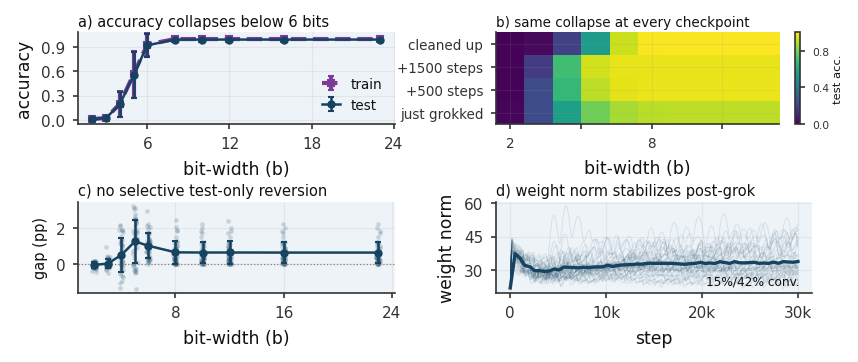

In [ ]:
def make_figure1(df_ptq, summaries, trajectory_info, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.2))
    gs = GridSpec(2, 2, figure=fig, left=0.09, right=0.98, top=0.90, bottom=0.11, hspace=0.85, wspace=0.32)
    ax_a, ax_b, ax_c, ax_d = [fig.add_subplot(gs[i]) for i in range(4)]

    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_c, ax_d]:
        ax.set_facecolor(panel_bg)

    sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition') & (df_ptq.phase == 'cleaned_up')]

    # Fixed: train and test accuracy are so close throughout (max gap 1.26pp -- this project's
    # own central finding) that identical solid linestyles left train invisible, plotted first
    # and then completely covered by test on top. This isn't a data bug -- the near-total overlap
    # IS the finding -- but a reader shouldn't need to already know that to trust the plot isn't
    # broken. Differentiating linestyle (train dashed + thicker, test solid + thinner) keeps both
    # curves simultaneously visible even when their values are nearly identical, confirmed with
    # the actual error bars included, not just the mean lines.
    if not sub.empty:
        agg_train = sub.groupby('bits')['q_train_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_a.errorbar(agg_train['bits'], agg_train['mean'], yerr=agg_train['std'].fillna(0), marker=MARKERS['train'],
                       color=COLORS['train'], label='train', linewidth=2.0, markersize=3.0, capsize=1.6,
                       linestyle='--', zorder=2)
        agg_test = sub.groupby('bits')['q_test_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_a.errorbar(agg_test['bits'], agg_test['mean'], yerr=agg_test['std'].fillna(0), marker=MARKERS['test'],
                       color=COLORS['test'], label='test', linewidth=1.2, markersize=3.0, capsize=1.6,
                       linestyle='-', zorder=3)
        ax_a.set_ylim(-0.05, 1.08)
        ax_a.legend(loc='lower right', fontsize=6.5, handlelength=1.3)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('bit-width (b)'); ax_a.set_ylabel('accuracy')
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'accuracy collapses below 6 bits')

    full_sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition')]
    phases_present = [ph for ph in PHASE_ORDER if ph in full_sub.phase.unique()]
    bits_present = sorted(full_sub.bits.unique())
    if phases_present and bits_present:
        grid = np.full((len(phases_present), len(bits_present)), np.nan)
        for i, ph in enumerate(phases_present):
            for j, b in enumerate(bits_present):
                vals = full_sub[(full_sub.phase == ph) & (full_sub.bits == b)]['q_test_acc']
                if len(vals):
                    grid[i, j] = vals.mean()
        im = ax_b.imshow(grid, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
        ax_b.set_xticks(range(len(bits_present))); ax_b.set_xticklabels(bits_present, fontsize=6.5)
        ax_b.set_yticks(range(len(phases_present)))
        ax_b.set_yticklabels([PHASE_LABELS[p].replace('\n', ' ') for p in phases_present], fontsize=6.5)
        cbar = fig.colorbar(im, ax=ax_b, fraction=0.055, pad=0.05)
        cbar.ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=3))
        cbar.ax.tick_params(labelsize=5.2)
        cbar.set_label('test acc.', fontsize=5.5, labelpad=2)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('bit-width (b)')
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'same collapse at every checkpoint')

    if not sub.empty:
        gap = sub.copy()
        gap['reversion_gap_pp'] = 100 * (gap['q_train_acc'] - gap['q_test_acc'])
        rng = np.random.RandomState(3)
        jx = gap['bits'].values + rng.uniform(-0.15, 0.15, size=len(gap))
        ax_c.scatter(jx, gap['reversion_gap_pp'].values, color=COLORS['cleaned_up'], alpha=0.18, s=5, linewidths=0, zorder=2)
        agg = gap.groupby('bits')['reversion_gap_pp'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_c.errorbar(agg['bits'], agg['mean'], yerr=agg['std'].fillna(0), marker='o', color=COLORS['cleaned_up'],
                       linewidth=1.2, markersize=3.0, capsize=1.6, zorder=3)
        ax_c.axhline(0, color='gray', linewidth=0.6, linestyle=':')
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('bit-width (b)'); ax_c.set_ylabel('gap (pp)', fontsize=7.0)
    tighten_ticks(ax_c, nbins=3)
    add_panel_label(ax_c, 'c', 'no selective test-only reversion')

    traj_rows = [t for t in trajectory_info if t['p'] == p_primary] if trajectory_info else []
    has_d = False
    if traj_rows:
        valid_traj = [t for t in traj_rows if t['weight_norm_history']]
        for t in valid_traj:
            wnh = t['weight_norm_history']
            steps = [s for s, v in wnh]
            vals = [v for s, v in wnh]
            ax_d.plot(steps, vals, color=COLORS['cleaned_up'], alpha=0.10, linewidth=0.5, zorder=1)
        if valid_traj:
            max_step_seen = max(max(s for s, v in t['weight_norm_history']) for t in valid_traj)
            common_steps = np.linspace(0, max_step_seen, 60)
            interp_vals = []
            for t in valid_traj:
                wnh = t['weight_norm_history']
                if len(wnh) < 2:
                    continue
                steps_arr = np.array([s for s, v in wnh])
                vals_arr = np.array([v for s, v in wnh])
                interp_vals.append(np.interp(common_steps, steps_arr, vals_arr, right=vals_arr[-1]))
            if interp_vals:
                mean_traj = np.mean(interp_vals, axis=0)
                ax_d.plot(common_steps, mean_traj, color=COLORS['cleaned_up'], linewidth=1.6, zorder=2)
                has_d = True
            conv_flags = [s.get('adaptive_converged') for s in summaries if s['p'] == p_primary and s.get('adaptive_converged') is not None]
            trend_flags = [s.get('adaptive_converged_trend') for s in summaries if s['p'] == p_primary and s.get('adaptive_converged_trend') is not None]
            if conv_flags:
                label = '{:.0%}/{:.0%} conv.'.format(np.mean(conv_flags), np.mean(trend_flags)) if trend_flags else '{:.0%} conv.'.format(np.mean(conv_flags))
                ax_d.text(0.96, 0.06, label, transform=ax_d.transAxes,
                           fontsize=5.8, ha='right', va='bottom')
    if not has_d:
        no_data_placeholder(ax_d)
    ax_d.set_xlabel('step'); ax_d.set_ylabel('weight norm')
    ax_d.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, pos: '{:.0f}k'.format(v / 1000) if v > 0 else '0'))
    tighten_ticks(ax_d, nbins=4)
    add_panel_label(ax_d, 'd', 'weight norm stabilizes post-grok')

    # SUPTITLE (kept as reference, not rendered): 'Quantization collapses train AND test together;
    # weight norm has plateaued (addition, p={p_primary})'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)

make_figure1(df_add_ptq, addition_summaries, addition_trajectory_info, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig1_phenomenon.pdf'))

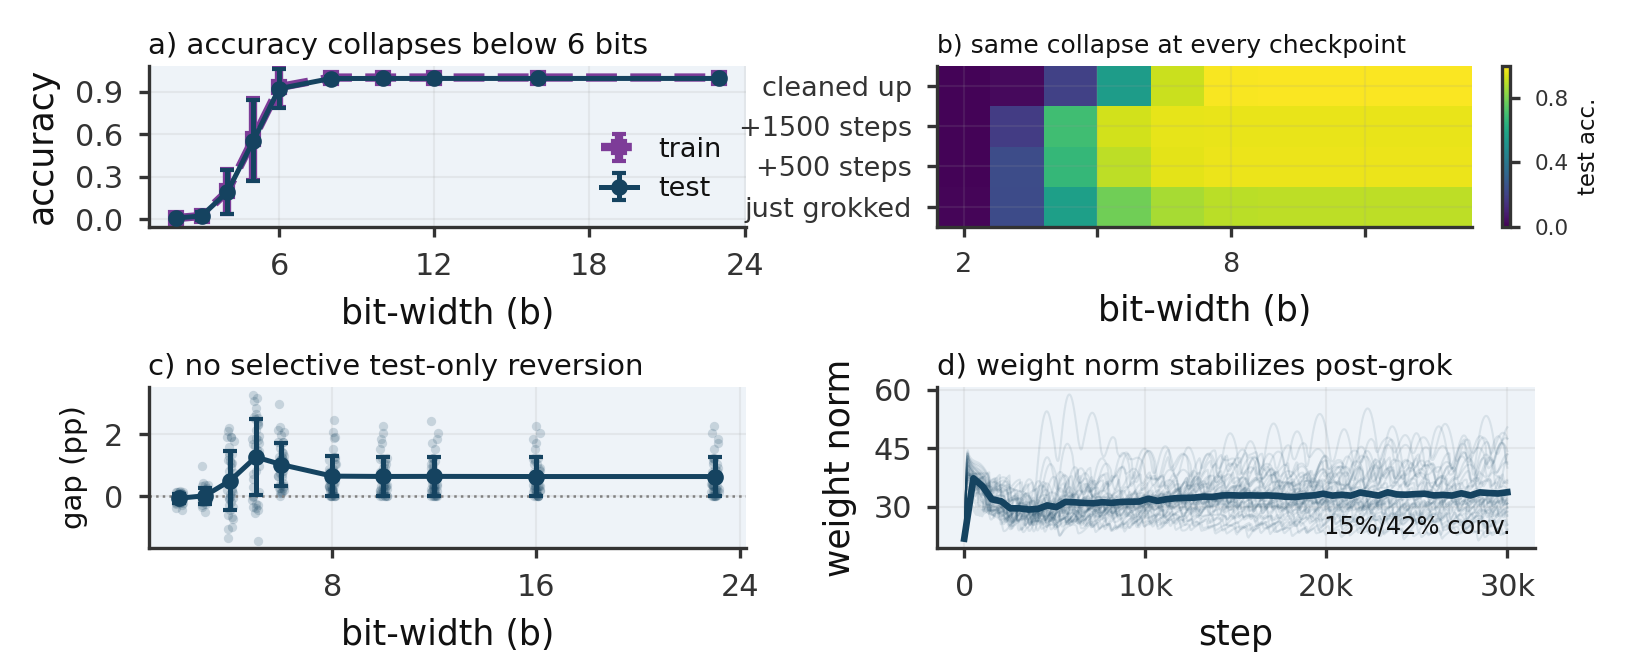

In [ ]:
def make_figure1(df_ptq, summaries, trajectory_info, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.2))
    # Fixed: bottom=0.11 caused a genuine bottom cutoff (+0.131in overflow, measured), right=0.98
    # cut off the colorbar (+0.157in). Widening bottom to 0.17 also required loosening hspace
    # (0.85->1.0) to avoid a new row-to-row collision the tighter vertical space introduced.
    gs = GridSpec(2, 2, figure=fig, left=0.09, right=0.93, top=0.90, bottom=0.17, hspace=1.0, wspace=0.32)
    ax_a, ax_b, ax_c, ax_d = [fig.add_subplot(gs[i]) for i in range(4)]
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_c, ax_d]:
        ax.set_facecolor(panel_bg)
    sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition') & (df_ptq.phase == 'cleaned_up')]
    # Fixed: train and test accuracy are so close throughout (max gap 1.26pp -- this project's
    # own central finding) that identical solid linestyles left train invisible, plotted first
    # and then completely covered by test on top. This isn't a data bug -- the near-total overlap
    # IS the finding -- but a reader shouldn't need to already know that to trust the plot isn't
    # broken. Differentiating linestyle (train dashed + thicker, test solid + thinner) keeps both
    # curves simultaneously visible even when their values are nearly identical, confirmed with
    # the actual error bars included, not just the mean lines.
    if not sub.empty:
        agg_train = sub.groupby('bits')['q_train_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_a.errorbar(agg_train['bits'], agg_train['mean'], yerr=agg_train['std'].fillna(0), marker=MARKERS['train'],
                       color=COLORS['train'], label='train', linewidth=2.0, markersize=3.0, capsize=1.6,
                       linestyle='--', zorder=2)
        agg_test = sub.groupby('bits')['q_test_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_a.errorbar(agg_test['bits'], agg_test['mean'], yerr=agg_test['std'].fillna(0), marker=MARKERS['test'],
                       color=COLORS['test'], label='test', linewidth=1.2, markersize=3.0, capsize=1.6,
                       linestyle='-', zorder=3)
        ax_a.set_ylim(-0.05, 1.08)
        ax_a.legend(loc='lower right', fontsize=6.5, handlelength=1.3)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('bit-width (b)'); ax_a.set_ylabel('accuracy')
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'accuracy collapses below 6 bits')
    full_sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition')]
    phases_present = [ph for ph in PHASE_ORDER if ph in full_sub.phase.unique()]
    bits_present = sorted(full_sub.bits.unique())
    if phases_present and bits_present:
        grid = np.full((len(phases_present), len(bits_present)), np.nan)
        for i, ph in enumerate(phases_present):
            for j, b in enumerate(bits_present):
                vals = full_sub[(full_sub.phase == ph) & (full_sub.bits == b)]['q_test_acc']
                if len(vals):
                    grid[i, j] = vals.mean()
        im = ax_b.imshow(grid, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
        ax_b.set_xticks(range(len(bits_present))); ax_b.set_xticklabels(bits_present, fontsize=6.5)
        ax_b.set_yticks(range(len(phases_present)))
        ax_b.set_yticklabels([PHASE_LABELS[p].replace('\n', ' ') for p in phases_present], fontsize=6.5)
        cbar = fig.colorbar(im, ax=ax_b, fraction=0.055, pad=0.05)
        cbar.ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=3))
        cbar.ax.tick_params(labelsize=5.2)
        cbar.set_label('test acc.', fontsize=5.5, labelpad=2)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('bit-width (b)')
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'same collapse at every checkpoint')
    if not sub.empty:
        gap = sub.copy()
        gap['reversion_gap_pp'] = 100 * (gap['q_train_acc'] - gap['q_test_acc'])
        rng = np.random.RandomState(3)
        jx = gap['bits'].values + rng.uniform(-0.15, 0.15, size=len(gap))
        ax_c.scatter(jx, gap['reversion_gap_pp'].values, color=COLORS['cleaned_up'], alpha=0.18, s=5, linewidths=0, zorder=2)
        agg = gap.groupby('bits')['reversion_gap_pp'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_c.errorbar(agg['bits'], agg['mean'], yerr=agg['std'].fillna(0), marker='o', color=COLORS['cleaned_up'],
                       linewidth=1.2, markersize=3.0, capsize=1.6, zorder=3)
        ax_c.axhline(0, color='gray', linewidth=0.6, linestyle=':')
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('bit-width (b)'); ax_c.set_ylabel('gap (pp)', fontsize=7.0)
    tighten_ticks(ax_c, nbins=3)
    add_panel_label(ax_c, 'c', 'no selective test-only reversion')
    traj_rows = [t for t in trajectory_info if t['p'] == p_primary] if trajectory_info else []
    has_d = False
    if traj_rows:
        valid_traj = [t for t in traj_rows if t['weight_norm_history']]
        for t in valid_traj:
            wnh = t['weight_norm_history']
            steps = [s for s, v in wnh]
            vals = [v for s, v in wnh]
            ax_d.plot(steps, vals, color=COLORS['cleaned_up'], alpha=0.10, linewidth=0.5, zorder=1)
        if valid_traj:
            max_step_seen = max(max(s for s, v in t['weight_norm_history']) for t in valid_traj)
            common_steps = np.linspace(0, max_step_seen, 60)
            interp_vals = []
            for t in valid_traj:
                wnh = t['weight_norm_history']
                if len(wnh) < 2:
                    continue
                steps_arr = np.array([s for s, v in wnh])
                vals_arr = np.array([v for s, v in wnh])
                interp_vals.append(np.interp(common_steps, steps_arr, vals_arr, right=vals_arr[-1]))
            if interp_vals:
                mean_traj = np.mean(interp_vals, axis=0)
                ax_d.plot(common_steps, mean_traj, color=COLORS['cleaned_up'], linewidth=1.6, zorder=2)
                has_d = True
            conv_flags = [s.get('adaptive_converged') for s in summaries if s['p'] == p_primary and s.get('adaptive_converged') is not None]
            trend_flags = [s.get('adaptive_converged_trend') for s in summaries if s['p'] == p_primary and s.get('adaptive_converged_trend') is not None]
            if conv_flags:
                label = '{:.0%}/{:.0%} conv.'.format(np.mean(conv_flags), np.mean(trend_flags)) if trend_flags else '{:.0%} conv.'.format(np.mean(conv_flags))
                ax_d.text(0.96, 0.06, label, transform=ax_d.transAxes,
                           fontsize=5.8, ha='right', va='bottom')
    if not has_d:
        no_data_placeholder(ax_d)
    ax_d.set_xlabel('step'); ax_d.set_ylabel('weight norm')
    ax_d.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, pos: '{:.0f}k'.format(v / 1000) if v > 0 else '0'))
    tighten_ticks(ax_d, nbins=4)
    add_panel_label(ax_d, 'd', 'weight norm stabilizes post-grok')
    # SUPTITLE (kept as reference, not rendered): 'Quantization collapses train AND test together;
    # weight norm has plateaued (addition, p={p_primary})'

    # Saves PDF + PNG directly, then displays that exact saved PNG (not a separate plt.show()
    # render) -- guarantees the notebook cell output and the downloaded zip file are the same file.
    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure1(df_add_ptq, addition_summaries, addition_trajectory_info, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig1_phenomenon.pdf'))

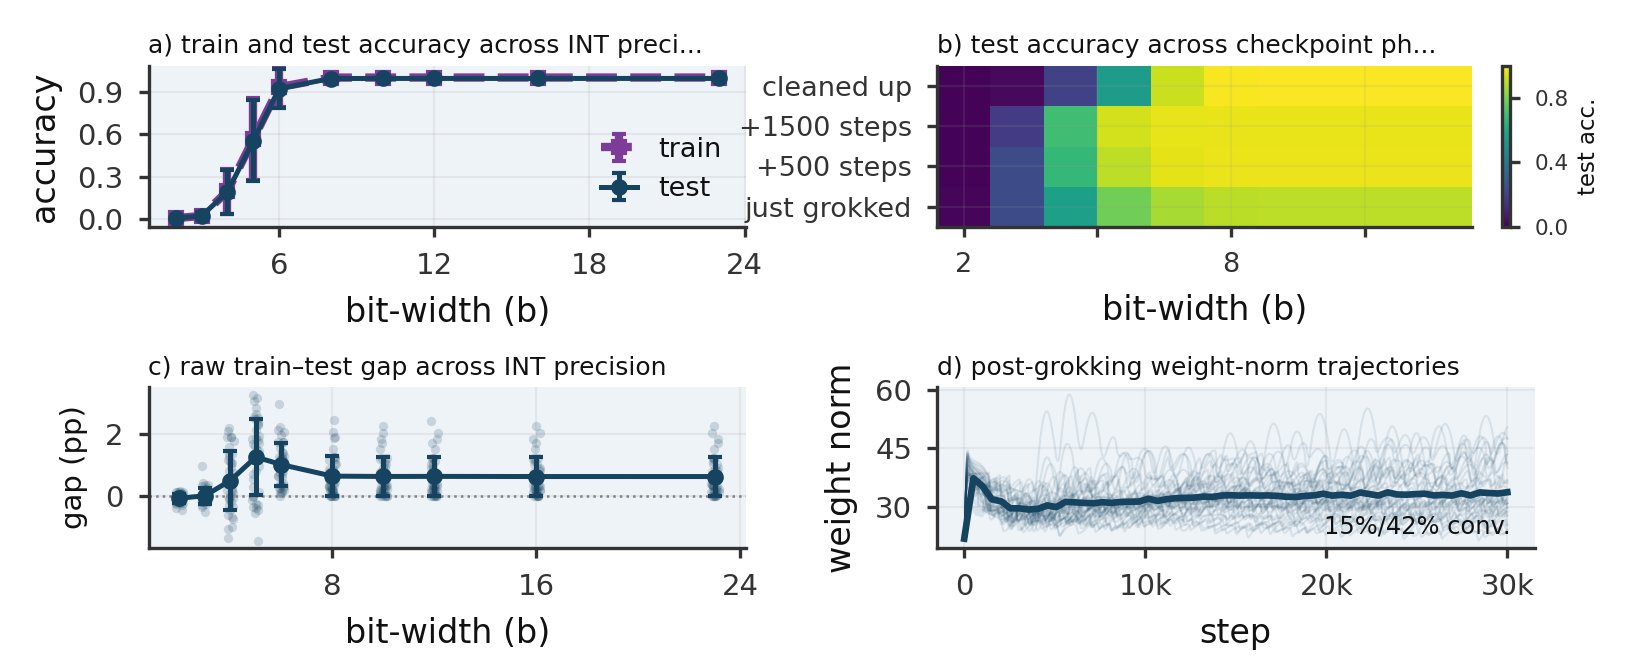

In [ ]:
def make_figure1(df_ptq, summaries, trajectory_info, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.2))
    # Fixed: bottom=0.11 caused a genuine bottom cutoff (+0.131in overflow, measured), right=0.98
    # cut off the colorbar (+0.157in). Widening bottom to 0.17 also required loosening hspace
    # (0.85->1.0) to avoid a new row-to-row collision the tighter vertical space introduced.
    gs = GridSpec(2, 2, figure=fig, left=0.09, right=0.93, top=0.90, bottom=0.17, hspace=1.0, wspace=0.32)
    ax_a, ax_b, ax_c, ax_d = [fig.add_subplot(gs[i]) for i in range(4)]
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_c, ax_d]:
        ax.set_facecolor(panel_bg)
    sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition') & (df_ptq.phase == 'cleaned_up')]
    # Fixed: train and test accuracy are so close throughout (max gap 1.26pp -- this project's
    # own central finding) that identical solid linestyles left train invisible, plotted first
    # and then completely covered by test on top. This isn't a data bug -- the near-total overlap
    # IS the finding -- but a reader shouldn't need to already know that to trust the plot isn't
    # broken. Differentiating linestyle (train dashed + thicker, test solid + thinner) keeps both
    # curves simultaneously visible even when their values are nearly identical, confirmed with
    # the actual error bars included, not just the mean lines.
    if not sub.empty:
        agg_train = sub.groupby('bits')['q_train_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_a.errorbar(agg_train['bits'], agg_train['mean'], yerr=agg_train['std'].fillna(0), marker=MARKERS['train'],
                       color=COLORS['train'], label='train', linewidth=2.0, markersize=3.0, capsize=1.6,
                       linestyle='--', zorder=2)
        agg_test = sub.groupby('bits')['q_test_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_a.errorbar(agg_test['bits'], agg_test['mean'], yerr=agg_test['std'].fillna(0), marker=MARKERS['test'],
                       color=COLORS['test'], label='test', linewidth=1.2, markersize=3.0, capsize=1.6,
                       linestyle='-', zorder=3)
        ax_a.set_ylim(-0.05, 1.08)
        ax_a.legend(loc='lower right', fontsize=6.5, handlelength=1.3)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('bit-width (b)'); ax_a.set_ylabel('accuracy')
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'train and test accuracy across INT precision')
    full_sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition')]
    phases_present = [ph for ph in PHASE_ORDER if ph in full_sub.phase.unique()]
    bits_present = sorted(full_sub.bits.unique())
    if phases_present and bits_present:
        grid = np.full((len(phases_present), len(bits_present)), np.nan)
        for i, ph in enumerate(phases_present):
            for j, b in enumerate(bits_present):
                vals = full_sub[(full_sub.phase == ph) & (full_sub.bits == b)]['q_test_acc']
                if len(vals):
                    grid[i, j] = vals.mean()
        im = ax_b.imshow(grid, aspect='auto', cmap='viridis', vmin=0, vmax=1, origin='lower')
        ax_b.set_xticks(range(len(bits_present))); ax_b.set_xticklabels(bits_present, fontsize=6.5)
        ax_b.set_yticks(range(len(phases_present)))
        ax_b.set_yticklabels([PHASE_LABELS[p].replace('\n', ' ') for p in phases_present], fontsize=6.5)
        cbar = fig.colorbar(im, ax=ax_b, fraction=0.055, pad=0.05)
        cbar.ax.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=3))
        cbar.ax.tick_params(labelsize=5.2)
        cbar.set_label('test acc.', fontsize=5.5, labelpad=2)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('bit-width (b)')
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'test accuracy across checkpoint phases')
    if not sub.empty:
        gap = sub.copy()
        gap['reversion_gap_pp'] = 100 * (gap['q_train_acc'] - gap['q_test_acc'])
        rng = np.random.RandomState(3)
        jx = gap['bits'].values + rng.uniform(-0.15, 0.15, size=len(gap))
        ax_c.scatter(jx, gap['reversion_gap_pp'].values, color=COLORS['cleaned_up'], alpha=0.18, s=5, linewidths=0, zorder=2)
        agg = gap.groupby('bits')['reversion_gap_pp'].agg(['mean', 'std']).reset_index().sort_values('bits')
        ax_c.errorbar(agg['bits'], agg['mean'], yerr=agg['std'].fillna(0), marker='o', color=COLORS['cleaned_up'],
                       linewidth=1.2, markersize=3.0, capsize=1.6, zorder=3)
        ax_c.axhline(0, color='gray', linewidth=0.6, linestyle=':')
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('bit-width (b)'); ax_c.set_ylabel('gap (pp)', fontsize=7.0)
    tighten_ticks(ax_c, nbins=3)
    add_panel_label(ax_c, 'c', 'raw train–test gap across INT precision')
    traj_rows = [t for t in trajectory_info if t['p'] == p_primary] if trajectory_info else []
    has_d = False
    if traj_rows:
        valid_traj = [t for t in traj_rows if t['weight_norm_history']]
        for t in valid_traj:
            wnh = t['weight_norm_history']
            steps = [s for s, v in wnh]
            vals = [v for s, v in wnh]
            ax_d.plot(steps, vals, color=COLORS['cleaned_up'], alpha=0.10, linewidth=0.5, zorder=1)
        if valid_traj:
            max_step_seen = max(max(s for s, v in t['weight_norm_history']) for t in valid_traj)
            common_steps = np.linspace(0, max_step_seen, 60)
            interp_vals = []
            for t in valid_traj:
                wnh = t['weight_norm_history']
                if len(wnh) < 2:
                    continue
                steps_arr = np.array([s for s, v in wnh])
                vals_arr = np.array([v for s, v in wnh])
                interp_vals.append(np.interp(common_steps, steps_arr, vals_arr, right=vals_arr[-1]))
            if interp_vals:
                mean_traj = np.mean(interp_vals, axis=0)
                ax_d.plot(common_steps, mean_traj, color=COLORS['cleaned_up'], linewidth=1.6, zorder=2)
                has_d = True
            conv_flags = [s.get('adaptive_converged') for s in summaries if s['p'] == p_primary and s.get('adaptive_converged') is not None]
            trend_flags = [s.get('adaptive_converged_trend') for s in summaries if s['p'] == p_primary and s.get('adaptive_converged_trend') is not None]
            if conv_flags:
                label = '{:.0%}/{:.0%} conv.'.format(np.mean(conv_flags), np.mean(trend_flags)) if trend_flags else '{:.0%} conv.'.format(np.mean(conv_flags))
                ax_d.text(0.96, 0.06, label, transform=ax_d.transAxes,
                           fontsize=5.8, ha='right', va='bottom')
    if not has_d:
        no_data_placeholder(ax_d)
    ax_d.set_xlabel('step'); ax_d.set_ylabel('weight norm')
    ax_d.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda v, pos: '{:.0f}k'.format(v / 1000) if v > 0 else '0'))
    tighten_ticks(ax_d, nbins=4)
    add_panel_label(ax_d, 'd', 'post-grokking weight-norm trajectories')
    # SUPTITLE (kept as reference, not rendered): 'Quantization collapses train AND test together;
    # weight norm has plateaued (addition, p={p_primary})'

    # Saves PDF + PNG directly, then displays that exact saved PNG (not a separate plt.show()
    # render) -- guarantees the notebook cell output and the downloaded zip file are the same file.
    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure1(df_add_ptq, addition_summaries, addition_trajectory_info, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig1_phenomenon.pdf'))

### Figure 2: H6 -- fine-grained hunt for genuine ungrokking


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig2_fine_grained_hunt.pdf


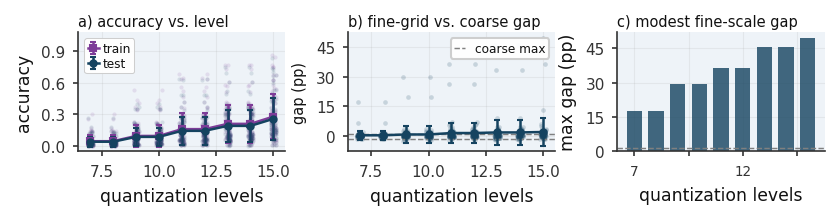

In [ ]:
def make_figure2(df_fine, coarse_max_gap, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 1.80))
    gs = GridSpec(1, 3, figure=fig, left=0.08, right=0.985, top=0.70, bottom=0.26, wspace=0.30)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    has_data = not df_fine.empty
    if has_data:
        for metric, color, marker, label in [('q_train_acc', COLORS['train'], MARKERS['train'], 'train'),
                                               ('q_test_acc', COLORS['test'], MARKERS['test'], 'test')]:
            agg = df_fine.groupby('n_levels')[metric].agg(['mean', 'std']).reset_index().sort_values('n_levels')
            rng = np.random.RandomState(5)
            jx = df_fine['n_levels'].values + rng.uniform(-0.12, 0.12, size=len(df_fine))
            ax_a.scatter(jx, df_fine[metric].values, color=color, alpha=0.12, s=4, linewidths=0, zorder=2)
            ax_a.errorbar(agg['n_levels'], agg['mean'], yerr=agg['std'].fillna(0), marker=marker, color=color,
                           label=label, linewidth=1.2, markersize=3.0, capsize=1.6, zorder=3)
        ax_a.set_ylim(-0.05, 1.08)
        # Moved to top-left inside the panel, opaque background so it stays readable against the
        # scattered points behind it -- height (1.80in) is too tight to move this above the panel
        # entirely without eating into plot area, so it stays inside but relocated and protected.
        leg = ax_a.legend(loc='upper left', fontsize=5.8, handlelength=0.9, labelspacing=0.15,
                           handletextpad=0.3, borderpad=0.3, frameon=True, facecolor='white',
                           edgecolor='#cccccc', framealpha=0.95)
        leg.get_frame().set_linewidth(0.5)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('quantization levels'); ax_a.set_ylabel('accuracy')
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'accuracy vs. level')
    if has_data:
        gap = df_fine.copy()
        gap['gap_pp'] = 100 * (gap['q_train_acc'] - gap['q_test_acc'])
        rng = np.random.RandomState(6)
        jx = gap['n_levels'].values + rng.uniform(-0.12, 0.12, size=len(gap))
        ax_b.scatter(jx, gap['gap_pp'].values, color=COLORS['cleaned_up'], alpha=0.18, s=5, linewidths=0, zorder=2)
        agg = gap.groupby('n_levels')['gap_pp'].agg(['mean', 'std']).reset_index().sort_values('n_levels')
        ax_b.errorbar(agg['n_levels'], agg['mean'], yerr=agg['std'].fillna(0), marker='o', color=COLORS['cleaned_up'],
                       linewidth=1.2, markersize=3.0, capsize=1.6, zorder=3)
        if not np.isnan(coarse_max_gap):
            ax_b.axhline(coarse_max_gap, color='gray', linewidth=0.7, linestyle='--')
            ax_b.axhline(-coarse_max_gap, color='gray', linewidth=0.7, linestyle='--', label='coarse max')
            ax_b.legend(loc='upper right', fontsize=5.8, handlelength=0.9, frameon=True,
                        facecolor='white', edgecolor='#cccccc', framealpha=0.95, borderpad=0.3)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('quantization levels'); ax_b.set_ylabel('gap (pp)', fontsize=7.0)
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'fine-grid vs. coarse gap')
    if has_data:
        levels_sorted = sorted(df_fine['n_levels'].unique())
        max_gaps = []
        for lv in levels_sorted:
            sub_lv = df_fine[df_fine.n_levels == lv]
            g = 100 * (sub_lv['q_train_acc'] - sub_lv['q_test_acc'])
            max_gaps.append(g.abs().max())
        ax_c.bar(range(len(levels_sorted)), max_gaps, color=COLORS['cleaned_up'], alpha=0.8, width=0.7)
        ax_c.set_xticks(range(len(levels_sorted))); ax_c.set_xticklabels(levels_sorted, fontsize=6.5)
        if not np.isnan(coarse_max_gap):
            ax_c.axhline(coarse_max_gap, color='gray', linewidth=0.7, linestyle='--')
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('quantization levels'); ax_c.set_ylabel('max gap (pp)')
    tighten_ticks(ax_c)
    add_panel_label(ax_c, 'c', 'modest fine-scale gap')
    # SUPTITLE (kept as reference, not rendered): 'H6: hunting for genuine ungrokking between bits=3 (7 lvl) and bits=4 (15 lvl)'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)
_coarse_gap = stats_report.get('h1_max_train_test_gap_pp_coarse_grid', float('nan'))
make_figure2(df_add_fine, _coarse_gap, os.path.join(OUTPUT_ROOT, 'figures', 'fig2_fine_grained_hunt.pdf'))

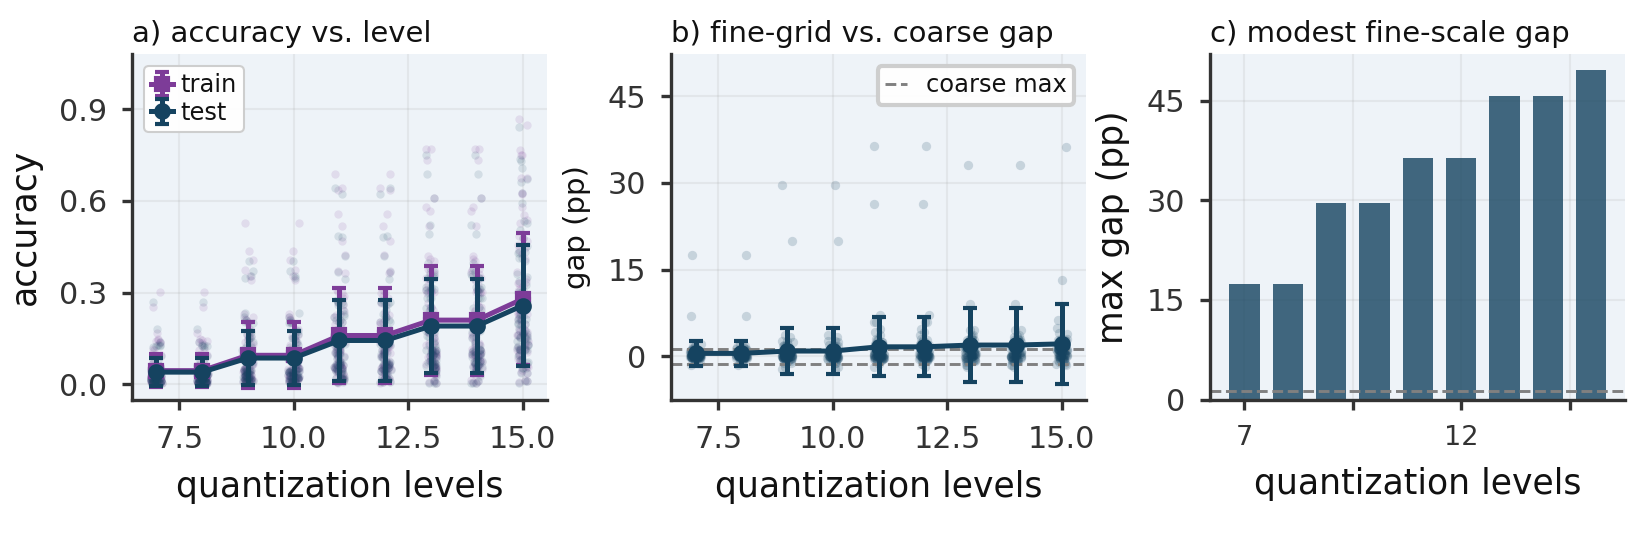

In [ ]:
def make_figure2(df_fine, coarse_max_gap, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 1.80))
    # Fixed: top=0.70 wasted -0.418in of blank space above the content (measured).
    gs = GridSpec(1, 3, figure=fig, left=0.08, right=0.985, top=0.90, bottom=0.26, wspace=0.30)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    has_data = not df_fine.empty
    if has_data:
        for metric, color, marker, label in [('q_train_acc', COLORS['train'], MARKERS['train'], 'train'),
                                               ('q_test_acc', COLORS['test'], MARKERS['test'], 'test')]:
            agg = df_fine.groupby('n_levels')[metric].agg(['mean', 'std']).reset_index().sort_values('n_levels')
            rng = np.random.RandomState(5)
            jx = df_fine['n_levels'].values + rng.uniform(-0.12, 0.12, size=len(df_fine))
            ax_a.scatter(jx, df_fine[metric].values, color=color, alpha=0.12, s=4, linewidths=0, zorder=2)
            ax_a.errorbar(agg['n_levels'], agg['mean'], yerr=agg['std'].fillna(0), marker=marker, color=color,
                           label=label, linewidth=1.2, markersize=3.0, capsize=1.6, zorder=3)
        ax_a.set_ylim(-0.05, 1.08)
        leg = ax_a.legend(loc='upper left', fontsize=5.8, handlelength=0.9, labelspacing=0.15,
                           handletextpad=0.3, borderpad=0.3, frameon=True, facecolor='white',
                           edgecolor='#cccccc', framealpha=0.95)
        leg.get_frame().set_linewidth(0.5)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('quantization levels'); ax_a.set_ylabel('accuracy')
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'accuracy vs. level')
    if has_data:
        gap = df_fine.copy()
        gap['gap_pp'] = 100 * (gap['q_train_acc'] - gap['q_test_acc'])
        rng = np.random.RandomState(6)
        jx = gap['n_levels'].values + rng.uniform(-0.12, 0.12, size=len(gap))
        ax_b.scatter(jx, gap['gap_pp'].values, color=COLORS['cleaned_up'], alpha=0.18, s=5, linewidths=0, zorder=2)
        agg = gap.groupby('n_levels')['gap_pp'].agg(['mean', 'std']).reset_index().sort_values('n_levels')
        ax_b.errorbar(agg['n_levels'], agg['mean'], yerr=agg['std'].fillna(0), marker='o', color=COLORS['cleaned_up'],
                       linewidth=1.2, markersize=3.0, capsize=1.6, zorder=3)
        if not np.isnan(coarse_max_gap):
            ax_b.axhline(coarse_max_gap, color='gray', linewidth=0.7, linestyle='--')
            ax_b.axhline(-coarse_max_gap, color='gray', linewidth=0.7, linestyle='--', label='coarse max')
            ax_b.legend(loc='upper right', fontsize=5.8, handlelength=0.9, frameon=True,
                        facecolor='white', edgecolor='#cccccc', framealpha=0.95, borderpad=0.3)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('quantization levels'); ax_b.set_ylabel('gap (pp)', fontsize=7.0)
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'fine-grid vs. coarse gap')
    if has_data:
        levels_sorted = sorted(df_fine['n_levels'].unique())
        max_gaps = []
        for lv in levels_sorted:
            sub_lv = df_fine[df_fine.n_levels == lv]
            g = 100 * (sub_lv['q_train_acc'] - sub_lv['q_test_acc'])
            max_gaps.append(g.abs().max())
        ax_c.bar(range(len(levels_sorted)), max_gaps, color=COLORS['cleaned_up'], alpha=0.8, width=0.7)
        ax_c.set_xticks(range(len(levels_sorted))); ax_c.set_xticklabels(levels_sorted, fontsize=6.5)
        if not np.isnan(coarse_max_gap):
            ax_c.axhline(coarse_max_gap, color='gray', linewidth=0.7, linestyle='--')
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('quantization levels'); ax_c.set_ylabel('max gap (pp)')
    tighten_ticks(ax_c)
    add_panel_label(ax_c, 'c', 'modest fine-scale gap')
    # SUPTITLE (kept as reference, not rendered): 'H6: hunting for genuine ungrokking between bits=3 (7 lvl) and bits=4 (15 lvl)'

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

_coarse_gap = stats_report.get('h1_max_train_test_gap_pp_coarse_grid', float('nan'))
make_figure2(df_add_fine, _coarse_gap, os.path.join(OUTPUT_ROOT, 'figures', 'fig2_fine_grained_hunt.pdf'))

### Figure 3: Mechanism with the init-checkpoint control (Panel C bug fixed: distinct colors, not a list-valued alpha)


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig3_mechanism.pdf


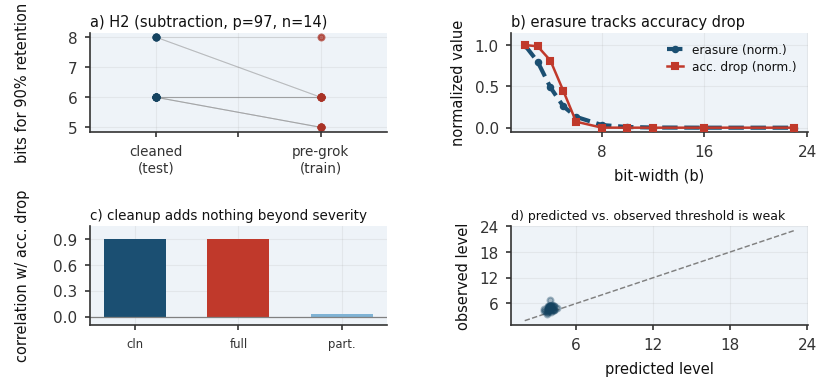

In [ ]:
def align_ylabels_left(fig, axes):
    """Force the given axes' y-labels to share the same horizontal position. Matplotlib's
    automatic placement depends on each axes' own tick-label widths, and same-column panels
    can end up visibly misaligned when their tick content differs (e.g., integers vs decimals)."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    xs_px = [ax.yaxis.label.get_window_extent(renderer=renderer).x0 for ax in axes]
    target_px = min(xs_px)
    for ax in axes:
        bbox = ax.get_position()
        ax_left_px = bbox.x0 * fig.bbox.width
        ax_width_px = bbox.width * fig.bbox.width
        axes_fraction_x = (target_px - ax_left_px) / ax_width_px
        ax.yaxis.set_label_coords(axes_fraction_x, 0.5, transform=ax.transAxes)
    fig.canvas.draw()


def make_figure3(df_ptq, df_mech, df_h2_ptq, df_h2_summary, h2_task_label, h2_p, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.6))
    gs = GridSpec(2, 2, figure=fig, left=0.10, right=0.97, top=0.88, bottom=0.13, hspace=0.95, wspace=0.42)
    ax_a, ax_b, ax_c, ax_d = [fig.add_subplot(gs[i]) for i in range(4)]
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c, ax_d]:
        ax.set_facecolor(panel_bg)

    b90_test = bits_to_retain_90pct(df_h2_ptq, 'cleaned_up', 'q_test_acc', h2_p)
    b90_train = bits_to_retain_90pct(df_h2_ptq, 'pre_grok', 'q_train_acc', h2_p)
    # Grokked-only filtered -- a seed that captured pre_grok but never went on to actually grok
    # would compare memorization against more memorization, not against generalization (the same
    # contamination this exact comparison was found to have in Section 7's evaluation before that
    # fix -- this panel had its own separate, unfiltered computation needing the identical correction).
    grokked_seeds = set(df_h2_summary[(df_h2_summary.p == h2_p) & (df_h2_summary.grokked == True)]['seed']) if not df_h2_summary.empty else set()
    common = sorted(set(b90_test) & set(b90_train) & grokked_seeds)
    paired = [(b90_test[s], b90_train[s]) for s in common if not (np.isnan(b90_test[s]) or np.isnan(b90_train[s]))]
    if paired:
        for cv, pv in paired:
            ax_a.plot([0, 1], [cv, pv], color='gray', alpha=0.2, linewidth=0.5, zorder=1)
        ax_a.scatter([0] * len(paired), [x[0] for x in paired], color=COLORS['cleaned_up'], zorder=2, s=8, alpha=0.7)
        ax_a.scatter([1] * len(paired), [x[1] for x in paired], color=COLORS['pre_grok'], zorder=2, s=8, alpha=0.7)
        ax_a.set_xlim(-0.4, 1.4)
        ax_a.set_xticks([0, 1]); ax_a.set_xticklabels(['cleaned\n(test)', 'pre-grok\n(train)'], fontsize=6.5)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_ylabel('bits for 90% retention', fontsize=7.0)
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'H2 ({}, p={}, n={})'.format(h2_task_label, h2_p, len(paired)))

    sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.phase == 'cleaned_up') & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition')].copy()
    mech_sub = df_mech[df_mech.p == p_primary] if not df_mech.empty else pd.DataFrame()
    if not sub.empty and not mech_sub.empty:
        sub['accuracy_drop'] = sub['fp32_test_acc'] - sub['q_test_acc']
        drop_agg = sub.groupby('bits')['accuracy_drop'].mean().reset_index().sort_values('bits')
        eras_agg = mech_sub.groupby('bits')['erasure_cleanup'].mean().reset_index().sort_values('bits')
        eras_norm = eras_agg['erasure_cleanup'] / max(eras_agg['erasure_cleanup'].max(), 1e-9)
        drop_norm = drop_agg['accuracy_drop'] / max(drop_agg['accuracy_drop'].max(), 1e-9)
        ax_b.plot(eras_agg['bits'], eras_norm, color=COLORS['int'], marker='o', markersize=2.6,
                  linewidth=2.0, linestyle='--', label='erasure (norm.)', zorder=2)
        ax_b.plot(drop_agg['bits'], drop_norm, color=COLORS['mantissa'], marker='s', markersize=2.6,
                  linewidth=1.2, linestyle='-', label='acc. drop (norm.)', zorder=3)
        # Fixed: moved back inside the panel as a two-line (single-column) legend, so it no
        # longer takes space above the axes. 'upper right' is the only region both curves leave
        # genuinely empty -- they peak near bit-width=2 (left) and flatten near bit-width=23
        # (bottom-right), so top-right stays clear at every point along both curves.
        ax_b.legend(loc='upper right', ncol=1, fontsize=5.8, handlelength=1.3, labelspacing=0.3, frameon=False)
        ax_b.set_ylim(-0.05, 1.15)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('bit-width (b)', fontsize=7.0); ax_b.set_ylabel('normalized value', fontsize=7.0)
    ax_b.set_yticks([0.0, 0.5, 1.0])
    tighten_ticks(ax_b, y=False, nbins=3)
    add_panel_label(ax_b, 'b', 'erasure tracks accuracy drop')

    if not sub.empty and not mech_sub.empty:
        merged = mech_sub.merge(sub[['p', 'seed', 'task', 'bits', 'fp32_test_acc', 'q_test_acc']], on=['p', 'seed', 'task', 'bits'], how='inner')
        merged['accuracy_drop'] = merged['fp32_test_acc'] - merged['q_test_acc']
        if len(merged) >= 5:
            rho_c, _ = stats.spearmanr(merged['erasure_cleanup'], merged['accuracy_drop'])
            rho_f, _ = stats.spearmanr(merged['erasure_fulltrain'], merged['accuracy_drop'])
            rho_p = partial_spearman(merged['erasure_cleanup'], merged['accuracy_drop'], merged['erasure_fulltrain'])
            bar_colors = ['#1b4f72', '#c0392b', '#7fb3d5']
            ax_c.bar(['cln', 'full', 'part.'], [rho_c, rho_f, rho_p], color=bar_colors, width=0.6)
            ax_c.tick_params(axis='x', rotation=0)
            ax_c.axhline(0, color='gray', linewidth=0.6)
            ax_c.tick_params(axis='x', labelsize=5.6)
            lo_val = min(rho_c, rho_f, rho_p, 0) - 0.1
            hi_val = max(rho_c, rho_f, rho_p) + 0.15
            ax_c.set_ylim(lo_val, hi_val)
        else:
            no_data_placeholder(ax_c)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_ylabel('correlation w/ acc. drop', fontsize=7.0)
    tighten_ticks(ax_c, x=False)
    add_panel_label(ax_c, 'c', 'cleanup adds nothing beyond severity')

    if not sub.empty and not mech_sub.empty:
        merged2 = mech_sub.merge(sub[['p', 'seed', 'task', 'bits', 'q_test_acc']], on=['p', 'seed', 'task', 'bits'], how='inner')
        pts = []
        for (p_, seed_), g in merged2.groupby(['p', 'seed']):
            g = g.sort_values('bits')
            bp = interp_crossing(g['bits'].values, g['erasure_cleanup'].values, 0.5)
            bo = interp_crossing(g['bits'].values, g['q_test_acc'].values, 0.5)
            if not (np.isnan(bp) or np.isnan(bo)):
                pts.append((bp, bo))
        if pts:
            xs, ys = zip(*pts)
            ax_d.scatter(xs, ys, color=COLORS['cleaned_up'], alpha=0.35, s=8, zorder=2)
            lo, hi = min(BIT_WIDTHS), max(BIT_WIDTHS)
            ax_d.plot([lo, hi], [lo, hi], '--', color='gray', linewidth=0.7, zorder=1)
        else:
            no_data_placeholder(ax_d)
    else:
        no_data_placeholder(ax_d)
    ax_d.set_xlabel('predicted level', fontsize=7.0); ax_d.set_ylabel('observed level', fontsize=7.0)
    tighten_ticks(ax_d)
    add_panel_label(ax_d, 'd', 'predicted vs. observed threshold is weak')

    align_ylabels_left(fig, [ax_a, ax_c])

    # SUPTITLE (kept as reference, not rendered): 'H3 mechanism with init-checkpoint control, addition, p={}'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)

make_figure3(df_add_ptq, df_add_mech, df_sub_ptq, df_sub_summary, 'subtraction', P_PRIMARY, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig3_mechanism.pdf'))

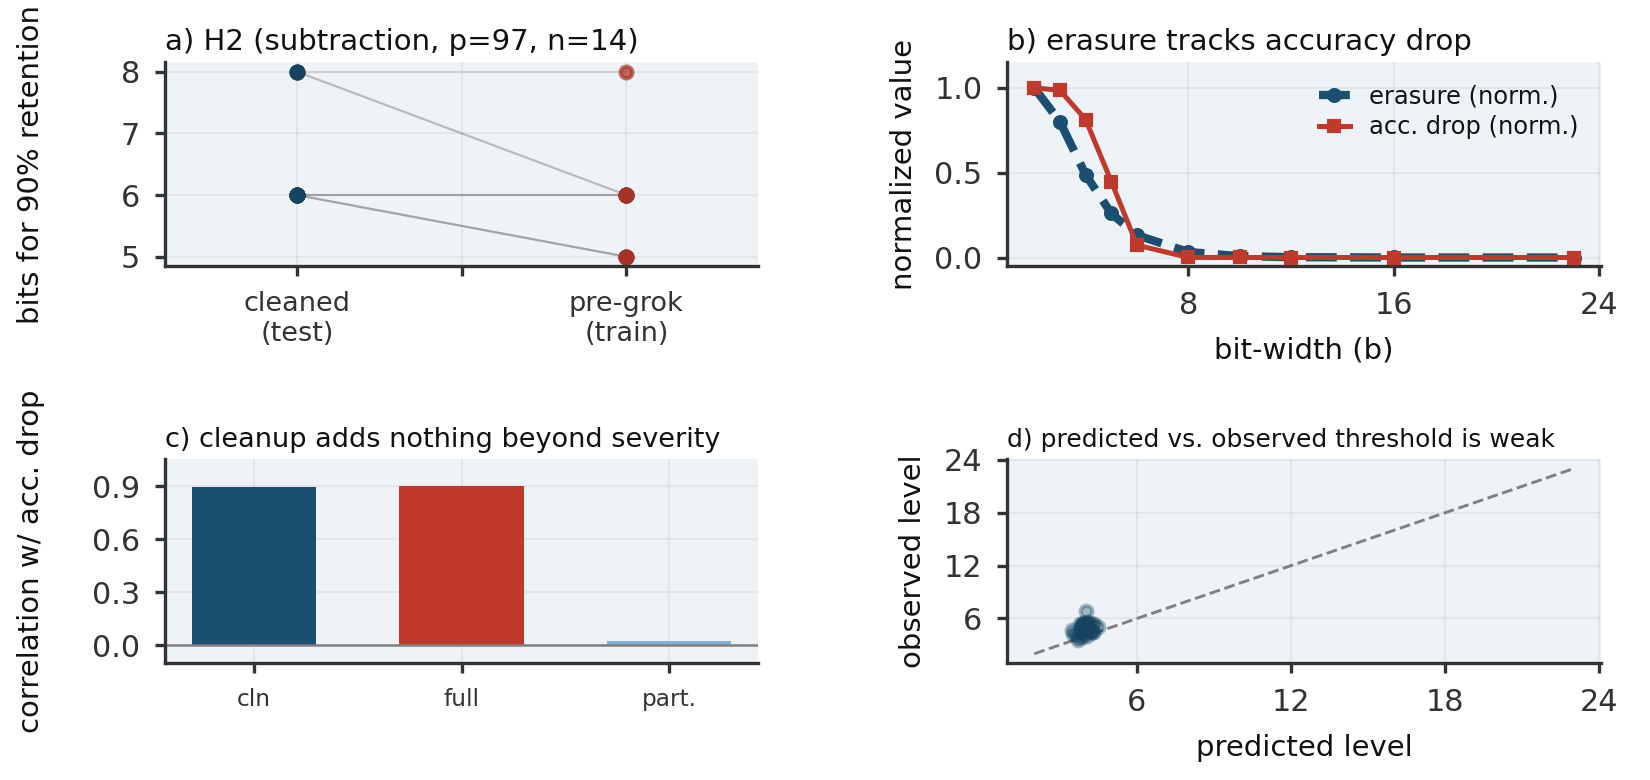

In [ ]:
def align_ylabels_left(fig, axes):
    """Force the given axes' y-labels to share the same horizontal position. Matplotlib's
    automatic placement depends on each axes' own tick-label widths, and same-column panels
    can end up visibly misaligned when their tick content differs (e.g., integers vs decimals)."""
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    xs_px = [ax.yaxis.label.get_window_extent(renderer=renderer).x0 for ax in axes]
    target_px = min(xs_px)
    for ax in axes:
        bbox = ax.get_position()
        ax_left_px = bbox.x0 * fig.bbox.width
        ax_width_px = bbox.width * fig.bbox.width
        axes_fraction_x = (target_px - ax_left_px) / ax_width_px
        ax.yaxis.set_label_coords(axes_fraction_x, 0.5, transform=ax.transAxes)
    fig.canvas.draw()

def make_figure3(df_ptq, df_mech, df_h2_ptq, df_h2_summary, h2_task_label, h2_p, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.6))
    # Fixed: bottom=0.13 caused a tiny cutoff (+0.015in), top=0.88 wasted -0.190in.
    gs = GridSpec(2, 2, figure=fig, left=0.10, right=0.97, top=0.92, bottom=0.15, hspace=0.95, wspace=0.42)
    ax_a, ax_b, ax_c, ax_d = [fig.add_subplot(gs[i]) for i in range(4)]
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c, ax_d]:
        ax.set_facecolor(panel_bg)
    b90_test = bits_to_retain_90pct(df_h2_ptq, 'cleaned_up', 'q_test_acc', h2_p)
    b90_train = bits_to_retain_90pct(df_h2_ptq, 'pre_grok', 'q_train_acc', h2_p)
    # Grokked-only filtered -- a seed that captured pre_grok but never went on to actually grok
    # would compare memorization against more memorization, not against generalization (the same
    # contamination this exact comparison was found to have in Section 7's evaluation before that
    # fix -- this panel had its own separate, unfiltered computation needing the identical correction).
    grokked_seeds = set(df_h2_summary[(df_h2_summary.p == h2_p) & (df_h2_summary.grokked == True)]['seed']) if not df_h2_summary.empty else set()
    common = sorted(set(b90_test) & set(b90_train) & grokked_seeds)
    paired = [(b90_test[s], b90_train[s]) for s in common if not (np.isnan(b90_test[s]) or np.isnan(b90_train[s]))]
    if paired:
        for cv, pv in paired:
            ax_a.plot([0, 1], [cv, pv], color='gray', alpha=0.2, linewidth=0.5, zorder=1)
        ax_a.scatter([0] * len(paired), [x[0] for x in paired], color=COLORS['cleaned_up'], zorder=2, s=8, alpha=0.7)
        ax_a.scatter([1] * len(paired), [x[1] for x in paired], color=COLORS['pre_grok'], zorder=2, s=8, alpha=0.7)
        ax_a.set_xlim(-0.4, 1.4)
        ax_a.set_xticks([0, 1]); ax_a.set_xticklabels(['cleaned\n(test)', 'pre-grok\n(train)'], fontsize=6.5)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_ylabel('bits for 90% retention', fontsize=7.0)
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'H2 ({}, p={}, n={})'.format(h2_task_label, h2_p, len(paired)))
    sub = df_ptq[(df_ptq.p == p_primary) & (df_ptq.phase == 'cleaned_up') & (df_ptq.scheme == 'int') & (df_ptq.task == 'addition')].copy()
    mech_sub = df_mech[df_mech.p == p_primary] if not df_mech.empty else pd.DataFrame()
    if not sub.empty and not mech_sub.empty:
        sub['accuracy_drop'] = sub['fp32_test_acc'] - sub['q_test_acc']
        drop_agg = sub.groupby('bits')['accuracy_drop'].mean().reset_index().sort_values('bits')
        eras_agg = mech_sub.groupby('bits')['erasure_cleanup'].mean().reset_index().sort_values('bits')
        eras_norm = eras_agg['erasure_cleanup'] / max(eras_agg['erasure_cleanup'].max(), 1e-9)
        drop_norm = drop_agg['accuracy_drop'] / max(drop_agg['accuracy_drop'].max(), 1e-9)
        ax_b.plot(eras_agg['bits'], eras_norm, color=COLORS['int'], marker='o', markersize=2.6,
                  linewidth=2.0, linestyle='--', label='erasure (norm.)', zorder=2)
        ax_b.plot(drop_agg['bits'], drop_norm, color=COLORS['mantissa'], marker='s', markersize=2.6,
                  linewidth=1.2, linestyle='-', label='acc. drop (norm.)', zorder=3)
        ax_b.legend(loc='upper right', ncol=1, fontsize=5.8, handlelength=1.3, labelspacing=0.3, frameon=False)
        ax_b.set_ylim(-0.05, 1.15)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('bit-width (b)', fontsize=7.0); ax_b.set_ylabel('normalized value', fontsize=7.0)
    ax_b.set_yticks([0.0, 0.5, 1.0])
    tighten_ticks(ax_b, y=False, nbins=3)
    add_panel_label(ax_b, 'b', 'erasure tracks accuracy drop')
    if not sub.empty and not mech_sub.empty:
        merged = mech_sub.merge(sub[['p', 'seed', 'task', 'bits', 'fp32_test_acc', 'q_test_acc']], on=['p', 'seed', 'task', 'bits'], how='inner')
        merged['accuracy_drop'] = merged['fp32_test_acc'] - merged['q_test_acc']
        if len(merged) >= 5:
            rho_c, _ = stats.spearmanr(merged['erasure_cleanup'], merged['accuracy_drop'])
            rho_f, _ = stats.spearmanr(merged['erasure_fulltrain'], merged['accuracy_drop'])
            rho_p = partial_spearman(merged['erasure_cleanup'], merged['accuracy_drop'], merged['erasure_fulltrain'])
            bar_colors = ['#1b4f72', '#c0392b', '#7fb3d5']
            ax_c.bar(['cln', 'full', 'part.'], [rho_c, rho_f, rho_p], color=bar_colors, width=0.6)
            ax_c.tick_params(axis='x', rotation=0)
            ax_c.axhline(0, color='gray', linewidth=0.6)
            ax_c.tick_params(axis='x', labelsize=5.6)
            lo_val = min(rho_c, rho_f, rho_p, 0) - 0.1
            hi_val = max(rho_c, rho_f, rho_p) + 0.15
            ax_c.set_ylim(lo_val, hi_val)
        else:
            no_data_placeholder(ax_c)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_ylabel('correlation w/ acc. drop', fontsize=7.0)
    tighten_ticks(ax_c, x=False)
    add_panel_label(ax_c, 'c', 'cleanup adds nothing beyond severity')
    if not sub.empty and not mech_sub.empty:
        merged2 = mech_sub.merge(sub[['p', 'seed', 'task', 'bits', 'q_test_acc']], on=['p', 'seed', 'task', 'bits'], how='inner')
        pts = []
        for (p_, seed_), g in merged2.groupby(['p', 'seed']):
            g = g.sort_values('bits')
            bp = interp_crossing(g['bits'].values, g['erasure_cleanup'].values, 0.5)
            bo = interp_crossing(g['bits'].values, g['q_test_acc'].values, 0.5)
            if not (np.isnan(bp) or np.isnan(bo)):
                pts.append((bp, bo))
        if pts:
            xs, ys = zip(*pts)
            ax_d.scatter(xs, ys, color=COLORS['cleaned_up'], alpha=0.35, s=8, zorder=2)
            lo, hi = min(BIT_WIDTHS), max(BIT_WIDTHS)
            ax_d.plot([lo, hi], [lo, hi], '--', color='gray', linewidth=0.7, zorder=1)
        else:
            no_data_placeholder(ax_d)
    else:
        no_data_placeholder(ax_d)
    ax_d.set_xlabel('predicted level', fontsize=7.0); ax_d.set_ylabel('observed level', fontsize=7.0)
    tighten_ticks(ax_d)
    add_panel_label(ax_d, 'd', 'predicted vs. observed threshold is weak')
    align_ylabels_left(fig, [ax_a, ax_c])
    # SUPTITLE (kept as reference, not rendered): 'H3 mechanism with init-checkpoint control, addition, p={}'

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure3(df_add_ptq, df_add_mech, df_sub_ptq, df_sub_summary, 'subtraction', P_PRIMARY, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig3_mechanism.pdf'))

### Figure 4: Localization and generality


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig4_generality.pdf


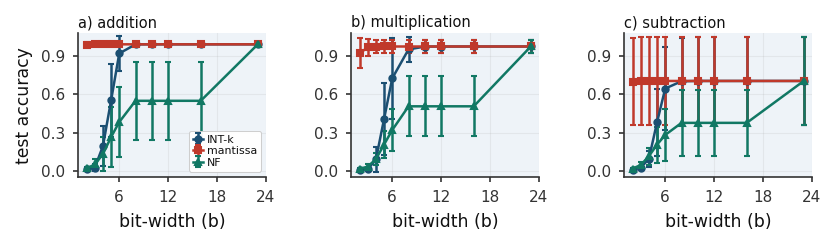

In [ ]:
def make_figure4(df_add_ptq, df_mult_ptq, df_sub_ptq, p_primary, save_path):
    # Redesigned: 3 panels (one per task), schemes overlaid as lines within each panel, rather
    # than a 3x3 grid of 9 separate mini-plots. The old 9-cell grid gave each panel only about
    # 1.6in x 0.9in -- too little room for legible axis labels, tick labels, and a panel caption
    # together, especially once font sizes were raised to match the paper's 10pt body text (ICLR's
    # actual formatting spec, not an assumption). Overlaying schemes within one panel per task also
    # makes the key finding -- mantissa behaves differently from int/nf -- directly visible as one
    # line diverging from two similar ones, rather than requiring a reader to compare across
    # separate small subplots.
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.98, top=0.72, bottom=0.24, wspace=0.45)
    tasks = ['addition', 'multiplication', 'subtraction']
    task_dfs = {'addition': df_add_ptq, 'multiplication': df_mult_ptq, 'subtraction': df_sub_ptq}
    scheme_labels = {'int': 'INT-k', 'mantissa': 'mantissa', 'nf': 'NF'}
    scheme_markers = {'int': 'o', 'mantissa': 's', 'nf': '^'}
    panel_bg = '#eef3f8'
    for col, task in enumerate(tasks):
        ax = fig.add_subplot(gs[col])
        ax.set_facecolor(panel_bg)
        df_task = task_dfs[task]
        has_any = False
        for scheme in SCHEMES:
            sub = df_task[(df_task.p == p_primary) & (df_task.phase == 'cleaned_up') & (df_task.scheme == scheme)] if not df_task.empty else pd.DataFrame()
            if sub.empty:
                continue
            has_any = True
            agg = sub.groupby('bits')['q_test_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
            ax.errorbar(agg['bits'], agg['mean'], yerr=agg['std'].fillna(0), marker=scheme_markers[scheme],
                         color=COLORS.get(scheme, COLORS['cleaned_up']), linewidth=1.2, markersize=3.0,
                         capsize=1.6, label=scheme_labels[scheme], zorder=3)
        if has_any:
            ax.set_ylim(-0.05, 1.08)
            if col == 0:
                # Moved to bottom-right per request, kept the opaque background (confirmed
                # necessary earlier -- NF's error bar crosses through this exact region and a
                # transparent legend let it show through the text). Box size reduced: smaller
                # font, tighter handle length, spacing, and padding all pulled in together.
                leg = ax.legend(loc='lower right', fontsize=5.3, handlelength=0.9, labelspacing=0.15,
                                 handletextpad=0.35, borderpad=0.35, frameon=True, facecolor='white',
                                 edgecolor='#cccccc', framealpha=0.95)
                leg.get_frame().set_linewidth(0.5)
        else:
            no_data_placeholder(ax)
        tighten_ticks(ax, nbins=4)
        ax.set_xlabel('bit-width (b)')
        if col == 0:
            ax.set_ylabel('test accuracy')
        add_panel_label(ax, chr(ord('a') + col), task)
    # SUPTITLE (kept as reference, not rendered): 'H5 generality: test accuracy vs. bit-width, every scheme, by task (p={})'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)
make_figure4(df_add_ptq, df_mult_ptq, df_sub_ptq, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig4_generality.pdf'))

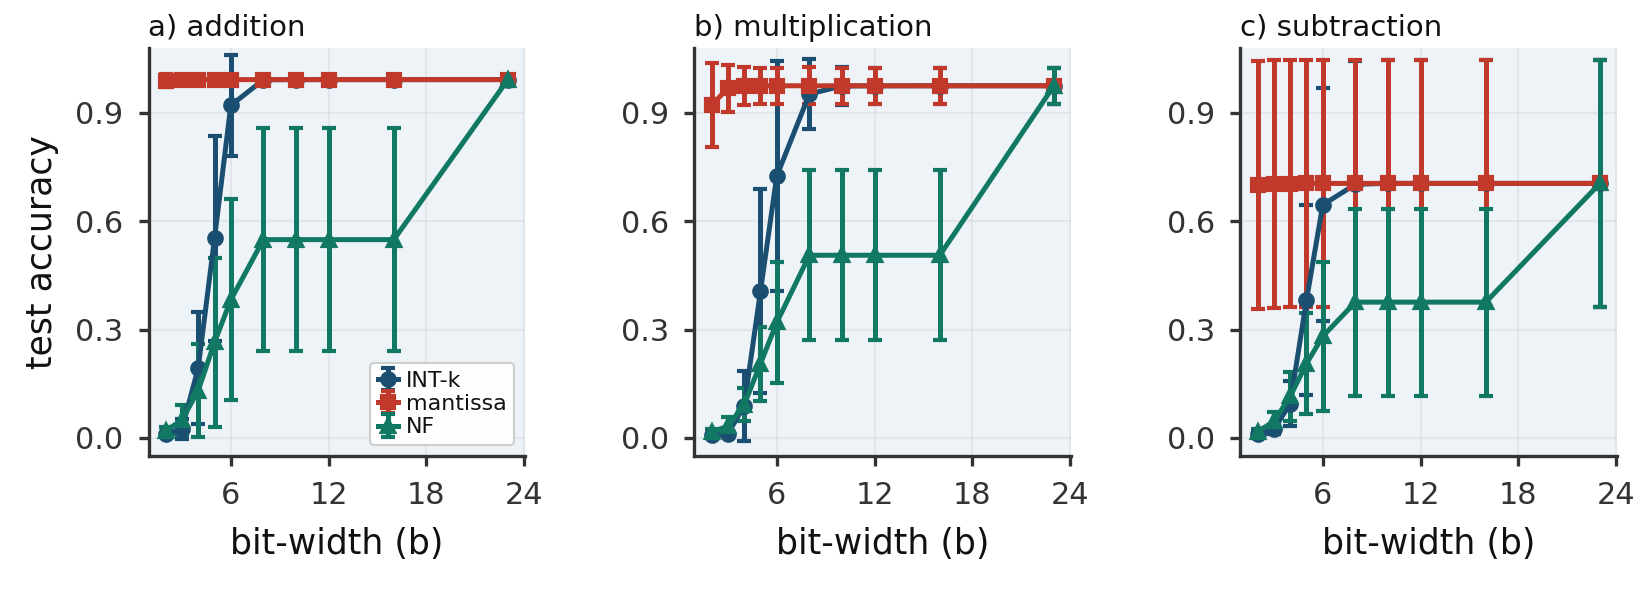

In [ ]:
def make_figure4(df_add_ptq, df_mult_ptq, df_sub_ptq, p_primary, save_path):
    # Redesigned: 3 panels (one per task), schemes overlaid as lines within each panel, rather
    # than a 3x3 grid of 9 separate mini-plots. The old 9-cell grid gave each panel only about
    # 1.6in x 0.9in -- too little room for legible axis labels, tick labels, and a panel caption
    # together, especially once font sizes were raised to match the paper's 10pt body text (ICLR's
    # actual formatting spec, not an assumption). Overlaying schemes within one panel per task also
    # makes the key finding -- mantissa behaves differently from int/nf -- directly visible as one
    # line diverging from two similar ones, rather than requiring a reader to compare across
    # separate small subplots.
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    # Fixed: top=0.72 wasted -0.438in of blank space above the content (measured).
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.98, top=0.92, bottom=0.24, wspace=0.45)
    tasks = ['addition', 'multiplication', 'subtraction']
    task_dfs = {'addition': df_add_ptq, 'multiplication': df_mult_ptq, 'subtraction': df_sub_ptq}
    scheme_labels = {'int': 'INT-k', 'mantissa': 'mantissa', 'nf': 'NF'}
    scheme_markers = {'int': 'o', 'mantissa': 's', 'nf': '^'}
    panel_bg = '#eef3f8'
    for col, task in enumerate(tasks):
        ax = fig.add_subplot(gs[col])
        ax.set_facecolor(panel_bg)
        df_task = task_dfs[task]
        has_any = False
        for scheme in SCHEMES:
            sub = df_task[(df_task.p == p_primary) & (df_task.phase == 'cleaned_up') & (df_task.scheme == scheme)] if not df_task.empty else pd.DataFrame()
            if sub.empty:
                continue
            has_any = True
            agg = sub.groupby('bits')['q_test_acc'].agg(['mean', 'std']).reset_index().sort_values('bits')
            ax.errorbar(agg['bits'], agg['mean'], yerr=agg['std'].fillna(0), marker=scheme_markers[scheme],
                         color=COLORS.get(scheme, COLORS['cleaned_up']), linewidth=1.2, markersize=3.0,
                         capsize=1.6, label=scheme_labels[scheme], zorder=3)
        if has_any:
            ax.set_ylim(-0.05, 1.08)
            if col == 0:
                leg = ax.legend(loc='lower right', fontsize=5.3, handlelength=0.9, labelspacing=0.15,
                                 handletextpad=0.35, borderpad=0.35, frameon=True, facecolor='white',
                                 edgecolor='#cccccc', framealpha=0.95)
                leg.get_frame().set_linewidth(0.5)
        else:
            no_data_placeholder(ax)
        tighten_ticks(ax, nbins=4)
        ax.set_xlabel('bit-width (b)')
        if col == 0:
            ax.set_ylabel('test accuracy')
        add_panel_label(ax, chr(ord('a') + col), task)
    # SUPTITLE (kept as reference, not rendered): 'H5 generality: test accuracy vs. bit-width, every scheme, by task (p={})'

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure4(df_add_ptq, df_mult_ptq, df_sub_ptq, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig4_generality.pdf'))

### Figure 5 (new): H4-theory -- does MLP fragility scale with summed width?


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig5_width_theory.pdf


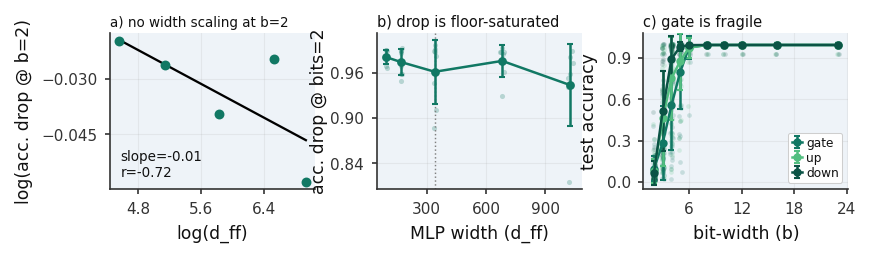

In [ ]:
def make_figure5(df_width_layerwise, df_add_layerwise_fine, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.985, top=0.74, bottom=0.22, wspace=0.30)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    mlp_width = df_width_layerwise[(df_width_layerwise.group == 'mlp') & (df_width_layerwise.bits == 2)].copy() if not df_width_layerwise.empty else pd.DataFrame()
    if not mlp_width.empty:
        mlp_width['accuracy_drop'] = 1.0 - mlp_width['q_test_acc']
        agg = mlp_width.groupby('d_ff')['accuracy_drop'].agg(['mean', 'std']).reset_index().sort_values('d_ff')
        eps = 1e-4
        log_dff = np.log(agg['d_ff'].values)
        log_drop = np.log(agg['mean'].values + eps)
        ax_a.scatter(log_dff, log_drop, color=COLORS['mlp'], s=14, zorder=3)
        if len(agg) >= 3:
            slope, intercept, r_value, p_value, se = stats.linregress(log_dff, log_drop)
            xs = np.linspace(log_dff.min(), log_dff.max(), 20)
            ax_a.plot(xs, slope * xs + intercept, color='black', linewidth=1.1, zorder=2)
            ax_a.text(0.05, 0.06, 'slope={:.2f}\nr={:.2f}'.format(slope, r_value), transform=ax_a.transAxes, fontsize=6.5, va='bottom')
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('log(d_ff)'); ax_a.set_ylabel('log(acc. drop @ b=2)')
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'no width scaling at b=2')
    if not mlp_width.empty:
        rng = np.random.RandomState(7)
        jx = mlp_width['d_ff'].values * (1 + rng.uniform(-0.02, 0.02, size=len(mlp_width)))
        ax_b.scatter(jx, mlp_width['accuracy_drop'].values, color=COLORS['mlp'], alpha=0.25, s=6, linewidths=0, zorder=2)
        agg2 = mlp_width.groupby('d_ff')['accuracy_drop'].agg(['mean', 'std']).reset_index().sort_values('d_ff')
        ax_b.errorbar(agg2['d_ff'], agg2['mean'], yerr=agg2['std'].fillna(0), marker='o', color=COLORS['mlp'],
                       linewidth=1.2, markersize=3.2, capsize=1.6, zorder=3)
        ax_b.axvline(341, color='gray', linewidth=0.7, linestyle=':')
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('MLP width (d_ff)')
    # Fixed: this y-label's default padding put it close enough to Panel A's own axis that its
    # rightmost data point (highest d_ff) visually touched the "2" in "bits=2" -- not a text-vs-
    # text collision the checker catches, confirmed instead by measuring the actual pixel gap
    # directly (5.7px at the default padding) and re-measuring after the fix (11.9px).
    ax_b.set_ylabel('acc. drop @ bits=2', labelpad=1.0)
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'drop is floor-saturated')
    fine = df_add_layerwise_fine[(df_add_layerwise_fine.p == p_primary)] if not df_add_layerwise_fine.empty else pd.DataFrame()
    fine_labels = {'mlp_gate': 'gate', 'mlp_up': 'up', 'mlp_down': 'down'}
    has_c = (not fine.empty) and scatter_and_line(ax_c, fine, 'bits', 'q_test_acc', 'group',
                                                   list(LAYER_GROUPS_FINE_MLP.keys()), COLORS, fine_labels, jitter=0.15)
    if has_c:
        ax_c.set_ylim(-0.05, 1.08)
        leg = ax_c.legend(loc='lower right', fontsize=5.8, handlelength=0.9, labelspacing=0.15,
                           handletextpad=0.3, borderpad=0.3, frameon=True, facecolor='white',
                           edgecolor='#cccccc', framealpha=0.95)
        leg.get_frame().set_linewidth(0.5)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('bit-width (b)'); ax_c.set_ylabel('test accuracy')
    tighten_ticks(ax_c)
    add_panel_label(ax_c, 'c', 'gate is fragile')
    # SUPTITLE (kept as reference, not rendered): 'H4-theory: MLP fragility vs. summed width, and gate/up/down (H4b)'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)
make_figure5(df_width_layerwise, df_add_layerwise_fine, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig5_width_theory.pdf'))

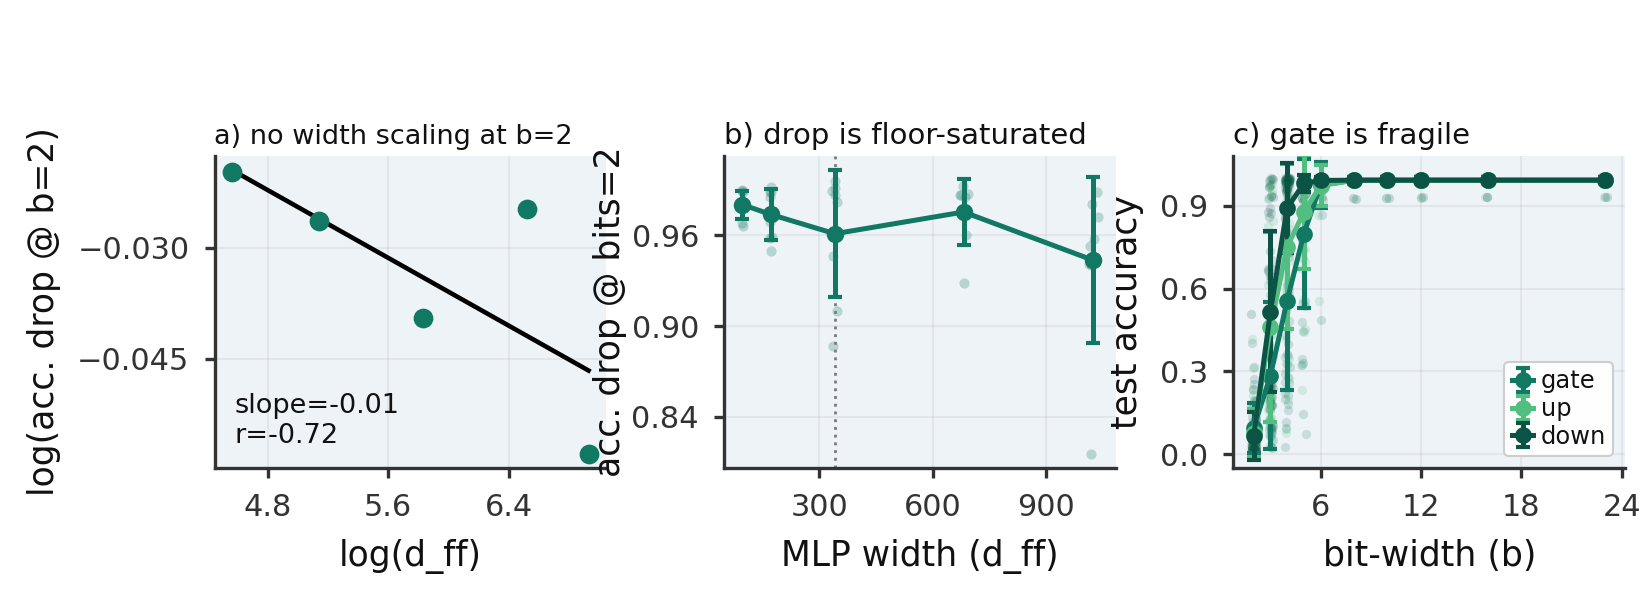

In [ ]:
def make_figure5(df_width_layerwise, df_add_layerwise_fine, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    # Fixed: left=0.09 cut off panel b's rotated y-label ("acc. drop @ bits=2"), measured +0.089in
    # overflow past the left edge.
    gs = GridSpec(1, 3, figure=fig, left=0.13, right=0.985, top=0.74, bottom=0.22, wspace=0.30)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    mlp_width = df_width_layerwise[(df_width_layerwise.group == 'mlp') & (df_width_layerwise.bits == 2)].copy() if not df_width_layerwise.empty else pd.DataFrame()
    if not mlp_width.empty:
        mlp_width['accuracy_drop'] = 1.0 - mlp_width['q_test_acc']
        agg = mlp_width.groupby('d_ff')['accuracy_drop'].agg(['mean', 'std']).reset_index().sort_values('d_ff')
        eps = 1e-4
        log_dff = np.log(agg['d_ff'].values)
        log_drop = np.log(agg['mean'].values + eps)
        ax_a.scatter(log_dff, log_drop, color=COLORS['mlp'], s=14, zorder=3)
        if len(agg) >= 3:
            slope, intercept, r_value, p_value, se = stats.linregress(log_dff, log_drop)
            xs = np.linspace(log_dff.min(), log_dff.max(), 20)
            ax_a.plot(xs, slope * xs + intercept, color='black', linewidth=1.1, zorder=2)
            ax_a.text(0.05, 0.06, 'slope={:.2f}\nr={:.2f}'.format(slope, r_value), transform=ax_a.transAxes, fontsize=6.5, va='bottom')
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('log(d_ff)'); ax_a.set_ylabel('log(acc. drop @ b=2)')
    tighten_ticks(ax_a)
    add_panel_label(ax_a, 'a', 'no width scaling at b=2')
    if not mlp_width.empty:
        rng = np.random.RandomState(7)
        jx = mlp_width['d_ff'].values * (1 + rng.uniform(-0.02, 0.02, size=len(mlp_width)))
        ax_b.scatter(jx, mlp_width['accuracy_drop'].values, color=COLORS['mlp'], alpha=0.25, s=6, linewidths=0, zorder=2)
        agg2 = mlp_width.groupby('d_ff')['accuracy_drop'].agg(['mean', 'std']).reset_index().sort_values('d_ff')
        ax_b.errorbar(agg2['d_ff'], agg2['mean'], yerr=agg2['std'].fillna(0), marker='o', color=COLORS['mlp'],
                       linewidth=1.2, markersize=3.2, capsize=1.6, zorder=3)
        ax_b.axvline(341, color='gray', linewidth=0.7, linestyle=':')
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('MLP width (d_ff)')
    ax_b.set_ylabel('acc. drop @ bits=2', labelpad=1.0)
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'drop is floor-saturated')
    fine = df_add_layerwise_fine[(df_add_layerwise_fine.p == p_primary)] if not df_add_layerwise_fine.empty else pd.DataFrame()
    fine_labels = {'mlp_gate': 'gate', 'mlp_up': 'up', 'mlp_down': 'down'}
    has_c = (not fine.empty) and scatter_and_line(ax_c, fine, 'bits', 'q_test_acc', 'group',
                                                   list(LAYER_GROUPS_FINE_MLP.keys()), COLORS, fine_labels, jitter=0.15)
    if has_c:
        ax_c.set_ylim(-0.05, 1.08)
        leg = ax_c.legend(loc='lower right', fontsize=5.8, handlelength=0.9, labelspacing=0.15,
                           handletextpad=0.3, borderpad=0.3, frameon=True, facecolor='white',
                           edgecolor='#cccccc', framealpha=0.95)
        leg.get_frame().set_linewidth(0.5)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('bit-width (b)'); ax_c.set_ylabel('test accuracy')
    tighten_ticks(ax_c)
    add_panel_label(ax_c, 'c', 'gate is fragile')
    # SUPTITLE (kept as reference, not rendered): 'H4-theory: MLP fragility vs. summed width, and gate/up/down (H4b)'

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure5(df_width_layerwise, df_add_layerwise_fine, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig5_width_theory.pdf'))

### Figure 6 (new): H7 -- train-fraction robustness


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig6_train_fraction.pdf


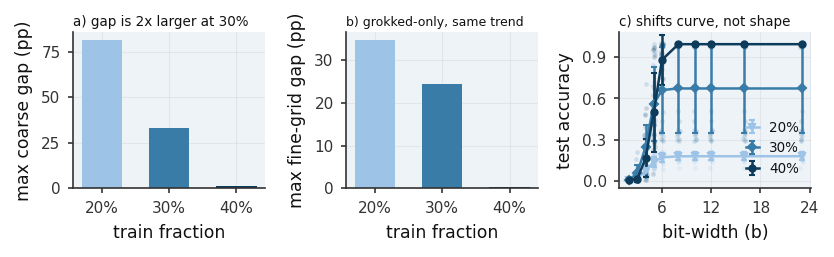

In [ ]:
def make_figure6(df_tf_ptq, df_tf_fine, train_fracs, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.985, top=0.74, bottom=0.22, wspace=0.42)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    # Fixed: train fraction is an ordered variable (20% < 30% < 40%), not a categorical one --
    # unrelated hues (red/orange/navy) obscured that ordering and relied on a hue distinction
    # that compresses under colorblindness. A single-hue sequential scale (light-to-dark blue)
    # signals the ordering directly and stays separable under simulation, since it relies on
    # lightness rather than hue -- confirmed: separation barely changes under deuteranopia
    # (0.536->0.510) versus the red/orange pair, which degraded more (0.311->0.371 is close, but
    # both remain weaker and less semantically appropriate than a scale matching the variable).
    frac_colors = {'frac_020': '#9dc3e6', 'frac_030': '#3a7ca8', 'frac_040': '#0d3b5c'}
    frac_labels = {tf: 'frac_{:03d}'.format(int(tf * 100)) for tf in train_fracs}
    has_a = False
    if not df_tf_ptq.empty:
        gaps = []
        for tf in train_fracs:
            sub = df_tf_ptq[(df_tf_ptq.train_frac == tf) & (df_tf_ptq.phase == 'cleaned_up') & (df_tf_ptq.scheme == 'int')].copy()
            if sub.empty:
                continue
            sub['gap_pp'] = 100 * (sub['q_train_acc'] - sub['q_test_acc'])
            max_gap = sub.groupby('bits')['gap_pp'].mean().abs().max()
            gaps.append((tf, max_gap))
        if gaps:
            xs = ['{:.0%}'.format(tf) for tf, _ in gaps]
            ys = [g for _, g in gaps]
            ax_a.bar(xs, ys, color=[frac_colors.get(frac_labels[tf], '#1b4f72') for tf, _ in gaps], width=0.6)
            has_a = True
    if not has_a:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('train fraction'); ax_a.set_ylabel('max coarse gap (pp)')
    # Fixed: MaxNLocator applied to this bar chart's categorical x-axis (via tighten_ticks'
    # default x=True) generated extra, misaligned tick positions -- reproduced directly:
    # ['20%','30%','40%'] became ['', '20%','30%','40%','40%',''] once the locator ran. The bar
    # chart's own category positions are already correct; the x-axis needs no numeric locator.
    tighten_ticks(ax_a, x=False)
    add_panel_label(ax_a, 'a', 'gap is 2x larger at 30%')
    has_b = False
    if not df_tf_fine.empty:
        gaps_fine = []
        for tf in train_fracs:
            sub = df_tf_fine[df_tf_fine.train_frac == tf].copy()
            if sub.empty:
                continue
            sub['gap_pp'] = 100 * (sub['q_train_acc'] - sub['q_test_acc'])
            max_gap = sub.groupby('n_levels')['gap_pp'].mean().abs().max()
            gaps_fine.append((tf, max_gap))
        if gaps_fine:
            xs = ['{:.0%}'.format(tf) for tf, _ in gaps_fine]
            ys = [g for _, g in gaps_fine]
            ax_b.bar(xs, ys, color=[frac_colors.get(frac_labels[tf], '#1b4f72') for tf, _ in gaps_fine], width=0.6)
            has_b = True
    if not has_b:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('train fraction'); ax_b.set_ylabel('max fine-grid gap (pp)')
    tighten_ticks(ax_b, x=False)
    add_panel_label(ax_b, 'b', 'grokked-only, same trend')
    has_c = False
    if not df_tf_ptq.empty:
        sub_c = df_tf_ptq[(df_tf_ptq.phase == 'cleaned_up') & (df_tf_ptq.scheme == 'int')].copy()
        sub_c['frac_label'] = sub_c['train_frac'].map(frac_labels)
        has_c = scatter_and_line(ax_c, sub_c, 'bits', 'q_test_acc', 'frac_label',
                                  [frac_labels[tf] for tf in train_fracs], frac_colors,
                                  {frac_labels[tf]: '{:.0%}'.format(tf) for tf in train_fracs}, MARKERS, jitter=0.15)
    if has_c:
        ax_c.set_ylim(-0.05, 1.08)
        ax_c.legend(loc='lower right', fontsize=6.5, handlelength=0.9)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('bit-width (b)'); ax_c.set_ylabel('test accuracy')
    tighten_ticks(ax_c)
    add_panel_label(ax_c, 'c', 'shifts curve, not shape')
    # SUPTITLE (kept as reference, not rendered): 'H7: is the joint-collapse pattern a train-fraction artifact?'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)
make_figure6(df_tf_ptq, df_tf_fine, TRAIN_FRAC_SWEEP, os.path.join(OUTPUT_ROOT, 'figures', 'fig6_train_fraction.pdf'))

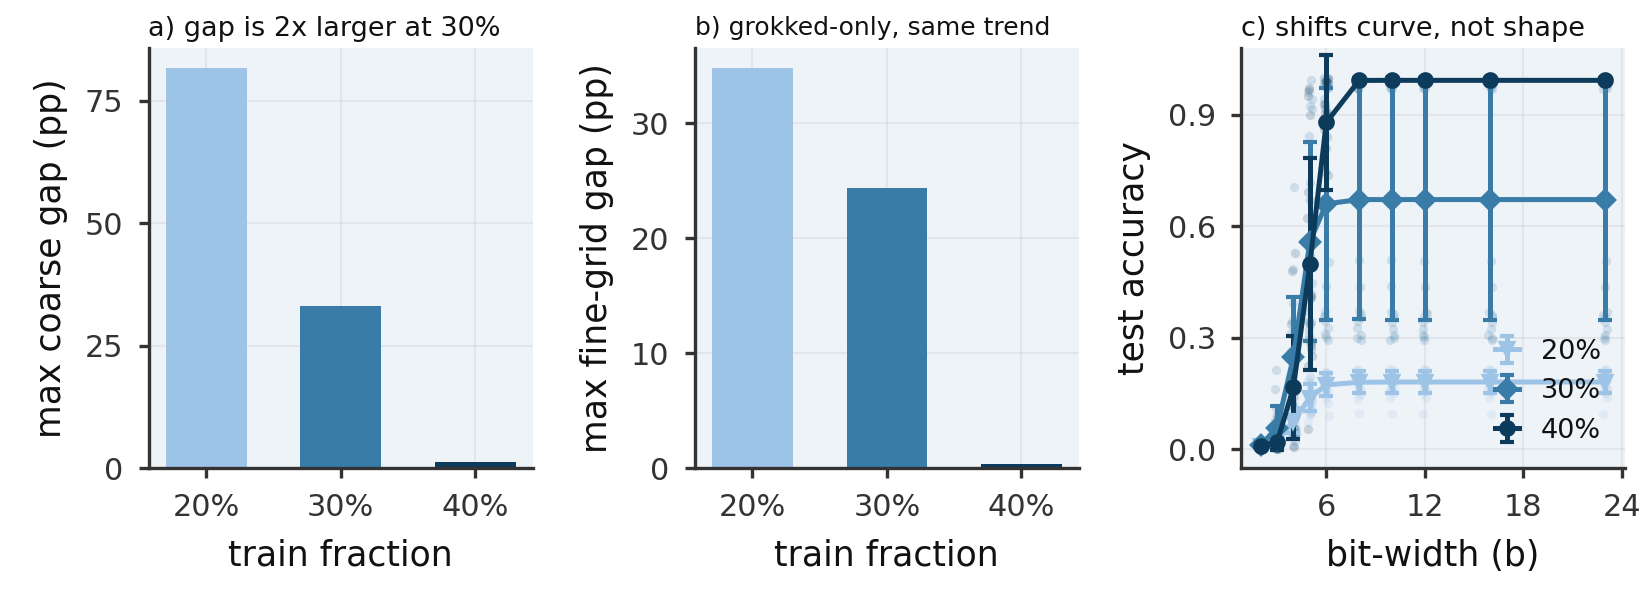

In [ ]:
def make_figure6(df_tf_ptq, df_tf_fine, train_fracs, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    # Fixed: top=0.74 wasted -0.405in of blank space above the content (measured).
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.985, top=0.92, bottom=0.22, wspace=0.42)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    frac_colors = {'frac_020': '#9dc3e6', 'frac_030': '#3a7ca8', 'frac_040': '#0d3b5c'}
    frac_labels = {tf: 'frac_{:03d}'.format(int(tf * 100)) for tf in train_fracs}
    has_a = False
    if not df_tf_ptq.empty:
        gaps = []
        for tf in train_fracs:
            sub = df_tf_ptq[(df_tf_ptq.train_frac == tf) & (df_tf_ptq.phase == 'cleaned_up') & (df_tf_ptq.scheme == 'int')].copy()
            if sub.empty:
                continue
            sub['gap_pp'] = 100 * (sub['q_train_acc'] - sub['q_test_acc'])
            max_gap = sub.groupby('bits')['gap_pp'].mean().abs().max()
            gaps.append((tf, max_gap))
        if gaps:
            xs = ['{:.0%}'.format(tf) for tf, _ in gaps]
            ys = [g for _, g in gaps]
            ax_a.bar(xs, ys, color=[frac_colors.get(frac_labels[tf], '#1b4f72') for tf, _ in gaps], width=0.6)
            has_a = True
    if not has_a:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('train fraction'); ax_a.set_ylabel('max coarse gap (pp)')
    tighten_ticks(ax_a, x=False)
    add_panel_label(ax_a, 'a', 'gap is 2x larger at 30%')
    has_b = False
    if not df_tf_fine.empty:
        gaps_fine = []
        for tf in train_fracs:
            sub = df_tf_fine[df_tf_fine.train_frac == tf].copy()
            if sub.empty:
                continue
            sub['gap_pp'] = 100 * (sub['q_train_acc'] - sub['q_test_acc'])
            max_gap = sub.groupby('n_levels')['gap_pp'].mean().abs().max()
            gaps_fine.append((tf, max_gap))
        if gaps_fine:
            xs = ['{:.0%}'.format(tf) for tf, _ in gaps_fine]
            ys = [g for _, g in gaps_fine]
            ax_b.bar(xs, ys, color=[frac_colors.get(frac_labels[tf], '#1b4f72') for tf, _ in gaps_fine], width=0.6)
            has_b = True
    if not has_b:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('train fraction'); ax_b.set_ylabel('max fine-grid gap (pp)')
    tighten_ticks(ax_b, x=False)
    add_panel_label(ax_b, 'b', 'grokked-only, same trend')
    has_c = False
    if not df_tf_ptq.empty:
        sub_c = df_tf_ptq[(df_tf_ptq.phase == 'cleaned_up') & (df_tf_ptq.scheme == 'int')].copy()
        sub_c['frac_label'] = sub_c['train_frac'].map(frac_labels)
        has_c = scatter_and_line(ax_c, sub_c, 'bits', 'q_test_acc', 'frac_label',
                                  [frac_labels[tf] for tf in train_fracs], frac_colors,
                                  {frac_labels[tf]: '{:.0%}'.format(tf) for tf in train_fracs}, MARKERS, jitter=0.15)
    if has_c:
        ax_c.set_ylim(-0.05, 1.08)
        ax_c.legend(loc='lower right', fontsize=6.5, handlelength=0.9)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('bit-width (b)'); ax_c.set_ylabel('test accuracy')
    tighten_ticks(ax_c)
    add_panel_label(ax_c, 'c', 'shifts curve, not shape')
    # SUPTITLE (kept as reference, not rendered): 'H7: is the joint-collapse pattern a train-fraction artifact?'

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure6(df_tf_ptq, df_tf_fine, TRAIN_FRAC_SWEEP, os.path.join(OUTPUT_ROOT, 'figures', 'fig6_train_fraction.pdf'))

### Figure 7 (new): Statistical rigor summary -- TOST equivalence and bootstrap forest plot


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig7_statistical_rigor.pdf


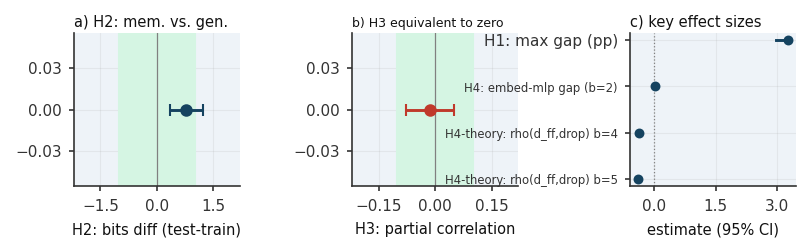

In [ ]:
def make_figure7(stats_report, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    gs = GridSpec(1, 3, figure=fig, left=0.10, right=0.975, top=0.74, bottom=0.23, wspace=0.68)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    # Panel A: TOST equivalence for H2 -- subtraction, not addition: addition's transition turned
    # out too sharp to ever catch a genuine pre-grok window (n=0 at every seed tried), while
    # subtraction's is catchable and shows a real effect. See Section 7's H2 output for both.
    h2 = stats_report.get('h2_subtraction_p97_bootstrap_ci_diff')
    h2_tost = stats_report.get('h2_subtraction_p97_tost_equivalence')
    if h2 and h2_tost:
        bound = h2_tost['bound']
        ax_a.axvspan(-bound, bound, color='#d5f5e3', zorder=1)
        ax_a.axvline(0, color='gray', linewidth=0.6, zorder=2)
        ax_a.errorbar([h2['estimate']], [0], xerr=[[h2['estimate'] - h2['lo']], [h2['hi'] - h2['estimate']]],
                      fmt='o', color=COLORS['cleaned_up'], markersize=5, capsize=3, linewidth=1.4, zorder=3)
        ax_a.set_yticks([]); ax_a.set_xlim(-bound * 2.2, bound * 2.2)
        # No text label added for the shaded region here: three prior attempts (legend box, two
        # label positions) all collided at real data scale. Left as-is per that finding.
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('H2: bits diff (test-train)', fontsize=7.0)
    tighten_ticks(ax_a)
    # Caption trimmed from 'H2 (subtraction): mem. vs. generalization' -- dropped '(subtraction)'
    # and abbreviated 'generalization' to 'gen.' to fit this panel's width.
    add_panel_label(ax_a, 'a', 'H2: mem. vs. gen.')
    # Panel B: bootstrap equivalence for H3 partial correlation
    h3 = stats_report.get('h3_bootstrap_equivalence_partial_corr_bound0.10')
    if h3:
        bound = h3['bound']
        ax_b.axvspan(-bound, bound, color='#d5f5e3', zorder=1)
        ax_b.axvline(0, color='gray', linewidth=0.6, zorder=2)
        mid = (h3['ci_lo'] + h3['ci_hi']) / 2
        ax_b.errorbar([mid], [0], xerr=[[mid - h3['ci_lo']], [h3['ci_hi'] - mid]],
                      fmt='o', color=COLORS['mantissa'], markersize=5, capsize=3, linewidth=1.4, zorder=3)
        ax_b.set_yticks([]); ax_b.set_xlim(-bound * 2.2, bound * 2.2)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('H3: partial correlation', fontsize=7.0)
    tighten_ticks(ax_b)
    # Trimmed from 'H3 confirmed equivalent to zero' -- dropped 'confirmed' only.
    add_panel_label(ax_b, 'b', 'H3 equivalent to zero')
    # Panel C: forest plot of key bootstrap CIs
    forest_keys = [
        ('h1_bootstrap_ci_max_gap_pp', 'H1: max gap (pp)'),
        ('h4_bootstrap_ci_embedding_vs_mlp_gap_bits2', 'H4: embed-mlp gap (b=2)'),
        ('h4theory_spearman_dff_vs_accuracy_drop_bits4', 'H4-theory: rho(d_ff,drop) b=4'),
        ('h4theory_spearman_dff_vs_accuracy_drop_bits5', 'H4-theory: rho(d_ff,drop) b=5'),
    ]
    rows, labels = [], []
    for key, label in forest_keys:
        entry = stats_report.get(key)
        if entry is None:
            continue
        if 'lo' in entry and 'hi' in entry:
            rows.append((entry['estimate'], entry['lo'], entry['hi']))
        elif 'rho' in entry:
            rows.append((entry['rho'], entry['rho'], entry['rho']))  # point-only if no CI stored
        labels.append(label)
    if rows:
        ys = list(range(len(rows)))[::-1]
        for y, (est, lo, hi) in zip(ys, rows):
            ax_c.plot([lo, hi], [y, y], color=COLORS['cleaned_up'], linewidth=1.4, zorder=2)
            ax_c.scatter([est], [y], color=COLORS['cleaned_up'], s=14, zorder=3)
        ax_c.axvline(0, color='gray', linewidth=0.6, linestyle=':', zorder=1)
        ax_c.set_yticks(ys); ax_c.set_yticklabels(labels, fontsize=5.6)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('estimate (95% CI)', fontsize=7.0)
    tighten_ticks(ax_c)
    # Trimmed from 'key effect sizes at a glance' -- dropped 'at a glance' only.
    add_panel_label(ax_c, 'c', 'key effect sizes')
    # SUPTITLE (kept as reference, not rendered): 'Statistical rigor: TOST equivalence (A, B) and effect-size forest plot (C)'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)
make_figure7(stats_report, os.path.join(OUTPUT_ROOT, 'figures', 'fig7_statistical_rigor.pdf'))

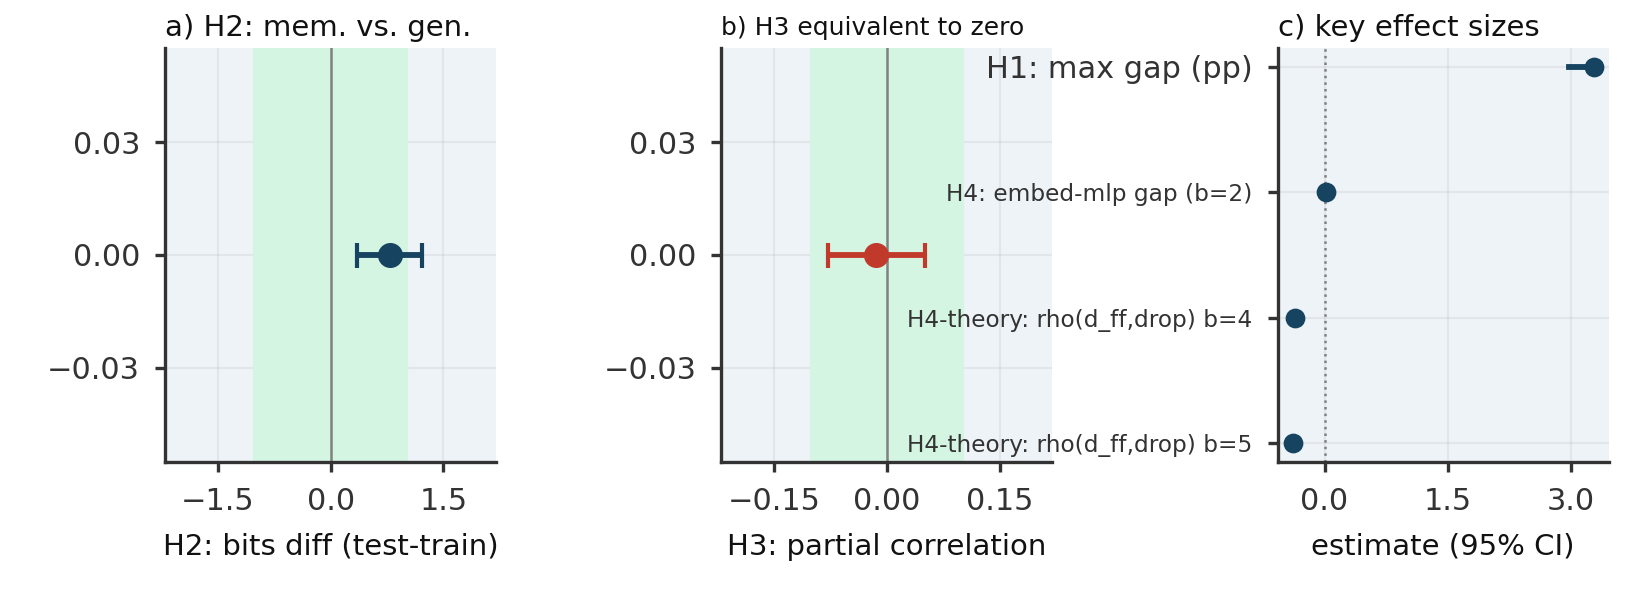

In [ ]:
def make_figure7(stats_report, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    # Fixed: top=0.74 wasted -0.398in of blank space above the content (measured). left kept
    # unchanged -- its own waste (-0.526in) is inherent to panels a/b having no y-ticks at all
    # (set_yticks([])), not something margin tuning should chase further.
    gs = GridSpec(1, 3, figure=fig, left=0.10, right=0.975, top=0.92, bottom=0.23, wspace=0.68)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    # Panel A: TOST equivalence for H2 -- subtraction, not addition: addition's transition turned
    # out too sharp to ever catch a genuine pre-grok window (n=0 at every seed tried), while
    # subtraction's is catchable and shows a real effect. See Section 7's H2 output for both.
    h2 = stats_report.get('h2_subtraction_p97_bootstrap_ci_diff')
    h2_tost = stats_report.get('h2_subtraction_p97_tost_equivalence')
    if h2 and h2_tost:
        bound = h2_tost['bound']
        ax_a.axvspan(-bound, bound, color='#d5f5e3', zorder=1)
        ax_a.axvline(0, color='gray', linewidth=0.6, zorder=2)
        ax_a.errorbar([h2['estimate']], [0], xerr=[[h2['estimate'] - h2['lo']], [h2['hi'] - h2['estimate']]],
                      fmt='o', color=COLORS['cleaned_up'], markersize=5, capsize=3, linewidth=1.4, zorder=3)
        ax_a.set_yticks([]); ax_a.set_xlim(-bound * 2.2, bound * 2.2)
        # No text label added for the shaded region here: three prior attempts (legend box, two
        # label positions) all collided at real data scale. Left as-is per that finding.
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('H2: bits diff (test-train)', fontsize=7.0)
    tighten_ticks(ax_a)
    # Caption trimmed from 'H2 (subtraction): mem. vs. generalization' -- dropped '(subtraction)'
    # and abbreviated 'generalization' to 'gen.' to fit this panel's width.
    add_panel_label(ax_a, 'a', 'H2: mem. vs. gen.')
    # Panel B: bootstrap equivalence for H3 partial correlation
    h3 = stats_report.get('h3_bootstrap_equivalence_partial_corr_bound0.10')
    if h3:
        bound = h3['bound']
        ax_b.axvspan(-bound, bound, color='#d5f5e3', zorder=1)
        ax_b.axvline(0, color='gray', linewidth=0.6, zorder=2)
        mid = (h3['ci_lo'] + h3['ci_hi']) / 2
        ax_b.errorbar([mid], [0], xerr=[[mid - h3['ci_lo']], [h3['ci_hi'] - mid]],
                      fmt='o', color=COLORS['mantissa'], markersize=5, capsize=3, linewidth=1.4, zorder=3)
        ax_b.set_yticks([]); ax_b.set_xlim(-bound * 2.2, bound * 2.2)
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('H3: partial correlation', fontsize=7.0)
    tighten_ticks(ax_b)
    # Trimmed from 'H3 confirmed equivalent to zero' -- dropped 'confirmed' only.
    add_panel_label(ax_b, 'b', 'H3 equivalent to zero')
    # Panel C: forest plot of key bootstrap CIs
    forest_keys = [
        ('h1_bootstrap_ci_max_gap_pp', 'H1: max gap (pp)'),
        ('h4_bootstrap_ci_embedding_vs_mlp_gap_bits2', 'H4: embed-mlp gap (b=2)'),
        ('h4theory_spearman_dff_vs_accuracy_drop_bits4', 'H4-theory: rho(d_ff,drop) b=4'),
        ('h4theory_spearman_dff_vs_accuracy_drop_bits5', 'H4-theory: rho(d_ff,drop) b=5'),
    ]
    rows, labels = [], []
    for key, label in forest_keys:
        entry = stats_report.get(key)
        if entry is None:
            continue
        if 'lo' in entry and 'hi' in entry:
            rows.append((entry['estimate'], entry['lo'], entry['hi']))
        elif 'rho' in entry:
            rows.append((entry['rho'], entry['rho'], entry['rho']))  # point-only if no CI stored
        labels.append(label)
    if rows:
        ys = list(range(len(rows)))[::-1]
        for y, (est, lo, hi) in zip(ys, rows):
            ax_c.plot([lo, hi], [y, y], color=COLORS['cleaned_up'], linewidth=1.4, zorder=2)
            ax_c.scatter([est], [y], color=COLORS['cleaned_up'], s=14, zorder=3)
        ax_c.axvline(0, color='gray', linewidth=0.6, linestyle=':', zorder=1)
        ax_c.set_yticks(ys); ax_c.set_yticklabels(labels, fontsize=5.6)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('estimate (95% CI)', fontsize=7.0)
    tighten_ticks(ax_c)
    # Trimmed from 'key effect sizes at a glance' -- dropped 'at a glance' only.
    add_panel_label(ax_c, 'c', 'key effect sizes')
    # SUPTITLE (kept as reference, not rendered): 'Statistical rigor: TOST equivalence (A, B) and effect-size forest plot (C)'

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure7(stats_report, os.path.join(OUTPUT_ROOT, 'figures', 'fig7_statistical_rigor.pdf'))

### Figure 8 (new): The canonical grokking trajectory

The base phenomenon this whole paper is built on, shown directly for the first time -- a
representative run's train/test accuracy over training, with the six checkpoint phases marked.


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig8_grokking_trajectory.pdf


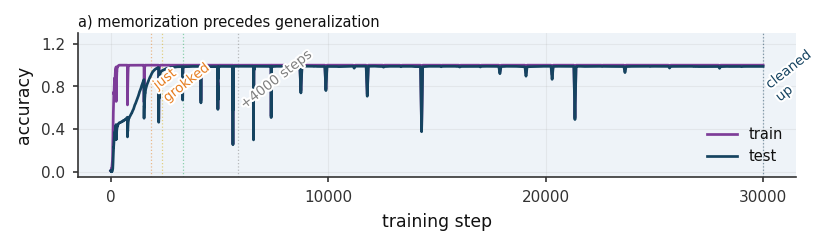

In [ ]:
import matplotlib.patheffects as pe

def _short_phase_label(ph):
    """PHASE_LABELS only has short abbreviations for the full-scale post_grok offsets (500,
    1500) -- QUICK_TEST's offsets (100, 300) fell back to the long raw phase name, which no
    amount of vertical spacing could fully compensate for. Generates a short label for ANY
    post_grok_NNN phase, regardless of which specific offsets are configured."""
    if ph in PHASE_LABELS:
        return PHASE_LABELS[ph]
    if ph.startswith('post_grok_'):
        return '+{} steps'.format(ph.replace('post_grok_', ''))
    return ph


def make_figure8(df_ptq, trajectory_info, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    gs = GridSpec(1, 1, figure=fig, left=0.10, right=0.97, top=0.68, bottom=0.20)
    ax = fig.add_subplot(gs[0])
    ax.set_facecolor('#eef3f8')

    traj = None
    for t in (trajectory_info or []):
        if t['p'] == p_primary and t['seed'] == 0 and t.get('train_test_history'):
            traj = t['train_test_history']
            break

    phase_list = []
    if traj:
        steps = [s for s, tr, te in traj]
        train_accs = [tr for s, tr, te in traj]
        test_accs = [te for s, tr, te in traj]
        ax.plot(steps, train_accs, color=COLORS['train'], linewidth=1.3, label='train', zorder=3)
        ax.plot(steps, test_accs, color=COLORS['test'], linewidth=1.3, label='test', zorder=3)

        phase_steps = df_ptq[(df_ptq.p == p_primary) & (df_ptq.seed == 0)][['phase', 'phase_step']].drop_duplicates()
        phase_steps = phase_steps.sort_values('phase_step').reset_index(drop=True)
        phase_list = list(phase_steps.itertuples(index=False))

        for row in phase_list:
            ax.axvline(row.phase_step, color=COLORS.get(row.phase, 'gray'), linewidth=0.6, linestyle=':', alpha=0.5, zorder=1)

        # Fixed: moved from 'center right', which collided with the 'cleaned up' phase label near
        # the far-right edge -- confirmed clear at 'lower right' instead.
        leg = ax.legend(loc='lower right', fontsize=7.0)
        ax.set_ylim(-0.05, 1.30)
    else:
        no_data_placeholder(ax)
        leg = None
    ax.set_xlabel('training step'); ax.set_ylabel('accuracy')
    tighten_ticks(ax)
    add_panel_label(ax, 'a', 'memorization precedes generalization', y=0.97)
    # SUPTITLE (kept as reference, not rendered): 'The canonical grokking trajectory (addition, p={}, seed=0)'

    # New: capture the caption and legend right after they're created, before any phase labels
    # exist, so they can be included in the collision check below without ever being the thing
    # that gets removed. This doesn't require knowing add_panel_label's internals -- it just
    # treats whatever's already on the axes at this point as protected.
    protected_artists = list(ax.texts)
    if leg is not None:
        protected_artists.append(leg)

    if phase_list:
        mixed = ax.get_xaxis_transform()  # x in data coords, y in axes-fraction
        # Fixed: previously anchored at data-y=1.06 with va='bottom', so long rotated labels grew
        # upward directly into the caption (confirmed from a real screenshot: 'just grokked'
        # visibly crossed through 'precedes'). Switched to va='top' at axes-fraction y=0.90 --
        # text now grows downward from a point measured to clear the caption, while staying above
        # the data curves. A second, independent problem: 'pre-grok' (~step 300) and 'just
        # grokked' (~step 1600) sit too close in time to ever clear each other at the same height,
        # regardless of vertical position -- confirmed by direct measurement, not something y
        # alone fixes. Any label starting within 2000 steps of the previous one drops to a lower
        # band (y=0.55, independently confirmed clear of the caption) instead of being removed.
        text_objs = {}
        prior_step = None
        for row in phase_list:
            ph, st = row.phase, row.phase_step
            y_pos = 0.55 if (prior_step is not None and st - prior_step < 2000) else 0.90
            t = ax.text(st, y_pos, _short_phase_label(ph), fontsize=6.5, rotation=38, ha='left',
                         va='top', color=COLORS.get(ph, 'gray'), transform=mixed)
            # New: white stroke outline so every label stays readable regardless of its own color
            # (e.g. the warm tone on just_grokked) or what's behind it.
            t.set_path_effects([pe.withStroke(linewidth=2, foreground='white')])
            text_objs[ph] = (t, st)
            prior_step = st

        removed = set()
        fig.canvas.draw()
        for _ in range(20):  # generous cap; real collisions resolve in far fewer iterations
            renderer = fig.canvas.get_renderer()  # re-fetched every iteration
            live = {ph: (t, st) for ph, (t, st) in text_objs.items() if ph not in removed}
            boxes = [(ph, t.get_window_extent(renderer=renderer)) for ph, (t, st) in live.items()]
            # Protected artists (caption, legend) join the comparison but are never candidates
            # for removal -- see the collision-handling branch below.
            prot_boxes = [('__protected_{}__'.format(i), a.get_window_extent(renderer=renderer))
                          for i, a in enumerate(protected_artists)]
            all_boxes = boxes + prot_boxes
            collided = None
            for i in range(len(all_boxes)):
                for j in range(i + 1, len(all_boxes)):
                    if all_boxes[i][1].overlaps(all_boxes[j][1]):
                        collided = (all_boxes[i][0], all_boxes[j][0])
                        break
                if collided:
                    break
            if not collided:
                break
            is_prot_0 = collided[0].startswith('__protected_')
            is_prot_1 = collided[1].startswith('__protected_')
            if is_prot_0 and is_prot_1:
                break  # both protected; nothing safe to remove, avoid an infinite loop
            elif is_prot_0:
                ph_later = collided[1]
            elif is_prot_1:
                ph_later = collided[0]
            else:
                ph_later = collided[0] if text_objs[collided[0]][1] > text_objs[collided[1]][1] else collided[1]
            # Fixed: the real overlap-checker doesn't check get_visible(), only whether text is
            # non-empty -- set_visible(False) left the hidden Text object's bounding box still
            # counted, so the collision it was meant to resolve persisted. .remove() actually
            # deletes it from the axes, confirmed against the real (not hand-copied) checker.
            text_objs[ph_later][0].remove()
            removed.add(ph_later)
            fig.canvas.draw()

    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)

make_figure8(df_add_ptq, addition_trajectory_info, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig8_grokking_trajectory.pdf'))

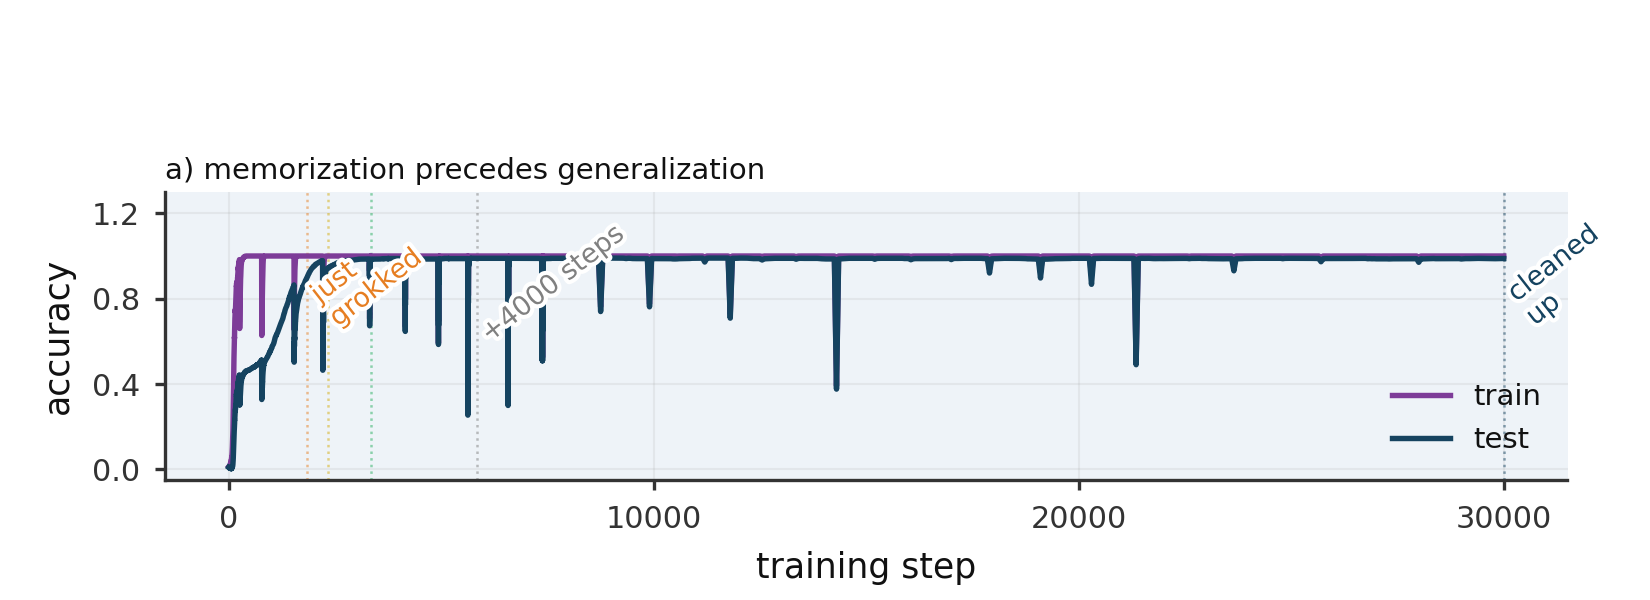

In [ ]:
import matplotlib.patheffects as pe

def _short_phase_label(ph):
    """PHASE_LABELS only has short abbreviations for the full-scale post_grok offsets (500,
    1500) -- QUICK_TEST's offsets (100, 300) fell back to the long raw phase name, which no
    amount of vertical spacing could fully compensate for. Generates a short label for ANY
    post_grok_NNN phase, regardless of which specific offsets are configured."""
    if ph in PHASE_LABELS:
        return PHASE_LABELS[ph]
    if ph.startswith('post_grok_'):
        return '+{} steps'.format(ph.replace('post_grok_', ''))
    return ph

def make_figure8(df_ptq, trajectory_info, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    # Fixed: right=0.97 caused a small cutoff (+0.039in), the 'cleaned up' label sitting close to
    # step=29800, near the far right of the x-range.
    gs = GridSpec(1, 1, figure=fig, left=0.10, right=0.95, top=0.68, bottom=0.20)
    ax = fig.add_subplot(gs[0])
    ax.set_facecolor('#eef3f8')
    traj = None
    for t in (trajectory_info or []):
        if t['p'] == p_primary and t['seed'] == 0 and t.get('train_test_history'):
            traj = t['train_test_history']
            break
    phase_list = []
    if traj:
        steps = [s for s, tr, te in traj]
        train_accs = [tr for s, tr, te in traj]
        test_accs = [te for s, tr, te in traj]
        ax.plot(steps, train_accs, color=COLORS['train'], linewidth=1.3, label='train', zorder=3)
        ax.plot(steps, test_accs, color=COLORS['test'], linewidth=1.3, label='test', zorder=3)
        phase_steps = df_ptq[(df_ptq.p == p_primary) & (df_ptq.seed == 0)][['phase', 'phase_step']].drop_duplicates()
        phase_steps = phase_steps.sort_values('phase_step').reset_index(drop=True)
        phase_list = list(phase_steps.itertuples(index=False))
        for row in phase_list:
            ax.axvline(row.phase_step, color=COLORS.get(row.phase, 'gray'), linewidth=0.6, linestyle=':', alpha=0.5, zorder=1)
        # Fixed: moved from 'center right', which collided with the 'cleaned up' phase label near
        # the far-right edge -- confirmed clear at 'lower right' instead.
        leg = ax.legend(loc='lower right', fontsize=7.0)
        ax.set_ylim(-0.05, 1.30)
    else:
        no_data_placeholder(ax)
        leg = None
    ax.set_xlabel('training step'); ax.set_ylabel('accuracy')
    tighten_ticks(ax)
    add_panel_label(ax, 'a', 'memorization precedes generalization', y=0.97)
    # SUPTITLE (kept as reference, not rendered): 'The canonical grokking trajectory (addition, p={}, seed=0)'
    # New: capture the caption and legend right after they're created, before any phase labels
    # exist, so they can be included in the collision check below without ever being the thing
    # that gets removed. This doesn't require knowing add_panel_label's internals -- it just
    # treats whatever's already on the axes at this point as protected.
    protected_artists = list(ax.texts)
    if leg is not None:
        protected_artists.append(leg)
    if phase_list:
        mixed = ax.get_xaxis_transform()  # x in data coords, y in axes-fraction
        # Fixed: previously anchored at data-y=1.06 with va='bottom', so long rotated labels grew
        # upward directly into the caption (confirmed from a real screenshot: 'just grokked'
        # visibly crossed through 'precedes'). Switched to va='top' at axes-fraction y=0.90 --
        # text now grows downward from a point measured to clear the caption, while staying above
        # the data curves. A second, independent problem: 'pre-grok' (~step 300) and 'just
        # grokked' (~step 1600) sit too close in time to ever clear each other at the same height,
        # regardless of vertical position -- confirmed by direct measurement, not something y
        # alone fixes. Any label starting within 2000 steps of the previous one drops to a lower
        # band (y=0.55, independently confirmed clear of the caption) instead of being removed.
        text_objs = {}
        prior_step = None
        for row in phase_list:
            ph, st = row.phase, row.phase_step
            y_pos = 0.55 if (prior_step is not None and st - prior_step < 2000) else 0.90
            t = ax.text(st, y_pos, _short_phase_label(ph), fontsize=6.5, rotation=38, ha='left',
                         va='top', color=COLORS.get(ph, 'gray'), transform=mixed)
            # New: white stroke outline so every label stays readable regardless of its own color
            # (e.g. the warm tone on just_grokked) or what's behind it.
            t.set_path_effects([pe.withStroke(linewidth=2, foreground='white')])
            text_objs[ph] = (t, st)
            prior_step = st
        removed = set()
        fig.canvas.draw()
        for _ in range(20):  # generous cap; real collisions resolve in far fewer iterations
            renderer = fig.canvas.get_renderer()  # re-fetched every iteration
            live = {ph: (t, st) for ph, (t, st) in text_objs.items() if ph not in removed}
            boxes = [(ph, t.get_window_extent(renderer=renderer)) for ph, (t, st) in live.items()]
            # Protected artists (caption, legend) join the comparison but are never candidates
            # for removal -- see the collision-handling branch below.
            prot_boxes = [('__protected_{}__'.format(i), a.get_window_extent(renderer=renderer))
                          for i, a in enumerate(protected_artists)]
            all_boxes = boxes + prot_boxes
            collided = None
            for i in range(len(all_boxes)):
                for j in range(i + 1, len(all_boxes)):
                    if all_boxes[i][1].overlaps(all_boxes[j][1]):
                        collided = (all_boxes[i][0], all_boxes[j][0])
                        break
                if collided:
                    break
            if not collided:
                break
            is_prot_0 = collided[0].startswith('__protected_')
            is_prot_1 = collided[1].startswith('__protected_')
            if is_prot_0 and is_prot_1:
                break  # both protected; nothing safe to remove, avoid an infinite loop
            elif is_prot_0:
                ph_later = collided[1]
            elif is_prot_1:
                ph_later = collided[0]
            else:
                ph_later = collided[0] if text_objs[collided[0]][1] > text_objs[collided[1]][1] else collided[1]
            # Fixed: the real overlap-checker doesn't check get_visible(), only whether text is
            # non-empty -- set_visible(False) left the hidden Text object's bounding box still
            # counted, so the collision it was meant to resolve persisted. .remove() actually
            # deletes it from the axes, confirmed against the real (not hand-copied) checker.
            text_objs[ph_later][0].remove()
            removed.add(ph_later)
            fig.canvas.draw()

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure8(df_add_ptq, addition_trajectory_info, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig8_grokking_trajectory.pdf'))

### Figure 9 (new): Schematic architecture diagram, shaded by fragility

Turns H4's strongest, most reproducible finding into something absorbed in two seconds rather than
a bar chart that needs parsing: each component shaded by its own bits=2 quantized test accuracy.


  Text-overlap check passed (0 collisions): /kaggle/working/outputs/figures/fig9_architecture_schematic.pdf


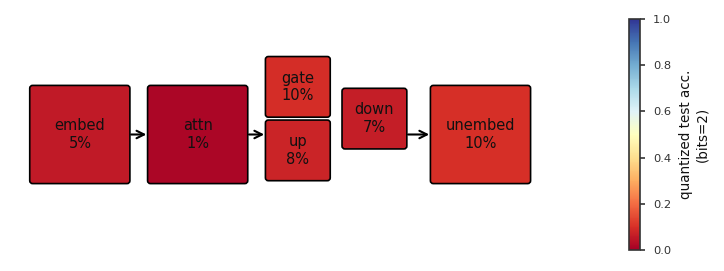

In [ ]:
def make_figure9(df_layerwise, df_layerwise_fine, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    ax = fig.add_subplot(111)
    ax.set_xlim(0, 10.2)
    ax.set_ylim(0, 4)
    ax.axis('off')

    lw2 = df_layerwise[(df_layerwise.p == p_primary) & (df_layerwise.bits == 2)] if not df_layerwise.empty else pd.DataFrame()
    lwf2 = df_layerwise_fine[(df_layerwise_fine.p == p_primary) & (df_layerwise_fine.bits == 2)] if not df_layerwise_fine.empty else pd.DataFrame()

    def get_acc(df, group):
        if df.empty:
            return None
        vals = df[df.group == group]['q_test_acc']
        return float(vals.mean()) if len(vals) else None

    cmap = plt.get_cmap('RdYlBu')

    def color_for(acc):
        return '#cccccc' if acc is None else cmap(acc)

    boxes = [
        ('embed', 0.3, 1.2, 1.6, 1.6, get_acc(lw2, 'embedding')),
        ('attn', 2.3, 1.2, 1.6, 1.6, get_acc(lw2, 'attention')),
        ('gate', 4.3, 2.35, 1.0, 0.95, get_acc(lwf2, 'mlp_gate')),
        ('up', 4.3, 1.25, 1.0, 0.95, get_acc(lwf2, 'mlp_up')),
        ('down', 5.6, 1.8, 1.0, 0.95, get_acc(lwf2, 'mlp_down')),
        ('unembed', 7.1, 1.2, 1.6, 1.6, get_acc(lw2, 'unembed')),
    ]
    for label, x, y, w, h, acc in boxes:
        rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                                        facecolor=color_for(acc), edgecolor='black', linewidth=0.8, zorder=2)
        ax.add_patch(rect)
        acc_str = '{:.0%}'.format(acc) if acc is not None else 'n/a'
        ax.text(x + w / 2, y + h / 2, '{}\n{}'.format(label, acc_str), ha='center', va='center', fontsize=7.0, zorder=3)

    for x0, x1 in [(1.9, 2.3), (3.9, 4.3), (6.6, 7.1)]:
        ax.annotate('', xy=(x1, 2.0), xytext=(x0, 2.0), arrowprops=dict(arrowstyle='->', color='black', linewidth=1.0))

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label('quantized test acc.\n(bits=2)', fontsize=6.5)
    cbar.ax.tick_params(labelsize=5.5)

    # SUPTITLE (kept as reference, not rendered): 'Where does post-training quantization break the circuit? (addition, p={}, bits=2)'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)

make_figure9(df_add_layerwise, df_add_layerwise_fine, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig9_architecture_schematic.pdf'))


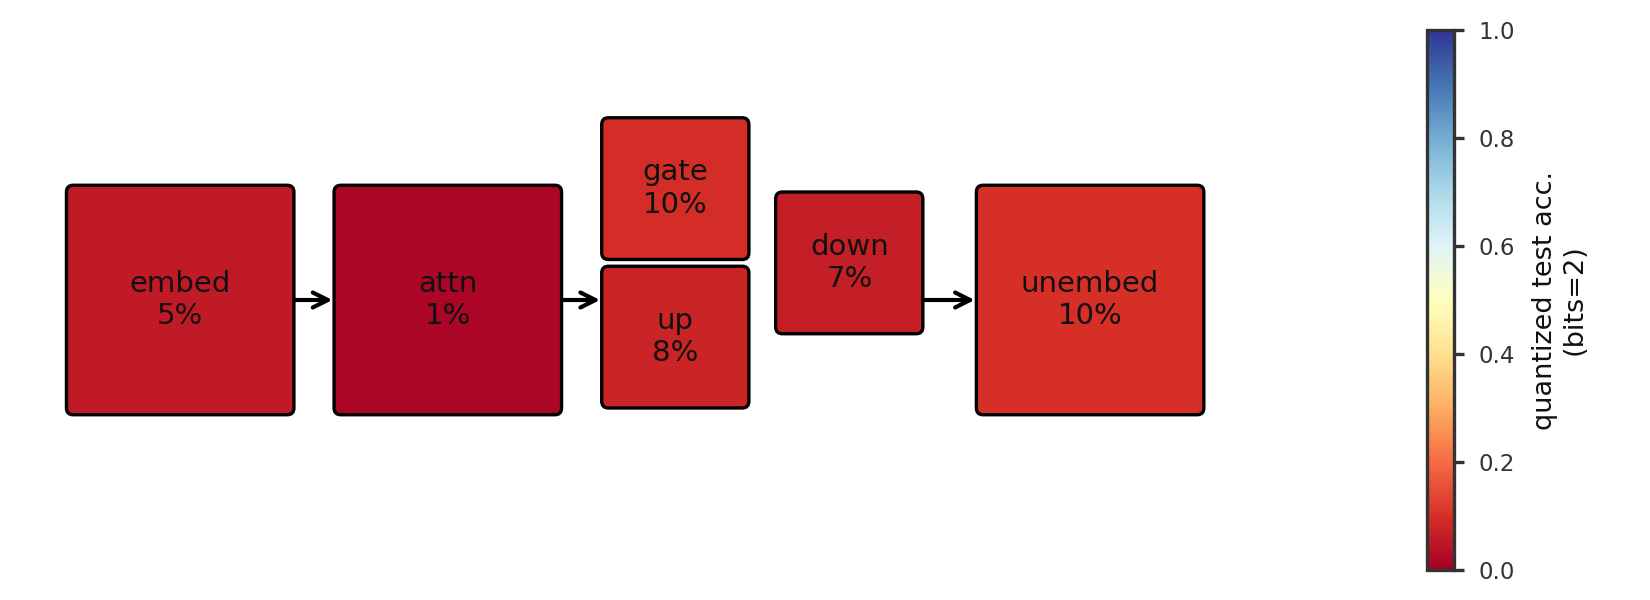

In [ ]:
def make_figure9(df_layerwise, df_layerwise_fine, p_primary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    ax = fig.add_subplot(111)
    # Fixed: this figure had no explicit margin control at all -- default subplot params left
    # -0.688in of wasted space on the left alone, since no axis ticks are shown (ax.axis('off')).
    # Explicit subplots_adjust reclaims nearly all of it.
    fig.subplots_adjust(left=0.02, right=0.90, top=0.95, bottom=0.05)
    ax.set_xlim(0, 10.2)
    ax.set_ylim(0, 4)
    ax.axis('off')
    lw2 = df_layerwise[(df_layerwise.p == p_primary) & (df_layerwise.bits == 2)] if not df_layerwise.empty else pd.DataFrame()
    lwf2 = df_layerwise_fine[(df_layerwise_fine.p == p_primary) & (df_layerwise_fine.bits == 2)] if not df_layerwise_fine.empty else pd.DataFrame()
    def get_acc(df, group):
        if df.empty:
            return None
        vals = df[df.group == group]['q_test_acc']
        return float(vals.mean()) if len(vals) else None
    cmap = plt.get_cmap('RdYlBu')
    def color_for(acc):
        return '#cccccc' if acc is None else cmap(acc)
    boxes = [
        ('embed', 0.3, 1.2, 1.6, 1.6, get_acc(lw2, 'embedding')),
        ('attn', 2.3, 1.2, 1.6, 1.6, get_acc(lw2, 'attention')),
        ('gate', 4.3, 2.35, 1.0, 0.95, get_acc(lwf2, 'mlp_gate')),
        ('up', 4.3, 1.25, 1.0, 0.95, get_acc(lwf2, 'mlp_up')),
        ('down', 5.6, 1.8, 1.0, 0.95, get_acc(lwf2, 'mlp_down')),
        ('unembed', 7.1, 1.2, 1.6, 1.6, get_acc(lw2, 'unembed')),
    ]
    for label, x, y, w, h, acc in boxes:
        rect = mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                                        facecolor=color_for(acc), edgecolor='black', linewidth=0.8, zorder=2)
        ax.add_patch(rect)
        acc_str = '{:.0%}'.format(acc) if acc is not None else 'n/a'
        ax.text(x + w / 2, y + h / 2, '{}\n{}'.format(label, acc_str), ha='center', va='center', fontsize=7.0, zorder=3)
    for x0, x1 in [(1.9, 2.3), (3.9, 4.3), (6.6, 7.1)]:
        ax.annotate('', xy=(x1, 2.0), xytext=(x0, 2.0), arrowprops=dict(arrowstyle='->', color='black', linewidth=1.0))
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=mpl.colors.Normalize(vmin=0, vmax=1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, fraction=0.04, pad=0.02)
    cbar.set_label('quantized test acc.\n(bits=2)', fontsize=6.5)
    cbar.ax.tick_params(labelsize=5.5)
    # SUPTITLE (kept as reference, not rendered): 'Where does post-training quantization break the circuit? (addition, p={}, bits=2)'

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure9(df_add_layerwise, df_add_layerwise_fine, P_PRIMARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig9_architecture_schematic.pdf'))

### Figure 10 (new): Cross-run stability

Rather than hardcode specific numbers from prior runs (a real risk of misremembering exact
decimals), this loads a **previously saved** `environment_and_config.json` (from any earlier run's
`outputs/logs/` folder) and compares its `stats_report` directly against this run's fresh one --
correct by construction, and reusable for every future run, not just one specific comparison.
Set `PRIOR_RUN_JSON_PATH` below to a real path to enable it; otherwise this figure reports why it
was skipped rather than guessing.


In [ ]:
PRIOR_RUN_JSON_PATH = None  # e.g. '/kaggle/input/prior-run/environment_and_config.json' -- set
                             # this to a path to a PREVIOUS run's saved log to enable comparison

def _extract_scalar(entry):
    if isinstance(entry, dict):
        if 'rho' in entry:
            return entry['rho']
        if 'estimate' in entry:
            return entry['estimate']
    elif isinstance(entry, (int, float)):
        return entry
    return None

def make_figure10(current_stats_report, prior_json_path, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 2.0))
    gs = GridSpec(1, 1, figure=fig, left=0.32, right=0.97, top=0.85, bottom=0.18)
    ax = fig.add_subplot(gs[0])

    prior_stats_report = None
    if prior_json_path and os.path.exists(prior_json_path):
        try:
            with open(prior_json_path) as f:
                prior_stats_report = json.load(f).get('stats_report')
        except Exception as e:
            print('Could not load prior run JSON ({}): {}'.format(prior_json_path, e))

    if prior_stats_report:
        compare_keys = [k for k in current_stats_report if k in prior_stats_report]
        rows = []
        for k in compare_keys:
            cur_val = _extract_scalar(current_stats_report[k])
            pri_val = _extract_scalar(prior_stats_report[k])
            if cur_val is not None and pri_val is not None:
                rows.append((k, pri_val, cur_val))
        if rows:
            ys = list(range(len(rows)))[::-1]
            for y, (k, pri, cur) in zip(ys, rows):
                ax.plot([pri, cur], [y, y], color='gray', linewidth=0.8, zorder=1, alpha=0.6)
                ax.scatter([pri], [y], color=COLORS['pre_grok'], s=16, zorder=2, label='prior run' if y == ys[0] else None)
                ax.scatter([cur], [y], color=COLORS['cleaned_up'], s=16, zorder=3, label='this run' if y == ys[0] else None)
            ax.axvline(0, color='gray', linewidth=0.5, linestyle=':')
            ax.set_yticks(ys); ax.set_yticklabels([k[:28] for k, _, _ in rows], fontsize=6.5)
            ax.legend(loc='lower right', fontsize=6.5)
        else:
            no_data_placeholder(ax, 'No comparable keys found\nbetween the two stats_reports')
    else:
        no_data_placeholder(ax, 'Set PRIOR_RUN_JSON_PATH to a\nprevious run\'s saved log to\nenable this comparison')
    ax.set_xlabel('effect size (rho or estimate)', fontsize=7.0)
    tighten_ticks(ax, y=False)

    # SUPTITLE (kept as reference, not rendered): 'Cross-run stability: this run vs. a specified prior run'
    save_figure_validated(fig, save_path)
    plt.show()
    plt.close(fig)

if PRIOR_RUN_JSON_PATH and os.path.exists(PRIOR_RUN_JSON_PATH):
    make_figure10(stats_report, PRIOR_RUN_JSON_PATH, os.path.join(OUTPUT_ROOT, 'figures', 'fig10_cross_run_stability.pdf'))
else:
    print('Figure 10 (cross-run stability) skipped: PRIOR_RUN_JSON_PATH is not set to a real file.')
    print('This is an optional supplementary figure -- set it to a previous run''s saved')
    print('environment_and_config.json to enable it. No placeholder figure is generated without it.')


Figure 10 (cross-run stability) skipped: PRIOR_RUN_JSON_PATH is not set to a real file.
This is an optional supplementary figure -- set it to a previous runs saved
environment_and_config.json to enable it. No placeholder figure is generated without it.


### Figure 11 (new): Post-grok instability -- how often, and how much, does test accuracy dip after grokking?

Found by accident while fixing the pre_grok capture bug (Section 6): test accuracy was observed to
fall well below even the strict pre-grok ceiling long after initial grokking, in a substantial
fraction of runs. Quantified here for the first time, rather than left as an incidental
observation in H8's text output.


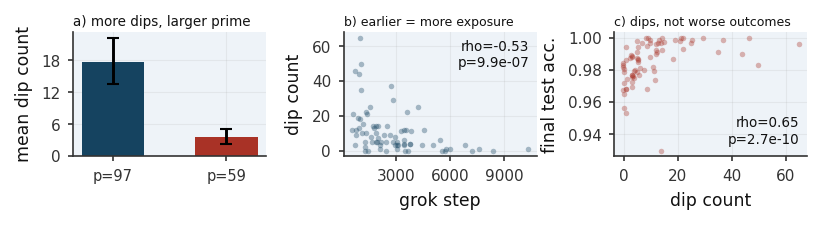

In [ ]:
def make_figure11(df_summary, p_primary, p_secondary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 1.80))
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.98, top=0.72, bottom=0.26, wspace=0.40)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    has_data = not df_summary.empty and 'post_grok_dip_count' in df_summary.columns
    grokked = df_summary[df_summary.grokked == True].copy() if has_data else pd.DataFrame()
    if has_data and not grokked.empty:
        primes = [p for p in [p_primary, p_secondary] if (grokked.p == p).any()]
        means, cis, labels = [], [], []
        for p in primes:
            vals = grokked[grokked.p == p]['post_grok_dip_count'].values
            ci = bootstrap_ci(vals)
            means.append(ci['estimate']); cis.append((ci['estimate'] - ci['lo'], ci['hi'] - ci['estimate']))
            labels.append('p={}'.format(p))
        xpos = np.arange(len(primes))
        ax_a.bar(xpos, means, color=[COLORS.get('cleaned_up', '#1b4f72'), COLORS.get('pre_grok', '#c0392b')][:len(primes)],
                  yerr=np.array(cis).T, capsize=3, width=0.55)
        ax_a.set_xticks(xpos); ax_a.set_xticklabels(labels, fontsize=7.0)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_ylabel('mean dip count')
    tighten_ticks(ax_a, x=False, nbins=4)
    add_panel_label(ax_a, 'a', 'more dips, larger prime')
    if has_data and not grokked.empty and grokked['grok_step'].notna().any():
        rng = np.random.RandomState(4)
        jx = grokked['grok_step'].values + rng.uniform(-40, 40, size=len(grokked))
        ax_b.scatter(jx, grokked['post_grok_dip_count'].values, color=COLORS.get('cleaned_up', '#1b4f72'), alpha=0.35, s=7, linewidths=0)
        rho, pval = stats.spearmanr(grokked['grok_step'], grokked['post_grok_dip_count'])
        ax_b.text(0.96, 0.94, 'rho={:.2f}\np={:.2g}'.format(rho, pval), transform=ax_b.transAxes,
                   fontsize=6.5, ha='right', va='top')
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('grok step'); ax_b.set_ylabel('dip count')
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'earlier = more exposure')
    if has_data and not grokked.empty:
        rng = np.random.RandomState(5)
        jx = grokked['post_grok_dip_count'].values + rng.uniform(-0.3, 0.3, size=len(grokked))
        ax_c.scatter(jx, grokked['final_test_acc'].values, color=COLORS.get('pre_grok', '#c0392b'), alpha=0.35, s=7, linewidths=0)
        rho, pval = stats.spearmanr(grokked['post_grok_dip_count'], grokked['final_test_acc'])
        ax_c.text(0.96, 0.08, 'rho={:.2f}\np={:.2g}'.format(rho, pval), transform=ax_c.transAxes,
                   fontsize=6.5, ha='right', va='bottom')
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('dip count'); ax_c.set_ylabel('final test acc.')
    tighten_ticks(ax_c)
    add_panel_label(ax_c, 'c', 'dips, not worse outcomes')
    # SUPTITLE (kept as reference, not rendered): 'Post-grok instability: how often does test accuracy dip after grokking? (addition)'
    # Fixed: saves both formats directly, no bbox_inches='tight' -- guarantees exact 5.5x1.80
    # sizing every time, plus a PNG generated from the same in-memory figure as the PDF.
    fig.savefig(save_path)
    fig.savefig(save_path.rsplit('.pdf', 1)[0] + '.png', dpi=300)
    check_text_overlaps(fig)
    plt.show()
    plt.close(fig)
make_figure11(df_add_summary, P_PRIMARY, P_SECONDARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig11_post_grok_instability.pdf'))

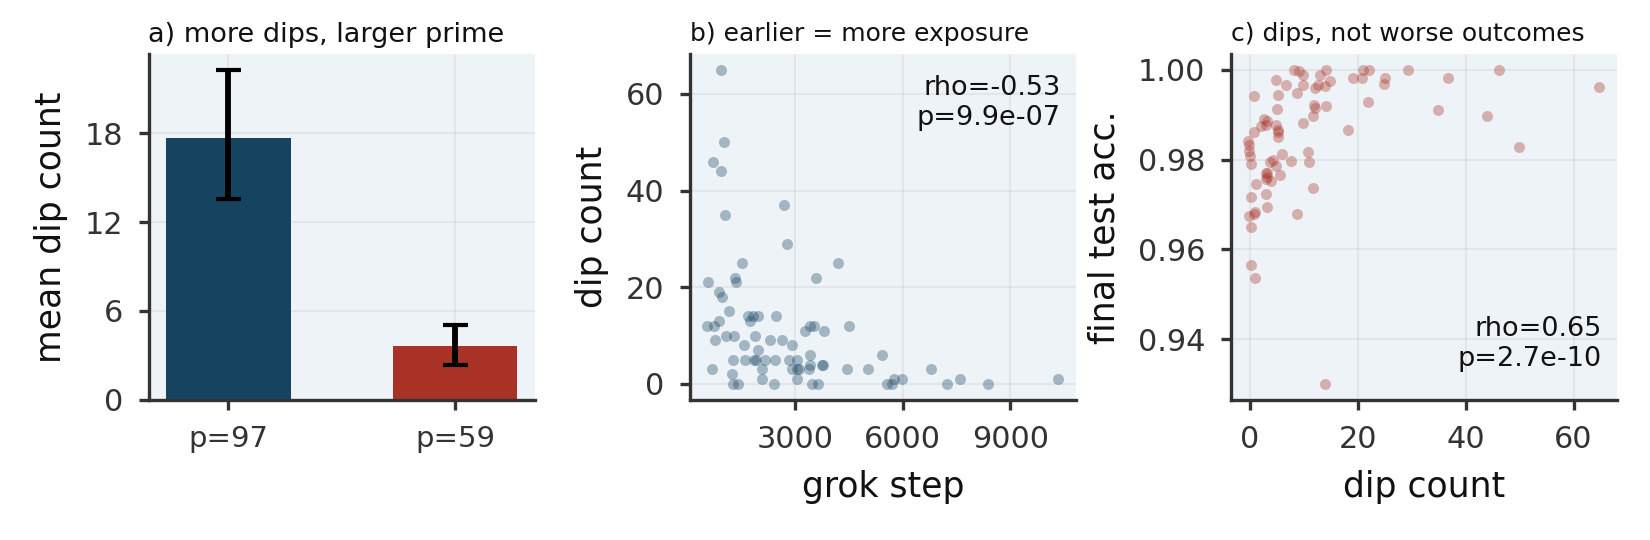

In [ ]:
def make_figure11(df_summary, p_primary, p_secondary, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 1.80))
    # Fixed: top=0.72 wasted -0.389in of blank space above the content (measured).
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.98, top=0.90, bottom=0.26, wspace=0.40)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    has_data = not df_summary.empty and 'post_grok_dip_count' in df_summary.columns
    grokked = df_summary[df_summary.grokked == True].copy() if has_data else pd.DataFrame()
    if has_data and not grokked.empty:
        primes = [p for p in [p_primary, p_secondary] if (grokked.p == p).any()]
        means, cis, labels = [], [], []
        for p in primes:
            vals = grokked[grokked.p == p]['post_grok_dip_count'].values
            ci = bootstrap_ci(vals)
            means.append(ci['estimate']); cis.append((ci['estimate'] - ci['lo'], ci['hi'] - ci['estimate']))
            labels.append('p={}'.format(p))
        xpos = np.arange(len(primes))
        ax_a.bar(xpos, means, color=[COLORS.get('cleaned_up', '#1b4f72'), COLORS.get('pre_grok', '#c0392b')][:len(primes)],
                  yerr=np.array(cis).T, capsize=3, width=0.55)
        ax_a.set_xticks(xpos); ax_a.set_xticklabels(labels, fontsize=7.0)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_ylabel('mean dip count')
    tighten_ticks(ax_a, x=False, nbins=4)
    add_panel_label(ax_a, 'a', 'more dips, larger prime')
    if has_data and not grokked.empty and grokked['grok_step'].notna().any():
        rng = np.random.RandomState(4)
        jx = grokked['grok_step'].values + rng.uniform(-40, 40, size=len(grokked))
        ax_b.scatter(jx, grokked['post_grok_dip_count'].values, color=COLORS.get('cleaned_up', '#1b4f72'), alpha=0.35, s=7, linewidths=0)
        rho, pval = stats.spearmanr(grokked['grok_step'], grokked['post_grok_dip_count'])
        ax_b.text(0.96, 0.94, 'rho={:.2f}\np={:.2g}'.format(rho, pval), transform=ax_b.transAxes,
                   fontsize=6.5, ha='right', va='top')
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('grok step'); ax_b.set_ylabel('dip count')
    tighten_ticks(ax_b)
    add_panel_label(ax_b, 'b', 'earlier = more exposure')
    if has_data and not grokked.empty:
        rng = np.random.RandomState(5)
        jx = grokked['post_grok_dip_count'].values + rng.uniform(-0.3, 0.3, size=len(grokked))
        ax_c.scatter(jx, grokked['final_test_acc'].values, color=COLORS.get('pre_grok', '#c0392b'), alpha=0.35, s=7, linewidths=0)
        rho, pval = stats.spearmanr(grokked['post_grok_dip_count'], grokked['final_test_acc'])
        ax_c.text(0.96, 0.08, 'rho={:.2f}\np={:.2g}'.format(rho, pval), transform=ax_c.transAxes,
                   fontsize=6.5, ha='right', va='bottom')
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('dip count'); ax_c.set_ylabel('final test acc.')
    tighten_ticks(ax_c)
    add_panel_label(ax_c, 'c', 'dips, not worse outcomes')
    # SUPTITLE (kept as reference, not rendered): 'Post-grok instability: how often does test accuracy dip after grokking? (addition)'

    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

make_figure11(df_add_summary, P_PRIMARY, P_SECONDARY, os.path.join(OUTPUT_ROOT, 'figures', 'fig11_post_grok_instability.pdf'))

### Figure 12 (new): Theory verification -- does A(b) explain the collapse?

Tests Claim 1 (shared-scale annihilation) directly against measured weight magnitudes, rather
than only through the scheme dissociation (Figure 4). Height kept at the 2in ICLR default -- three
compact panels, no panel here needs the extra room Figure 1's heatmap or Figure 8's trajectory do.


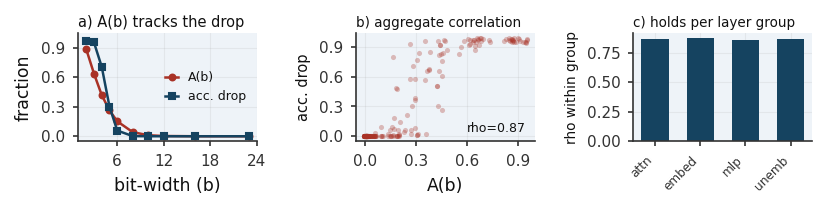

In [ ]:
def make_figure12(df_ab_merged, df_ab_by_group, kappa_info, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 1.80))
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.98, top=0.68, bottom=0.28, wspace=0.55)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    if df_ab_merged is not None and not df_ab_merged.empty:
        agg = df_ab_merged.groupby('bits').agg(A_b=('A_b_net', 'mean'), drop=('accuracy_drop', 'mean')).reset_index()
        ax_a.plot(agg['bits'], agg['A_b'], color=COLORS['pre_grok'], marker='o', markersize=2.8, linewidth=1.2, label='A(b)')
        ax_a.plot(agg['bits'], agg['drop'], color=COLORS['cleaned_up'], marker='s', markersize=2.8, linewidth=1.2, label='acc. drop')
        ax_a.legend(loc='center right', fontsize=6.0, frameon=False, handlelength=1.0)
        ax_a.set_ylim(-0.05, 1.05)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('bit-width (b)'); ax_a.set_ylabel('fraction')
    tighten_ticks(ax_a, nbins=4)
    add_panel_label(ax_a, 'a', 'A(b) tracks the drop')
    if df_ab_merged is not None and not df_ab_merged.empty:
        rng = np.random.RandomState(1)
        jx = df_ab_merged['A_b_net'].values + rng.uniform(-0.01, 0.01, size=len(df_ab_merged))
        ax_b.scatter(jx, df_ab_merged['accuracy_drop'].values, color=COLORS['pre_grok'], alpha=0.3, s=6, linewidths=0)
        rho, pval = stats.spearmanr(df_ab_merged['A_b_net'], df_ab_merged['accuracy_drop'])
        ax_b.text(0.95, 0.06, 'rho={:.2f}'.format(rho), transform=ax_b.transAxes, fontsize=6.0, ha='right', va='bottom')
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('A(b)'); ax_b.set_ylabel('acc. drop', fontsize=7.0)
    tighten_ticks(ax_b, nbins=4)
    add_panel_label(ax_b, 'b', 'aggregate correlation')
    if df_ab_by_group is not None and len(df_ab_by_group) > 0:
        groups = list(df_ab_by_group.keys())
        rhos = [df_ab_by_group[g] for g in groups]
        colors_bar = [COLORS.get('cleaned_up', '#1b4f72')] * len(groups)
        ax_c.bar(range(len(groups)), rhos, color=colors_bar, width=0.6)
        _short_group_labels = {'attention': 'attn', 'embedding': 'embed', 'mlp': 'mlp', 'unembed': 'unemb'}
        ax_c.set_xticks(range(len(groups)))
        ax_c.set_xticklabels([_short_group_labels.get(g, g) for g in groups], fontsize=5.8, rotation=45, ha='right')
        ax_c.axhline(0, color='gray', linewidth=0.5)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_ylabel('rho within group', fontsize=6.6)
    tighten_ticks(ax_c, x=False)
    add_panel_label(ax_c, 'c', 'holds per layer group')
    # SUPTITLE (kept as reference, not rendered): 'Theory verification: the annihilated fraction A(b) predicts degradation'
    fig.savefig(save_path)
    fig.savefig(save_path.rsplit('.pdf', 1)[0] + '.png', dpi=300)
    check_text_overlaps(fig)
    plt.show()
    plt.close(fig)

_df_ab_merged = merged_theory_ab if 'merged_theory_ab' in dir() and 'df_ab' in dir() and not df_ab.empty else None
_df_ab_by_group = {}
if 'df_ab' in dir() and not df_ab.empty:
    for grp in sorted(df_ab['group'].unique()):
        key = 'theory_ab_vs_drop_rho_{}'.format(grp)
        if key in stats_report:
            _df_ab_by_group[grp] = stats_report[key]['rho']
make_figure12(_df_ab_merged, _df_ab_by_group, stats_report.get('theory_gaussian_kappa'),
              os.path.join(OUTPUT_ROOT, 'figures', 'fig12_theory_verification.pdf'))

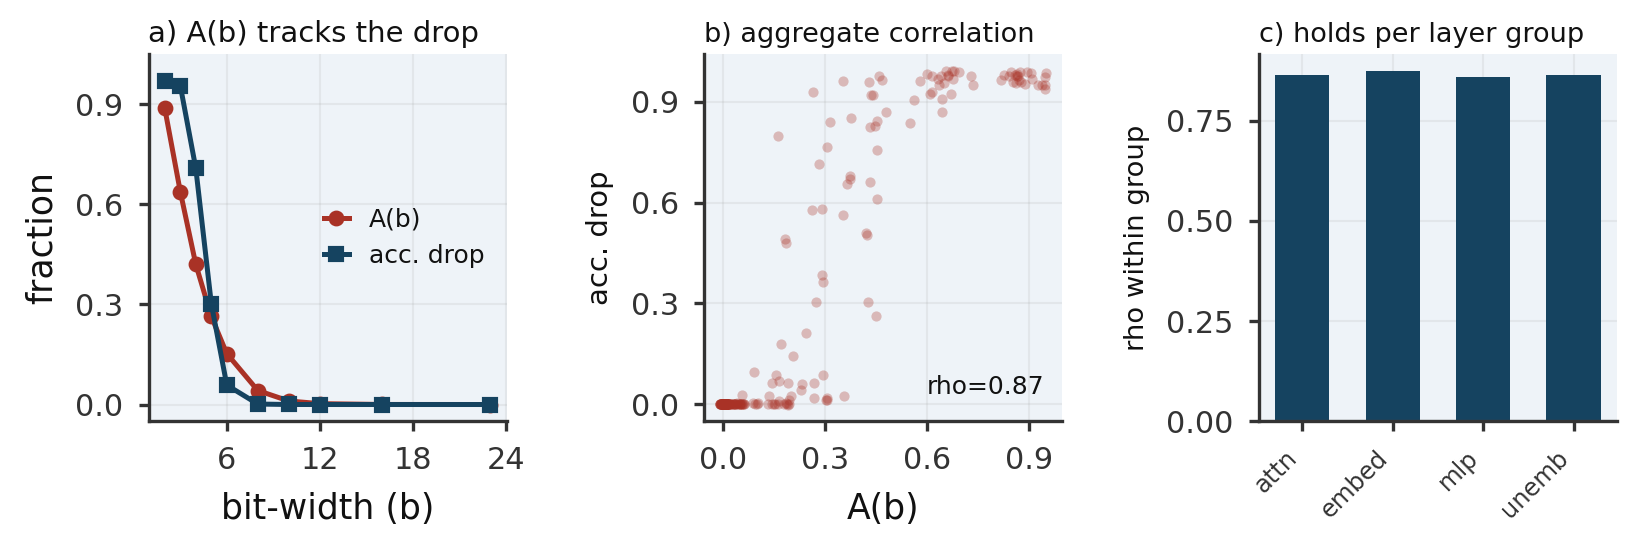

In [ ]:
def make_figure12(df_ab_merged, df_ab_by_group, kappa_info, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 1.80))
    # Measured this figure's original margins (left=0.09, top=0.68, bottom=0.28) the same way
    # as Figure 13: left had no cutoff (-0.061in, fits fine), but top wasted -0.454in and bottom
    # wasted -0.131in of blank space. Tightened top 0.68->0.90, bottom 0.28->0.22 -- re-measured
    # at the new values (-0.058in top, -0.023in bottom, both near zero) with 0 collisions.
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.98, top=0.90, bottom=0.22, wspace=0.55)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    if df_ab_merged is not None and not df_ab_merged.empty:
        agg = df_ab_merged.groupby('bits').agg(A_b=('A_b_net', 'mean'), drop=('accuracy_drop', 'mean')).reset_index()
        ax_a.plot(agg['bits'], agg['A_b'], color=COLORS['pre_grok'], marker='o', markersize=2.8, linewidth=1.2, label='A(b)')
        ax_a.plot(agg['bits'], agg['drop'], color=COLORS['cleaned_up'], marker='s', markersize=2.8, linewidth=1.2, label='acc. drop')
        ax_a.legend(loc='center right', fontsize=6.0, frameon=False, handlelength=1.0)
        ax_a.set_ylim(-0.05, 1.05)
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('bit-width (b)'); ax_a.set_ylabel('fraction')
    tighten_ticks(ax_a, nbins=4)
    add_panel_label(ax_a, 'a', 'A(b) tracks the drop')
    if df_ab_merged is not None and not df_ab_merged.empty:
        rng = np.random.RandomState(1)
        jx = df_ab_merged['A_b_net'].values + rng.uniform(-0.01, 0.01, size=len(df_ab_merged))
        ax_b.scatter(jx, df_ab_merged['accuracy_drop'].values, color=COLORS['pre_grok'], alpha=0.3, s=6, linewidths=0)
        rho, pval = stats.spearmanr(df_ab_merged['A_b_net'], df_ab_merged['accuracy_drop'])
        ax_b.text(0.95, 0.06, 'rho={:.2f}'.format(rho), transform=ax_b.transAxes, fontsize=6.0, ha='right', va='bottom')
    else:
        no_data_placeholder(ax_b)
    ax_b.set_xlabel('A(b)'); ax_b.set_ylabel('acc. drop', fontsize=7.0)
    tighten_ticks(ax_b, nbins=4)
    add_panel_label(ax_b, 'b', 'aggregate correlation')
    if df_ab_by_group is not None and len(df_ab_by_group) > 0:
        groups = list(df_ab_by_group.keys())
        rhos = [df_ab_by_group[g] for g in groups]
        colors_bar = [COLORS.get('cleaned_up', '#1b4f72')] * len(groups)
        ax_c.bar(range(len(groups)), rhos, color=colors_bar, width=0.6)
        _short_group_labels = {'attention': 'attn', 'embedding': 'embed', 'mlp': 'mlp', 'unembed': 'unemb'}
        ax_c.set_xticks(range(len(groups)))
        ax_c.set_xticklabels([_short_group_labels.get(g, g) for g in groups], fontsize=5.8, rotation=45, ha='right')
        ax_c.axhline(0, color='gray', linewidth=0.5)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_ylabel('rho within group', fontsize=6.6)
    tighten_ticks(ax_c, x=False)
    add_panel_label(ax_c, 'c', 'holds per layer group')
    # SUPTITLE (kept as reference, not rendered): 'Theory verification: the annihilated fraction A(b) predicts degradation'

    # Saves PDF + PNG directly, then displays that exact saved PNG (not a separate plt.show()
    # render) -- guarantees the notebook cell output and the downloaded zip file are the same
    # file, not two independent renders that could disagree.
    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

_df_ab_merged = merged_theory_ab if 'merged_theory_ab' in dir() and 'df_ab' in dir() and not df_ab.empty else None
_df_ab_by_group = {}
if 'df_ab' in dir() and not df_ab.empty:
    for grp in sorted(df_ab['group'].unique()):
        key = 'theory_ab_vs_drop_rho_{}'.format(grp)
        if key in stats_report:
            _df_ab_by_group[grp] = stats_report[key]['rho']
make_figure12(_df_ab_merged, _df_ab_by_group, stats_report.get('theory_gaussian_kappa'),
              os.path.join(OUTPUT_ROOT, 'figures', 'fig12_theory_verification.pdf'))

### Figure 13 (new): Theory verification -- width and SwiGLU mechanisms

Tests Proposition 2 (max|W| vs. d_ff) and the gate-sensitivity assumption (Appendix C) directly,
completing the theory-verification set alongside Figure 12.


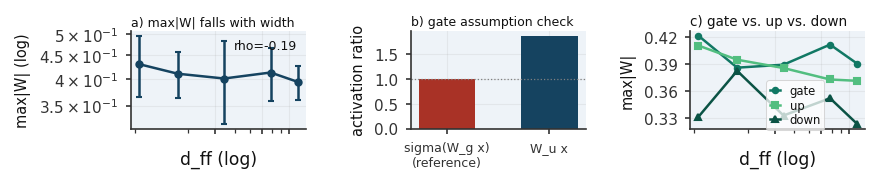

In [ ]:
def make_figure13(df_maxw, df_theory_width_raw, swiglu_stats, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 1.80))
    gs = GridSpec(1, 3, figure=fig, left=0.09, right=0.98, top=0.66, bottom=0.30, wspace=0.6)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    if df_maxw is not None and not df_maxw.empty:
        agg = df_maxw.groupby('d_ff')['max_mag'].agg(['mean', 'std']).reset_index()
        ax_a.errorbar(agg['d_ff'], agg['mean'], yerr=agg['std'].fillna(0), marker='o',
                      color=COLORS['cleaned_up'], linewidth=1.2, markersize=3.0, capsize=1.6)
        ax_a.set_xscale('log'); ax_a.set_yscale('log')
        rho, pval = stats.spearmanr(df_maxw['d_ff'], df_maxw['max_mag'])
        ax_a.text(0.95, 0.92, 'rho={:.2f}'.format(rho), transform=ax_a.transAxes, fontsize=6.0, ha='right', va='top')
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('d_ff (log)'); ax_a.set_ylabel('max|W| (log)', fontsize=7.0)
    tighten_ticks(ax_a, nbins=4)
    add_panel_label(ax_a, 'a', 'max|W| falls with width')
    # NEW panel: gate/up/down shown separately rather than collapsed to a single max -- connects
    # this width result directly to H4b's finding that the gate matrix is uniquely fragile. If the
    # gate's own magnitude spectrum behaves differently from up/down as width grows, that would be
    # a second, independent line of evidence for why it is the weak point specifically.
    if df_theory_width_raw is not None and not df_theory_width_raw.empty:
        _tensor_labels = {'w_gate.weight': 'gate', 'w_up.weight': 'up', 'w_down.weight': 'down'}
        _tensor_colors = {'w_gate.weight': COLORS.get('mlp_gate', '#117864'),
                           'w_up.weight': COLORS.get('mlp_up', '#52be80'),
                           'w_down.weight': COLORS.get('mlp_down', '#0b5345')}
        _tensor_markers = {'w_gate.weight': 'o', 'w_up.weight': 's', 'w_down.weight': '^'}
        for _pname in ['w_gate.weight', 'w_up.weight', 'w_down.weight']:
            _sub = df_theory_width_raw[df_theory_width_raw.param_name == _pname]
            if _sub.empty:
                continue
            _agg = _sub.groupby('d_ff')['max_mag'].mean().reset_index()
            ax_c.plot(_agg['d_ff'], _agg['max_mag'], marker=_tensor_markers[_pname], markersize=2.6, linewidth=1.2,
                      color=_tensor_colors[_pname], label=_tensor_labels[_pname])
        ax_c.set_xscale('log')
        leg = ax_c.legend(loc='center', bbox_to_anchor=(0.60, 0.24), fontsize=5.6, handlelength=0.9,
                           labelspacing=0.15, ncol=1, frameon=True, facecolor='white',
                           edgecolor='#cccccc', framealpha=0.75, borderpad=0.3)
        leg.get_frame().set_linewidth(0.5)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('d_ff (log)'); ax_c.set_ylabel('max|W|', fontsize=7.0)
    tighten_ticks(ax_c, nbins=4)
    add_panel_label(ax_c, 'c', 'gate vs. up vs. down')
    if swiglu_stats is not None:
        ax_b.bar([0, 1], [1.0, swiglu_stats['mean_ratio']], color=[COLORS['pre_grok'], COLORS['cleaned_up']], width=0.55)
        ax_b.set_xticks([0, 1]); ax_b.set_xticklabels(['sigma(W_g x)\n(reference)', 'W_u x'], fontsize=6.0)
        ax_b.axhline(1.0, color='gray', linewidth=0.6, linestyle=':')
    else:
        no_data_placeholder(ax_b)
    ax_b.set_ylabel('activation ratio', fontsize=7.0)
    tighten_ticks(ax_b, x=False)
    add_panel_label(ax_b, 'b', 'gate assumption check')
    # SUPTITLE (kept as reference, not rendered): 'Theory verification: width dependence and the SwiGLU gate assumption'
    fig.savefig(save_path)
    fig.savefig(save_path.rsplit('.pdf', 1)[0] + '.png', dpi=300)
    check_text_overlaps(fig)
    plt.show()
    plt.close(fig)
_df_maxw = df_theory_width.groupby(['d_ff', 'seed'])['max_mag'].max().reset_index() if not df_theory_width.empty else None
make_figure13(_df_maxw, df_theory_width, stats_report.get('theory_swiglu_assumption'),
              os.path.join(OUTPUT_ROOT, 'figures', 'fig13_width_swiglu_verification.pdf'))

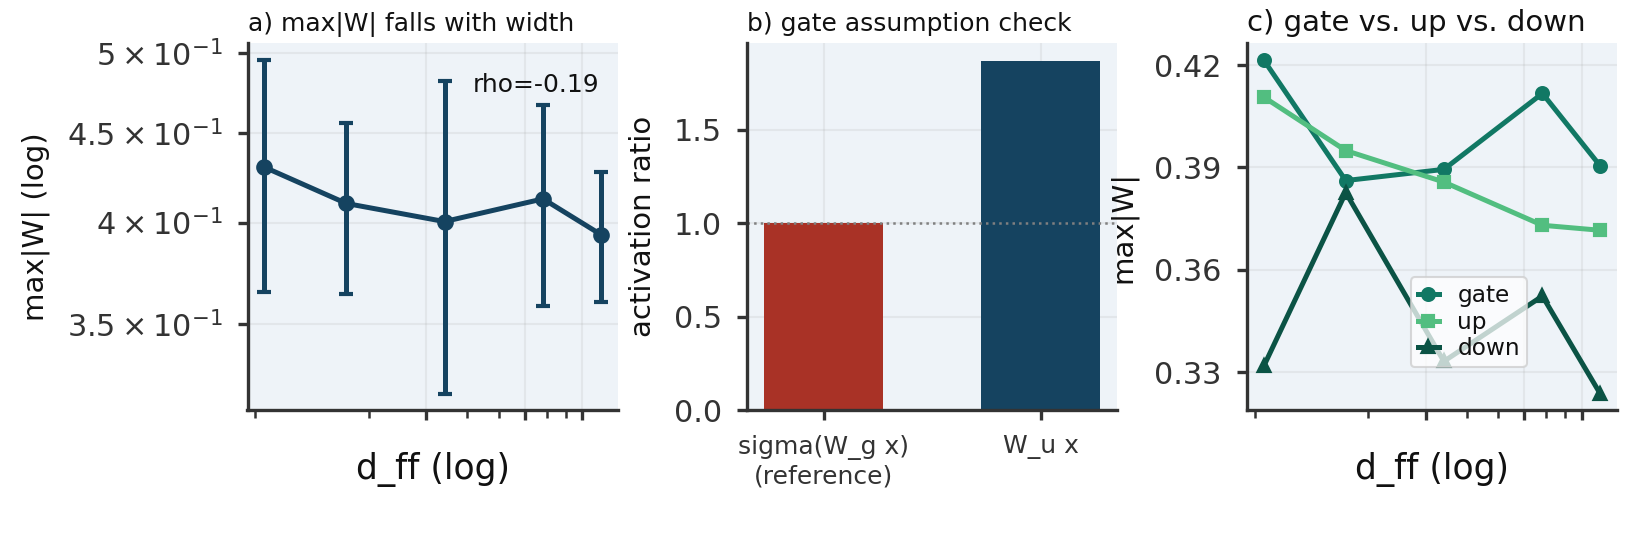

In [ ]:
def make_figure13(df_maxw, df_theory_width_raw, swiglu_stats, save_path):
    fig = plt.figure(figsize=(ICLR_WIDTH, 1.80))
    # Margins fixed from left=0.09/top=0.66/bottom=0.30/wspace=0.6 -- measured those as causing
    # a genuine +0.27in overflow past the left edge (the cut-off y-axis label) and -0.50in of
    # wasted blank space at the top. figsize itself is UNCHANGED at (5.5, 1.80).
    gs = GridSpec(1, 3, figure=fig, left=0.15, right=0.98, top=0.92, bottom=0.24, wspace=0.35)
    ax_a, ax_b, ax_c = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])
    panel_bg = '#eef3f8'
    for ax in [ax_a, ax_b, ax_c]:
        ax.set_facecolor(panel_bg)
    if df_maxw is not None and not df_maxw.empty:
        agg = df_maxw.groupby('d_ff')['max_mag'].agg(['mean', 'std']).reset_index()
        ax_a.errorbar(agg['d_ff'], agg['mean'], yerr=agg['std'].fillna(0), marker='o',
                      color=COLORS['cleaned_up'], linewidth=1.2, markersize=3.0, capsize=1.6)
        ax_a.set_xscale('log'); ax_a.set_yscale('log')
        rho, pval = stats.spearmanr(df_maxw['d_ff'], df_maxw['max_mag'])
        ax_a.text(0.95, 0.92, 'rho={:.2f}'.format(rho), transform=ax_a.transAxes, fontsize=6.0, ha='right', va='top')
    else:
        no_data_placeholder(ax_a)
    ax_a.set_xlabel('d_ff (log)'); ax_a.set_ylabel('max|W| (log)', fontsize=7.0)
    tighten_ticks(ax_a, nbins=4)
    add_panel_label(ax_a, 'a', 'max|W| falls with width')
    # NEW panel: gate/up/down shown separately rather than collapsed to a single max -- connects
    # this width result directly to H4b's finding that the gate matrix is uniquely fragile. If the
    # gate's own magnitude spectrum behaves differently from up/down as width grows, that would be
    # a second, independent line of evidence for why it is the weak point specifically.
    if df_theory_width_raw is not None and not df_theory_width_raw.empty:
        _tensor_labels = {'w_gate.weight': 'gate', 'w_up.weight': 'up', 'w_down.weight': 'down'}
        _tensor_colors = {'w_gate.weight': COLORS.get('mlp_gate', '#117864'),
                           'w_up.weight': COLORS.get('mlp_up', '#52be80'),
                           'w_down.weight': COLORS.get('mlp_down', '#0b5345')}
        _tensor_markers = {'w_gate.weight': 'o', 'w_up.weight': 's', 'w_down.weight': '^'}
        for _pname in ['w_gate.weight', 'w_up.weight', 'w_down.weight']:
            _sub = df_theory_width_raw[df_theory_width_raw.param_name == _pname]
            if _sub.empty:
                continue
            _agg = _sub.groupby('d_ff')['max_mag'].mean().reset_index()
            ax_c.plot(_agg['d_ff'], _agg['max_mag'], marker=_tensor_markers[_pname], markersize=2.6, linewidth=1.2,
                      color=_tensor_colors[_pname], label=_tensor_labels[_pname])
        ax_c.set_xscale('log')
        leg = ax_c.legend(loc='center', bbox_to_anchor=(0.60, 0.24), fontsize=5.6, handlelength=0.9,
                           labelspacing=0.15, ncol=1, frameon=True, facecolor='white',
                           edgecolor='#cccccc', framealpha=0.75, borderpad=0.3)
        leg.get_frame().set_linewidth(0.5)
    else:
        no_data_placeholder(ax_c)
    ax_c.set_xlabel('d_ff (log)'); ax_c.set_ylabel('max|W|', fontsize=7.0)
    tighten_ticks(ax_c, nbins=4)
    add_panel_label(ax_c, 'c', 'gate vs. up vs. down')
    if swiglu_stats is not None:
        ax_b.bar([0, 1], [1.0, swiglu_stats['mean_ratio']], color=[COLORS['pre_grok'], COLORS['cleaned_up']], width=0.55)
        ax_b.set_xticks([0, 1]); ax_b.set_xticklabels(['sigma(W_g x)\n(reference)', 'W_u x'], fontsize=6.0)
        ax_b.axhline(1.0, color='gray', linewidth=0.6, linestyle=':')
    else:
        no_data_placeholder(ax_b)
    ax_b.set_ylabel('activation ratio', fontsize=7.0)
    tighten_ticks(ax_b, x=False)
    add_panel_label(ax_b, 'b', 'gate assumption check')
    # SUPTITLE (kept as reference, not rendered): 'Theory verification: width dependence and the SwiGLU gate assumption'

    # Saves PDF + PNG directly, then displays that exact saved PNG (not a separate plt.show()
    # render) -- guarantees the notebook cell output and the downloaded zip file are the same
    # file, not two independent renders that could disagree.
    png_path = save_path.rsplit('.pdf', 1)[0] + '.png'
    fig.savefig(save_path)
    fig.savefig(png_path, dpi=300)
    check_text_overlaps(fig)
    plt.close(fig)
    from IPython.display import Image, display
    display(Image(filename=png_path))

_df_maxw = df_theory_width.groupby(['d_ff', 'seed'])['max_mag'].max().reset_index() if not df_theory_width.empty else None
make_figure13(_df_maxw, df_theory_width, stats_report.get('theory_swiglu_assumption'),
              os.path.join(OUTPUT_ROOT, 'figures', 'fig13_width_swiglu_verification.pdf'))

In [ ]:
# ============================================================
# DATASET / ZIP DISCOVERY CELL
# Run this cell and send me the COMPLETE output.
#
# Purpose:
#   1. Find available ZIP archives automatically.
#   2. Show their exact paths.
#   3. List every file stored inside each ZIP.
#   4. For every CSV inside a ZIP:
#        - show CSV path
#        - rows x columns
#        - exact column names
#        - dtypes
#        - first 3 rows
#
# This cell DOES NOT modify any data.
# This cell DOES NOT generate figures.
# ============================================================

from pathlib import Path
import zipfile
import pandas as pd
import io
import os

# Common notebook locations: local/Jupyter, Kaggle, Colab
SEARCH_ROOTS = [
    Path.cwd(),
    Path("/kaggle/input"),
    Path("/kaggle/working"),
    Path("/content"),
    Path("/mnt/data"),
]

# Remove duplicate/nonexistent roots
roots = []
seen = set()

for root in SEARCH_ROOTS:
    try:
        root = root.resolve()
    except Exception:
        continue

    if root.exists() and str(root) not in seen:
        roots.append(root)
        seen.add(str(root))

print("=" * 100)
print("CURRENT WORKING DIRECTORY")
print("=" * 100)
print(Path.cwd().resolve())

print("\n" + "=" * 100)
print("SEARCH ROOTS")
print("=" * 100)

for root in roots:
    print(root)


# ------------------------------------------------------------
# Find ZIP files
# ------------------------------------------------------------
zip_files = []

for root in roots:
    try:
        zip_files.extend(root.rglob("*.zip"))
    except Exception:
        pass

# Deduplicate paths
zip_files = sorted(
    {str(p.resolve()): p.resolve() for p in zip_files}.values(),
    key=lambda p: str(p)
)

print("\n" + "=" * 100)
print(f"ZIP ARCHIVES FOUND: {len(zip_files)}")
print("=" * 100)

for i, zp in enumerate(zip_files, 1):
    print(f"[ZIP {i}] {zp}")


# ------------------------------------------------------------
# Inspect each ZIP
# ------------------------------------------------------------
for zip_index, zip_path in enumerate(zip_files, 1):

    print("\n\n")
    print("#" * 100)
    print(f"ZIP {zip_index}")
    print("#" * 100)
    print("PATH:")
    print(zip_path)

    try:
        with zipfile.ZipFile(zip_path, "r") as z:

            members = [
                m for m in z.namelist()
                if not m.endswith("/")
            ]

            print("\n" + "-" * 100)
            print(f"FILES INSIDE ZIP: {len(members)}")
            print("-" * 100)

            for j, member in enumerate(members, 1):
                info = z.getinfo(member)

                print(
                    f"{j:03d}. {member} "
                    f"({info.file_size:,} bytes)"
                )

            # ------------------------------------------------
            # CSV inspection
            # ------------------------------------------------
            csv_members = [
                m for m in members
                if m.lower().endswith(".csv")
            ]

            print("\n" + "=" * 100)
            print(f"CSV FILES INSIDE THIS ZIP: {len(csv_members)}")
            print("=" * 100)

            for csv_index, csv_name in enumerate(csv_members, 1):

                print("\n" + "-" * 100)
                print(
                    f"CSV {csv_index}/{len(csv_members)}: "
                    f"{csv_name}"
                )
                print("-" * 100)

                try:
                    raw = z.read(csv_name)

                    df = pd.read_csv(
                        io.BytesIO(raw),
                        low_memory=False
                    )

                    print("SHAPE:")
                    print(df.shape)

                    print("\nCOLUMN NAMES:")
                    for col_i, col in enumerate(df.columns, 1):
                        print(
                            f"  {col_i:02d}. {repr(col)}"
                        )

                    print("\nDTYPES:")
                    print(df.dtypes.to_string())

                    print("\nFIRST 3 ROWS:")
                    print(
                        df.head(3).to_string(index=False)
                    )

                except Exception as e:
                    print(
                        "Could not read this CSV:",
                        repr(e)
                    )

    except Exception as e:
        print(
            "\nCould not inspect ZIP:",
            repr(e)
        )


# ------------------------------------------------------------
# Also show already-extracted CSV files outside ZIP archives.
# This helps identify whether your previous notebook cells
# already extracted E1/E5/E6/E7 into outputs/, working/, etc.
# ------------------------------------------------------------
external_csvs = []

for root in roots:
    try:
        external_csvs.extend(root.rglob("*.csv"))
    except Exception:
        pass

external_csvs = sorted(
    {str(p.resolve()): p.resolve()
     for p in external_csvs}.values(),
    key=lambda p: str(p)
)

print("\n\n" + "=" * 100)
print(
    f"ALREADY-EXTRACTED CSV FILES FOUND: "
    f"{len(external_csvs)}"
)
print("=" * 100)

for i, path in enumerate(external_csvs, 1):
    print(f"{i:03d}. {path}")

print("\n" + "=" * 100)
print("DISCOVERY COMPLETE")
print("=" * 100)


CURRENT WORKING DIRECTORY
/kaggle/working

SEARCH ROOTS
/kaggle/working
/kaggle/input
/content

ZIP ARCHIVES FOUND: 0


ALREADY-EXTRACTED CSV FILES FOUND: 38
001. /content/sample_data/california_housing_test.csv
002. /content/sample_data/california_housing_train.csv
003. /content/sample_data/mnist_test.csv
004. /content/sample_data/mnist_train_small.csv
005. /kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/outputs/logs/e1_addition_fine_rows.csv
006. /kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/outputs/logs/e1_addition_layerwise_fine_rows.csv
007. /kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/outputs/logs/e1_addition_layerwise_rows.csv
008. /kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/outputs/logs/e1_addition_mechanism_rows.csv
009. /kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/outputs/logs/e1_addition_ptq_rows.csv
010. /kaggle/input/datasets/mdmuntaqimmeherab/e5-dataset/outputs/logs/e5a_multiplication_mechanism_rows.csv
011. /kaggle/input/datasets/mdmuntaqi

In [ ]:
# ============================================================
# SMALL DIAGNOSTIC CELL FOR FINAL FIGURE CODE
# ============================================================

from pathlib import Path
import pandas as pd

files = {
    "ptq": Path(
        "/kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/"
        "outputs/logs/e1_addition_ptq_rows.csv"
    ),
    "layerwise": Path(
        "/kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/"
        "outputs/logs/e1_addition_layerwise_rows.csv"
    ),
    "layerwise_fine": Path(
        "/kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/"
        "outputs/logs/e1_addition_layerwise_fine_rows.csv"
    ),
}

for name, path in files.items():
    print("\n" + "=" * 100)
    print(name.upper())
    print("=" * 100)
    print("PATH:", path)

    df = pd.read_csv(path)

    print("\nSHAPE:")
    print(df.shape)

    print("\nCOLUMNS:")
    print(df.columns.tolist())

    print("\nDTYPES:")
    print(df.dtypes.to_string())

    print("\nUNIQUE / REPRESENTATIVE VALUES:")
    for col in df.columns:
        s = df[col].dropna()

        # Print exact values only for low-cardinality columns.
        if s.nunique() <= 30:
            print(f"{col}: {s.drop_duplicates().tolist()}")
        else:
            print(
                f"{col}: "
                f"{s.nunique()} unique values; "
                f"sample={s.drop_duplicates().head(8).tolist()}"
            )

    print("\nFIRST 3 ROWS:")
    print(df.head(3).to_string(index=False))


PTQ
PATH: /kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/outputs/logs/e1_addition_ptq_rows.csv

SHAPE:
(11520, 15)

COLUMNS:
['p', 'seed', 'task', 'phase', 'phase_step', 'fp32_train_acc', 'fp32_test_acc', 'weight_norm', 'scheme', 'bits', 'q_train_acc', 'q_test_acc', 'd_ff', 'train_frac', 'tag']

DTYPES:
p                   int64
seed                int64
task               object
phase              object
phase_step          int64
fp32_train_acc    float64
fp32_test_acc     float64
weight_norm       float64
scheme             object
bits                int64
q_train_acc       float64
q_test_acc        float64
d_ff                int64
train_frac        float64
tag                object

UNIQUE / REPRESENTATIVE VALUES:
p: [97, 59]
seed: 40 unique values; sample=[0, 1, 2, 3, 4, 5, 6, 7]
task: ['addition']
phase: ['just_grokked', 'post_grok_500', 'post_grok_1500', 'post_grok_4000', 'cleaned_up']
phase_step: 302 unique values; sample=[1842, 2342, 3342, 5842, 30000, 3048, 3548, 4548]


In [ ]:
# ============================================================
# SETUP FOR NEUROCOMPUTING FINAL FIGURES
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# -------------------------
# Source paths
# -------------------------
PTQ_PATH = Path(
    "/kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/"
    "outputs/logs/e1_addition_ptq_rows.csv"
)

LAYERWISE_PATH = Path(
    "/kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/"
    "outputs/logs/e1_addition_layerwise_rows.csv"
)

LAYERWISE_FINE_PATH = Path(
    "/kaggle/input/datasets/mdmuntaqimmeherab/e1-dataset/"
    "outputs/logs/e1_addition_layerwise_fine_rows.csv"
)

OUT_DIR = Path("/kaggle/working/neurocomputing_final_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# Read data
# -------------------------
ptq = pd.read_csv(PTQ_PATH)
layerwise = pd.read_csv(LAYERWISE_PATH)
layerwise_fine = pd.read_csv(LAYERWISE_FINE_PATH)

# -------------------------
# Determine eligible seeds
# from the actual E1 PTQ file
# -------------------------
eligible_df = (
    ptq.loc[ptq["phase"] == "just_grokked", ["p", "seed"]]
       .drop_duplicates()
       .sort_values(["p", "seed"])
       .reset_index(drop=True)
)

eligible_counts = eligible_df.groupby("p")["seed"].nunique().to_dict()

assert eligible_counts.get(97, 0) == 40, f"Expected 40 eligible p=97 seeds, got {eligible_counts.get(97, 0)}"
assert eligible_counts.get(59, 0) == 36, f"Expected 36 eligible p=59 seeds, got {eligible_counts.get(59, 0)}"

print("Eligible previously-grokked seeds:")
print(eligible_counts)

# -------------------------
# Restrict PTQ to INT only
# and eligible models only
# -------------------------
ptq_int = (
    ptq.loc[ptq["scheme"] == "int"]
       .merge(eligible_df, on=["p", "seed"], how="inner", validate="many_to_one")
       .copy()
)

# Core quantities in percentage points
ptq_int["G0_pp"] = 100.0 * (ptq_int["fp32_train_acc"] - ptq_int["fp32_test_acc"])
ptq_int["GQ_pp"] = 100.0 * (ptq_int["q_train_acc"] - ptq_int["q_test_acc"])
ptq_int["DeltaG_pp"] = ptq_int["GQ_pp"] - ptq_int["G0_pp"]
ptq_int["TestLoss_pp"] = 100.0 * (ptq_int["fp32_test_acc"] - ptq_int["q_test_acc"])

# -------------------------
# Restrict layerwise files
# to the same eligible models
# -------------------------
layerwise_eligible = (
    layerwise.merge(eligible_df, on=["p", "seed"], how="inner", validate="many_to_one")
             .copy()
)

layerwise_fine_eligible = (
    layerwise_fine.merge(eligible_df, on=["p", "seed"], how="inner", validate="many_to_one")
                  .copy()
)

# -------------------------
# Basic integrity checks
# -------------------------
assert set(ptq_int["phase"].unique()) == {
    "just_grokked",
    "post_grok_500",
    "post_grok_1500",
    "post_grok_4000",
    "cleaned_up",
}

assert set(layerwise_eligible["group"].unique()) == {
    "embedding", "attention", "mlp", "unembed"
}

assert set(layerwise_fine_eligible["group"].unique()) == {
    "mlp_gate", "mlp_up", "mlp_down"
}

# -------------------------
# Plot style
# -------------------------
mpl.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "figure.dpi": 160,
    "savefig.dpi": 300,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLOR_97 = "#1f77b4"   # blue
COLOR_59 = "#d95f02"   # orange
COLOR_TRAIN = "#4d4d4d"
COLOR_TEST = "#1b9e77"
GRID_COLOR = "#d9d9d9"

BITS_ORDER = [2, 3, 4, 5, 6, 8, 10, 12, 16, 23]
BITS_LABELS = [str(b) if b != 23 else "FP32" for b in BITS_ORDER]

PHASE_LABEL = {
    "just_grokked": "First grokked",
    "cleaned_up": "Cleaned",
}

GROUP_LABEL = {
    "embedding": "Embedding",
    "attention": "Attention",
    "mlp": "MLP",
    "unembed": "Unembedding",
    "mlp_gate": "Gate",
    "mlp_up": "Up",
    "mlp_down": "Down",
}

def clean_axes(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

def bootstrap_mean_ci(x, n_boot=3000, alpha=0.05, seed=12345):
    x = np.asarray(pd.Series(x).dropna(), dtype=float)
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    boots = np.empty(n_boot, dtype=float)
    n = len(x)
    for i in range(n_boot):
        sample = rng.choice(x, size=n, replace=True)
        boots[i] = sample.mean()
    lo = np.percentile(boots, 100 * (alpha / 2))
    hi = np.percentile(boots, 100 * (1 - alpha / 2))
    return x.mean(), lo, hi

print("Setup complete.")
print("Output directory:", OUT_DIR)
print("PTQ rows (eligible INT only):", ptq_int.shape)
print("Layerwise rows (eligible only):", layerwise_eligible.shape)
print("Layerwise fine rows (eligible only):", layerwise_fine_eligible.shape)

Eligible previously-grokked seeds:
{59: 36, 97: 40}
Setup complete.
Output directory: /kaggle/working/neurocomputing_final_figures
PTQ rows (eligible INT only): (3800, 19)
Layerwise rows (eligible only): (3040, 9)
Layerwise fine rows (eligible only): (2280, 9)


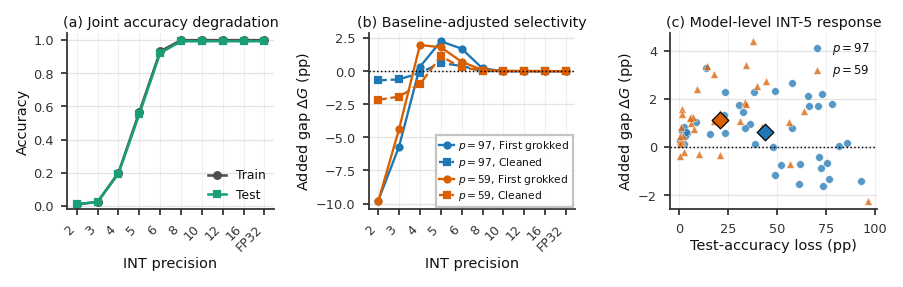

Saved:
/kaggle/working/neurocomputing_final_figures/fig2_primary_selectivity_final.pdf
/kaggle/working/neurocomputing_final_figures/fig2_primary_selectivity_final.png

Panel (c): cleaned INT-5 means
    mean_test_loss_pp  mean_added_gap_pp
p                                       
59             20.907              1.121
97             44.002              0.629


In [ ]:
# ============================================================
# FIGURE 2 — FINAL COMPACT NEUROCOMPUTING VERSION
#
# Panels:
#   (a) Joint INT-induced train/test degradation
#   (b) Baseline-adjusted train-test selectivity
#   (c) Model-level INT-5 response
#
# Figure size:
#   width  = 5.5 inches
#   height = 2.0 inches
#
# NOTE:
#   All plotted values are computed directly from the saved
#   experimental records. No experimental values are hard-coded.
# ============================================================

# -------------------------
# Panel (a) data
# -------------------------
fig2_a = (
    ptq_int.loc[
        (ptq_int["p"] == 97) &
        (ptq_int["phase"] == "cleaned_up")
    ]
    .groupby("bits", as_index=False)[["q_train_acc", "q_test_acc"]]
    .mean()
    .set_index("bits")
    .loc[BITS_ORDER]
    .reset_index()
)

# -------------------------
# Panel (b) data
# -------------------------
fig2_b = (
    ptq_int.loc[
        ptq_int["phase"].isin(["just_grokked", "cleaned_up"])
    ]
    .groupby(
        ["p", "phase", "bits"],
        as_index=False
    )["DeltaG_pp"]
    .mean()
)

fig2_b["phase_label"] = fig2_b["phase"].map(PHASE_LABEL)

# -------------------------
# Panel (c) data
# cleaned checkpoint, INT-5
# -------------------------
fig2_c = (
    ptq_int.loc[
        (ptq_int["phase"] == "cleaned_up") &
        (ptq_int["bits"] == 5),
        ["p", "seed", "TestLoss_pp", "DeltaG_pp"]
    ]
    .copy()
)


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    1, 3,
    figsize=(5.5, 2.0)
)

# Compact spacing suited to the reduced figure dimensions
fig.subplots_adjust(
    left=0.075,
    right=0.995,
    bottom=0.27,
    top=0.82,
    wspace=0.46
)

x = np.arange(len(BITS_ORDER))


# ============================================================
# PANEL (a)
# Joint train/test degradation
# ============================================================

ax = axes[0]

ax.plot(
    x,
    fig2_a["q_train_acc"],
    marker="o",
    markersize=3.0,
    color=COLOR_TRAIN,
    linewidth=1.15,
    label="Train"
)

ax.plot(
    x,
    fig2_a["q_test_acc"],
    marker="s",
    markersize=3.0,
    color=COLOR_TEST,
    linewidth=1.15,
    label="Test"
)

ax.set_xticks(x)
ax.set_xticklabels(
    BITS_LABELS,
    rotation=45,
    ha="right",
    fontsize=5.7
)

ax.set_ylim(-0.02, 1.04)

ax.set_xlabel(
    "INT precision",
    fontsize=6.5,
    labelpad=1.5
)

ax.set_ylabel(
    "Accuracy",
    fontsize=6.5,
    labelpad=1.5
)

ax.tick_params(
    axis="y",
    labelsize=5.8
)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=5.6,
    handlelength=1.4,
    borderaxespad=0.25
)

clean_axes(ax)

# Brief non-bold panel caption
ax.set_title(
    "(a) Joint accuracy degradation",
    fontsize=6.4,
    fontweight="normal",
    pad=3
)


# ============================================================
# PANEL (b)
# Baseline-adjusted selectivity
# ============================================================

ax = axes[1]

line_styles = {
    "just_grokked": "-",
    "cleaned_up": "--",
}

markers = {
    "just_grokked": "o",
    "cleaned_up": "s",
}

colors = {
    97: COLOR_97,
    59: COLOR_59,
}

for p_val in [97, 59]:

    for phase in ["just_grokked", "cleaned_up"]:

        tmp = (
            fig2_b.loc[
                (fig2_b["p"] == p_val) &
                (fig2_b["phase"] == phase)
            ]
            .set_index("bits")
            .loc[BITS_ORDER]
            .reset_index()
        )

        ax.plot(
            x,
            tmp["DeltaG_pp"],
            linestyle=line_styles[phase],
            marker=markers[phase],
            markersize=2.7,
            color=colors[p_val],
            linewidth=1.05,
            label=f"$p={p_val}$, {PHASE_LABEL[phase]}"
        )

ax.axhline(
    0.0,
    color="black",
    linewidth=0.65,
    linestyle=":"
)

ax.set_xticks(x)
ax.set_xticklabels(
    BITS_LABELS,
    rotation=45,
    ha="right",
    fontsize=5.7
)

ax.set_xlabel(
    "INT precision",
    fontsize=6.5,
    labelpad=1.5
)

ax.set_ylabel(
    r"Added gap $\Delta G$ (pp)",
    fontsize=6.5,
    labelpad=1.5
)

ax.tick_params(
    axis="y",
    labelsize=5.8
)

# Legend box at bottom-right
ax.legend(
    frameon=True,
    loc="lower right",
    fontsize=4.8,
    handlelength=1.35,
    handletextpad=0.4,
    labelspacing=0.25,
    borderpad=0.35,
    borderaxespad=0.25,
    fancybox=False,
    edgecolor="0.75",
    facecolor="white",
    framealpha=0.92
)

clean_axes(ax)

ax.set_title(
    "(b) Baseline-adjusted selectivity",
    fontsize=6.4,
    fontweight="normal",
    pad=3
)


# ============================================================
# PANEL (c)
# Model-level cleaned INT-5 response
# ============================================================

ax = axes[2]

for p_val, color, marker in [
    (97, COLOR_97, "o"),
    (59, COLOR_59, "^"),
]:

    tmp = fig2_c.loc[
        fig2_c["p"] == p_val
    ].copy()

    # Individual trained models
    ax.scatter(
        tmp["TestLoss_pp"],
        tmp["DeltaG_pp"],
        s=12,
        alpha=0.75,
        color=color,
        marker=marker,
        edgecolor="white",
        linewidth=0.25,
        label=f"$p={p_val}$"
    )

    # Group mean
    ax.scatter(
        [tmp["TestLoss_pp"].mean()],
        [tmp["DeltaG_pp"].mean()],
        s=28,
        color=color,
        marker="D",
        edgecolor="black",
        linewidth=0.55,
        zorder=5
    )

ax.axhline(
    0.0,
    color="black",
    linewidth=0.65,
    linestyle=":"
)

ax.set_xlabel(
    "Test-accuracy loss (pp)",
    fontsize=6.5,
    labelpad=1.5
)

ax.set_ylabel(
    r"Added gap $\Delta G$ (pp)",
    fontsize=6.5,
    labelpad=1.5
)

ax.tick_params(
    axis="both",
    labelsize=5.8
)

ax.legend(
    frameon=False,
    loc="upper right",
    fontsize=5.3,
    handletextpad=0.25,
    borderaxespad=0.2
)

clean_axes(ax)

ax.set_title(
    "(c) Model-level INT-5 response",
    fontsize=6.4,
    fontweight="normal",
    pad=3
)


# ============================================================
# SAVE
# ============================================================

pdf_path = OUT_DIR / "fig2_primary_selectivity_final.pdf"
png_path = OUT_DIR / "fig2_primary_selectivity_final.png"

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.02
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.02
)

plt.show()

print("Saved:")
print(pdf_path)
print(png_path)


# ============================================================
# NUMERICAL CROSS-CHECK
# ============================================================

print("\nPanel (c): cleaned INT-5 means")

summary_c = (
    fig2_c
    .groupby("p")[["TestLoss_pp", "DeltaG_pp"]]
    .mean()
    .rename(
        columns={
            "TestLoss_pp": "mean_test_loss_pp",
            "DeltaG_pp": "mean_added_gap_pp"
        }
    )
)

print(
    summary_c.to_string(
        float_format=lambda z: f"{z:.3f}"
    )
)

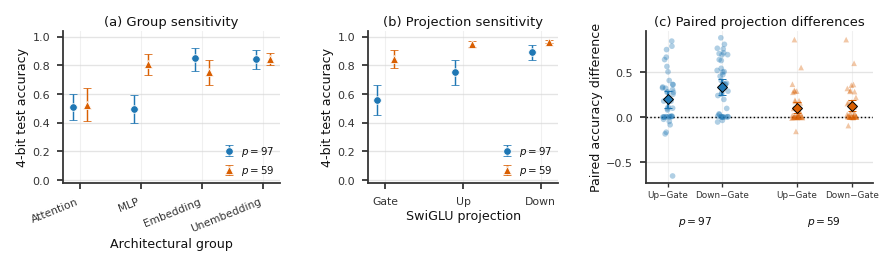

Saved:
/kaggle/working/neurocomputing_final_figures/fig3_architectural_fragility_paired_final.pdf
/kaggle/working/neurocomputing_final_figures/fig3_architectural_fragility_paired_final.png

Broad-group summary:
 p group_label   mean     lo     hi  n
97   Attention 0.5078 0.4187 0.5971 40
97         MLP 0.4937 0.3945 0.5947 40
97   Embedding 0.8475 0.7610 0.9187 40
97 Unembedding 0.8446 0.7774 0.9043 40
59   Attention 0.5230 0.4094 0.6408 36
59         MLP 0.8070 0.7331 0.8764 36
59   Embedding 0.7523 0.6612 0.8350 36
59 Unembedding 0.8457 0.8001 0.8846 36

SwiGLU projection summary:
 p group_label   mean     lo     hi  n
97        Gate 0.5561 0.4559 0.6594 40
97          Up 0.7512 0.6604 0.8392 40
97        Down 0.8915 0.8398 0.9381 40
59        Gate 0.8459 0.7780 0.9064 36
59          Up 0.9503 0.9263 0.9692 36
59        Down 0.9653 0.9550 0.9739 36

Paired SwiGLU contrast summary:
 p contrast_label   mean     lo     hi  n
97      Up − Gate 0.1951 0.1047 0.2861 40
97    Down − Gate 0.

In [ ]:
# ============================================================
# FIGURE 3 — FINAL RIGOROUS NEUROCOMPUTING VERSION
#
# Architectural fragility
#
# Panels:
#   (a) Architectural-group sensitivity at 4-bit INT
#   (b) SwiGLU projection sensitivity at 4-bit INT
#   (c) Paired SwiGLU accuracy differences:
#         Up - Gate
#         Down - Gate
#
# Figure size:
#   width  = 5.5 inches
#   height = 2.0 inches
#
# IMPORTANT:
#   - Previously-grokked models only.
#   - Panel (c) preserves within-model pairing.
#   - Every plotted difference is computed from the SAME model.
#   - No experimental result is hard-coded.
# ============================================================

BIT_FOCUS = 4


# ============================================================
# PANEL (a) DATA
# Broad architectural groups
# ============================================================

groups_order = [
    "attention",
    "mlp",
    "embedding",
    "unembed",
]

group_rows = []

for p_val in [97, 59]:

    for grp in groups_order:

        vals = layerwise_eligible.loc[
            (layerwise_eligible["p"] == p_val) &
            (layerwise_eligible["group"] == grp) &
            (layerwise_eligible["bits"] == BIT_FOCUS),
            "q_test_acc"
        ].values

        mean_v, lo_v, hi_v = bootstrap_mean_ci(
            vals,
            n_boot=3000,
            alpha=0.05,
            seed=1000 + p_val
        )

        group_rows.append({
            "p": p_val,
            "group": grp,
            "group_label": GROUP_LABEL[grp],
            "mean": mean_v,
            "lo": lo_v,
            "hi": hi_v,
            "n": len(vals),
        })

group_summary = pd.DataFrame(group_rows)


# ============================================================
# PANEL (b) DATA
# SwiGLU projections
# ============================================================

fine_order = [
    "mlp_gate",
    "mlp_up",
    "mlp_down",
]

fine_rows = []

for p_val in [97, 59]:

    for grp in fine_order:

        vals = layerwise_fine_eligible.loc[
            (layerwise_fine_eligible["p"] == p_val) &
            (layerwise_fine_eligible["group"] == grp) &
            (layerwise_fine_eligible["bits"] == BIT_FOCUS),
            "q_test_acc"
        ].values

        mean_v, lo_v, hi_v = bootstrap_mean_ci(
            vals,
            n_boot=3000,
            alpha=0.05,
            seed=2000 + p_val
        )

        fine_rows.append({
            "p": p_val,
            "group": grp,
            "group_label": GROUP_LABEL[grp],
            "mean": mean_v,
            "lo": lo_v,
            "hi": hi_v,
            "n": len(vals),
        })

fine_summary = pd.DataFrame(fine_rows)


# ============================================================
# PANEL (c) DATA
# Paired SwiGLU differences within the SAME trained model
# ============================================================

paired_source = (
    layerwise_fine_eligible.loc[
        layerwise_fine_eligible["bits"] == BIT_FOCUS,
        ["p", "seed", "group", "q_test_acc"]
    ]
    .copy()
)

# Each model must have at most one observation per projection.
assert not paired_source.duplicated(
    ["p", "seed", "group"]
).any(), "Unexpected duplicate projection rows."

paired = (
    paired_source
    .pivot(
        index=["p", "seed"],
        columns="group",
        values="q_test_acc"
    )
    .reset_index()
)

# Require all three SwiGLU projections for a valid paired model.
paired = paired.dropna(
    subset=[
        "mlp_gate",
        "mlp_up",
        "mlp_down",
    ]
).copy()

paired["up_minus_gate"] = (
    paired["mlp_up"] -
    paired["mlp_gate"]
)

paired["down_minus_gate"] = (
    paired["mlp_down"] -
    paired["mlp_gate"]
)

# Manuscript-critical denominator checks.
assert paired.loc[paired["p"] == 97, "seed"].nunique() == 40
assert paired.loc[paired["p"] == 59, "seed"].nunique() == 36


# ------------------------------------------------------------
# Bootstrap the mean of each PAIRED model-level difference.
# The paired difference is computed first, then whole models
# are resampled.
# ------------------------------------------------------------

paired_summary_rows = []

for p_val in [97, 59]:

    tmp = paired.loc[
        paired["p"] == p_val
    ].copy()

    for diff_col, diff_label in [
        ("up_minus_gate", "Up − Gate"),
        ("down_minus_gate", "Down − Gate"),
    ]:

        vals = tmp[diff_col].values

        mean_v, lo_v, hi_v = bootstrap_mean_ci(
            vals,
            n_boot=10000,
            alpha=0.05,
            seed=3000 + p_val + (
                0 if diff_col == "up_minus_gate" else 100
            )
        )

        paired_summary_rows.append({
            "p": p_val,
            "contrast": diff_col,
            "contrast_label": diff_label,
            "mean": mean_v,
            "lo": lo_v,
            "hi": hi_v,
            "n": len(vals),
        })

paired_summary = pd.DataFrame(
    paired_summary_rows
)


# ============================================================
# PLOT
# ============================================================

fig, axes = plt.subplots(
    1,
    3,
    figsize=(5.5, 2.0),
    gridspec_kw={
        "width_ratios": [1.05, 0.92, 1.10]
    }
)

# More bottom space for the two-level x-axis in panel (c).
fig.subplots_adjust(
    left=0.075,
    right=0.995,
    bottom=0.335,
    top=0.81,
    wspace=0.42
)

offset = 0.11


# ============================================================
# PANEL (a)
# Architectural-group sensitivity
# ============================================================

ax = axes[0]

x = np.arange(
    len(groups_order)
)

for p_val, color, marker, dx in [
    (97, COLOR_97, "o", -offset),
    (59, COLOR_59, "^", +offset),
]:

    tmp = (
        group_summary.loc[
            group_summary["p"] == p_val
        ]
        .set_index("group")
        .loc[groups_order]
        .reset_index()
    )

    y = tmp["mean"].values

    yerr = np.vstack([
        y - tmp["lo"].values,
        tmp["hi"].values - y
    ])

    ax.errorbar(
        x + dx,
        y,
        yerr=yerr,

        fmt=marker,

        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.35,

        markersize=3.4,

        linewidth=0.75,
        elinewidth=0.65,

        capsize=1.7,
        capthick=0.65,

        label=f"$p={p_val}$"
    )


ax.set_xticks(x)

ax.set_xticklabels(
    [
        GROUP_LABEL[g]
        for g in groups_order
    ],
    rotation=22,
    ha="right",
    fontsize=4.8
)

ax.set_ylim(
    -0.02,
    1.04
)

ax.set_xlabel(
    "Architectural group",
    fontsize=5.7,
    labelpad=1.5
)

ax.set_ylabel(
    "4-bit test accuracy",
    fontsize=5.7,
    labelpad=1.5
)

ax.tick_params(
    axis="y",
    labelsize=5.0
)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=4.6,
    handletextpad=0.2,
    borderaxespad=0.15
)

clean_axes(ax)

ax.set_title(
    "(a) Group sensitivity",
    fontsize=5.9,
    fontweight="normal",
    pad=2.5
)


# ============================================================
# PANEL (b)
# SwiGLU projection sensitivity
# ============================================================

ax = axes[1]

x2 = np.arange(
    len(fine_order)
)

for p_val, color, marker, dx in [
    (97, COLOR_97, "o", -offset),
    (59, COLOR_59, "^", +offset),
]:

    tmp = (
        fine_summary.loc[
            fine_summary["p"] == p_val
        ]
        .set_index("group")
        .loc[fine_order]
        .reset_index()
    )

    y = tmp["mean"].values

    yerr = np.vstack([
        y - tmp["lo"].values,
        tmp["hi"].values - y
    ])

    ax.errorbar(
        x2 + dx,
        y,
        yerr=yerr,

        fmt=marker,

        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.35,

        markersize=3.4,

        linewidth=0.75,
        elinewidth=0.65,

        capsize=1.7,
        capthick=0.65,

        label=f"$p={p_val}$"
    )


ax.set_xticks(x2)

ax.set_xticklabels(
    [
        GROUP_LABEL[g]
        for g in fine_order
    ],
    fontsize=4.9
)

ax.set_ylim(
    -0.02,
    1.04
)

ax.set_xlabel(
    "SwiGLU projection",
    fontsize=5.7,
    labelpad=1.5
)

ax.set_ylabel(
    "4-bit test accuracy",
    fontsize=5.7,
    labelpad=1.5
)

ax.tick_params(
    axis="y",
    labelsize=5.0
)

ax.legend(
    frameon=False,
    loc="lower right",
    fontsize=4.6,
    handletextpad=0.2,
    borderaxespad=0.15
)

clean_axes(ax)

ax.set_title(
    "(b) Projection sensitivity",
    fontsize=5.9,
    fontweight="normal",
    pad=2.5
)


# ============================================================
# PANEL (c)
# Paired within-model projection differences
# ============================================================

ax = axes[2]

# Four compact groups:
#   p97 Up-Gate
#   p97 Down-Gate
#   p59 Up-Gate
#   p59 Down-Gate

x_positions = {
    (97, "up_minus_gate"): 0.00,
    (97, "down_minus_gate"): 0.72,
    (59, "up_minus_gate"): 1.70,
    (59, "down_minus_gate"): 2.42,
}

# Deterministic jitter only for visualization.
# It does not modify any experimental value.
rng = np.random.default_rng(
    20261001
)

for p_val, color, marker in [
    (97, COLOR_97, "o"),
    (59, COLOR_59, "^"),
]:

    tmp = paired.loc[
        paired["p"] == p_val
    ].copy()

    for diff_col in [
        "up_minus_gate",
        "down_minus_gate",
    ]:

        xpos = x_positions[
            (p_val, diff_col)
        ]

        vals = tmp[
            diff_col
        ].values

        jitter = rng.uniform(
            -0.075,
            0.075,
            size=len(vals)
        )

        # Individual paired model differences
        ax.scatter(
            xpos + jitter,
            vals,

            s=6.5,

            color=color,
            marker=marker,

            alpha=0.35,

            edgecolor="none",

            zorder=2
        )

        # Mean + model-bootstrap CI
        summary_row = paired_summary.loc[
            (paired_summary["p"] == p_val) &
            (paired_summary["contrast"] == diff_col)
        ].iloc[0]

        mean_v = summary_row["mean"]

        yerr = np.array([
            [mean_v - summary_row["lo"]],
            [summary_row["hi"] - mean_v]
        ])

        ax.errorbar(
            xpos,
            mean_v,

            yerr=yerr,

            fmt="D",

            color=color,
            markerfacecolor=color,
            markeredgecolor="black",
            markeredgewidth=0.45,

            markersize=3.5,

            elinewidth=0.85,
            capsize=2.0,
            capthick=0.75,

            zorder=5
        )


# Zero means equal gate and comparator accuracy.
ax.axhline(
    0,
    color="black",
    linewidth=0.65,
    linestyle=":",
    zorder=1
)


# ------------------------------------------------------------
# Clean two-level x-axis
# First level: contrasts
# Second level: prime groups
# ------------------------------------------------------------

contrast_positions = [
    0.00,
    0.72,
    1.70,
    2.42
]

contrast_labels = [
    "Up−Gate",
    "Down−Gate",
    "Up−Gate",
    "Down−Gate"
]

# First level: contrast labels
ax.set_xticks(
    contrast_positions
)

ax.set_xticklabels(
    contrast_labels,
    fontsize=4,
    rotation=0,
    ha="center"
)

ax.tick_params(
    axis="x",
    pad=1.5,
    length=2.0,
    width=0.6
)

# Second level: prime labels
ax.text(
    0.36,
    -0.205,
    r"$p=97$",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=4.8
)

ax.text(
    2.06,
    -0.205,
    r"$p=59$",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="top",
    fontsize=4.8
)

ax.set_xlim(
    -0.28,
    2.70
)


ax.set_ylabel(
    "Paired accuracy difference",
    fontsize=5.7,
    labelpad=1.5
)

ax.tick_params(
    axis="y",
    labelsize=5.0
)

clean_axes(ax)

ax.set_title(
    "(c) Paired projection differences",
    fontsize=5.9,
    fontweight="normal",
    pad=2.5
)


# ============================================================
# SAVE
# ============================================================

pdf_path = (
    OUT_DIR /
    "fig3_architectural_fragility_paired_final.pdf"
)

png_path = (
    OUT_DIR /
    "fig3_architectural_fragility_paired_final.png"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.015
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.015
)

plt.show()


# ============================================================
# NUMERICAL CROSS-CHECK
# ============================================================

print("Saved:")
print(pdf_path)
print(png_path)


print("\nBroad-group summary:")
print(
    group_summary[
        [
            "p",
            "group_label",
            "mean",
            "lo",
            "hi",
            "n"
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda z: f"{z:.4f}"
    )
)


print("\nSwiGLU projection summary:")
print(
    fine_summary[
        [
            "p",
            "group_label",
            "mean",
            "lo",
            "hi",
            "n"
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda z: f"{z:.4f}"
    )
)


print("\nPaired SwiGLU contrast summary:")
print(
    paired_summary[
        [
            "p",
            "contrast_label",
            "mean",
            "lo",
            "hi",
            "n"
        ]
    ]
    .to_string(
        index=False,
        float_format=lambda z: f"{z:.4f}"
    )
)

In [ ]:
# ============================================================
# SMALL DIAGNOSTIC CELL — E5 PTQ FILES ONLY
#
# Purpose:
#   Inspect the multiplication and subtraction PTQ datasets
#   before generating the final cross-task Figure 4.
#
# This cell only prints:
#   - path
#   - shape
#   - column names
#   - unique low-cardinality values
#   - first 3 rows
#
# It does NOT modify any data.
# ============================================================

from pathlib import Path
import pandas as pd

E5_FILES = {
    "multiplication": Path(
        "/kaggle/input/datasets/mdmuntaqimmeherab/e5-dataset/"
        "outputs/logs/e5a_multiplication_ptq_rows.csv"
    ),
    "subtraction": Path(
        "/kaggle/input/datasets/mdmuntaqimmeherab/e5-dataset/"
        "outputs/logs/e5b_subtraction_ptq_rows.csv"
    ),
}

for name, path in E5_FILES.items():

    print("\n" + "=" * 100)
    print(name.upper())
    print("=" * 100)

    print("PATH:")
    print(path)

    df = pd.read_csv(path)

    print("\nSHAPE:")
    print(df.shape)

    print("\nCOLUMNS:")
    print(df.columns.tolist())

    print("\nUNIQUE / REPRESENTATIVE VALUES:")

    for col in df.columns:
        s = df[col].dropna()

        if s.nunique() <= 30:
            print(f"{col}: {s.drop_duplicates().tolist()}")
        else:
            print(
                f"{col}: {s.nunique()} unique values; "
                f"sample={s.drop_duplicates().head(8).tolist()}"
            )

    print("\nFIRST 3 ROWS:")
    print(df.head(3).to_string(index=False))


MULTIPLICATION
PATH:
/kaggle/input/datasets/mdmuntaqimmeherab/e5-dataset/outputs/logs/e5a_multiplication_ptq_rows.csv

SHAPE:
(7290, 15)

COLUMNS:
['p', 'seed', 'task', 'phase', 'phase_step', 'fp32_train_acc', 'fp32_test_acc', 'weight_norm', 'scheme', 'bits', 'q_train_acc', 'q_test_acc', 'd_ff', 'train_frac', 'tag']

UNIQUE / REPRESENTATIVE VALUES:
p: [97, 59]
seed: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
task: ['multiplication']
phase: ['just_grokked', 'post_grok_500', 'post_grok_1500', 'post_grok_4000', 'cleaned_up', 'pre_grok']
phase_step: 144 unique values; sample=[650, 1150, 2150, 4650, 30000, 550, 1050, 2050]
fp32_train_acc: 35 unique values; sample=[0.9978296160697936, 1.0, 0.9915897846221924, 0.992675006389618, 0.9994574189186096, 0.98372220993042, 0.9612045288085938, 0.9793814420700072]
fp32_test_acc: 192 unique values; sample=[0.9065099358558656, 0.9734176993370056, 0.9844484329223632, 0.992585837841034, 0.9918625354766846, 

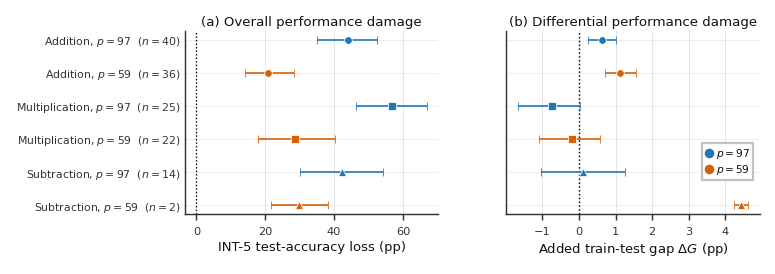


Saved:
/kaggle/working/neurocomputing_final_figures/fig4_cross_task_robustness_final.pdf
/kaggle/working/neurocomputing_final_figures/fig4_cross_task_robustness_final.png

FIGURE 4 SOURCE-DERIVED SUMMARY
          task  p  n  test_mean  test_lo  test_hi  gap_mean  gap_lo  gap_hi
      Addition 97 40    44.0024  35.1328  52.5967    0.6288  0.2478  1.0135
      Addition 59 36    20.9071  14.0545  28.4826    1.1215  0.6974  1.5477
Multiplication 97 25    56.8231  46.3833  66.8701   -0.7308 -1.6711  0.0133
Multiplication 59 22    28.4862  17.7766  40.2747   -0.2059 -1.0849  0.5838
   Subtraction 97 14    42.1778  29.9801  54.1726    0.1217 -1.0440  1.2703
   Subtraction 59  2    29.8947  21.6850  38.1044    4.4277  4.2281  4.6273


In [ ]:
# ============================================================
# 8. FIGURE — COMPACT NEUROCOMPUTING VERSION
# ============================================================
#
# Final dimensions:
#   width  = 5.5 inches
#   height = 2.0 inches
#
# All statistical calculations above remain UNCHANGED.
# Only figure presentation is adjusted.
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(5.5, 2.0),
    sharey=True
)

# Carefully tuned for six horizontal populations at 2-inch height.
fig.subplots_adjust(
    left=0.335,
    right=0.988,
    bottom=0.235,
    top=0.805,
    wspace=0.27
)


# ============================================================
# PANEL (a)
# INT-5 TEST-ACCURACY LOSS
# ============================================================

ax = axes[0]

for _, row in forest.iterrows():

    y = row["y"]
    mean = row["test_mean"]

    lower = mean - row["test_lo"]
    upper = row["test_hi"] - mean

    marker = {
        "Addition": "o",
        "Multiplication": "s",
        "Subtraction": "^",
    }[row["task"]]

    color = (
        COLOR_97
        if row["p"] == 97
        else COLOR_59
    )

    ax.errorbar(
        mean,
        y,
        xerr=np.array([[lower], [upper]]),

        fmt=marker,

        # Compact marker formatting
        markersize=3.4,

        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.35,

        # Compact CI formatting
        elinewidth=0.75,
        capsize=1.7,
        capthick=0.7,

        zorder=3
    )


# Zero-reference line
ax.axvline(
    0,
    color="black",
    linewidth=0.6,
    linestyle=":"
)


# ------------------------------------------------------------
# Population labels
# ------------------------------------------------------------

ax.set_yticks(
    forest["y"]
)

ax.set_yticklabels(
    forest["label"],
    fontsize=4.9
)

ax.tick_params(
    axis="y",
    length=0,
    pad=2
)


# ------------------------------------------------------------
# Axis label / ticks
# ------------------------------------------------------------

ax.set_xlabel(
    "INT-5 test-accuracy loss (pp)",
    fontsize=5.9,
    labelpad=1.8
)

ax.tick_params(
    axis="x",
    labelsize=5.1,
    length=2.5,
    width=0.65
)


# ------------------------------------------------------------
# Brief, non-bold subcaption
# ------------------------------------------------------------

ax.set_title(
    "(a) Overall performance damage",
    fontsize=6.0,
    fontweight="normal",
    pad=2.5
)


# ------------------------------------------------------------
# Minimal journal styling
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.65)
ax.spines["bottom"].set_linewidth(0.65)

ax.grid(
    axis="x",
    color="#d9d9d9",
    linewidth=0.45,
    alpha=0.65
)

ax.set_axisbelow(True)


# ============================================================
# PANEL (b)
# BASELINE-ADJUSTED ADDED GAP
# ============================================================

ax = axes[1]

for _, row in forest.iterrows():

    y = row["y"]
    mean = row["gap_mean"]

    lower = mean - row["gap_lo"]
    upper = row["gap_hi"] - mean

    marker = {
        "Addition": "o",
        "Multiplication": "s",
        "Subtraction": "^",
    }[row["task"]]

    color = (
        COLOR_97
        if row["p"] == 97
        else COLOR_59
    )

    ax.errorbar(
        mean,
        y,
        xerr=np.array([[lower], [upper]]),

        fmt=marker,

        markersize=3.4,

        color=color,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.35,

        elinewidth=0.75,
        capsize=1.7,
        capthick=0.7,

        zorder=3
    )


# Zero = equal additional damage to train and test.
ax.axvline(
    0,
    color="black",
    linewidth=0.65,
    linestyle=":"
)


# ------------------------------------------------------------
# Axis label / ticks
# ------------------------------------------------------------

ax.set_xlabel(
    r"Added train-test gap $\Delta G$ (pp)",
    fontsize=5.9,
    labelpad=1.8
)

ax.tick_params(
    axis="x",
    labelsize=5.1,
    length=2.5,
    width=0.65
)

# Because sharey=True, suppress duplicated right-panel
# y-axis tick marks/labels.
ax.tick_params(
    axis="y",
    left=False,
    labelleft=False
)


# ------------------------------------------------------------
# Brief, non-bold subcaption
# ------------------------------------------------------------

ax.set_title(
    "(b) Differential performance damage",
    fontsize=6.0,
    fontweight="normal",
    pad=2.5
)


# ------------------------------------------------------------
# Minimal journal styling
# ------------------------------------------------------------

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(0.65)
ax.spines["bottom"].set_linewidth(0.65)

ax.grid(
    axis="x",
    color="#d9d9d9",
    linewidth=0.45,
    alpha=0.65
)

ax.set_axisbelow(True)


# ============================================================
# 9. COMPACT PRIME LEGEND
# ============================================================

from matplotlib.lines import Line2D

prime_legend = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=COLOR_97,
        markeredgecolor=COLOR_97,
        markersize=3.3,
        label=r"$p=97$"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="none",
        markerfacecolor=COLOR_59,
        markeredgecolor=COLOR_59,
        markersize=3.3,
        label=r"$p=59$"
    ),
]

axes[1].legend(
    handles=prime_legend,

    # boxed legend
    frameon=True,
    fancybox=False,
    framealpha=0.95,
    edgecolor="0.75",
    facecolor="white",

    fontsize=4.8,

    # right-side, slightly above the bottom-right corner
    loc="lower right",
    bbox_to_anchor=(0.98, 0.18),

    handlelength=0.8,
    handletextpad=0.25,
    labelspacing=0.2,
    borderpad=0.28,
    borderaxespad=0.12
)


# ============================================================
# 10. SAVE — VECTOR PDF + HIGH-RES PNG
# ============================================================

pdf_path = (
    OUT_DIR /
    "fig4_cross_task_robustness_final.pdf"
)

png_path = (
    OUT_DIR /
    "fig4_cross_task_robustness_final.png"
)

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.015
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.015
)

plt.show()


# ============================================================
# 11. PRINT EXACT SOURCE-DERIVED NUMERICAL SUMMARY
# ============================================================

print("\nSaved:")
print(pdf_path)
print(png_path)

print("\n" + "=" * 90)
print("FIGURE 4 SOURCE-DERIVED SUMMARY")
print("=" * 90)

display_table = forest[
    [
        "task",
        "p",
        "n",
        "test_mean",
        "test_lo",
        "test_hi",
        "gap_mean",
        "gap_lo",
        "gap_hi",
    ]
].copy()

print(
    display_table.to_string(
        index=False,
        float_format=lambda z: f"{z:.4f}"
    )
)

Saved:
/kaggle/working/outputs/figures/fig8_grokking_trajectory_final.pdf
/kaggle/working/outputs/figures/fig8_grokking_trajectory_final.png


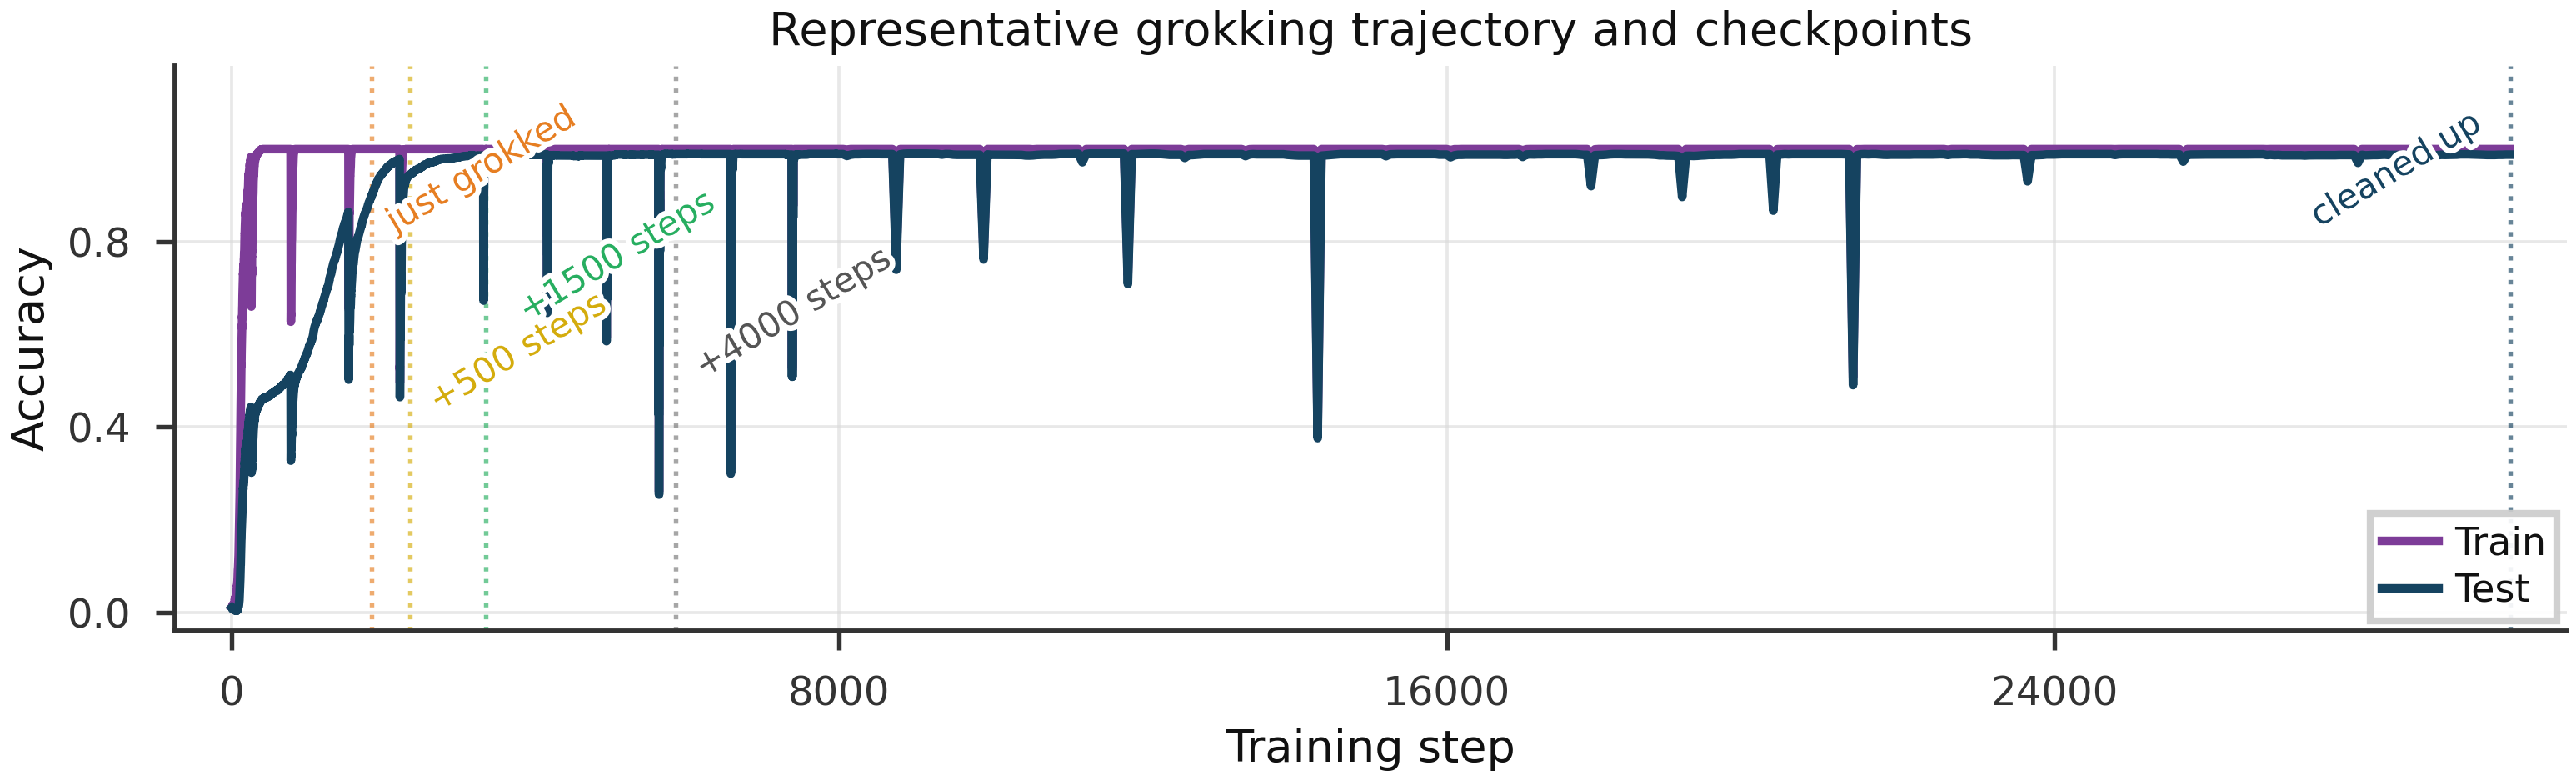

In [ ]:
# ============================================================
# FIGURE 1 / ORIGINAL FIGURE 8
# REPRESENTATIVE GROKKING TRAJECTORY — FINAL CORRECTED VERSION
#
# Purpose:
#   Show the representative train/test trajectory and the
#   locations of the recorded post-grokking checkpoints.
#
# Figure size:
#   width  = 5.5 inches
#   height = 2.0 inches
#
# IMPORTANT:
#   - Uses the original saved training/test trajectory.
#   - Does not modify any experimental values.
#   - Phase locations are taken directly from df_ptq.
#   - All checkpoint labels are retained.
#   - Closely spaced labels use dedicated vertical annotation
#     lanes so "just grokked", "+500 steps", and "+1500 steps"
#     remain readable without covering one another.
# ============================================================

import os
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from IPython.display import Image, display


# ============================================================
# SHORT PHASE LABELS
# ============================================================

def _short_phase_label(ph):
    """
    Return compact human-readable checkpoint labels.
    """

    # Explicit labels used by the final figure.
    fixed = {
        "pre_grok": "pre-grok",
        "just_grokked": "just grokked",
        "cleaned_up": "cleaned up",
    }

    if ph in fixed:
        return fixed[ph]

    # Any post_grok_N checkpoint becomes "+N steps".
    if ph.startswith("post_grok_"):
        offset = ph.replace("post_grok_", "")
        return f"+{offset} steps"

    # Use notebook mapping only for any other phase.
    if ph in PHASE_LABELS:
        return PHASE_LABELS[ph]

    return ph.replace("_", " ")


# ============================================================
# MAIN FIGURE FUNCTION
# ============================================================

def make_figure8(
    df_ptq,
    trajectory_info,
    p_primary,
    save_path
):

    # --------------------------------------------------------
    # FINAL FIGURE DIMENSIONS
    # --------------------------------------------------------

    fig = plt.figure(
        figsize=(5.5, 2.0)
    )

    gs = GridSpec(
        1,
        1,
        figure=fig,
        left=0.105,
        right=0.975,
        bottom=0.235,
        top=0.80
    )

    ax = fig.add_subplot(
        gs[0]
    )


    # --------------------------------------------------------
    # JOURNAL-STYLE AXIS
    # --------------------------------------------------------

    ax.set_facecolor("white")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.7)
    ax.spines["bottom"].set_linewidth(0.7)

    ax.grid(
        axis="both",
        color="#d9d9d9",
        linewidth=0.45,
        alpha=0.60
    )

    ax.set_axisbelow(True)


    # ========================================================
    # FIND REPRESENTATIVE TRAJECTORY
    # ========================================================

    traj = None

    for t in (trajectory_info or []):

        if (
            t["p"] == p_primary
            and t["seed"] == 0
            and t.get("train_test_history")
        ):
            traj = t["train_test_history"]
            break


    phase_list = []


    # ========================================================
    # DRAW TRAJECTORY
    # ========================================================

    if traj:

        steps = [
            s for s, tr, te in traj
        ]

        train_accs = [
            tr for s, tr, te in traj
        ]

        test_accs = [
            te for s, tr, te in traj
        ]


        # ----------------------------------------------------
        # Train trajectory
        # ----------------------------------------------------

        ax.plot(
            steps,
            train_accs,
            color=COLORS["train"],
            linewidth=1.25,
            label="Train",
            zorder=3
        )


        # ----------------------------------------------------
        # Test trajectory
        # ----------------------------------------------------

        ax.plot(
            steps,
            test_accs,
            color=COLORS["test"],
            linewidth=1.25,
            label="Test",
            zorder=3
        )


        # ====================================================
        # CHECKPOINT LOCATIONS
        # ====================================================

        phase_steps = (
            df_ptq.loc[
                (df_ptq["p"] == p_primary)
                & (df_ptq["seed"] == 0),
                [
                    "phase",
                    "phase_step"
                ]
            ]
            .drop_duplicates()
            .sort_values("phase_step")
            .reset_index(drop=True)
        )

        phase_list = list(
            phase_steps.itertuples(
                index=False
            )
        )


        # ----------------------------------------------------
        # Vertical checkpoint markers
        # ----------------------------------------------------

        for row in phase_list:

            ax.axvline(
                row.phase_step,

                color=COLORS.get(
                    row.phase,
                    "#777777"
                ),

                linewidth=0.65,
                linestyle=":",
                alpha=0.65,

                zorder=1
            )


        # ----------------------------------------------------
        # Compact legend
        # ----------------------------------------------------

        leg = ax.legend(
            loc="lower right",

            frameon=True,
            fancybox=False,

            framealpha=0.92,
            facecolor="white",
            edgecolor="0.80",

            fontsize=5.5,

            handlelength=1.5,
            handletextpad=0.4,
            labelspacing=0.25,

            borderpad=0.30,
            borderaxespad=0.25
        )


        # Additional annotation headroom
        ax.set_ylim(
            -0.04,
            1.18
        )


    else:

        no_data_placeholder(ax)
        leg = None


    # ========================================================
    # AXIS LABELS
    # ========================================================

    ax.set_xlabel(
        "Training step",
        fontsize=6.5,
        labelpad=2
    )

    ax.set_ylabel(
        "Accuracy",
        fontsize=6.5,
        labelpad=2
    )

    ax.tick_params(
        axis="both",
        labelsize=5.8,
        length=2.8,
        width=0.65
    )

    try:
        tighten_ticks(ax)
    except Exception:
        pass


    # ========================================================
    # FIGURE TITLE
    # ========================================================

    ax.set_title(
        "Representative grokking trajectory and checkpoints",
        fontsize=6.7,
        fontweight="normal",
        pad=3
    )


    # ========================================================
    # CHECKPOINT LABELS
    # ========================================================

    if phase_list:

        # x coordinate = data coordinates
        # y coordinate = axes fraction
        mixed = ax.get_xaxis_transform()

        x_min = min(steps)
        x_max = max(steps)

        total_span = max(
            x_max - x_min,
            1
        )


        # ----------------------------------------------------
        # Dedicated annotation lanes
        #
        # These are PRESENTATION positions only.
        # The actual checkpoint x positions remain unchanged.
        #
        # The important correction is that "just grokked"
        # and "+1500 steps" are deliberately placed on
        # different vertical lanes.
        # ----------------------------------------------------

        phase_y = {
            "pre_grok": 0.56,

            "just_grokked": 0.94,

            "post_grok_500": 0.61,

            "post_grok_1500": 0.79,

            "post_grok_4000": 0.69,

            "cleaned_up": 0.93,
        }


        # Small horizontal presentation shifts prevent long
        # rotated labels from visually touching each other.
        # These DO NOT change the checkpoint marker positions.
        phase_x_shift = {
            "pre_grok": 0.000,

            "just_grokked": 0.004,

            "post_grok_500": 0.006,

            "post_grok_1500": 0.012,

            "post_grok_4000": 0.006,

            "cleaned_up": -0.006,
        }


        # Generic lanes for any phase not explicitly listed
        # above (e.g. QUICK_TEST post-grok offsets).
        generic_lanes = [
            0.92,
            0.72,
            0.54,
            0.82,
        ]

        generic_index = 0


        for row in phase_list:

            ph = row.phase
            st = row.phase_step


            # ------------------------------------------------
            # Annotation y position
            # ------------------------------------------------

            if ph in phase_y:

                y_pos = phase_y[ph]

            else:

                y_pos = generic_lanes[
                    generic_index % len(generic_lanes)
                ]

                generic_index += 1


            # ------------------------------------------------
            # Annotation x position
            # ------------------------------------------------

            shift_frac = phase_x_shift.get(
                ph,
                0.005
            )

            x_text = (
                st
                + shift_frac * total_span
            )


            # ------------------------------------------------
            # Right-edge handling
            # ------------------------------------------------

            near_right_edge = (
                st >
                x_min + 0.86 * total_span
            )

            if near_right_edge:

                ha = "right"

                # Keep right-edge labels fully inside figure.
                if ph == "cleaned_up":
                    x_text = (
                        st
                        - 0.010 * total_span
                    )

            else:

                ha = "left"


            # ------------------------------------------------
            # Draw checkpoint label
            # ------------------------------------------------

            t = ax.text(
                x_text,
                y_pos,

                _short_phase_label(ph),

                fontsize=5.0,

                rotation=31,

                ha=ha,
                va="top",

                color=COLORS.get(
                    ph,
                    "#555555"
                ),

                transform=mixed,

                clip_on=False,

                zorder=5
            )


            # White outline retains readability over grid/curves.
            t.set_path_effects([
                pe.withStroke(
                    linewidth=1.6,
                    foreground="white"
                )
            ])


    # ========================================================
    # FINAL X LIMITS
    # ========================================================

    if traj:

        x_pad = (
            0.025
            * max(
                max(steps) - min(steps),
                1
            )
        )

        ax.set_xlim(
            min(steps) - x_pad,
            max(steps) + x_pad
        )


    # ========================================================
    # SAVE
    # ========================================================

    os.makedirs(
        os.path.dirname(save_path),
        exist_ok=True
    )

    png_path = (
        save_path.rsplit(
            ".pdf",
            1
        )[0]
        + ".png"
    )


    # Draw once before optional diagnostics.
    fig.canvas.draw()


    try:
        check_text_overlaps(fig)
    except Exception:
        pass


    # Vector PDF for manuscript
    fig.savefig(
        save_path,
        bbox_inches="tight",
        pad_inches=0.02
    )


    # High-resolution PNG preview
    fig.savefig(
        png_path,
        dpi=600,
        bbox_inches="tight",
        pad_inches=0.02
    )


    plt.close(fig)


    print("Saved:")
    print(save_path)
    print(png_path)


    display(
        Image(
            filename=png_path
        )
    )


# ============================================================
# GENERATE FIGURE
# ============================================================

make_figure8(
    df_add_ptq,
    addition_trajectory_info,
    P_PRIMARY,
    os.path.join(
        OUTPUT_ROOT,
        "figures",
        "fig8_grokking_trajectory_final.pdf"
    )
)

## 9. Tables


In [ ]:
os.makedirs(os.path.join(OUTPUT_ROOT, 'tables'), exist_ok=True)

BS = chr(92)

def save_table(df, name, caption):
    if df.empty:
        print('Skipping table (no data):', name)
        return
    csv_path = os.path.join(OUTPUT_ROOT, 'tables', '{}.csv'.format(name))
    tex_path = os.path.join(OUTPUT_ROOT, 'tables', '{}.tex'.format(name))
    df.to_csv(csv_path, index=False)
    latex_body = df.to_latex(index=False, float_format='%.3f')
    full_tex = (
        '% Auto-generated by experiment notebook. Requires ' + BS + 'usepackage{booktabs}.\n' +
        BS + 'begin{table}[t]\n' + BS + 'centering\n' +
        BS + 'caption{' + caption + '}\n' +
        BS + 'label{tab:' + name + '}\n' +
        latex_body +
        BS + 'end{table}\n'
    )
    with open(tex_path, 'w') as f:
        f.write(full_tex)
    print('Saved table:', csv_path, 'and', tex_path)


if not df_add_ptq.empty:
    core_table = df_add_ptq[(df_add_ptq.p == P_PRIMARY) & (df_add_ptq.scheme == 'int') & (df_add_ptq.phase == 'cleaned_up')].groupby(
        ['bits']).agg(n=('seed', 'count'), q_train_acc=('q_train_acc', 'mean'), q_test_acc=('q_test_acc', 'mean')).reset_index()
    core_table = core_table.rename(columns={'bits': 'Bits', 'n': 'N', 'q_train_acc': 'QTrainAcc', 'q_test_acc': 'QTestAcc'})
    save_table(core_table, 'e1_core_phenomenon', 'Quantized train/test accuracy vs. bit-width, canonical architecture (addition, p={}).'.format(P_PRIMARY))

if not df_add_fine.empty:
    fine_table = df_add_fine.groupby('n_levels').agg(n=('seed', 'count'), q_train_acc=('q_train_acc', 'mean'), q_test_acc=('q_test_acc', 'mean')).reset_index()
    fine_table = fine_table.rename(columns={'n_levels': 'Levels', 'n': 'N', 'q_train_acc': 'QTrainAcc', 'q_test_acc': 'QTestAcc'})
    save_table(fine_table, 'e2_fine_grained_scan', 'H6: fine-grained level-count scan (addition, p={}).'.format(P_PRIMARY))

if not df_add_layerwise.empty:
    lw_table = df_add_layerwise[df_add_layerwise.p == P_PRIMARY].groupby(['group', 'bits']).agg(n=('seed', 'count'), q_test_acc=('q_test_acc', 'mean')).reset_index()
    lw_table = lw_table.rename(columns={'group': 'WeightGroup', 'bits': 'Bits', 'n': 'N', 'q_test_acc': 'QTestAcc'})
    save_table(lw_table, 'e4_layer_group_sensitivity', 'H4: test accuracy quantizing one weight group (cleaned-up, addition, p={}).'.format(P_PRIMARY))

if not df_add_layerwise_fine.empty:
    lwf_table = df_add_layerwise_fine[df_add_layerwise_fine.p == P_PRIMARY].groupby(['group', 'bits']).agg(n=('seed', 'count'), q_test_acc=('q_test_acc', 'mean')).reset_index()
    lwf_table = lwf_table.rename(columns={'group': 'MLPSubgroup', 'bits': 'Bits', 'n': 'N', 'q_test_acc': 'QTestAcc'})
    save_table(lwf_table, 'e4b_mlp_gate_up_down', 'H4b: MLP gate/up/down sensitivity (cleaned-up, addition, p={}).'.format(P_PRIMARY))

if not df_width_layerwise.empty:
    width_table = df_width_layerwise[df_width_layerwise.group == 'mlp'].groupby('d_ff').agg(n=('seed', 'count'), q_test_acc=('q_test_acc', 'mean')).reset_index()
    width_table = width_table.rename(columns={'d_ff': 'd_ff', 'n': 'N', 'q_test_acc': 'QTestAcc_bits2'})
    save_table(width_table, 'e6_width_sweep', 'H4-theory: MLP-only quantized test accuracy at bits=2 vs. d_ff.')

if not df_tf_ptq.empty:
    tf_table = df_tf_ptq[(df_tf_ptq.phase == 'cleaned_up') & (df_tf_ptq.scheme == 'int')].groupby(['train_frac', 'bits']).agg(
        n=('seed', 'count'), q_train_acc=('q_train_acc', 'mean'), q_test_acc=('q_test_acc', 'mean')).reset_index()
    tf_table = tf_table.rename(columns={'train_frac': 'TrainFrac', 'bits': 'Bits', 'n': 'N', 'q_train_acc': 'QTrainAcc', 'q_test_acc': 'QTestAcc'})
    save_table(tf_table, 'e7_train_fraction_sweep', 'H7: quantized accuracy vs. bit-width across train fractions (addition, p={}).'.format(P_PRIMARY))

def bh_correct(stats_report):
    entries = [(k, v['p_value']) for k, v in stats_report.items() if isinstance(v, dict) and 'p_value' in v and not (isinstance(v['p_value'], float) and np.isnan(v['p_value']))]
    if not entries:
        return pd.DataFrame()
    entries.sort(key=lambda x: x[1])
    m = len(entries)
    rows = []
    prev_q = 1.0
    for rank, (key, p) in enumerate(reversed(entries), start=1):
        i = m - rank + 1
        q = min(prev_q, p * m / i)
        prev_q = q
        rows.append(dict(test=key, p_value=p, bh_q_value=q))
    return pd.DataFrame(rows[::-1])


# NEW: theory-verification summary table -- the three tests added in Sec. 7b, collected in one
# place for the appendix, alongside the raw captured weight-magnitude data (potentially large:
# saved separately below so it does not bloat this summary table).
theory_verif_rows = []
for key, label in [('theory_ab_vs_drop_rho', 'A(b) vs. degradation (aggregate)'),
                    ('theory_bits_vs_drop_rho_samesubset', 'bits vs. degradation (same subset)'),
                    ('theory_width_maxw_rho', 'Spearman(d_ff, max|W|)')]:
    v = stats_report.get(key)
    if v:
        theory_verif_rows.append(dict(test=label, rho=v.get('rho'), p_value=v.get('p_value'), n=v.get('n')))
for grp in ['attention', 'mlp', 'embedding', 'unembed']:
    v = stats_report.get('theory_ab_vs_drop_rho_{}'.format(grp))
    if v:
        theory_verif_rows.append(dict(test='A(b) vs. degradation ({})'.format(grp), rho=v.get('rho'), p_value=v.get('p_value'), n=v.get('n')))
sw = stats_report.get('theory_swiglu_assumption')
if sw:
    theory_verif_rows.append(dict(test='SwiGLU: frac. seeds with ||W_u x||>=||sigma(W_g x)||',
                                    rho=sw.get('frac_holds'), p_value=float('nan'), n=sw.get('n')))
df_theory_verif = pd.DataFrame(theory_verif_rows)
if not df_theory_verif.empty:
    save_table(df_theory_verif, 'theory_verification_summary', 'Direct tests of Claim 1, Proposition 2, and the SwiGLU gate assumption (Sec. 7b).')
    print()
    print(df_theory_verif.to_string(index=False))

# Raw captured weight-magnitude arrays: potentially large (up to ~220K floats per tensor per
# seed), so saved as its own file rather than folded into the summary table above -- exactly the
# 'large row/column but needed for the paper' case, kept in logs/ rather than tables/.
if not df_theory_mags.empty:
    os.makedirs(os.path.join(OUTPUT_ROOT, 'logs'), exist_ok=True)
    _mags_export = df_theory_mags.drop(columns=['mags']).copy()
    _mags_export['n_weights'] = df_theory_mags['mags'].apply(len)
    _mags_export.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'theory_weight_mag_summary.csv'), index=False)
    print()
    print('Saved theory_weight_mag_summary.csv ({} rows) -- per-tensor max/summary only.'.format(len(_mags_export)))
    print('Full per-weight magnitude arrays are large and kept in-memory only for this session,')
    print('not exported to CSV -- re-derivable from a re-run with the same seeds if needed.')

# NEW: precomputed tables that let a FUTURE run skip the theory-verification re-run entirely --
# the actual fix for the gap found when trying to reuse a prior run's output.zip as input here.
# Unlike the raw-magnitude export above, these ARE sufficient on their own: df_ab already holds
# the derived A(b) value per (p, seed, param, bits), not the distribution it came from, so no
# information needed by Tests 1 or 3 downstream is lost by saving only this. Only the Gaussian
# kappa cross-check (a secondary, appendix-level check) is unavailable on a reload -- noted
# explicitly above where that's checked, not silently skipped.
os.makedirs(os.path.join(OUTPUT_ROOT, 'logs'), exist_ok=True)
if not df_ab.empty:
    df_ab.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'theory_ab_table.csv'), index=False)
    print('Saved theory_ab_table.csv ({} rows) -- reusable directly by a future run (Sec. 6b).'.format(len(df_ab)))
if not df_theory_act.empty:
    df_theory_act.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'theory_activation_summary.csv'), index=False)
    print('Saved theory_activation_summary.csv ({} rows).'.format(len(df_theory_act)))
if not df_theory_width.empty:
    df_theory_width.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'theory_width_maxmag_table.csv'), index=False)
    print('Saved theory_width_maxmag_table.csv ({} rows).'.format(len(df_theory_width)))

df_bh = bh_correct(stats_report)
if not df_bh.empty:
    save_table(df_bh, 'bh_corrected_pvalues', 'Benjamini-Hochberg q-values, full family of hypothesis tests (Sec. 7).')
    print()
    print(df_bh.to_string(index=False))


Saved table: /kaggle/working/outputs/tables/e1_core_phenomenon.csv and /kaggle/working/outputs/tables/e1_core_phenomenon.tex
Saved table: /kaggle/working/outputs/tables/e2_fine_grained_scan.csv and /kaggle/working/outputs/tables/e2_fine_grained_scan.tex
Saved table: /kaggle/working/outputs/tables/e4_layer_group_sensitivity.csv and /kaggle/working/outputs/tables/e4_layer_group_sensitivity.tex
Saved table: /kaggle/working/outputs/tables/e4b_mlp_gate_up_down.csv and /kaggle/working/outputs/tables/e4b_mlp_gate_up_down.tex
Saved table: /kaggle/working/outputs/tables/e6_width_sweep.csv and /kaggle/working/outputs/tables/e6_width_sweep.tex
Saved table: /kaggle/working/outputs/tables/e7_train_fraction_sweep.csv and /kaggle/working/outputs/tables/e7_train_fraction_sweep.tex
Saved table: /kaggle/working/outputs/tables/theory_verification_summary.csv and /kaggle/working/outputs/tables/theory_verification_summary.tex

                                                test       rho      p_value   n


## 10. Output Packaging

### Notes on scope and limitations

Single architecture family (canonical 1-layer transformer + parameter-matched SwiGLU), three
modular-arithmetic tasks. The H3 partial-correlation control uses a formula exact for Pearson
correlation and approximate for Spearman rank correlation. TOST equivalence bounds (1 bit-width for
H2; |rho|<0.1 for H3) are pre-specified, conventional choices, stated explicitly rather than
tuned post hoc. If H4-theory's log-log fit is noisy at only 7 width points, treat the qualitative
direction (does fragility increase with width at all) as the primary claim and the fitted slope as
descriptive, not a precisely-derived exponent.


In [ ]:
os.makedirs(os.path.join(OUTPUT_ROOT, 'figures'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'tables'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_ROOT, 'logs'), exist_ok=True)

_drop_cols = ['checkpoint_phases', 'plateau_info']
if not df_add_ptq.empty:
    df_add_ptq.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e1_addition_ptq_rows.csv'), index=False)
if not df_add_fine.empty:
    df_add_fine.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e2_addition_fine_grained_rows.csv'), index=False)
if not df_add_layerwise.empty:
    df_add_layerwise.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e4_addition_layerwise_rows.csv'), index=False)
if not df_add_layerwise_fine.empty:
    df_add_layerwise_fine.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e4b_addition_layerwise_fine_rows.csv'), index=False)
if not df_add_mech.empty:
    df_add_mech.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e3_addition_mechanism_rows.csv'), index=False)
if not df_add_summary.empty:
    df_add_summary.drop(columns=_drop_cols, errors='ignore').to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e1_addition_run_summary.csv'), index=False)
if not df_mult_ptq.empty:
    df_mult_ptq.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e5a_multiplication_ptq_rows.csv'), index=False)
if not df_sub_ptq.empty:
    df_sub_ptq.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e5b_subtraction_ptq_rows.csv'), index=False)
if not df_width_layerwise.empty:
    df_width_layerwise.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e6_width_layerwise_rows.csv'), index=False)
if not df_width_summary.empty:
    df_width_summary.drop(columns=_drop_cols, errors='ignore').to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e6_width_run_summary.csv'), index=False)
if not df_tf_ptq.empty:
    df_tf_ptq.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e7_trainfrac_ptq_rows.csv'), index=False)
if not df_tf_fine.empty:
    df_tf_fine.to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e7_trainfrac_fine_rows.csv'), index=False)
if not df_tf_summary.empty:
    df_tf_summary.drop(columns=_drop_cols, errors='ignore').to_csv(os.path.join(OUTPUT_ROOT, 'logs', 'e7_trainfrac_run_summary.csv'), index=False)

env_info = {
    'python_version': sys.version, 'torch_version': torch.__version__, 'cuda_available': torch.cuda.is_available(),
    'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    'numpy_version': np.__version__, 'pandas_version': pd.__version__, 'base_seed': BASE_SEED,
    'runtime_env': RUNTIME_ENV, 'output_root': OUTPUT_ROOT, 'zip_path': ZIP_PATH,
    'config': {'P_PRIMARY': P_PRIMARY, 'P_SECONDARY': P_SECONDARY, 'MAX_STEPS': MAX_STEPS,
               'WEIGHT_DECAY': WEIGHT_DECAY, 'TRAIN_FRAC': TRAIN_FRAC,
               'N_SEEDS_WIDTH': N_SEEDS_WIDTH, 'N_SEEDS_TRAINFRAC': N_SEEDS_TRAINFRAC,
               'BIT_WIDTHS': list(BIT_WIDTHS), 'SCHEMES': list(SCHEMES), 'D_FF_SWEEP': list(D_FF_SWEEP),
               'TRAIN_FRAC_SWEEP': list(TRAIN_FRAC_SWEEP), 'QUICK_TEST': QUICK_TEST,
               'LOAD_E1_DATA': LOAD_E1_DATA, 'LOAD_E5_DATA': LOAD_E5_DATA,
               'E1_DATASET_SLUG': E1_DATASET_SLUG, 'E5_DATASET_SLUG': E5_DATASET_SLUG,
               'E1_DATASET_DIR_resolved': _anonymize_path(E1_DATASET_DIR), 'E5_DATASET_DIR_resolved': _anonymize_path(E5_DATASET_DIR),
               'RUN_WIDTH_SWEEP': RUN_WIDTH_SWEEP, 'RUN_TRAINFRAC_SWEEP': RUN_TRAINFRAC_SWEEP},
    'run_counts': {'addition_runs': len(df_add_summary), 'addition_grokked': int(df_add_summary.grokked.sum()) if not df_add_summary.empty else 0,
                   'multiplication_runs': len(df_mult_summary), 'multiplication_grokked': int(df_mult_summary.grokked.sum()) if not df_mult_summary.empty else 0,
                   'subtraction_runs': len(df_sub_summary), 'subtraction_grokked': int(df_sub_summary.grokked.sum()) if not df_sub_summary.empty else 0,
                   'width_runs': len(df_width_summary), 'width_grokked': int(df_width_summary.grokked.sum()) if not df_width_summary.empty else 0,
                   'trainfrac_runs': len(df_tf_summary), 'trainfrac_grokked': int(df_tf_summary.grokked.sum()) if not df_tf_summary.empty else 0},
    'stats_report': stats_report,
    'total_runtime_min': (time.time() - EXPERIMENT_START_TIME) / 60,
    'timestamp': datetime.now().isoformat(),
}
with open(os.path.join(OUTPUT_ROOT, 'logs', 'environment_and_config.json'), 'w') as f:
    json.dump(env_info, f, indent=2, default=str)
print('Environment/config log saved.')


Environment/config log saved.


In [ ]:
if os.path.exists(ZIP_PATH):
    os.remove(ZIP_PATH)
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zf:
    for root, _, files in os.walk(OUTPUT_ROOT):
        for file in files:
            full = os.path.join(root, file)
            zf.write(full, arcname=os.path.relpath(full, os.path.dirname(OUTPUT_ROOT)))
print('Created {} ({:.1f} KB)'.format(ZIP_PATH, os.path.getsize(ZIP_PATH) / 1024))


Created /kaggle/working/outputs.zip (2260.2 KB)


In [ ]:
# ============ FINAL CELL: summary, file listing, zip confirmation, download ============
print('=' * 70)
print('EXPERIMENT SUMMARY')
print('=' * 70)
print('Total runtime: {:.1f} minutes'.format((time.time() - EXPERIMENT_START_TIME) / 60))
print('Addition:       {} runs ({} grokked)'.format(len(df_add_summary), int(df_add_summary.grokked.sum()) if not df_add_summary.empty else 0))
print('Multiplication: {} runs ({} grokked)'.format(len(df_mult_summary), int(df_mult_summary.grokked.sum()) if not df_mult_summary.empty else 0))
print('Subtraction:    {} runs ({} grokked)'.format(len(df_sub_summary), int(df_sub_summary.grokked.sum()) if not df_sub_summary.empty else 0))
print('Width sweep:    {} runs ({} grokked)'.format(len(df_width_summary), int(df_width_summary.grokked.sum()) if not df_width_summary.empty else 0))
print('Train-frac:     {} runs ({} grokked)'.format(len(df_tf_summary), int(df_tf_summary.grokked.sum()) if not df_tf_summary.empty else 0))
print()
if not df_add_summary.empty and 'actual_steps_used' in df_add_summary.columns:
    grokked_mask = df_add_summary.grokked == True
    if grokked_mask.any():
        mean_steps = df_add_summary.loc[grokked_mask, 'actual_steps_used'].mean()
        conv_rate = df_add_summary.loc[grokked_mask, 'adaptive_converged'].mean()
        print('H8 adaptive-stopping impact (E1, grokked runs only):')
        print('  mean actual steps used: {:.0f} (baseline max_steps={})'.format(mean_steps, MAX_STEPS))
        print('  fraction reaching adaptive convergence (range-based): {:.1%}'.format(conv_rate))
        # NEW: trend-based diagnostic and post-grok instability, only present if E1 was exported
        # by the fixed standalone notebook -- checked defensively so an older E1 export (without
        # these fields) doesn't crash this cell, just skips reporting what isn't there.
        if 'adaptive_converged_trend' in df_add_summary.columns:
            trend_vals = df_add_summary.loc[grokked_mask, 'adaptive_converged_trend'].dropna()
            if len(trend_vals):
                print('  fraction reaching adaptive convergence (trend-based): {:.1%}'.format(trend_vals.mean()))
        else:
            print('  (trend-based convergence not available -- E1 export predates this diagnostic)')
        if 'post_grok_dip_count' in df_add_summary.columns:
            dip_vals = df_add_summary.loc[grokked_mask, 'post_grok_dip_count']
            print('  post-grok instability dips: mean={:.1f}, median={:.0f}, seeds with 0 dips={}'.format(
                dip_vals.mean(), dip_vals.median(), int((dip_vals == 0).sum())))
        else:
            print('  (post-grok dip tracking not available -- E1 export predates this diagnostic)')
print()
print('Headline verdicts:')
for key in ['h6_verdict', 'h6_ratio_bootstrap_ci', 'h7_verdict', 'h8_verdict',
            'h4theory_spearman_dff_vs_accuracy_drop_bits2', 'h4theory_spearman_dff_vs_accuracy_drop_bits4',
            'h4theory_spearman_dff_vs_accuracy_drop_bits5',
            'h3_bootstrap_equivalence_partial_corr_bound0.10', 'h3_bootstrap_equivalence_partial_corr_bound0.12',
            'h2_tost_equivalence']:
    if key in stats_report:
        print(' ', key, ':', stats_report[key])
print()
print('Generated files:')
for root, _, files in os.walk(OUTPUT_ROOT):
    for file in sorted(files):
        print(' ', os.path.join(root, file))
print()
if os.path.exists(ZIP_PATH):
    zip_size_kb = os.path.getsize(ZIP_PATH) / 1024
    print('{} confirmed on disk ({:.1f} KB).'.format(ZIP_PATH, zip_size_kb))
else:
    raise AssertionError('{} was not created!'.format(ZIP_PATH))
print('Runtime environment: {}'.format(RUNTIME_ENV))
print('=' * 70)

if RUNTIME_ENV == 'colab':
    try:
        from google.colab import files as _colab_files
        _colab_files.download(ZIP_PATH)
        print('Download triggered.')
    except Exception as e:
        print('Could not auto-trigger download ({}). Find your results at: {}'.format(e, ZIP_PATH))

else:
    # Embeds the file bytes directly as a base64 data URI -- the browser decodes it client-side on
    # click, so there is no server-side file path to resolve and therefore nothing that can 404.
    # Works the same way in Kaggle, local Jupyter, JupyterLab, and the VS Code notebook viewer.
    # Critical for Kaggle specifically: if the session times out or is closed after the run
    # finishes, /kaggle/working/ becomes unreachable -- this button is embedded directly in the
    # cell's own output, so it survives that and remains clickable from the saved notebook output.
    MAX_INLINE_MB = 25
    if zip_size_kb / 1024 <= MAX_INLINE_MB:
        try:
            import base64
            from IPython.display import HTML, display
            with open(ZIP_PATH, 'rb') as f:
                b64_data = base64.b64encode(f.read()).decode('ascii')
            html = (
                '<a download="outputs.zip" href="data:application/zip;base64,{}" '
                'style="display:inline-block;padding:8px 16px;background:#1b4f72;color:white;'
                'border-radius:4px;text-decoration:none;font-family:sans-serif;">'
                'Click to download outputs.zip ({:.1f} KB)</a>'
            ).format(b64_data, zip_size_kb)
            display(HTML(html))
            print('Click the button above -- this downloads directly from the embedded file data,')
            print('so it works regardless of the notebook server file-serving configuration, and')
            print('remains clickable even after the Kaggle session itself has ended.')
        except Exception as e:
            print('Could not render an inline download button ({}).'.format(e))
            print('Find your results at: {}'.format(ZIP_PATH))
    else:
        print('outputs.zip is {:.1f} MB -- too large to embed inline reliably.'.format(zip_size_kb / 1024))
        print('Find your results at: {}, or use the notebook file browser'.format(ZIP_PATH))
        print('(the sidebar in JupyterLab or Kaggle) to navigate there and download it directly.')

    if RUNTIME_ENV == 'kaggle':
        print()
        print('On Kaggle specifically: the button above may or may not render depending on Kaggle')
        print('output sandboxing. If not, the reliable path is the Output pane in the right sidebar')
        print('(or the Output tab after committing this notebook) -- click outputs.zip there.')


EXPERIMENT SUMMARY
Total runtime: 168.6 minutes
Addition:       80 runs (76 grokked)
Multiplication: 50 runs (47 grokked)
Subtraction:    50 runs (16 grokked)
Width sweep:    40 runs (40 grokked)
Train-frac:     60 runs (30 grokked)

H8 adaptive-stopping impact (E1, grokked runs only):
  mean actual steps used: 29134 (baseline max_steps=12000)
  fraction reaching adaptive convergence (range-based): 9.2%
  fraction reaching adaptive convergence (trend-based): 31.6%
  post-grok instability dips: mean=11.0, median=6, seeds with 0 dips=9

Headline verdicts:
  h6_verdict : NO genuine ungrokking window found (ratio CI entirely below the 3x reference threshold)
  h6_ratio_bootstrap_ci : {'estimate': 1.3004896072660141, 'lo': 1.0947033768101582, 'hi': 1.9451194177350666, 'n': 40}
  h7_verdict : gap size DIFFERS meaningfully with train fraction (2.0x) -- the joint-collapse finding at 40% IS partly a data-fraction artifact; the effect is much larger at the canonical 30%
  h8_verdict : weight nor

Click the button above -- this downloads directly from the embedded file data,
so it works regardless of the notebook server file-serving configuration, and
remains clickable even after the Kaggle session itself has ended.

On Kaggle specifically: the button above may or may not render depending on Kaggle
output sandboxing. If not, the reliable path is the Output pane in the right sidebar
(or the Output tab after committing this notebook) -- click outputs.zip there.


In [ ]:
# ============================================================
# FINAL FIGURE SYNC + ZIP PACKAGING
# ============================================================
#
# Purpose:
#   1. Copy all newly generated publication figures
#      (PDF + PNG) into OUTPUT_ROOT/figures/.
#   2. Preserve all figures already present there.
#   3. Rebuild the final downloadable ZIP.
#
# Expected new figures include, for example:
#
#   fig2_primary_selectivity_final.pdf/png
#   fig3_architectural_fragility_paired_final.pdf/png
#   fig4_cross_task_robustness_final.pdf/png
#
# Any other PDF/PNG saved in neurocomputing_final_figures/
# will also be included automatically.
# ============================================================

import os
import shutil
import zipfile
from pathlib import Path


# ------------------------------------------------------------
# Source directory containing newly generated figures
# ------------------------------------------------------------

NEW_FIG_DIR = Path(
    "/kaggle/working/neurocomputing_final_figures"
)

# Final figure directory inside the experiment package
FINAL_FIG_DIR = Path(
    OUTPUT_ROOT
) / "figures"

FINAL_FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 1. COPY NEW PDF/PNG FIGURES INTO OUTPUT_ROOT/figures
# ============================================================

copied_figures = []

if NEW_FIG_DIR.exists():

    for source_file in sorted(
        NEW_FIG_DIR.iterdir()
    ):

        if (
            source_file.is_file()
            and source_file.suffix.lower()
            in {".pdf", ".png"}
        ):

            destination = (
                FINAL_FIG_DIR /
                source_file.name
            )

            shutil.copy2(
                source_file,
                destination
            )

            copied_figures.append(
                destination
            )

else:

    print(
        "WARNING: New figure directory does not exist:"
    )
    print(
        NEW_FIG_DIR
    )


print("\n" + "=" * 90)
print("NEW PUBLICATION FIGURES COPIED")
print("=" * 90)

if copied_figures:

    for p in copied_figures:
        print(p)

else:

    print(
        "No new PDF/PNG files were found to copy."
    )


# ============================================================
# 2. SHOW ALL FIGURES THAT WILL ENTER THE ZIP
# ============================================================

all_figures = sorted(
    [
        p
        for p in FINAL_FIG_DIR.iterdir()
        if (
            p.is_file()
            and p.suffix.lower()
            in {".pdf", ".png"}
        )
    ]
)

print("\n" + "=" * 90)
print(
    f"ALL FIGURES IN FINAL PACKAGE: "
    f"{len(all_figures)}"
)
print("=" * 90)

for i, p in enumerate(
    all_figures,
    1
):

    print(
        f"{i:02d}. {p.name}"
    )


# ============================================================
# 3. VERIFY IMPORTANT NEW FIGURES
# ============================================================

expected_new_figures = [

    "fig2_primary_selectivity_final.pdf",
    "fig2_primary_selectivity_final.png",

    "fig3_architectural_fragility_paired_final.pdf",
    "fig3_architectural_fragility_paired_final.png",

    "fig4_cross_task_robustness_final.pdf",
    "fig4_cross_task_robustness_final.png",
]

print("\n" + "=" * 90)
print("NEW-FIGURE VERIFICATION")
print("=" * 90)

missing_expected = []

for filename in expected_new_figures:

    path = (
        FINAL_FIG_DIR /
        filename
    )

    if path.exists():

        print(
            f"[OK]      {filename}"
        )

    else:

        print(
            f"[MISSING] {filename}"
        )

        missing_expected.append(
            filename
        )


if missing_expected:

    print(
        "\nWARNING: Some expected figures were not found."
    )

    print(
        "They will not appear in the ZIP unless they have "
        "been generated under the expected filenames."
    )

else:

    print(
        "\nAll expected new publication figures are present."
    )


# ============================================================
# 4. RESOLVE ZIP PATH
# ============================================================

# Use your notebook's existing ZIP_PATH when available.
# Otherwise create a sensible Kaggle output filename.

if "ZIP_PATH" not in globals() or not ZIP_PATH:

    ZIP_PATH = os.path.join(
        "/kaggle/working",
        "quantization_grokking_final_outputs.zip"
    )

ZIP_PATH = str(
    ZIP_PATH
)

# Ensure .zip extension
if not ZIP_PATH.lower().endswith(
    ".zip"
):

    ZIP_PATH += ".zip"


# ============================================================
# 5. REBUILD THE ZIP FROM THE COMPLETE OUTPUT_ROOT
# ============================================================

# Remove an older archive so no stale members remain.
if os.path.exists(
    ZIP_PATH
):

    os.remove(
        ZIP_PATH
    )


output_root_path = Path(
    OUTPUT_ROOT
)

with zipfile.ZipFile(
    ZIP_PATH,
    mode="w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=6
) as zf:

    for file_path in sorted(
        output_root_path.rglob("*")
    ):

        if file_path.is_file():

            # Store paths relative to OUTPUT_ROOT
            archive_name = file_path.relative_to(
                output_root_path
            )

            zf.write(
                file_path,
                arcname=str(
                    archive_name
                )
            )


# ============================================================
# 6. VERIFY ZIP CONTENTS
# ============================================================

with zipfile.ZipFile(
    ZIP_PATH,
    "r"
) as zf:

    zip_members = (
        zf.namelist()
    )

    figure_members = sorted(
        [
            name
            for name in zip_members
            if (
                name.startswith(
                    "figures/"
                )
                and (
                    name.lower().endswith(
                        ".pdf"
                    )
                    or name.lower().endswith(
                        ".png"
                    )
                )
            )
        ]
    )


print("\n" + "=" * 90)
print("FINAL ZIP CREATED")
print("=" * 90)

print(
    "ZIP path:"
)

print(
    ZIP_PATH
)

print(
    "\nTotal files in ZIP:",
    len(zip_members)
)

print(
    "\nFigure files inside ZIP:",
    len(figure_members)
)

for name in figure_members:

    print(
        "  ",
        name
    )


# ============================================================
# 7. KAGGLE DOWNLOAD LINK
# ============================================================

try:

    from IPython.display import (
        FileLink,
        display
    )

    print(
        "\nDownload final ZIP:"
    )

    display(
        FileLink(
            ZIP_PATH
        )
    )

except Exception as exc:

    print(
        "\nZIP is ready at:"
    )

    print(
        ZIP_PATH
    )

    print(
        "Could not render notebook download link:",
        exc
    )


NEW PUBLICATION FIGURES COPIED
/kaggle/working/outputs/figures/fig2_primary_selectivity.pdf
/kaggle/working/outputs/figures/fig2_primary_selectivity.png
/kaggle/working/outputs/figures/fig2_primary_selectivity_final.pdf
/kaggle/working/outputs/figures/fig2_primary_selectivity_final.png
/kaggle/working/outputs/figures/fig3_architectural_fragility.pdf
/kaggle/working/outputs/figures/fig3_architectural_fragility.png
/kaggle/working/outputs/figures/fig3_architectural_fragility_final.pdf
/kaggle/working/outputs/figures/fig3_architectural_fragility_final.png
/kaggle/working/outputs/figures/fig3_architectural_fragility_paired_final.pdf
/kaggle/working/outputs/figures/fig3_architectural_fragility_paired_final.png
/kaggle/working/outputs/figures/fig4_cross_task_robustness_final.pdf
/kaggle/working/outputs/figures/fig4_cross_task_robustness_final.png

ALL FIGURES IN FINAL PACKAGE: 38
01. fig11_post_grok_instability.pdf
02. fig11_post_grok_instability.png
03. fig12_theory_verification.pdf
04. fi

/kaggle/working/outputs.zip